# THEMIS-Aの電磁場データについて、full orbit (8 Hz)とparticle burst (512 Hz)、low telemetry (16 Hz)とhigh telemetry (128 Hz)の両方を用いる

# FACの定義の付加

# データ保存先

In [1]:
import os
os.environ["SPEDAS_DATA_DIR"] = "/mnt/j/observation_data/"

# THEMIS-Aの電場・磁場データのdownload

In [2]:
import pyspedas as psp
import pytplot as pt

pt.del_data('*')

time_range = ['20220901/20:00:00', '20220902/00:00:00']

probe = 'd'

path_base_save_plot = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_{probe.upper()}/2022-09-01_third/2230-2330'

psp.projects.themis.fgm(trange=time_range, probe=probe, level='l2', get_support_data=True)                 # fgh: 128 Hz, fgl: 16 Hz, fgs: 2.74 sec
psp.projects.themis.efi(trange=time_range, probe=probe, level='l2', datatype='efp', get_support_data=True) # efp: 512 Hz
psp.projects.themis.efi(trange=time_range, probe=probe, level='l2', datatype='efi', get_support_data=True) # eff: 8 Hz
print("--- Loaded tplot variables ---")
print(psp.tplot_names())

28-Jul-26 13:50:55: /home/satanka/Documents/observation_workspace/.venv_pyspedas/lib/python3.12/site-packages/spacepy/time.py:2448: UserWarning: Leapseconds may be out of date. Use spacepy.toolbox.update(leapsecs=True)
  _read_leaps()

28-Jul-26 13:50:55: del_data: No valid tplot variables found, returning
28-Jul-26 13:50:55: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thd/l2/fgm/2022/
28-Jul-26 13:50:57: File is current: /mnt/j/observation_data//themis/thd/l2/fgm/2022/thd_l2_fgm_20220901_v01.cdf
28-Jul-26 13:51:03: File is current: /mnt/j/observation_data//themis/thd/l2/efp/2022/thd_l2_efp_20220901_v01.cdf
28-Jul-26 13:51:05: Variable thd_efp_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
28-Jul-26 13:51:06: File is current: /mnt/j/observation_data//themis/thd/l2/efi/2022/thd_l2_efi_20220901_v01.cdf
28-Jul-26 13:51:07: Variable thd_efs_dot0_time is marked as record-varying, but no DEPEND_TIME

--- Loaded tplot variables ---
0 : thd_fgs_btotal
1 : thd_fgs_gse
2 : thd_fgs_gsm
3 : thd_fgs_dsl
4 : thd_fgl_btotal
5 : thd_fgl_gse
6 : thd_fgl_gsm
7 : thd_fgl_dsl
8 : thd_fgl_ssl
9 : thd_fgh_btotal
10 : thd_fgh_gse
11 : thd_fgh_gsm
12 : thd_fgh_dsl
13 : thd_fgh_ssl
14 : thd_fge_btotal
15 : thd_fge_gse
16 : thd_fge_gsm
17 : thd_fge_dsl
18 : thd_fge_ssl
19 : thd_efp_gse
20 : thd_efp_gsm
21 : thd_efp_dsl
22 : thd_efp_time
23 : thd_efp_epoch0
24 : range_epoch
25 : thd_efs_dot0_gse
26 : thd_efs_dot0_gsm
27 : thd_efs_dot0_dsl
28 : thd_efs_dot0_time
29 : thd_efs_q_mag
30 : thd_efs_q_mag_time
31 : thd_efs_q_pha
32 : thd_efs_q_pha_time
33 : thd_efs_dot0_epoch0
34 : thd_eff_dot0_gse
35 : thd_eff_dot0_gsm
36 : thd_eff_dot0_dsl
37 : thd_eff_dot0_time
38 : thd_eff_q_mag
39 : thd_eff_q_mag_time
40 : thd_eff_q_pha
41 : thd_eff_q_pha_time
42 : thd_eff_e12_efs
43 : thd_eff_e12_efs_time
44 : thd_eff_e34_efs
45 : thd_eff_e34_efs_time
46 : thd_eff_dot0_epoch0
['thd_fgs_btotal', 'thd_fgs_gse', 'thd_fgs_g

In [3]:
Espin_data_gsm  = psp.get_data(f'th{probe}_efs_dot0_gsm', xarray=True)
E8_data_gsm     = psp.get_data(f'th{probe}_eff_dot0_gsm', xarray=True)
E512_data_gsm   = psp.get_data(f'th{probe}_efp_gsm', xarray=True)
Bspin_data_gsm  = psp.get_data(f'th{probe}_fgs_gsm', xarray=True)
B16_data_gsm    = psp.get_data(f'th{probe}_fgl_gsm', xarray=True)
B128_data_gsm   = psp.get_data(f'th{probe}_fgh_gsm', xarray=True)

time_range_T    = [time_range[0].replace('/', 'T'), time_range[1].replace('/', 'T')]
Espin_data_gsm  = Espin_data_gsm.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all')
E8_data_gsm     = E8_data_gsm.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all')
E512_data_gsm   = E512_data_gsm.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all')
Bspin_data_gsm  = Bspin_data_gsm.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all')
B16_data_gsm    = B16_data_gsm.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all')
B128_data_gsm   = B128_data_gsm.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all')

In [4]:
import xarray as xr
import numpy as np

def split_by_gap(ds, time_dim='time', gap_thr=np.timedelta64(30, 's'),
                 prefix='ds_8_gsm_seg'):
    t = ds[time_dim].values
    if t.size == 0:
        return []

    # 先頭はギャップなし。以降で gap_thr を超えたら新セグ開始。
    gaps = np.r_[False, (t[1:] - t[:-1]) > gap_thr]      # shape (Nt,)
    seg_id = np.cumsum(gaps)                              # 0,0,0,1,1,2,...

    ds_tagged = ds.assign_coords(_seg=(time_dim, seg_id))
    segs = [g.drop_vars('_seg') for _, g in ds_tagged.groupby('_seg')]

    return segs

In [5]:
ds_Espin_data_gsm = xr.Dataset(
    data_vars={
        "Espin_gsm_x": (("time",), Espin_data_gsm[:, 0].values),
        "Espin_gsm_y": (("time",), Espin_data_gsm[:, 1].values),
        "Espin_gsm_z": (("time",), Espin_data_gsm[:, 2].values),
    },
    coords={
        "time": Espin_data_gsm["time"].values,
    },
)
ds_E8_data_gsm = xr.Dataset(
    data_vars={
        "E8_gsm_x": (("time",), E8_data_gsm[:, 0].values),
        "E8_gsm_y": (("time",), E8_data_gsm[:, 1].values),
        "E8_gsm_z": (("time",), E8_data_gsm[:, 2].values),
    },
    coords={
        "time": E8_data_gsm["time"].values,
    },
)
ds_E512_data_gsm = xr.Dataset(
    data_vars={
        "E512_gsm_x": (("time",), E512_data_gsm[:, 0].values),
        "E512_gsm_y": (("time",), E512_data_gsm[:, 1].values),
        "E512_gsm_z": (("time",), E512_data_gsm[:, 2].values),
    },
    coords={
        "time": E512_data_gsm["time"].values,
    },
)
ds_Bspin_data_gsm = xr.Dataset(
    data_vars={
        "Bspin_gsm_x": (("time",), Bspin_data_gsm[:, 0].values),
        "Bspin_gsm_y": (("time",), Bspin_data_gsm[:, 1].values),
        "Bspin_gsm_z": (("time",), Bspin_data_gsm[:, 2].values),
    },
    coords={
        "time": Bspin_data_gsm["time"].values,
    },
)
ds_B16_data_gsm = xr.Dataset(
    data_vars={
        "B16_gsm_x": (("time",), B16_data_gsm[:, 0].values),
        "B16_gsm_y": (("time",), B16_data_gsm[:, 1].values),
        "B16_gsm_z": (("time",), B16_data_gsm[:, 2].values),
    },
    coords={
        "time": B16_data_gsm["time"].values,
    },
)
ds_B128_data_gsm = xr.Dataset(
    data_vars={
        "B128_gsm_x": (("time",), B128_data_gsm[:, 0].values),
        "B128_gsm_y": (("time",), B128_data_gsm[:, 1].values),
        "B128_gsm_z": (("time",), B128_data_gsm[:, 2].values),
    },
    coords={
        "time": B128_data_gsm["time"].values,
    },
)

In [6]:
def uniq_and_sort_time(ds):
    idx = ds.get_index('time')
    mask = ~idx.duplicated()          # 最初の出現だけ True
    return ds.isel(time=mask).sortby('time')

In [7]:
ds_Espin_data_gsm   = uniq_and_sort_time(ds_Espin_data_gsm)
ds_E8_data_gsm      = uniq_and_sort_time(ds_E8_data_gsm)
ds_E512_data_gsm    = uniq_and_sort_time(ds_E512_data_gsm)
ds_Bspin_data_gsm   = uniq_and_sort_time(ds_Bspin_data_gsm)
ds_B16_data_gsm     = uniq_and_sort_time(ds_B16_data_gsm)
ds_B128_data_gsm    = uniq_and_sort_time(ds_B128_data_gsm)

In [8]:
ds_Espin_data_gsm_segs = split_by_gap(ds_Espin_data_gsm, gap_thr=np.timedelta64(11, 's'))
for ds_ in ds_Espin_data_gsm_segs:
    print(ds_.time)

<xarray.DataArray 'time' (time: 4130)> Size: 33kB
array(['2022-09-01T20:00:02.549905664', '2022-09-01T20:00:05.910988032',
       '2022-09-01T20:00:09.272070912', ..., '2022-09-01T23:51:13.714899200',
       '2022-09-01T23:51:17.075975936', '2022-09-01T23:51:20.437052416'],
      shape=(4130,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 33kB 2022-09-01T20:00:02.549905664 ... 202...
<xarray.DataArray 'time' (time: 125)> Size: 1kB
array(['2022-09-01T23:52:20.936423680', '2022-09-01T23:52:24.297502208',
       '2022-09-01T23:52:27.658579200', '2022-09-01T23:52:31.019653632',
       '2022-09-01T23:52:34.380730368', '2022-09-01T23:52:37.741806848',
       '2022-09-01T23:52:41.102883584', '2022-09-01T23:52:44.463960064',
       '2022-09-01T23:52:47.825034752', '2022-09-01T23:52:51.186111232',
       '2022-09-01T23:52:54.547187968', '2022-09-01T23:52:57.908264704',
       '2022-09-01T23:53:01.269341184', '2022-09-01T23:53:04.630415616',
       '2022-09-01T23:53:07

In [9]:
ds_E8_data_gsm_segs = split_by_gap(ds_E8_data_gsm, gap_thr=np.timedelta64(500, 'ms'))
for ds_ in ds_E8_data_gsm_segs:
    print(ds_.time)

<xarray.DataArray 'time' (time: 230416)> Size: 2MB
array(['2022-09-01T20:00:00.027404800', '2022-09-01T20:00:00.089904896',
       '2022-09-01T20:00:00.152404736', ..., '2022-09-02T00:00:00.839920128',
       '2022-09-02T00:00:00.902419968', '2022-09-02T00:00:00.964920064'],
      shape=(230416,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2MB 2022-09-01T20:00:00.027404800 ... 2022...


In [10]:
ds_E512_data_gsm_segs = split_by_gap(ds_E512_data_gsm, gap_thr=np.timedelta64(8, 'ms'))
for ds_ in ds_E512_data_gsm_segs:
    print(ds_.time)

<xarray.DataArray 'time' (time: 157184)> Size: 1MB
array(['2022-09-01T22:20:34.488357632', '2022-09-01T22:20:34.490310656',
       '2022-09-01T22:20:34.492263680', ..., '2022-09-01T22:25:41.482482944',
       '2022-09-01T22:25:41.484435968', '2022-09-01T22:25:41.486389248'],
      shape=(157184,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 1MB 2022-09-01T22:20:34.488357632 ... 2022...
<xarray.DataArray 'time' (time: 25600)> Size: 205kB
array(['2022-09-01T22:25:42.488342272', '2022-09-01T22:25:42.490295296',
       '2022-09-01T22:25:42.492248576', ..., '2022-09-01T22:26:32.482498048',
       '2022-09-01T22:26:32.484451328', '2022-09-01T22:26:32.486404352'],
      shape=(25600,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 205kB 2022-09-01T22:25:42.488342272 ... 20...
<xarray.DataArray 'time' (time: 183296)> Size: 1MB
array(['2022-09-01T22:26:33.488357632', '2022-09-01T22:26:33.490310656',
       '2022-09-01T22:26:33.492263680', ..

In [11]:
ds_Bspin_data_gsm_segs = split_by_gap(ds_Bspin_data_gsm, gap_thr=np.timedelta64(11, 's'))
for ds_ in ds_Bspin_data_gsm_segs:
    print(ds_.time)

<xarray.DataArray 'time' (time: 4284)> Size: 34kB
array(['2022-09-01T20:00:02.549905664', '2022-09-01T20:00:05.910988032',
       '2022-09-01T20:00:09.272070912', ..., '2022-09-01T23:59:51.320651264',
       '2022-09-01T23:59:54.681728000', '2022-09-01T23:59:58.042804480'],
      shape=(4284,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 34kB 2022-09-01T20:00:02.549905664 ... 202...


In [12]:
ds_B16_data_gsm_segs = split_by_gap(ds_B16_data_gsm, gap_thr=np.timedelta64(250, 'ms'))
for ds_ in ds_B16_data_gsm_segs:
    print(ds_.time)

<xarray.DataArray 'time' (time: 230416)> Size: 2MB
array(['2022-09-01T20:00:00.030883840', '2022-09-01T20:00:00.093383680',
       '2022-09-01T20:00:00.155883776', ..., '2022-09-02T00:00:00.843399168',
       '2022-09-02T00:00:00.905899008', '2022-09-02T00:00:00.968399104'],
      shape=(230416,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2MB 2022-09-01T20:00:00.030883840 ... 2022...


In [13]:
ds_B128_data_gsm_segs = split_by_gap(ds_B128_data_gsm, gap_thr=np.timedelta64(32, 'ms'))
for ds_ in ds_B128_data_gsm_segs:
    print(ds_.time)

<xarray.DataArray 'time' (time: 91648)> Size: 733kB
array(['2022-09-01T22:20:39.566055424', '2022-09-01T22:20:39.573867776',
       '2022-09-01T22:20:39.581680384', ..., '2022-09-01T22:32:35.542602496',
       '2022-09-01T22:32:35.550415104', '2022-09-01T22:32:35.558227456'],
      shape=(91648,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 733kB 2022-09-01T22:20:39.566055424 ... 20...
<xarray.DataArray 'time' (time: 46080)> Size: 369kB
array(['2022-09-01T22:46:15.566040064', '2022-09-01T22:46:15.573852416',
       '2022-09-01T22:46:15.581665024', ..., '2022-09-01T22:52:15.542602496',
       '2022-09-01T22:52:15.550415104', '2022-09-01T22:52:15.558227456'],
      shape=(46080,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 369kB 2022-09-01T22:46:15.566040064 ... 20...
<xarray.DataArray 'time' (time: 46080)> Size: 369kB
array(['2022-09-01T23:02:59.566040064', '2022-09-01T23:02:59.573852416',
       '2022-09-01T23:02:59.581665024', .

# 電場データと磁場データの時間を合わせる

In [14]:
def make_ds_EB_func(ds_E, E_vars, ds_B, B_vars, time_base, output_vars):
    ds_E_interp = ds_E.interp(time=time_base, method='linear')
    ds_B_interp = ds_B.interp(time=time_base, method='linear')

    da_Ex   = ds_E_interp[E_vars[0]]
    da_Ey   = ds_E_interp[E_vars[1]]
    da_Ez   = ds_E_interp[E_vars[2]]
    da_Bx   = ds_B_interp[B_vars[0]]
    da_By   = ds_B_interp[B_vars[1]]
    da_Bz   = ds_B_interp[B_vars[2]]

    ds_EB   = xr.Dataset({
        output_vars[0]: da_Ex,
        output_vars[1]: da_Ey,
        output_vars[2]: da_Ez,
        output_vars[3]: da_Bx,
        output_vars[4]: da_By,
        output_vars[5]: da_Bz,
    })

    ds_EB   = ds_EB.dropna(dim='time', how='any')

    return ds_EB


def make_ds_EB_segs(ds_E_segs, E_vars, ds_B_segs, B_vars,
                    time_base_side, output_vars):
    """低周波側の時刻を基準に、時間的に重なる E/B segment を結合する。"""
    if time_base_side not in {'E', 'B'}:
        raise ValueError("time_base_side must be 'E' or 'B'")

    base_segs = ds_E_segs if time_base_side == 'E' else ds_B_segs
    other_segs = ds_B_segs if time_base_side == 'E' else ds_E_segs
    ds_EB_segs = []

    for base_seg in base_segs:
        if base_seg.sizes.get('time', 0) == 0:
            continue

        for other_seg in other_segs:
            if other_seg.sizes.get('time', 0) == 0:
                continue

            overlap_start = max(base_seg.time.values[0], other_seg.time.values[0])
            overlap_end = min(base_seg.time.values[-1], other_seg.time.values[-1])
            if overlap_start > overlap_end:
                continue

            time_base = base_seg.time.where(
                (base_seg.time >= overlap_start) & (base_seg.time <= overlap_end),
                drop=True,
            )
            if time_base.size == 0:
                continue

            ds_E = base_seg if time_base_side == 'E' else other_seg
            ds_B = other_seg if time_base_side == 'E' else base_seg
            ds_EB = make_ds_EB_func(
                ds_E, E_vars, ds_B, B_vars, time_base, output_vars
            )
            if ds_EB.sizes.get('time', 0) > 0:
                ds_EB_segs.append(ds_EB)

    return ds_EB_segs

In [15]:
Espin_vars  = ['Espin_gsm_x', 'Espin_gsm_y', 'Espin_gsm_z']
E8_vars     = ['E8_gsm_x', 'E8_gsm_y', 'E8_gsm_z']
E512_vars   = ['E512_gsm_x', 'E512_gsm_y', 'E512_gsm_z']
Bspin_vars  = ['Bspin_gsm_x', 'Bspin_gsm_y', 'Bspin_gsm_z']
B16_vars    = ['B16_gsm_x', 'B16_gsm_y', 'B16_gsm_z']
B128_vars   = ['B128_gsm_x', 'B128_gsm_y', 'B128_gsm_z']
EBspin_vars = ['Espin_gsm_x', 'Espin_gsm_y', 'Espin_gsm_z', 'Bspin_gsm_x', 'Bspin_gsm_y', 'Bspin_gsm_z']
EB8_vars    = ['E8_gsm_x', 'E8_gsm_y', 'E8_gsm_z', 'B8_gsm_x', 'B8_gsm_y', 'B8_gsm_z']
EB128_vars  = ['E128_gsm_x', 'E128_gsm_y', 'E128_gsm_z', 'B128_gsm_x', 'B128_gsm_y', 'B128_gsm_z']

In [16]:
ds_EBspin_gsm_segs = make_ds_EB_segs(
    ds_Espin_data_gsm_segs, Espin_vars,
    ds_Bspin_data_gsm_segs, Bspin_vars,
    time_base_side='E', output_vars=EBspin_vars,
)

print(ds_EBspin_gsm_segs)

28-Jul-26 13:51:16: /home/satanka/Documents/observation_workspace/.venv_pyspedas/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:514: RuntimeWarning: invalid value encountered in divide
  ((x_new - x_lo)/(x_hi - x_lo))[:, None] * y_hi

28-Jul-26 13:51:16: /home/satanka/Documents/observation_workspace/.venv_pyspedas/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:515: RuntimeWarning: invalid value encountered in divide
  + ((x_hi - x_new)/(x_hi - x_lo))[:, None] * y_lo



[<xarray.Dataset> Size: 231kB
Dimensions:      (time: 4130)
Coordinates:
  * time         (time) datetime64[ns] 33kB 2022-09-01T20:00:02.549905664 ......
Data variables:
    Espin_gsm_x  (time) float64 33kB -1.661 -1.961 -2.147 ... -3.881 -4.568
    Espin_gsm_y  (time) float64 33kB 0.767 0.7439 0.5343 ... 1.797 1.439 0.4418
    Espin_gsm_z  (time) float64 33kB -0.168 -0.1687 -0.1298 ... 14.25 14.77
    Bspin_gsm_x  (time) float64 33kB -1.146 -1.244 -1.22 ... 30.84 31.08 31.09
    Bspin_gsm_y  (time) float64 33kB 21.16 21.13 21.13 ... -20.9 -20.47 -20.89
    Bspin_gsm_z  (time) float64 33kB 107.9 107.7 107.6 ... 10.53 10.56 10.26, <xarray.Dataset> Size: 7kB
Dimensions:      (time: 125)
Coordinates:
  * time         (time) datetime64[ns] 1kB 2022-09-01T23:52:20.936423680 ... ...
Data variables:
    Espin_gsm_x  (time) float64 1kB -3.611 -3.485 -4.53 ... -3.943 -3.875 -4.159
    Espin_gsm_y  (time) float64 1kB 1.57 -0.1979 -0.9207 ... 2.288 2.572 2.063
    Espin_gsm_z  (time) float64 1kB 

In [17]:
ds_EB8_gsm_segs = make_ds_EB_segs(
    ds_E8_data_gsm_segs, E8_vars,
    ds_B16_data_gsm_segs, B16_vars,
    time_base_side='E', output_vars=EB8_vars,
)

print(ds_EB8_gsm_segs)

[<xarray.Dataset> Size: 13MB
Dimensions:   (time: 230415)
Coordinates:
  * time      (time) datetime64[ns] 2MB 2022-09-01T20:00:00.089904896 ... 202...
Data variables:
    E8_gsm_x  (time) float64 2MB -4.091 -3.531 -2.907 ... -2.556 -3.231 -3.777
    E8_gsm_y  (time) float64 2MB -0.3671 -0.5835 -0.5539 ... 4.124 4.52 4.414
    E8_gsm_z  (time) float64 2MB 0.02428 0.07372 0.0755 ... 17.09 20.29 21.89
    B8_gsm_x  (time) float64 2MB -1.254 -1.235 -1.212 ... 32.02 32.07 32.06
    B8_gsm_y  (time) float64 2MB 21.3 21.38 21.38 21.36 ... -16.81 -16.79 -16.75
    B8_gsm_z  (time) float64 2MB 108.2 108.2 108.2 108.1 ... 8.863 8.864 8.924]


In [18]:
ds_EB128_gsm_segs = make_ds_EB_segs(
    ds_E512_data_gsm_segs, E512_vars,
    ds_B128_data_gsm_segs, B128_vars,
    time_base_side='B', output_vars=EB128_vars,
)

print(ds_EB128_gsm_segs)

[<xarray.Dataset> Size: 2MB
Dimensions:     (time: 38646)
Coordinates:
  * time        (time) datetime64[ns] 309kB 2022-09-01T22:20:39.566055424 ......
Data variables:
    E128_gsm_x  (time) float64 309kB -4.173 -4.163 -4.23 ... -1.577 -1.825
    E128_gsm_y  (time) float64 309kB -3.234 -3.331 -3.436 ... -1.089 -1.032
    E128_gsm_z  (time) float64 309kB -0.4065 -0.4716 -0.7555 ... -0.7536 -0.5969
    B128_gsm_x  (time) float64 309kB 16.02 16.16 16.1 16.11 ... 10.27 10.19 9.95
    B128_gsm_y  (time) float64 309kB -3.649 -3.221 -3.522 ... -1.997 -2.052
    B128_gsm_z  (time) float64 309kB 14.6 14.79 14.61 ... 16.79 16.78 16.88, <xarray.Dataset> Size: 358kB
Dimensions:     (time: 6399)
Coordinates:
  * time        (time) datetime64[ns] 51kB 2022-09-01T22:25:42.495727616 ... ...
Data variables:
    E128_gsm_x  (time) float64 51kB 0.08971 0.0884 0.08525 ... 2.704 2.814 2.884
    E128_gsm_y  (time) float64 51kB -0.2606 -0.2895 -0.2869 ... 0.6645 0.6592
    E128_gsm_z  (time) float64 51kB 0.7

In [19]:
path_base_save_plot = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_{probe.upper()}/2022-09-01_third/2230-2330'
os.makedirs(path_base_save_plot, exist_ok=True)

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.size'] = 15

# ---- 5分刻みの時間窓 ----
t_start = np.datetime64('2022-09-01T20:00:00')
t_end   = np.datetime64('2022-09-02T00:00:00')
step_min    = 1
step    = np.timedelta64(step_min, 'm')

t_list = []
t0 = t_start
while t0 < t_end:
    t1 = t0 + step
    t_list.append((t0, t1))
    t0 = t1

def plot_EB_window_all_segs(ds_list, t0, t1, save_dir):
    """全 seg を重ねて [t0, t1] の波形を描いて保存"""

    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(6, 1)
    ax_0 = fig.add_subplot(gs[0, 0])
    ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
    ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
    ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)
    ax_4 = fig.add_subplot(gs[4, 0], sharex=ax_0)
    ax_5 = fig.add_subplot(gs[5, 0], sharex=ax_0)

    ax_0.tick_params(axis='x', which='both', labelbottom=False)
    ax_1.tick_params(axis='x', which='both', labelbottom=False)
    ax_2.tick_params(axis='x', which='both', labelbottom=False)
    ax_3.tick_params(axis='x', which='both', labelbottom=False)
    ax_4.tick_params(axis='x', which='both', labelbottom=False)

    # ---- 各 seg を同じ軸に重ね描き ----
    for ds_seg in ds_list:
        ds_win = ds_seg.sel(time=slice(t0, t1))
        if ds_win.time.size == 0:
            continue

        ax_0.plot(ds_win.time, ds_win['Espin_gsm_x'], lw=1, c='k')
        ax_1.plot(ds_win.time, ds_win['Espin_gsm_y'], lw=1, c='k')
        ax_2.plot(ds_win.time, ds_win['Espin_gsm_z'], lw=1, c='k')
        ax_3.plot(ds_win.time, ds_win['Bspin_gsm_x'], lw=1, c='k')
        ax_4.plot(ds_win.time, ds_win['Bspin_gsm_y'], lw=1, c='k')
        ax_5.plot(ds_win.time, ds_win['Bspin_gsm_z'], lw=1, c='k')

    ax_0.set_ylabel(r'$E_{x}$ (GSM)' + '\n' + '[mV/m]')
    ax_1.set_ylabel(r'$E_{y}$ (GSM)' + '\n' + '[mV/m]')
    ax_2.set_ylabel(r'$E_{z}$ (GSM)' + '\n' + '[mV/m]')
    ax_3.set_ylabel(r'$B_{x}$ (GSM)' + '\n' + '[nT]')
    ax_4.set_ylabel(r'$B_{y}$ (GSM)' + '\n' + '[nT]')
    ax_5.set_ylabel(r'$B_{z}$ (GSM)' + '\n' + '[nT]')

    for ax in (ax_0, ax_1, ax_2, ax_3, ax_4, ax_5):
        ax.minorticks_on()
        ax.grid(which='both', alpha=0.5)

    ax_5.set_xlim(t0, t1)
    fig.tight_layout()

    if os.path.isdir(save_dir):
        save_dir_   = f'{save_dir}/waveform/{step_min}min_gsm_spin'
        os.makedirs(save_dir_, exist_ok=True)
        t0_str = np.datetime_as_string(t0, unit='m').replace('-', '').replace('T', '_').replace(':', '')
        t1_str = np.datetime_as_string(t1, unit='m').split('T')[1].replace(':', '')
        fname = f'EB_fields_gsm_{t0_str}_{t1_str}.png'
        fpath = os.path.join(save_dir_, fname)
        fig.savefig(fpath)
        plt.close(fig)
    else:
        plt.show()
        plt.close()


from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

def worker(args):
    """並列実行するためのラッパー"""
    ds_list, t0, t1, save_dir = args
    plot_EB_window_all_segs(ds_list, t0, t1, save_dir)
    return str(t0)  # ログ用

# 並列実行用のタスクをまとめる
tasks = [(ds_EBspin_gsm_segs, t0, t1, path_base_save_plot) for (t0, t1) in t_list]

# CPUコア数
n_cores = max(1, mp.cpu_count())

with ProcessPoolExecutor(max_workers=n_cores) as exe:
    for out in exe.map(worker, tasks):
        print("done:", out)

28-Jul-26 13:51:19: /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=227798) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()



done: 2022-09-01T20:00:00
done: 2022-09-01T20:01:00
done: 2022-09-01T20:02:00
done: 2022-09-01T20:03:00
done: 2022-09-01T20:04:00
done: 2022-09-01T20:05:00
done: 2022-09-01T20:06:00
done: 2022-09-01T20:07:00
done: 2022-09-01T20:08:00
done: 2022-09-01T20:09:00
done: 2022-09-01T20:10:00
done: 2022-09-01T20:11:00
done: 2022-09-01T20:12:00
done: 2022-09-01T20:13:00
done: 2022-09-01T20:14:00
done: 2022-09-01T20:15:00
done: 2022-09-01T20:16:00
done: 2022-09-01T20:17:00
done: 2022-09-01T20:18:00
done: 2022-09-01T20:19:00
done: 2022-09-01T20:20:00
done: 2022-09-01T20:21:00
done: 2022-09-01T20:22:00
done: 2022-09-01T20:23:00
done: 2022-09-01T20:24:00
done: 2022-09-01T20:25:00
done: 2022-09-01T20:26:00
done: 2022-09-01T20:27:00
done: 2022-09-01T20:28:00
done: 2022-09-01T20:29:00
done: 2022-09-01T20:30:00
done: 2022-09-01T20:31:00
done: 2022-09-01T20:32:00
done: 2022-09-01T20:33:00
done: 2022-09-01T20:34:00
done: 2022-09-01T20:35:00
done: 2022-09-01T20:36:00
done: 2022-09-01T20:37:00
done: 2022-0

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.size'] = 15

# ---- 5分刻みの時間窓 ----
t_start = np.datetime64('2022-09-01T20:00:00')
t_end   = np.datetime64('2022-09-02T00:00:00')
step_min    = 1
step    = np.timedelta64(step_min, 'm')

t_list = []
t0 = t_start
while t0 < t_end:
    t1 = t0 + step
    t_list.append((t0, t1))
    t0 = t1

def plot_EB_window_all_segs(ds_list, t0, t1, save_dir):
    """全 seg を重ねて [t0, t1] の波形を描いて保存"""

    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(6, 1)
    ax_0 = fig.add_subplot(gs[0, 0])
    ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
    ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
    ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)
    ax_4 = fig.add_subplot(gs[4, 0], sharex=ax_0)
    ax_5 = fig.add_subplot(gs[5, 0], sharex=ax_0)

    ax_0.tick_params(axis='x', which='both', labelbottom=False)
    ax_1.tick_params(axis='x', which='both', labelbottom=False)
    ax_2.tick_params(axis='x', which='both', labelbottom=False)
    ax_3.tick_params(axis='x', which='both', labelbottom=False)
    ax_4.tick_params(axis='x', which='both', labelbottom=False)

    # ---- 各 seg を同じ軸に重ね描き ----
    for ds_seg in ds_list:
        ds_win = ds_seg.sel(time=slice(t0, t1))
        if ds_win.time.size == 0:
            continue

        ax_0.plot(ds_win.time, ds_win['E8_gsm_x'], lw=1, c='k')
        ax_1.plot(ds_win.time, ds_win['E8_gsm_y'], lw=1, c='k')
        ax_2.plot(ds_win.time, ds_win['E8_gsm_z'], lw=1, c='k')
        ax_3.plot(ds_win.time, ds_win['B8_gsm_x'], lw=1, c='k')
        ax_4.plot(ds_win.time, ds_win['B8_gsm_y'], lw=1, c='k')
        ax_5.plot(ds_win.time, ds_win['B8_gsm_z'], lw=1, c='k')

    ax_0.set_ylabel(r'$E_{x}$ (GSM)' + '\n' + '[mV/m]')
    ax_1.set_ylabel(r'$E_{y}$ (GSM)' + '\n' + '[mV/m]')
    ax_2.set_ylabel(r'$E_{z}$ (GSM)' + '\n' + '[mV/m]')
    ax_3.set_ylabel(r'$B_{x}$ (GSM)' + '\n' + '[nT]')
    ax_4.set_ylabel(r'$B_{y}$ (GSM)' + '\n' + '[nT]')
    ax_5.set_ylabel(r'$B_{z}$ (GSM)' + '\n' + '[nT]')

    for ax in (ax_0, ax_1, ax_2, ax_3, ax_4, ax_5):
        ax.minorticks_on()
        ax.grid(which='both', alpha=0.5)

    ax_5.set_xlim(t0, t1)
    fig.tight_layout()

    if os.path.isdir(save_dir):
        save_dir_   = f'{save_dir}/waveform/{step_min}min_gsm_8Hz'
        os.makedirs(save_dir_, exist_ok=True)
        t0_str = np.datetime_as_string(t0, unit='m').replace('-', '').replace('T', '_').replace(':', '')
        t1_str = np.datetime_as_string(t1, unit='m').split('T')[1].replace(':', '')
        fname = f'EB_fields_gsm_{t0_str}_{t1_str}.png'
        fpath = os.path.join(save_dir_, fname)
        fig.savefig(fpath)
        plt.close(fig)
    else:
        plt.show()
        plt.close()


from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

def worker(args):
    """並列実行するためのラッパー"""
    ds_list, t0, t1, save_dir = args
    plot_EB_window_all_segs(ds_list, t0, t1, save_dir)
    return str(t0)  # ログ用

# 並列実行用のタスクをまとめる
tasks = [(ds_EB8_gsm_segs, t0, t1, path_base_save_plot) for (t0, t1) in t_list]

# CPUコア数
n_cores = max(1, mp.cpu_count())

with ProcessPoolExecutor(max_workers=n_cores) as exe:
    for out in exe.map(worker, tasks):
        print("done:", out)

done: 2022-09-01T20:00:00
done: 2022-09-01T20:01:00
done: 2022-09-01T20:02:00
done: 2022-09-01T20:03:00
done: 2022-09-01T20:04:00
done: 2022-09-01T20:05:00
done: 2022-09-01T20:06:00
done: 2022-09-01T20:07:00
done: 2022-09-01T20:08:00
done: 2022-09-01T20:09:00
done: 2022-09-01T20:10:00
done: 2022-09-01T20:11:00
done: 2022-09-01T20:12:00
done: 2022-09-01T20:13:00
done: 2022-09-01T20:14:00
done: 2022-09-01T20:15:00
done: 2022-09-01T20:16:00
done: 2022-09-01T20:17:00
done: 2022-09-01T20:18:00
done: 2022-09-01T20:19:00
done: 2022-09-01T20:20:00
done: 2022-09-01T20:21:00
done: 2022-09-01T20:22:00
done: 2022-09-01T20:23:00
done: 2022-09-01T20:24:00
done: 2022-09-01T20:25:00
done: 2022-09-01T20:26:00
done: 2022-09-01T20:27:00
done: 2022-09-01T20:28:00
done: 2022-09-01T20:29:00
done: 2022-09-01T20:30:00
done: 2022-09-01T20:31:00
done: 2022-09-01T20:32:00
done: 2022-09-01T20:33:00
done: 2022-09-01T20:34:00
done: 2022-09-01T20:35:00
done: 2022-09-01T20:36:00
done: 2022-09-01T20:37:00
done: 2022-0

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.size'] = 15

# ---- 5分刻みの時間窓 ----
t_start = np.datetime64('2022-09-01T20:00:00')
t_end   = np.datetime64('2022-09-02T00:00:00')
step_min    = 1
step    = np.timedelta64(step_min, 'm')

t_list = []
t0 = t_start
while t0 < t_end:
    t1 = t0 + step
    t_list.append((t0, t1))
    t0 = t1

def plot_EB_window_all_segs(ds_list, t0, t1, save_dir):
    """全 seg を重ねて [t0, t1] の波形を描いて保存"""

    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(6, 1)
    ax_0 = fig.add_subplot(gs[0, 0])
    ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
    ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
    ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)
    ax_4 = fig.add_subplot(gs[4, 0], sharex=ax_0)
    ax_5 = fig.add_subplot(gs[5, 0], sharex=ax_0)

    ax_0.tick_params(axis='x', which='both', labelbottom=False)
    ax_1.tick_params(axis='x', which='both', labelbottom=False)
    ax_2.tick_params(axis='x', which='both', labelbottom=False)
    ax_3.tick_params(axis='x', which='both', labelbottom=False)
    ax_4.tick_params(axis='x', which='both', labelbottom=False)

    # ---- 各 seg を同じ軸に重ね描き ----
    for ds_seg in ds_list:
        ds_win = ds_seg.sel(time=slice(t0, t1))
        if ds_win.time.size == 0:
            continue

        ax_0.plot(ds_win.time, ds_win['E128_gsm_x'], lw=1, c='k')
        ax_1.plot(ds_win.time, ds_win['E128_gsm_y'], lw=1, c='k')
        ax_2.plot(ds_win.time, ds_win['E128_gsm_z'], lw=1, c='k')
        ax_3.plot(ds_win.time, ds_win['B128_gsm_x'], lw=1, c='k')
        ax_4.plot(ds_win.time, ds_win['B128_gsm_y'], lw=1, c='k')
        ax_5.plot(ds_win.time, ds_win['B128_gsm_z'], lw=1, c='k')

    ax_0.set_ylabel(r'$E_{x}$ (GSM)' + '\n' + '[mV/m]')
    ax_1.set_ylabel(r'$E_{y}$ (GSM)' + '\n' + '[mV/m]')
    ax_2.set_ylabel(r'$E_{z}$ (GSM)' + '\n' + '[mV/m]')
    ax_3.set_ylabel(r'$B_{x}$ (GSM)' + '\n' + '[nT]')
    ax_4.set_ylabel(r'$B_{y}$ (GSM)' + '\n' + '[nT]')
    ax_5.set_ylabel(r'$B_{z}$ (GSM)' + '\n' + '[nT]')

    for ax in (ax_0, ax_1, ax_2, ax_3, ax_4, ax_5):
        ax.minorticks_on()
        ax.grid(which='both', alpha=0.5)

    ax_5.set_xlim(t0, t1)
    fig.tight_layout()

    if os.path.isdir(save_dir):
        save_dir_   = f'{save_dir}/waveform/{step_min}min_gsm_128Hz'
        os.makedirs(save_dir_, exist_ok=True)
        t0_str = np.datetime_as_string(t0, unit='m').replace('-', '').replace('T', '_').replace(':', '')
        t1_str = np.datetime_as_string(t1, unit='m').split('T')[1].replace(':', '')
        fname = f'EB_fields_gsm_{t0_str}_{t1_str}.png'
        fpath = os.path.join(save_dir_, fname)
        fig.savefig(fpath)
        plt.close(fig)
    else:
        plt.show()
        plt.close()


from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

def worker(args):
    """並列実行するためのラッパー"""
    ds_list, t0, t1, save_dir = args
    plot_EB_window_all_segs(ds_list, t0, t1, save_dir)
    return str(t0)  # ログ用

# 並列実行用のタスクをまとめる
tasks = [(ds_EB128_gsm_segs, t0, t1, path_base_save_plot) for (t0, t1) in t_list]

# CPUコア数
n_cores = max(1, mp.cpu_count())

with ProcessPoolExecutor(max_workers=n_cores) as exe:
    for out in exe.map(worker, tasks):
        print("done:", out)

done: 2022-09-01T20:00:00
done: 2022-09-01T20:01:00
done: 2022-09-01T20:02:00
done: 2022-09-01T20:03:00
done: 2022-09-01T20:04:00
done: 2022-09-01T20:05:00
done: 2022-09-01T20:06:00
done: 2022-09-01T20:07:00
done: 2022-09-01T20:08:00
done: 2022-09-01T20:09:00
done: 2022-09-01T20:10:00
done: 2022-09-01T20:11:00
done: 2022-09-01T20:12:00
done: 2022-09-01T20:13:00
done: 2022-09-01T20:14:00
done: 2022-09-01T20:15:00
done: 2022-09-01T20:16:00
done: 2022-09-01T20:17:00
done: 2022-09-01T20:18:00
done: 2022-09-01T20:19:00
done: 2022-09-01T20:20:00
done: 2022-09-01T20:21:00
done: 2022-09-01T20:22:00
done: 2022-09-01T20:23:00
done: 2022-09-01T20:24:00
done: 2022-09-01T20:25:00
done: 2022-09-01T20:26:00
done: 2022-09-01T20:27:00
done: 2022-09-01T20:28:00
done: 2022-09-01T20:29:00
done: 2022-09-01T20:30:00
done: 2022-09-01T20:31:00
done: 2022-09-01T20:32:00
done: 2022-09-01T20:33:00
done: 2022-09-01T20:34:00
done: 2022-09-01T20:35:00
done: 2022-09-01T20:36:00
done: 2022-09-01T20:37:00
done: 2022-0

# FAC座標系を定義、DSI座標系 -> FAC座標系変換行列の作成

# FAC座標系の定義
- z軸は、背景磁場$B_{0}$の単位ベクトルで与える。
- x軸は、反地球方向かつz軸と垂直な単位ベクトルで与える。 ($E_{x}$: Toroidal component, $B_{x}$: Poloidal component)
- y軸は、z軸とx軸の外積で与える。 ($E_{y}$: Poloidal component, $B_{y}$: Toroidal component)

In [23]:
psp.projects.themis.state(probe=probe, trange=time_range, no_update=True)

da_THA_pos_gsm  = psp.get_data(f'th{probe}_pos_gsm', xarray=True)
da_THA_pos_gsm  = da_THA_pos_gsm.sortby('time').sel(time=slice(time_range[0], time_range[1]))

da_THA_pos_unit_gsm = da_THA_pos_gsm / np.sqrt((da_THA_pos_gsm * da_THA_pos_gsm).sum(dim='v_dim'))

28-Jul-26 13:54:00: Local file found: /mnt/j/observation_data//themis/thd/l1/state/2022/thd_l1_state_20220901.cdf


In [24]:
background_time_sec = 100 #[sec]

In [25]:
time_width_B_16Hz       = (B16_data_gsm.time[10] - B16_data_gsm.time[9]) / np.timedelta64(1, 's')
da_B_background         = B16_data_gsm.rolling(time=int(background_time_sec/time_width_B_16Hz), center=True).mean('time')
da_B_background_unit    = da_B_background / np.sqrt((da_B_background * da_B_background).sum(dim='v_dim'))
da_B_background_unit    = da_B_background_unit.dropna(how='all', dim='time')

print(da_B_background_unit)
print(np.sqrt((da_B_background_unit * da_B_background_unit).sum(dim='v_dim')))
print(np.nanmin(np.sqrt((da_B_background_unit * da_B_background_unit).sum(dim='v_dim'))))
print(np.nanmax(np.sqrt((da_B_background_unit * da_B_background_unit).sum(dim='v_dim'))))

<xarray.DataArray 'thd_fgl_gsm' (time: 228818, v_dim: 3)> Size: 3MB
array([[-0.01140538,  0.19311495,  0.9811098 ],
       [-0.01140455,  0.19311422,  0.98111004],
       [-0.0114038 ,  0.19311322,  0.98111016],
       ...,
       [ 0.8590685 , -0.44956365,  0.24473241],
       [ 0.85906714, -0.44956926,  0.2447266 ],
       [ 0.85906565, -0.4495743 ,  0.24472243]],
      shape=(228818, 3), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 2MB 2022-09-01T20:00:49.968399104 ... 20...
    spec_bins  (v_dim) int32 12B 1 2 3
    v          (v_dim) int32 12B 1 2 3
Dimensions without coordinates: v_dim
Attributes:
    CDF:           {'VATT': {'CATDESC': 'FGL magnetic field B in XYZ GSM Coor...
    data_att:      {'coord_sys': 'GSM', 'units': 'nT GSM', 'depend_1_units': ...
    plot_options:  {'xaxis_opt': {'axis_label': '', 'crosshair': 'X', 'x_axis...
<xarray.DataArray 'thd_fgl_gsm' (time: 228818)> Size: 915kB
array([0.99999994, 1.        , 0.99999994, ..., 1.        , 0.9999

In [26]:
time_array  = da_B_background_unit.time

da_THA_pos_unit_gsm_interp    = da_THA_pos_unit_gsm.interp(time=time_array)

da_u_   = da_THA_pos_unit_gsm_interp - (da_THA_pos_unit_gsm_interp * da_B_background_unit).sum(dim='v_dim') * da_B_background_unit

da_e_z_FAC_inGSM    = da_B_background_unit.drop_attrs()
da_e_x_FAC_inGSM    = (da_u_ / np.sqrt((da_u_ * da_u_).sum(dim='v_dim'))).drop_attrs()
da_e_y_FAC_inGSM    = (xr.apply_ufunc(np.cross, da_e_z_FAC_inGSM, da_e_x_FAC_inGSM, input_core_dims=[['v_dim'], ['v_dim']], output_core_dims=[['v_dim']], vectorize=True)).drop_attrs()

print(da_e_x_FAC_inGSM)
print('')
print(da_e_y_FAC_inGSM)
print('')
print(da_e_z_FAC_inGSM)

<xarray.DataArray (time: 228818, v_dim: 3)> Size: 5MB
array([[-0.79422624,  0.59436704, -0.12622399],
       [-0.79422832,  0.59436459, -0.12622243],
       [-0.79423037,  0.59436222, -0.12622071],
       ...,
       [        nan,         nan,         nan],
       [        nan,         nan,         nan],
       [        nan,         nan,         nan]], shape=(228818, 3))
Coordinates:
  * time       (time) datetime64[ns] 2MB 2022-09-01T20:00:49.968399104 ... 20...
    spec_bins  (v_dim) int32 12B 1 2 3
    v          (v_dim) int32 12B 1 2 3
Dimensions without coordinates: v_dim

<xarray.DataArray 'thd_fgl_gsm' (time: 228818, v_dim: 3)> Size: 5MB
array([[-0.60751507, -0.78066278,  0.14659798],
       [-0.60751241, -0.78066489,  0.14659832],
       [-0.6075097 , -0.78066688,  0.1465984 ],
       ...,
       [        nan,         nan,         nan],
       [        nan,         nan,         nan],
       [        nan,         nan,         nan]], shape=(228818, 3))
Coordinates:
  * time      

In [27]:
R_FAC_to_GSM = xr.concat(
    [da_e_x_FAC_inGSM, da_e_y_FAC_inGSM, da_e_z_FAC_inGSM],
    dim='axis'
)
R_FAC_to_GSM    = R_FAC_to_GSM.assign_coords(axis=['x_FAC', 'y_FAC', 'z_FAC']).assign_coords(v_dim=np.arange(3))
R_FAC_to_GSM    = R_FAC_to_GSM.dropna(dim='time', how='any')

R_GSM_to_FAC    = R_FAC_to_GSM.transpose('time', 'v_dim', 'axis')

print(R_FAC_to_GSM)
print('')
print(R_GSM_to_FAC)

<xarray.DataArray (axis: 3, time: 228641, v_dim: 3)> Size: 16MB
array([[[-0.79422624,  0.59436704, -0.12622399],
        [-0.79422832,  0.59436459, -0.12622243],
        [-0.79423037,  0.59436222, -0.12622071],
        ...,
        [-0.39682519, -0.28059248,  0.87395516],
        [-0.39682485, -0.28061237,  0.87394894],
        [-0.39682502, -0.2806353 ,  0.87394149]],

       [[-0.60751507, -0.78066278,  0.14659798],
        [-0.60751241, -0.78066489,  0.14659832],
        [-0.6075097 , -0.78066688,  0.1465984 ],
        ...,
        [-0.32292339, -0.84858597, -0.41907296],
        [-0.32292313, -0.84857668, -0.41909203],
        [-0.32292299, -0.84856577, -0.41911437]],

       [[-0.01140538,  0.19311495,  0.9811098 ],
        [-0.01140455,  0.19311422,  0.98111004],
        [-0.0114038 ,  0.19311322,  0.98111016],
        ...,
        [ 0.85921496, -0.44851917,  0.24613009],
        [ 0.8592152 , -0.44852439,  0.24611986],
        [ 0.85921514, -0.44853085,  0.2461085 ]]], shape=(3,

In [28]:
da_e_x_GSM_inFAC    = R_GSM_to_FAC.sel(v_dim=0)
da_e_y_GSM_inFAC    = R_GSM_to_FAC.sel(v_dim=1)
da_e_z_GSM_inFAC    = R_GSM_to_FAC.sel(v_dim=2)

In [29]:
import os
import matplotlib.pyplot as plt

path_base_save_plot = (
    f"/mnt/j/KAW_observation/E_B_ratio_THEMIS_{probe.upper()}/2022-09-01_third/2230-2330/coordinate_FAC_GSM"
)
os.makedirs(path_base_save_plot, exist_ok=True)

def setup_ax(ax, xlabel, ylabel, title):
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.minorticks_on()
    ax.grid(True, which='both', linestyle=':')
    ax.set_title(title)

def plot_fac_dsi_frame(it, frame_idx, save_dir):
    ex = da_e_x_GSM_inFAC.isel(time=it)
    ey = da_e_y_GSM_inFAC.isel(time=it)
    ez = da_e_z_GSM_inFAC.isel(time=it)

    # FAC 成分
    ex_x = ex.sel(axis='x_FAC').item()
    ex_y = ex.sel(axis='y_FAC').item()
    ex_z = ex.sel(axis='z_FAC').item()

    ey_x = ey.sel(axis='x_FAC').item()
    ey_y = ey.sel(axis='y_FAC').item()
    ey_z = ey.sel(axis='z_FAC').item()

    ez_x = ez.sel(axis='x_FAC').item()
    ez_y = ez.sel(axis='y_FAC').item()
    ez_z = ez.sel(axis='z_FAC').item()

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # ------------- (x, y) plane -------------
    ax = axs[0]
    ax.quiver(0, 0, 1, 0, angles='xy', scale_units='xy', scale=1,
              color='k',   label='FAC-x')
    ax.quiver(0, 0, 0, 1, angles='xy', scale_units='xy', scale=1,
              color='gray', label='FAC-y')
    ax.quiver(0, 0, 0, 0, angles='xy', scale_units='xy', scale=1,
              color='purple', label='FAC-z', linewidth=0)

    ax.quiver(0, 0, ex_x, ex_y, angles='xy', scale_units='xy', scale=1,
              color='r', label='GSM-x')
    ax.quiver(0, 0, ey_x, ey_y, angles='xy', scale_units='xy', scale=1,
              color='b', label='GSM-y')
    ax.quiver(0, 0, ez_x, ez_y, angles='xy', scale_units='xy', scale=1,
              color='g', label='GSM-z')

    setup_ax(ax, 'FAC-x (Radial)', 'FAC-y (Longitudinal)', '(x, y) plane')
    ax.legend(loc='lower left')

    # ------------- (x, z) plane -------------
    ax = axs[1]
    ax.quiver(0, 0, 1, 0, angles='xy', scale_units='xy', scale=1,
              color='k',   label='FAC-x')
    ax.quiver(0, 0, 0, 1, angles='xy', scale_units='xy', scale=1,
              color='purple', label='FAC-z')

    ax.quiver(0, 0, ex_x, ex_z, angles='xy', scale_units='xy', scale=1,
              color='r', label='GSM-x')
    ax.quiver(0, 0, ey_x, ey_z, angles='xy', scale_units='xy', scale=1,
              color='b', label='GSM-y')
    ax.quiver(0, 0, ez_x, ez_z, angles='xy', scale_units='xy', scale=1,
              color='g', label='GSM-z')

    setup_ax(ax, 'FAC-x (Radial)', 'FAC-z (Parallel)', '(x, z) plane')

    # ------------- (y, z) plane -------------
    ax = axs[2]
    ax.quiver(0, 0, 1, 0, angles='xy', scale_units='xy', scale=1,
              color='gray',   label='FAC-y')
    ax.quiver(0, 0, 0, 1, angles='xy', scale_units='xy', scale=1,
              color='purple', label='FAC-z')

    ax.quiver(0, 0, ex_y, ex_z, angles='xy', scale_units='xy', scale=1,
              color='r', label='GSM-x')
    ax.quiver(0, 0, ey_y, ey_z, angles='xy', scale_units='xy', scale=1,
              color='b', label='GSM-y')
    ax.quiver(0, 0, ez_y, ez_z, angles='xy', scale_units='xy', scale=1,
              color='g', label='GSM-z')

    setup_ax(ax, 'FAC-y (Longitudinal)', 'FAC-z (Parallel)', '(y, z) plane')

    fig.suptitle(str(da_e_x_GSM_inFAC.time.values[it]), fontsize=14)
    plt.tight_layout()

    # ファイル名：time index をゼロ埋め
    fname = os.path.join(save_dir, f"coord_{frame_idx:06d}.png")
    fig.savefig(fname, dpi=150)
    plt.close(fig)


In [30]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp
from tqdm import tqdm
import numpy as np

# --- 1) タスク作成 ---
n_time = da_e_x_GSM_inFAC.sizes['time']
step = 16 * 60   # 64Hz × 60 sec

tasks = []
frame_idx = 0
for it in range(0, n_time, step):
    tasks.append((it, frame_idx))
    frame_idx += 1

print("num frames:", len(tasks))


# --- 2) worker ---
def worker(args):
    it, frame_idx, save_path = args
    plot_fac_dsi_frame(it, frame_idx, save_path)
    return frame_idx


# --- 3) 並列 + tqdm ---
save_path = path_base_save_plot
n_workers = max(1, mp.cpu_count() - 1)

with ProcessPoolExecutor(max_workers=n_workers) as exe:
    futures = [
        exe.submit(worker, (it, idx, save_path))
        for it, idx in tasks
    ]

    for f in tqdm(as_completed(futures), total=len(futures)):
        _ = f.result()   # 例外を拾うため

num frames: 239


28-Jul-26 13:54:21: /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=227798) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()

100%|██████████| 239/239 [00:56<00:00,  4.26it/s]


# GSM座標系 -> FAC座標系変換の実行

In [31]:
ds_EBspin_fac_segs  = []

for ds_seg in ds_EBspin_gsm_segs:
    # 1) この seg の時間に合わせて回転行列を補間
    R_seg = R_GSM_to_FAC.interp(time=ds_seg.time)

    # 2) DSIベクトル (time, v_dim) を作る
    E_dsi = xr.concat(
        [ds_seg['Espin_gsm_x'], ds_seg['Espin_gsm_y'], ds_seg['Espin_gsm_z']],
        dim='v_dim'
    )
    B_dsi = xr.concat(
        [ds_seg['Bspin_gsm_x'], ds_seg['Bspin_gsm_y'], ds_seg['Bspin_gsm_z']],
        dim='v_dim'
    )

    # こちらも v_dim を 0,1,2 にそろえる
    E_dsi = E_dsi.assign_coords(v_dim=np.arange(3))
    B_dsi = B_dsi.assign_coords(v_dim=np.arange(3))

    # 3) DSI → FAC 回転
    E_fac = xr.dot(E_dsi, R_seg, dims='v_dim')  # (time, axis)
    B_fac = xr.dot(B_dsi, R_seg, dims='v_dim')

    # 4) axis 次元を変数に落とす
    E_fac_ds = (
        E_fac
        .to_dataset(dim='axis')
        .rename({
            'x_FAC': 'Espin_fac_x',
            'y_FAC': 'Espin_fac_y',
            'z_FAC': 'Espin_fac_z',
        })
    )

    B_fac_ds = (
        B_fac
        .to_dataset(dim='axis')
        .rename({
            'x_FAC': 'Bspin_fac_x',
            'y_FAC': 'Bspin_fac_y',
            'z_FAC': 'Bspin_fac_z',
        })
    )

    ds_fac = xr.merge([E_fac_ds, B_fac_ds]).dropna(dim='time', how='any')
    ds_fac = ds_fac.assign_attrs(ds_seg.attrs)
    ds_EBspin_fac_segs.append(ds_fac)

28-Jul-26 13:55:19: /tmp/ipykernel_227798/1004463904.py:22: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  E_fac = xr.dot(E_dsi, R_seg, dims='v_dim')  # (time, axis)

28-Jul-26 13:55:19: /tmp/ipykernel_227798/1004463904.py:23: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  B_fac = xr.dot(B_dsi, R_seg, dims='v_dim')

28-Jul-26 13:55:19: /tmp/ipykernel_227798/1004463904.py:22: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  E_fac = xr.dot(E_dsi, R_seg, dims='v_dim')  # (time, axis)

28-Jul-26 13:55:19: /tmp/ipykernel_227798/1004463904.py:23: PendingDeprecationWarning: The `dim

In [32]:
ds_EB8_fac_segs = []

for ds_seg in ds_EB8_gsm_segs:
    # 1) この seg の時間に合わせて回転行列を補間
    R_seg = R_GSM_to_FAC.interp(time=ds_seg.time)

    # 2) DSIベクトル (time, v_dim) を作る
    E_dsi = xr.concat(
        [ds_seg['E8_gsm_x'], ds_seg['E8_gsm_y'], ds_seg['E8_gsm_z']],
        dim='v_dim'
    )
    B_dsi = xr.concat(
        [ds_seg['B8_gsm_x'], ds_seg['B8_gsm_y'], ds_seg['B8_gsm_z']],
        dim='v_dim'
    )

    # こちらも v_dim を 0,1,2 にそろえる
    E_dsi = E_dsi.assign_coords(v_dim=np.arange(3))
    B_dsi = B_dsi.assign_coords(v_dim=np.arange(3))

    # 3) DSI → FAC 回転
    E_fac = xr.dot(E_dsi, R_seg, dims='v_dim')  # (time, axis)
    B_fac = xr.dot(B_dsi, R_seg, dims='v_dim')

    # 4) axis 次元を変数に落とす
    E_fac_ds = (
        E_fac
        .to_dataset(dim='axis')
        .rename({
            'x_FAC': 'E8_fac_x',
            'y_FAC': 'E8_fac_y',
            'z_FAC': 'E8_fac_z',
        })
    )

    B_fac_ds = (
        B_fac
        .to_dataset(dim='axis')
        .rename({
            'x_FAC': 'B8_fac_x',
            'y_FAC': 'B8_fac_y',
            'z_FAC': 'B8_fac_z',
        })
    )

    ds_fac = xr.merge([E_fac_ds, B_fac_ds]).dropna(dim='time', how='any')
    ds_fac = ds_fac.assign_attrs(ds_seg.attrs)
    ds_EB8_fac_segs.append(ds_fac)


28-Jul-26 13:55:22: /tmp/ipykernel_227798/3015596876.py:22: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  E_fac = xr.dot(E_dsi, R_seg, dims='v_dim')  # (time, axis)

28-Jul-26 13:55:22: /tmp/ipykernel_227798/3015596876.py:23: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  B_fac = xr.dot(B_dsi, R_seg, dims='v_dim')



In [33]:
ds_EB128_fac_segs = []

for ds_seg in ds_EB128_gsm_segs:
    # 1) この seg の時間に合わせて回転行列を補間
    R_seg = R_GSM_to_FAC.interp(time=ds_seg.time)

    # 2) DSIベクトル (time, v_dim) を作る
    E_dsi = xr.concat(
        [ds_seg['E128_gsm_x'], ds_seg['E128_gsm_y'], ds_seg['E128_gsm_z']],
        dim='v_dim'
    )
    B_dsi = xr.concat(
        [ds_seg['B128_gsm_x'], ds_seg['B128_gsm_y'], ds_seg['B128_gsm_z']],
        dim='v_dim'
    )

    # こちらも v_dim を 0,1,2 にそろえる
    E_dsi = E_dsi.assign_coords(v_dim=np.arange(3))
    B_dsi = B_dsi.assign_coords(v_dim=np.arange(3))

    # 3) DSI → FAC 回転
    E_fac = xr.dot(E_dsi, R_seg, dims='v_dim')  # (time, axis)
    B_fac = xr.dot(B_dsi, R_seg, dims='v_dim')

    # 4) axis 次元を変数に落とす
    E_fac_ds = (
        E_fac
        .to_dataset(dim='axis')
        .rename({
            'x_FAC': 'E128_fac_x',
            'y_FAC': 'E128_fac_y',
            'z_FAC': 'E128_fac_z',
        })
    )

    B_fac_ds = (
        B_fac
        .to_dataset(dim='axis')
        .rename({
            'x_FAC': 'B128_fac_x',
            'y_FAC': 'B128_fac_y',
            'z_FAC': 'B128_fac_z',
        })
    )

    ds_fac = xr.merge([E_fac_ds, B_fac_ds]).dropna(dim='time', how='any')
    ds_fac = ds_fac.assign_attrs(ds_seg.attrs)
    ds_EB128_fac_segs.append(ds_fac)

28-Jul-26 13:55:25: /tmp/ipykernel_227798/3328101126.py:22: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  E_fac = xr.dot(E_dsi, R_seg, dims='v_dim')  # (time, axis)

28-Jul-26 13:55:25: /tmp/ipykernel_227798/3328101126.py:23: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  B_fac = xr.dot(B_dsi, R_seg, dims='v_dim')

28-Jul-26 13:55:25: /tmp/ipykernel_227798/3328101126.py:22: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  E_fac = xr.dot(E_dsi, R_seg, dims='v_dim')  # (time, axis)

28-Jul-26 13:55:25: /tmp/ipykernel_227798/3328101126.py:23: PendingDeprecationWarning: The `dim

In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

path_base_save_plot = (
    f"/mnt/j/KAW_observation/E_B_ratio_THEMIS_{probe.upper()}/2022-09-01_third/2230-2330"
)
os.makedirs(path_base_save_plot, exist_ok=True)

mpl.rcParams['font.size'] = 15

# ---- 5分刻みの時間窓 ----
t_start = np.datetime64('2022-09-01T20:00:00')
t_end   = np.datetime64('2022-09-02T00:00:00')
step_min    = 1
step    = np.timedelta64(step_min, 'm')

t_list = []
t0 = t_start
while t0 < t_end:
    t1 = t0 + step
    t_list.append((t0, t1))
    t0 = t1

def plot_EB_window_all_segs_fac(ds_list, t0, t1, save_dir):
    """全 seg を重ねて [t0, t1] の波形を描いて保存"""

    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(6, 1)
    ax_0 = fig.add_subplot(gs[0, 0])
    ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
    ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
    ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)
    ax_4 = fig.add_subplot(gs[4, 0], sharex=ax_0)
    ax_5 = fig.add_subplot(gs[5, 0], sharex=ax_0)

    ax_0.tick_params(axis='x', which='both', labelbottom=False)
    ax_1.tick_params(axis='x', which='both', labelbottom=False)
    ax_2.tick_params(axis='x', which='both', labelbottom=False)
    ax_3.tick_params(axis='x', which='both', labelbottom=False)
    ax_4.tick_params(axis='x', which='both', labelbottom=False)

    # ---- 各 seg を同じ軸に重ね描き ----
    for ds_seg in ds_list:
        ds_win = ds_seg.sel(time=slice(t0, t1))
        if ds_win.time.size == 0:
            continue

        ax_0.plot(ds_win.time, ds_win['Espin_fac_x'], lw=1, c='k')
        ax_1.plot(ds_win.time, ds_win['Espin_fac_y'], lw=1, c='k')
        ax_2.plot(ds_win.time, ds_win['Espin_fac_z'], lw=1, c='k')
        ax_3.plot(ds_win.time, ds_win['Bspin_fac_x'], lw=1, c='k')
        ax_4.plot(ds_win.time, ds_win['Bspin_fac_y'], lw=1, c='k')
        ax_5.plot(ds_win.time, ds_win['Bspin_fac_z'], lw=1, c='k')

    ax_0.set_ylabel(r'$E_{x}$ (FAC)' + '\n' + '[mV/m]')
    ax_1.set_ylabel(r'$E_{y}$ (FAC)' + '\n' + '[mV/m]')
    ax_2.set_ylabel(r'$E_{z}$ (FAC)' + '\n' + '[mV/m]')
    ax_3.set_ylabel(r'$B_{x}$ (FAC)' + '\n' + '[nT]')
    ax_4.set_ylabel(r'$B_{y}$ (FAC)' + '\n' + '[nT]')
    ax_5.set_ylabel(r'$B_{z}$ (FAC)' + '\n' + '[nT]')

    for ax in (ax_0, ax_1, ax_2, ax_3, ax_4, ax_5):
        ax.minorticks_on()
        ax.grid(which='both', alpha=0.5)

    ax_5.set_xlim(t0, t1)
    fig.tight_layout()

    if os.path.isdir(save_dir):
        save_dir_   = f'{save_dir}/waveform/{step_min}min_fac_spin'
        os.makedirs(save_dir_, exist_ok=True)
        t0_str = np.datetime_as_string(t0, unit='m').replace('-', '').replace('T', '_').replace(':', '')
        t1_str = np.datetime_as_string(t1, unit='m').split('T')[1].replace(':', '')
        fname = f'EB_fields_dsi_{t0_str}_{t1_str}.png'
        fpath = os.path.join(save_dir_, fname)
        fig.savefig(fpath)
        plt.close(fig)
    else:
        plt.show()
        plt.close()


from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

def worker(args):
    """並列実行するためのラッパー"""
    ds_list, t0, t1, save_dir = args
    plot_EB_window_all_segs_fac(ds_list, t0, t1, save_dir)
    return str(t0)  # ログ用

# 並列実行用のタスクをまとめる
tasks = [(ds_EBspin_fac_segs, t0, t1, path_base_save_plot) for (t0, t1) in t_list]

# CPUコア数
n_cores = max(1, mp.cpu_count())

with ProcessPoolExecutor(max_workers=n_cores) as exe:
    for out in exe.map(worker, tasks):
        print("done:", out)

28-Jul-26 13:55:26: /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=227798) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()



done: 2022-09-01T20:00:00
done: 2022-09-01T20:01:00
done: 2022-09-01T20:02:00
done: 2022-09-01T20:03:00
done: 2022-09-01T20:04:00
done: 2022-09-01T20:05:00
done: 2022-09-01T20:06:00
done: 2022-09-01T20:07:00
done: 2022-09-01T20:08:00
done: 2022-09-01T20:09:00
done: 2022-09-01T20:10:00
done: 2022-09-01T20:11:00
done: 2022-09-01T20:12:00
done: 2022-09-01T20:13:00
done: 2022-09-01T20:14:00
done: 2022-09-01T20:15:00
done: 2022-09-01T20:16:00
done: 2022-09-01T20:17:00
done: 2022-09-01T20:18:00
done: 2022-09-01T20:19:00
done: 2022-09-01T20:20:00
done: 2022-09-01T20:21:00
done: 2022-09-01T20:22:00
done: 2022-09-01T20:23:00
done: 2022-09-01T20:24:00
done: 2022-09-01T20:25:00
done: 2022-09-01T20:26:00
done: 2022-09-01T20:27:00
done: 2022-09-01T20:28:00
done: 2022-09-01T20:29:00
done: 2022-09-01T20:30:00
done: 2022-09-01T20:31:00
done: 2022-09-01T20:32:00
done: 2022-09-01T20:33:00
done: 2022-09-01T20:34:00
done: 2022-09-01T20:35:00
done: 2022-09-01T20:36:00
done: 2022-09-01T20:37:00
done: 2022-0

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

path_base_save_plot = (
    f"/mnt/j/KAW_observation/E_B_ratio_THEMIS_{probe.upper()}/2022-09-01_third/2230-2330"
)
os.makedirs(path_base_save_plot, exist_ok=True)

mpl.rcParams['font.size'] = 15

# ---- 5分刻みの時間窓 ----
t_start = np.datetime64('2022-09-01T20:00:00')
t_end   = np.datetime64('2022-09-02T00:00:00')
step_min    = 1
step    = np.timedelta64(step_min, 'm')

t_list = []
t0 = t_start
while t0 < t_end:
    t1 = t0 + step
    t_list.append((t0, t1))
    t0 = t1

def plot_EB_window_all_segs_fac(ds_list, t0, t1, save_dir):
    """全 seg を重ねて [t0, t1] の波形を描いて保存"""

    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(6, 1)
    ax_0 = fig.add_subplot(gs[0, 0])
    ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
    ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
    ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)
    ax_4 = fig.add_subplot(gs[4, 0], sharex=ax_0)
    ax_5 = fig.add_subplot(gs[5, 0], sharex=ax_0)

    ax_0.tick_params(axis='x', which='both', labelbottom=False)
    ax_1.tick_params(axis='x', which='both', labelbottom=False)
    ax_2.tick_params(axis='x', which='both', labelbottom=False)
    ax_3.tick_params(axis='x', which='both', labelbottom=False)
    ax_4.tick_params(axis='x', which='both', labelbottom=False)

    # ---- 各 seg を同じ軸に重ね描き ----
    for ds_seg in ds_list:
        ds_win = ds_seg.sel(time=slice(t0, t1))
        if ds_win.time.size == 0:
            continue

        ax_0.plot(ds_win.time, ds_win['E8_fac_x'], lw=1, c='k')
        ax_1.plot(ds_win.time, ds_win['E8_fac_y'], lw=1, c='k')
        ax_2.plot(ds_win.time, ds_win['E8_fac_z'], lw=1, c='k')
        ax_3.plot(ds_win.time, ds_win['B8_fac_x'], lw=1, c='k')
        ax_4.plot(ds_win.time, ds_win['B8_fac_y'], lw=1, c='k')
        ax_5.plot(ds_win.time, ds_win['B8_fac_z'], lw=1, c='k')

    ax_0.set_ylabel(r'$E_{x}$ (FAC)' + '\n' + '[mV/m]')
    ax_1.set_ylabel(r'$E_{y}$ (FAC)' + '\n' + '[mV/m]')
    ax_2.set_ylabel(r'$E_{z}$ (FAC)' + '\n' + '[mV/m]')
    ax_3.set_ylabel(r'$B_{x}$ (FAC)' + '\n' + '[nT]')
    ax_4.set_ylabel(r'$B_{y}$ (FAC)' + '\n' + '[nT]')
    ax_5.set_ylabel(r'$B_{z}$ (FAC)' + '\n' + '[nT]')

    for ax in (ax_0, ax_1, ax_2, ax_3, ax_4, ax_5):
        ax.minorticks_on()
        ax.grid(which='both', alpha=0.5)

    ax_5.set_xlim(t0, t1)
    fig.tight_layout()

    if os.path.isdir(save_dir):
        save_dir_   = f'{save_dir}/waveform/{step_min}min_fac_8Hz'
        os.makedirs(save_dir_, exist_ok=True)
        t0_str = np.datetime_as_string(t0, unit='m').replace('-', '').replace('T', '_').replace(':', '')
        t1_str = np.datetime_as_string(t1, unit='m').split('T')[1].replace(':', '')
        fname = f'EB_fields_dsi_{t0_str}_{t1_str}.png'
        fpath = os.path.join(save_dir_, fname)
        fig.savefig(fpath)
        plt.close(fig)
    else:
        plt.show()
        plt.close()


from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

def worker(args):
    """並列実行するためのラッパー"""
    ds_list, t0, t1, save_dir = args
    plot_EB_window_all_segs_fac(ds_list, t0, t1, save_dir)
    return str(t0)  # ログ用

# 並列実行用のタスクをまとめる
tasks = [(ds_EB8_fac_segs, t0, t1, path_base_save_plot) for (t0, t1) in t_list]

# CPUコア数
n_cores = max(1, mp.cpu_count())

with ProcessPoolExecutor(max_workers=n_cores) as exe:
    for out in exe.map(worker, tasks):
        print("done:", out)

done: 2022-09-01T20:00:00
done: 2022-09-01T20:01:00
done: 2022-09-01T20:02:00
done: 2022-09-01T20:03:00
done: 2022-09-01T20:04:00
done: 2022-09-01T20:05:00
done: 2022-09-01T20:06:00
done: 2022-09-01T20:07:00
done: 2022-09-01T20:08:00
done: 2022-09-01T20:09:00
done: 2022-09-01T20:10:00
done: 2022-09-01T20:11:00
done: 2022-09-01T20:12:00
done: 2022-09-01T20:13:00
done: 2022-09-01T20:14:00
done: 2022-09-01T20:15:00
done: 2022-09-01T20:16:00
done: 2022-09-01T20:17:00
done: 2022-09-01T20:18:00
done: 2022-09-01T20:19:00
done: 2022-09-01T20:20:00
done: 2022-09-01T20:21:00
done: 2022-09-01T20:22:00
done: 2022-09-01T20:23:00
done: 2022-09-01T20:24:00
done: 2022-09-01T20:25:00
done: 2022-09-01T20:26:00
done: 2022-09-01T20:27:00
done: 2022-09-01T20:28:00
done: 2022-09-01T20:29:00
done: 2022-09-01T20:30:00
done: 2022-09-01T20:31:00
done: 2022-09-01T20:32:00
done: 2022-09-01T20:33:00
done: 2022-09-01T20:34:00
done: 2022-09-01T20:35:00
done: 2022-09-01T20:36:00
done: 2022-09-01T20:37:00
done: 2022-0

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

path_base_save_plot = (
    f"/mnt/j/KAW_observation/E_B_ratio_THEMIS_{probe.upper()}/2022-09-01_third/2230-2330"
)
os.makedirs(path_base_save_plot, exist_ok=True)

mpl.rcParams['font.size'] = 15

# ---- 5分刻みの時間窓 ----
t_start = np.datetime64('2022-09-01T20:00:00')
t_end   = np.datetime64('2022-09-02T00:00:00')
step_min    = 1
step    = np.timedelta64(step_min, 'm')

t_list = []
t0 = t_start
while t0 < t_end:
    t1 = t0 + step
    t_list.append((t0, t1))
    t0 = t1

def plot_EB_window_all_segs_fac(ds_list, t0, t1, save_dir):
    """全 seg を重ねて [t0, t1] の波形を描いて保存"""

    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(6, 1)
    ax_0 = fig.add_subplot(gs[0, 0])
    ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
    ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
    ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)
    ax_4 = fig.add_subplot(gs[4, 0], sharex=ax_0)
    ax_5 = fig.add_subplot(gs[5, 0], sharex=ax_0)

    ax_0.tick_params(axis='x', which='both', labelbottom=False)
    ax_1.tick_params(axis='x', which='both', labelbottom=False)
    ax_2.tick_params(axis='x', which='both', labelbottom=False)
    ax_3.tick_params(axis='x', which='both', labelbottom=False)
    ax_4.tick_params(axis='x', which='both', labelbottom=False)

    # ---- 各 seg を同じ軸に重ね描き ----
    for ds_seg in ds_list:
        ds_win = ds_seg.sel(time=slice(t0, t1))
        if ds_win.time.size == 0:
            continue

        ax_0.plot(ds_win.time, ds_win['E128_fac_x'], lw=1, c='k')
        ax_1.plot(ds_win.time, ds_win['E128_fac_y'], lw=1, c='k')
        ax_2.plot(ds_win.time, ds_win['E128_fac_z'], lw=1, c='k')
        ax_3.plot(ds_win.time, ds_win['B128_fac_x'], lw=1, c='k')
        ax_4.plot(ds_win.time, ds_win['B128_fac_y'], lw=1, c='k')
        ax_5.plot(ds_win.time, ds_win['B128_fac_z'], lw=1, c='k')

    ax_0.set_ylabel(r'$E_{x}$ (FAC)' + '\n' + '[mV/m]')
    ax_1.set_ylabel(r'$E_{y}$ (FAC)' + '\n' + '[mV/m]')
    ax_2.set_ylabel(r'$E_{z}$ (FAC)' + '\n' + '[mV/m]')
    ax_3.set_ylabel(r'$B_{x}$ (FAC)' + '\n' + '[nT]')
    ax_4.set_ylabel(r'$B_{y}$ (FAC)' + '\n' + '[nT]')
    ax_5.set_ylabel(r'$B_{z}$ (FAC)' + '\n' + '[nT]')

    for ax in (ax_0, ax_1, ax_2, ax_3, ax_4, ax_5):
        ax.minorticks_on()
        ax.grid(which='both', alpha=0.5)

    ax_5.set_xlim(t0, t1)
    fig.tight_layout()

    if os.path.isdir(save_dir):
        save_dir_   = f'{save_dir}/waveform/{step_min}min_fac_128Hz'
        os.makedirs(save_dir_, exist_ok=True)
        t0_str = np.datetime_as_string(t0, unit='m').replace('-', '').replace('T', '_').replace(':', '')
        t1_str = np.datetime_as_string(t1, unit='m').split('T')[1].replace(':', '')
        fname = f'EB_fields_dsi_{t0_str}_{t1_str}.png'
        fpath = os.path.join(save_dir_, fname)
        fig.savefig(fpath)
        plt.close(fig)
    else:
        plt.show()
        plt.close()


from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

def worker(args):
    """並列実行するためのラッパー"""
    ds_list, t0, t1, save_dir = args
    plot_EB_window_all_segs_fac(ds_list, t0, t1, save_dir)
    return str(t0)  # ログ用

# 並列実行用のタスクをまとめる
tasks = [(ds_EB128_fac_segs, t0, t1, path_base_save_plot) for (t0, t1) in t_list]

# CPUコア数
n_cores = max(1, mp.cpu_count())

with ProcessPoolExecutor(max_workers=n_cores) as exe:
    for out in exe.map(worker, tasks):
        print("done:", out)

done: 2022-09-01T20:00:00
done: 2022-09-01T20:01:00
done: 2022-09-01T20:02:00
done: 2022-09-01T20:03:00
done: 2022-09-01T20:04:00
done: 2022-09-01T20:05:00
done: 2022-09-01T20:06:00
done: 2022-09-01T20:07:00
done: 2022-09-01T20:08:00
done: 2022-09-01T20:09:00
done: 2022-09-01T20:10:00
done: 2022-09-01T20:11:00
done: 2022-09-01T20:12:00
done: 2022-09-01T20:13:00
done: 2022-09-01T20:14:00
done: 2022-09-01T20:15:00
done: 2022-09-01T20:16:00
done: 2022-09-01T20:17:00
done: 2022-09-01T20:18:00
done: 2022-09-01T20:19:00
done: 2022-09-01T20:20:00
done: 2022-09-01T20:21:00
done: 2022-09-01T20:22:00
done: 2022-09-01T20:23:00
done: 2022-09-01T20:24:00
done: 2022-09-01T20:25:00
done: 2022-09-01T20:26:00
done: 2022-09-01T20:27:00
done: 2022-09-01T20:28:00
done: 2022-09-01T20:29:00
done: 2022-09-01T20:30:00
done: 2022-09-01T20:31:00
done: 2022-09-01T20:32:00
done: 2022-09-01T20:33:00
done: 2022-09-01T20:34:00
done: 2022-09-01T20:35:00
done: 2022-09-01T20:36:00
done: 2022-09-01T20:37:00
done: 2022-0

# 軌道データから、衛星速度(GSM)を導出

In [37]:
v_sc_gsm    = psp.get_data(f'th{probe}_vel_gsm', xarray=True).sortby('time')

In [38]:
path_base_save_plot = (
    f"/mnt/j/KAW_observation/E_B_ratio_THEMIS_{probe.upper()}/2022-09-01_third/2230-2330"
)

In [39]:
import matplotlib.pyplot as plt
import datetime

time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]

v_sc_gsm_analysis  = v_sc_gsm.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(3, 1)
ax_0 = fig.add_subplot(gs[0, 0])
ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)

ax_0.tick_params(axis='x', which='both', labelbottom=False)
ax_1.tick_params(axis='x', which='both', labelbottom=False)

ax_0.plot(v_sc_gsm_analysis.time, v_sc_gsm_analysis.data[:, 0], lw=1, c='k')
ax_1.plot(v_sc_gsm_analysis.time, v_sc_gsm_analysis.data[:, 1], lw=1, c='k')
ax_2.plot(v_sc_gsm_analysis.time, v_sc_gsm_analysis.data[:, 2], lw=1, c='k')

ax_0.set_ylabel(r'$V_{\mathrm{sc}x}$ (GSM)' + '\n' + '[km/s]')
ax_1.set_ylabel(r'$V_{\mathrm{sc}y}$ (GSM)' + '\n' + '[km/s]')
ax_2.set_ylabel(r'$V_{\mathrm{sc}z}$ (GSM)' + '\n' + '[km/s]')

ax_0.minorticks_on()
ax_0.grid(which='both', alpha=0.5)
ax_1.minorticks_on()
ax_1.grid(which='both', alpha=0.5)
ax_2.minorticks_on()
ax_2.grid(which='both', alpha=0.5)

ax_2.set_xlim(v_sc_gsm_analysis.time.values[[0, -1]])

fig.tight_layout()

if os.path.isdir(path_base_save_plot):
    fig_path = os.path.join(path_base_save_plot, 'v_sc_gsm.png')
    print(fig_path)
    fig.savefig(fig_path)
    plt.close(fig)
else:
    plt.show()
    plt.close(fig)

/mnt/j/KAW_observation/E_B_ratio_THEMIS_D/2022-09-01_third/2230-2330/v_sc_gsm.png


In [40]:
R_interp    = R_GSM_to_FAC.interp(time=v_sc_gsm.time)

v_sc_fac    = xr.dot(v_sc_gsm, R_interp, dims='v_dim')
v_sc_fac    = v_sc_fac.dropna(dim='time', how='any')
print(v_sc_fac)

28-Jul-26 13:58:14: /tmp/ipykernel_227798/2124782911.py:3: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  v_sc_fac    = xr.dot(v_sc_gsm, R_interp, dims='v_dim')



<xarray.DataArray 'thd_vel_gsm' (time: 238, axis: 3)> Size: 6kB
array([[ 2.79014095e+00,  2.00958919e+00,  8.73711311e-01],
       [ 2.78177186e+00,  2.00070344e+00,  8.65058350e-01],
       [ 2.77351291e+00,  1.99175189e+00,  8.56213978e-01],
       [ 2.76564989e+00,  1.98277526e+00,  8.46288898e-01],
       [ 2.75773019e+00,  1.97400609e+00,  8.36875499e-01],
       [ 2.75129754e+00,  1.96546785e+00,  8.22627586e-01],
       [ 2.74436252e+00,  1.95696769e+00,  8.10102408e-01],
       [ 2.73382228e+00,  1.94841278e+00,  8.10160920e-01],
       [ 2.72842485e+00,  1.94030667e+00,  7.92241762e-01],
       [ 2.71997048e+00,  1.93164717e+00,  7.86061118e-01],
       [ 2.71366375e+00,  1.92379772e+00,  7.71172021e-01],
       [ 2.70696775e+00,  1.91595762e+00,  7.58358830e-01],
       [ 2.70055145e+00,  1.90826194e+00,  7.43843971e-01],
       [ 2.69490407e+00,  1.90059925e+00,  7.26642185e-01],
       [ 2.69075102e+00,  1.89307744e+00,  7.03415343e-01],
       [ 2.68589329e+00,  1.88601059

In [41]:
import matplotlib.pyplot as plt

time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]

v_sc_fac_analysis  = v_sc_fac.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(4, 1)
ax_0 = fig.add_subplot(gs[0, 0])
ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)

ax_0.tick_params(axis='x', which='both', labelbottom=False)
ax_1.tick_params(axis='x', which='both', labelbottom=False)
ax_2.tick_params(axis='x', which='both', labelbottom=False)

ax_0.plot(v_sc_fac_analysis.time, v_sc_fac_analysis.data[:, 0], lw=1, c='k')
ax_1.plot(v_sc_fac_analysis.time, v_sc_fac_analysis.data[:, 1], lw=1, c='k')
ax_2.plot(v_sc_fac_analysis.time, v_sc_fac_analysis.data[:, 2], lw=1, c='k')
ax_3.plot(v_sc_fac_analysis.time, np.sqrt(v_sc_fac_analysis.data[:, 0]**2E0 + v_sc_fac_analysis.data[:, 1]**2E0), lw=1, c='k')

ax_0.set_ylabel(r'$V_{\mathrm{sc}x}$ (FAC)' + '\n' + '[km/s]')
ax_1.set_ylabel(r'$V_{\mathrm{sc}y}$ (FAC)' + '\n' + '[km/s]')
ax_2.set_ylabel(r'$V_{\mathrm{sc}z}$ (FAC)' + '\n' + '[km/s]')
ax_3.set_ylabel(r'$V_{\mathrm{sc}\perp}$ (FAC)' + '\n' + '[km/s]')

ax_0.minorticks_on()
ax_0.grid(which='both', alpha=0.5)
ax_1.minorticks_on()
ax_1.grid(which='both', alpha=0.5)
ax_2.minorticks_on()
ax_2.grid(which='both', alpha=0.5)
ax_3.minorticks_on()
ax_3.grid(which='both', alpha=0.5)

ax_3.set_xlim(v_sc_fac_analysis.time.values[[0, -1]])

fig.tight_layout()

if os.path.isdir(path_base_save_plot):
    fig_path = os.path.join(path_base_save_plot, 'v_sc_fac.png')
    print(fig_path)
    fig.savefig(fig_path)
    plt.close(fig)
else:
    plt.show()
    plt.close(fig)

28-Jul-26 13:58:15: Substituting symbol \perp from STIXGeneral
28-Jul-26 13:58:15: Substituting symbol \perp from STIXGeneral


/mnt/j/KAW_observation/E_B_ratio_THEMIS_D/2022-09-01_third/2230-2330/v_sc_fac.png


# イオン流速($\approx$ MHD流速)、イオン温度$\rightarrow$イオン熱速度、電子温度$\rightarrow$ ion acoustic sppedの導出

In [42]:
import pyspedas as psp
import pytplot as pt

psp.projects.themis.mom(trange=time_range, probe=probe, level='l2')
psp.projects.themis.gmom(trange=time_range, probe=probe, level='l2')

28-Jul-26 13:58:16: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thd/l2/mom/2022/
28-Jul-26 13:58:20: File is current: /mnt/j/observation_data//themis/thd/l2/mom/2022/thd_l2_mom_20220901_v01.cdf
28-Jul-26 13:58:26: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thd/l2/gmom/2022/
28-Jul-26 13:58:29: File is current: /mnt/j/observation_data//themis/thd/l2/gmom/2022/thd_l2_gmom_20220901_v01.cdf


['thd_ptiff_data_quality',
 'thd_pteff_data_quality',
 'thd_ptirf_data_quality',
 'thd_pterf_data_quality',
 'thd_ptebb_data_quality',
 'thd_ptiff_density',
 'thd_ptiff_avgtemp',
 'thd_ptiff_vthermal',
 'thd_ptiff_sc_pot',
 'thd_ptiff_en_eflux',
 'thd_ptiff_t3',
 'thd_ptiff_magt3',
 'thd_ptiff_ptens',
 'thd_ptiff_mftens',
 'thd_ptiff_flux',
 'thd_ptiff_symm',
 'thd_ptiff_symm_ang',
 'thd_ptiff_magf',
 'thd_ptiff_velocity_dsl',
 'thd_ptiff_velocity_gse',
 'thd_ptiff_velocity_gsm',
 'thd_pteff_density',
 'thd_pteff_avgtemp',
 'thd_pteff_vthermal',
 'thd_pteff_sc_pot',
 'thd_pteff_en_eflux',
 'thd_pteff_t3',
 'thd_pteff_magt3',
 'thd_pteff_ptens',
 'thd_pteff_mftens',
 'thd_pteff_flux',
 'thd_pteff_symm',
 'thd_pteff_symm_ang',
 'thd_pteff_magf',
 'thd_pteff_velocity_dsl',
 'thd_pteff_velocity_gse',
 'thd_pteff_velocity_gsm',
 'thd_ptirf_density',
 'thd_ptirf_avgtemp',
 'thd_ptirf_vthermal',
 'thd_ptirf_sc_pot',
 'thd_ptirf_en_eflux',
 'thd_ptirf_t3',
 'thd_ptirf_magt3',
 'thd_ptirf_ptens

In [43]:
ND_electron     = psp.get_data(f'th{probe}_peem_density', xarray=True).sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all') # [/cc]
Temp_electron   = psp.get_data(f'th{probe}_peem_ptot', xarray=True).sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all') # [eV]

ND_ion          = psp.get_data(f'th{probe}_peim_density', xarray=True).sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all') # [/cc]
Temp_ion        = psp.get_data(f'th{probe}_peim_ptot', xarray=True).sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all') # [eV]
v_ion_gsm       = psp.get_data(f'th{probe}_peim_velocity_gsm', xarray=True).sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all')    # [km/s]

In [44]:
ND_electron_gmom    = psp.get_data(f'th{probe}_pterf_density', xarray=True).sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all') # [/cc]
Temp_electron_gmom  = psp.get_data(f'th{probe}_pterf_avgtemp', xarray=True).sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all') # [eV]

ND_ion_gmom         = psp.get_data(f'th{probe}_ptirf_density', xarray=True).sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all') # [/cc]
Temp_ion_gmom       = psp.get_data(f'th{probe}_ptirf_avgtemp', xarray=True).sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all') # [eV]
v_ion_gsm_gmom      = psp.get_data(f'th{probe}_ptirf_velocity_gsm', xarray=True).sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all')    # [km/s]

In [45]:
R_interp    = R_GSM_to_FAC.interp(time=v_ion_gsm.time)

v_ion_fac   = xr.dot(v_ion_gsm, R_interp, dims='v_dim')
v_ion_fac   = v_ion_fac.dropna(dim='time', how='any')

print(v_ion_fac)
print(v_sc_fac)

28-Jul-26 13:59:04: /tmp/ipykernel_227798/12272756.py:3: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  v_ion_fac   = xr.dot(v_ion_gsm, R_interp, dims='v_dim')



<xarray.DataArray 'thd_peim_velocity_gsm' (time: 4252, axis: 3)> Size: 102kB
array([[ -0.12648456,   0.61356272,   2.130572  ],
       [ -1.0341254 ,   0.81909635,   2.41816807],
       [ -0.36266041,   0.89040729,   0.84293548],
       ...,
       [ -3.54532098, -89.54558356, -29.29795768],
       [-18.21565087, -67.60572536, -54.64685706],
       [-39.00624351, -97.81307889,  -2.22862705]], shape=(4252, 3))
Coordinates:
  * time     (time) datetime64[ns] 34kB 2022-09-01T20:00:51.631047680 ... 202...
  * axis     (axis) <U5 60B 'x_FAC' 'y_FAC' 'z_FAC'
Attributes:
    CDF:           {'VATT': {'DISPLAY_TYPE': 'time_series', 'FILLVAL': np.flo...
    data_att:      {'coord_sys': 'GSM', 'units': 'km/s (All Qs)', 'depend_1_u...
    plot_options:  {'xaxis_opt': {'axis_label': '', 'crosshair': 'X', 'x_axis...
<xarray.DataArray 'thd_vel_gsm' (time: 238, axis: 3)> Size: 6kB
array([[ 2.79014095e+00,  2.00958919e+00,  8.73711311e-01],
       [ 2.78177186e+00,  2.00070344e+00,  8.65058350e-01],
  

In [46]:
v_sys_fac   = v_ion_fac - v_sc_fac.interp(time=v_ion_fac.time, method='linear')
v_sys_fac   = v_sys_fac.dropna(dim='time', how='any')
print(v_sys_fac)
print(v_sys_fac.time)

<xarray.DataArray (time: 4231, axis: 3)> Size: 102kB
array([[ -3.58938455,  -0.3606921 ,   0.51078674],
       [ -1.78942901,  -1.55094644,   0.14556604],
       [ -2.68505085,  -2.08885653,   0.73217106],
       ...,
       [ 34.16693365, -19.67296165, -99.98736183],
       [ 24.00254081, -27.06055407, -56.30299886],
       [ 22.45514301, -28.33069486, -31.19275277]], shape=(4231, 3))
Coordinates:
  * time     (time) datetime64[ns] 34kB 2022-09-01T20:01:01.714295040 ... 202...
  * axis     (axis) <U5 60B 'x_FAC' 'y_FAC' 'z_FAC'
<xarray.DataArray 'time' (time: 4231)> Size: 34kB
array(['2022-09-01T20:01:01.714295040', '2022-09-01T20:01:05.075377664',
       '2022-09-01T20:01:08.436460032', ..., '2022-09-01T23:57:52.347885312',
       '2022-09-01T23:57:55.708960000', '2022-09-01T23:57:59.070036480'],
      shape=(4231,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 34kB 2022-09-01T20:01:01.714295040 ... 202...


In [47]:
R_interp_gmom    = R_GSM_to_FAC.interp(time=v_ion_gsm_gmom.time)

v_ion_fac_gmom   = xr.dot(v_ion_gsm_gmom, R_interp_gmom, dims='v_dim')
v_ion_fac_gmom   = v_ion_fac_gmom.dropna(dim='time', how='any')

print(v_ion_fac_gmom)
print(v_sc_fac)

v_sys_fac_gmom   = v_ion_fac_gmom - v_sc_fac.interp(time=v_ion_fac_gmom.time, method='linear')
v_sys_fac_gmom   = v_sys_fac_gmom.dropna(dim='time', how='any')
print(v_sys_fac_gmom)
print(v_sys_fac_gmom.time)

28-Jul-26 13:59:05: /tmp/ipykernel_227798/1040217582.py:3: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  v_ion_fac_gmom   = xr.dot(v_ion_gsm_gmom, R_interp_gmom, dims='v_dim')



<xarray.DataArray 'thd_ptirf_velocity_gsm' (time: 4252, axis: 3)> Size: 102kB
array([[   2.04474844,    3.29138145,    1.7541675 ],
       [  -1.50061363,    2.70661278,    4.35335152],
       [  -6.5067925 ,    8.46382717,   -9.06039575],
       ...,
       [ -19.95328841, -109.25157598,  -32.06392193],
       [ -15.6002586 ,  -78.18755952, -110.17483621],
       [ -51.05277799, -184.10312281,   12.24272836]], shape=(4252, 3))
Coordinates:
  * time     (time) datetime64[ns] 34kB 2022-09-01T20:00:50.131047680 ... 202...
  * axis     (axis) <U5 60B 'x_FAC' 'y_FAC' 'z_FAC'
Attributes:
    CDF:           {'VATT': {'DISPLAY_TYPE': 'time_series', 'FILLVAL': np.flo...
    data_att:      {'coord_sys': 'GSM', 'units': 'km/s (All Qs)', 'depend_1_u...
    plot_options:  {'xaxis_opt': {'axis_label': '', 'crosshair': 'X', 'x_axis...
<xarray.DataArray 'thd_vel_gsm' (time: 238, axis: 3)> Size: 6kB
array([[ 2.79014095e+00,  2.00958919e+00,  8.73711311e-01],
       [ 2.78177186e+00,  2.00070344e+00,  

In [48]:
import matplotlib.pyplot as plt

time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]

v_ion_gsm_analysis  = v_ion_gsm.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(3, 1)
ax_0 = fig.add_subplot(gs[0, 0])
ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)

ax_0.tick_params(axis='x', which='both', labelbottom=False)
ax_1.tick_params(axis='x', which='both', labelbottom=False)

ax_0.plot(v_ion_gsm_analysis.time, v_ion_gsm_analysis.data[:, 0], lw=1, c='k')
ax_1.plot(v_ion_gsm_analysis.time, v_ion_gsm_analysis.data[:, 1], lw=1, c='k')
ax_2.plot(v_ion_gsm_analysis.time, v_ion_gsm_analysis.data[:, 2], lw=1, c='k')

ax_0.set_ylabel(r'$V_{\mathrm{ion}x}$ (GSM)' + '\n' + '[km/s]')
ax_1.set_ylabel(r'$V_{\mathrm{ion}y}$ (GSM)' + '\n' + '[km/s]')
ax_2.set_ylabel(r'$V_{\mathrm{ion}z}$ (GSM)' + '\n' + '[km/s]')

ax_0.minorticks_on()
ax_0.grid(which='both', alpha=0.5)
ax_1.minorticks_on()
ax_1.grid(which='both', alpha=0.5)
ax_2.minorticks_on()
ax_2.grid(which='both', alpha=0.5)

ax_2.set_xlim(v_ion_gsm_analysis.time.values[[0, -1]])

fig.tight_layout()

if os.path.isdir(path_base_save_plot):
    fig_path = os.path.join(path_base_save_plot, 'v_ion_gsm.png')
    print(fig_path)
    fig.savefig(fig_path)
    plt.close(fig)
else:
    plt.show()
    plt.close(fig)

/mnt/j/KAW_observation/E_B_ratio_THEMIS_D/2022-09-01_third/2230-2330/v_ion_gsm.png


In [49]:
import matplotlib.pyplot as plt

time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]

v_ion_fac_analysis  = v_ion_fac.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(4, 1)
ax_0 = fig.add_subplot(gs[0, 0])
ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)

ax_0.tick_params(axis='x', which='both', labelbottom=False)
ax_1.tick_params(axis='x', which='both', labelbottom=False)
ax_2.tick_params(axis='x', which='both', labelbottom=False)

ax_0.plot(v_ion_fac_analysis.time, v_ion_fac_analysis.data[:, 0], lw=1, c='k')
ax_1.plot(v_ion_fac_analysis.time, v_ion_fac_analysis.data[:, 1], lw=1, c='k')
ax_2.plot(v_ion_fac_analysis.time, v_ion_fac_analysis.data[:, 2], lw=1, c='k')
ax_3.plot(v_ion_fac_analysis.time, np.sqrt(v_ion_fac_analysis.data[:, 0]**2E0 + v_ion_fac_analysis.data[:, 1]**2E0), lw=1, c='k')

ax_0.set_ylabel(r'$V_{\mathrm{ion}x}$ (FAC)' + '\n' + '[km/s]')
ax_1.set_ylabel(r'$V_{\mathrm{ion}y}$ (FAC)' + '\n' + '[km/s]')
ax_2.set_ylabel(r'$V_{\mathrm{ion}z}$ (FAC)' + '\n' + '[km/s]')
ax_3.set_ylabel(r'$V_{\mathrm{ion}\perp}$ (FAC)' + '\n' + '[km/s]')

ax_0.minorticks_on()
ax_0.grid(which='both', alpha=0.5)
ax_1.minorticks_on()
ax_1.grid(which='both', alpha=0.5)
ax_2.minorticks_on()
ax_2.grid(which='both', alpha=0.5)
ax_3.minorticks_on()
ax_3.grid(which='both', alpha=0.5)

ax_3.set_xlim(v_ion_fac_analysis.time.values[[0, -1]])

fig.tight_layout()

if os.path.isdir(path_base_save_plot):
    fig_path = os.path.join(path_base_save_plot, 'v_ion_fac.png')
    print(fig_path)
    fig.savefig(fig_path)
    plt.close(fig)
else:
    plt.show()
    plt.close(fig)

28-Jul-26 13:59:07: Substituting symbol \perp from STIXGeneral
28-Jul-26 13:59:07: Substituting symbol \perp from STIXGeneral


/mnt/j/KAW_observation/E_B_ratio_THEMIS_D/2022-09-01_third/2230-2330/v_ion_fac.png


In [50]:
import matplotlib.pyplot as plt

time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]

v_sys_fac_analysis  = v_sys_fac.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(4, 1)
ax_0 = fig.add_subplot(gs[0, 0])
ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)

ax_0.tick_params(axis='x', which='both', labelbottom=False)
ax_1.tick_params(axis='x', which='both', labelbottom=False)
ax_2.tick_params(axis='x', which='both', labelbottom=False)

ax_0.plot(v_sys_fac_analysis.time, v_sys_fac_analysis.data[:, 0], lw=1, c='k')
ax_1.plot(v_sys_fac_analysis.time, v_sys_fac_analysis.data[:, 1], lw=1, c='k')
ax_2.plot(v_sys_fac_analysis.time, v_sys_fac_analysis.data[:, 2], lw=1, c='k')
ax_3.plot(v_sys_fac_analysis.time, np.sqrt(v_sys_fac_analysis.data[:, 0]**2E0 + v_sys_fac_analysis.data[:, 1]**2E0), lw=1, c='k')

ax_0.set_ylabel(r'$V_{\mathrm{sys}x}$ (FAC)' + '\n' + '[km/s]')
ax_1.set_ylabel(r'$V_{\mathrm{sys}y}$ (FAC)' + '\n' + '[km/s]')
ax_2.set_ylabel(r'$V_{\mathrm{sys}z}$ (FAC)' + '\n' + '[km/s]')
ax_3.set_ylabel(r'$V_{\mathrm{sys}\perp}$ (FAC)' + '\n' + '[km/s]')

ax_0.minorticks_on()
ax_0.grid(which='both', alpha=0.5)
ax_1.minorticks_on()
ax_1.grid(which='both', alpha=0.5)
ax_2.minorticks_on()
ax_2.grid(which='both', alpha=0.5)
ax_3.minorticks_on()
ax_3.grid(which='both', alpha=0.5)

ax_3.set_xlim(v_sys_fac_analysis.time.values[[0, -1]])

fig.tight_layout()

if os.path.isdir(path_base_save_plot):
    fig_path = os.path.join(path_base_save_plot, 'v_sys_fac.png')
    print(fig_path)
    fig.savefig(fig_path)
    plt.close(fig)
else:
    plt.show()
    plt.close(fig)

28-Jul-26 13:59:09: Substituting symbol \perp from STIXGeneral
28-Jul-26 13:59:09: Substituting symbol \perp from STIXGeneral


/mnt/j/KAW_observation/E_B_ratio_THEMIS_D/2022-09-01_third/2230-2330/v_sys_fac.png


In [51]:
import matplotlib.pyplot as plt

import matplotlib as mpl

mpl.rcdefaults()
mpl.rcParams['font.size'] = 20

time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]

dt_v_sys_fac        = (v_sys_fac.time.data[1] - v_sys_fac.time.data[0]) / np.timedelta64(1, 's')
v_sys_fac_mean      = v_sys_fac.rolling(time=int(100/dt_v_sys_fac), center=True).mean()
v_sys_fac_analysis_mean     = v_sys_fac_mean.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(4, 1)
ax_0 = fig.add_subplot(gs[0, 0])
ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)

ax_0.tick_params(axis='x', which='both', labelbottom=False)
ax_1.tick_params(axis='x', which='both', labelbottom=False)
ax_2.tick_params(axis='x', which='both', labelbottom=False)

ax_0.plot(v_sys_fac_analysis_mean.time, v_sys_fac_analysis_mean.data[:, 0], lw=1, c='k')
ax_1.plot(v_sys_fac_analysis_mean.time, v_sys_fac_analysis_mean.data[:, 1], lw=1, c='k')
ax_2.plot(v_sys_fac_analysis_mean.time, v_sys_fac_analysis_mean.data[:, 2], lw=1, c='k')
ax_3.plot(v_sys_fac_analysis_mean.time, np.sqrt(v_sys_fac_analysis_mean.data[:, 0]**2E0 + v_sys_fac_analysis_mean.data[:, 1]**2E0), lw=1, c='k')

ax_0.set_ylabel(r'$V_{\mathrm{sys}x}$ (FAC)' + '\n' + '[km/s]')
ax_1.set_ylabel(r'$V_{\mathrm{sys}y}$ (FAC)' + '\n' + '[km/s]')
ax_2.set_ylabel(r'$V_{\mathrm{sys}z}$ (FAC)' + '\n' + '[km/s]')
ax_3.set_ylabel(r'$V_{\mathrm{sys}\perp}$ (FAC)' + '\n' + '[km/s]')

ax_0.minorticks_on()
ax_0.grid(which='both', alpha=0.5)
ax_1.minorticks_on()
ax_1.grid(which='both', alpha=0.5)
ax_2.minorticks_on()
ax_2.grid(which='both', alpha=0.5)
ax_3.minorticks_on()
ax_3.grid(which='both', alpha=0.5)

ax_3.set_xlim(v_sys_fac_analysis_mean.time.values[[0, -1]])

fig.tight_layout()

if os.path.isdir(path_base_save_plot):
    fig_path = os.path.join(path_base_save_plot, 'v_sys_fac_mean.png')
    print(fig_path)
    fig.savefig(fig_path)
    plt.close(fig)
else:
    plt.show()
    plt.close(fig)

28-Jul-26 13:59:11: Substituting symbol \perp from STIXGeneral
28-Jul-26 13:59:11: Substituting symbol \perp from STIXGeneral


/mnt/j/KAW_observation/E_B_ratio_THEMIS_D/2022-09-01_third/2230-2330/v_sys_fac_mean.png


- Alfvén speed
```math
v_{\mathrm{A}} := \frac{B_{0}}{\sqrt{\mu_{0} n_{\mathrm{e}} m_{\mathrm{i}}}}
```
- Ion thermal speed
```math
v_{\mathrm{thi}} := \sqrt{\frac{2 T_{\mathrm{i}}}{m_{\mathrm{i}}}}
```
- Ion acoustic speed
```math
c_{\mathrm{s}} := \sqrt{\frac{T_{\mathrm{e}}}{m_{\mathrm{i}}}}
```
- Proton cyclotron frequency
```math
f_{\mathrm{p}} := \frac{1}{2 \pi} \frac{e B_{0}}{m_{\mathrm{p}}}
```
- Ion plasma beta
```math
\beta_{\mathrm{i}} := \frac{2 \mu_{0} n_{\mathrm{e}} T_{\mathrm{i}}}{B_{0}^{2}} = \left( \frac{v_{\mathrm{thi}}}{v_{\mathrm{A}}} \right)^{2}
```
- Ion-to-electron temperature ratio
```math
\tau := \frac{T_{\mathrm{i}}}{T_{\mathrm{e}}} = \frac{1}{2} \left( \frac{v_{\mathrm{thi}}}{c_{\mathrm{s}}} \right)^{2}
```

In [52]:
B_total = psp.get_data(f'th{probe}_fgs_btotal', xarray=True).sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all')   # [nT]

In [53]:
time_base   = B_total.time
print(time_base)

ND_electron_interp  = ND_electron.interp(time=time_base, method='linear')

Temp_electron_interp    = Temp_electron.interp(time=time_base, method='linear')
Temp_ion_interp         = Temp_ion.interp(time=time_base, method='linear')
v_ion_fac_interp        = v_ion_fac.interp(time=time_base, method='linear') * 1E3   # [m/s]
v_sys_fac_interp        = v_sys_fac.interp(time=time_base, method='linear') * 1E3   # [m/s]

v_ion_fac_perp_interp   = xr.DataArray(
    data=np.sqrt(v_ion_fac_interp.data[:, 0]**2E0 + v_ion_fac_interp.data[:, 1]**2E0),
    dims=['time'],
    coords={'time': v_ion_fac_interp.time},
    attrs=v_ion_fac_interp.attrs
)
v_sys_fac_perp_interp   = xr.DataArray(
    data=np.sqrt(v_sys_fac_interp.data[:, 0]**2E0 + v_sys_fac_interp.data[:, 1]**2E0),
    dims=['time'],
    coords={'time': v_sys_fac_interp.time},
    attrs=v_sys_fac_interp.attrs
)

proton_mass = 1.6726219e-27  # kg
elementary_charge = 1.60218e-19  # C
mu0 = 4*np.pi*1e-7

Alfven_speed        = B_total*1E-9 / np.sqrt(mu0 * ND_electron_interp*1E6 * proton_mass)
ion_thermal_speed   = np.sqrt(2E0 * Temp_ion_interp*elementary_charge / proton_mass)
ion_acoustic_speed  = np.sqrt(Temp_electron_interp*elementary_charge / proton_mass)

electron_mass_kg        = 9.1093837E-31
electron_thermal_speed  = np.sqrt(2E0 * Temp_electron_interp*elementary_charge / electron_mass_kg)

proton_cycl_freq    = elementary_charge * B_total*1E-9 / proton_mass / 2E0 / np.pi

ion_plasma_beta     = (ion_thermal_speed / Alfven_speed)**2E0
ion_to_electron_temp_ratio  = (ion_thermal_speed / ion_acoustic_speed)**2E0 / 2E0

# moving mean
dt_time_base            = (time_base.data[10] - time_base.data[9]) / np.timedelta64(1, 's')
print(dt_time_base)

Alfven_speed_mean       = Alfven_speed.rolling(time=int(100/dt_time_base), center=True).mean()
ion_thermal_speed_mean  = ion_thermal_speed.rolling(time=int(100/dt_time_base), center=True).mean()
electron_thermal_speed_mean = electron_thermal_speed.rolling(time=int(100/dt_time_base), center=True).mean()
ion_acoustic_speed_mean = ion_acoustic_speed.rolling(time=int(100/dt_time_base), center=True).mean()
v_sys_fac_perp_mean     = v_sys_fac_perp_interp.rolling(time=int(100/dt_time_base), center=True).mean()
v_sys_fac_x_mean        = v_sys_fac_interp[:, 0].rolling(time=int(100/dt_time_base), center=True).mean()
v_sys_fac_y_mean        = v_sys_fac_interp[:, 1].rolling(time=int(100/dt_time_base), center=True).mean()

v_ion_fac_perp_mean     = v_ion_fac_perp_interp.rolling(time=int(100/dt_time_base), center=True).mean()
v_ion_fac_x_mean        = v_ion_fac_interp[:, 0].rolling(time=int(100/dt_time_base), center=True).mean()
v_ion_fac_y_mean        = v_ion_fac_interp[:, 1].rolling(time=int(100/dt_time_base), center=True).mean()

ion_plasma_beta_mean            = ion_plasma_beta.rolling(time=int(100/dt_time_base), center=True).mean()
ion_to_electron_temp_ratio_mean = ion_to_electron_temp_ratio.rolling(time=int(100/dt_time_base), center=True).mean()
proton_cycl_freq_mean           = proton_cycl_freq.rolling(time=int(100/dt_time_base), center=True).mean()

# DataSet格納
ds_velocity_ms_perp = xr.Dataset(
    {
        'Alfven_speed':             Alfven_speed_mean,
        'ion_thermal_speed':        ion_thermal_speed_mean,
        'electron_thermal_speed':   electron_thermal_speed_mean,
        'ion_acoustic_speed':       ion_acoustic_speed_mean,
        'perp_ion_speed':           v_ion_fac_perp_mean,
        'perp_sys_speed':           v_sys_fac_perp_mean
    }
)
ds_velocity_ms_perp = ds_velocity_ms_perp

print(ds_velocity_ms_perp)

ds_velocity_ms_toroidal = xr.Dataset(
    {
        'Alfven_speed':             Alfven_speed_mean,
        'ion_thermal_speed':        ion_thermal_speed_mean,
        'electron_thermal_speed':   electron_thermal_speed_mean,
        'ion_acoustic_speed':       ion_acoustic_speed_mean,
        'perp_ion_speed':           v_ion_fac_x_mean,
        'perp_sys_speed':           v_sys_fac_x_mean
    }
)
ds_velocity_ms_toroidal = ds_velocity_ms_toroidal

print(ds_velocity_ms_toroidal)

ds_velocity_ms_poloidal = xr.Dataset(
    {
        'Alfven_speed':             Alfven_speed_mean,
        'ion_thermal_speed':        ion_thermal_speed_mean,
        'electron_thermal_speed':   electron_thermal_speed_mean,
        'ion_acoustic_speed':       ion_acoustic_speed_mean,
        'perp_ion_speed':           v_ion_fac_y_mean,
        'perp_sys_speed':           v_sys_fac_y_mean
    }
)
ds_velocity_ms_poloidal = ds_velocity_ms_poloidal

print(ds_velocity_ms_poloidal)

ds_parameter = xr.Dataset(
    {
        'ion_plasma_beta':      ion_plasma_beta_mean,
        'i-e_temp_ratio':       ion_to_electron_temp_ratio_mean,
        'proton_cycl_freq_Hz':  proton_cycl_freq_mean,
        'number_density_cc':    ND_electron_interp.rolling(time=int(100/dt_time_base), center=True).mean(),
        'temp_ion_eV':          Temp_ion_interp.rolling(time=int(100/dt_time_base), center=True).mean(),
        'temp_electron_eV':     Temp_electron_interp.rolling(time=int(100/dt_time_base), center=True).mean(),
        'B_total_nT':           B_total.rolling(time=int(100/dt_time_base), center=True).mean()
    }
)
ds_parameter = ds_parameter

print(ds_parameter)

<xarray.DataArray 'time' (time: 4284)> Size: 34kB
array(['2022-09-01T20:00:02.549905664', '2022-09-01T20:00:05.910988032',
       '2022-09-01T20:00:09.272070912', ..., '2022-09-01T23:59:51.320651264',
       '2022-09-01T23:59:54.681728000', '2022-09-01T23:59:58.042804480'],
      shape=(4284,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 34kB 2022-09-01T20:00:02.549905664 ... 202...
3.361082624
<xarray.Dataset> Size: 240kB
Dimensions:                 (time: 4284)
Coordinates:
  * time                    (time) datetime64[ns] 34kB 2022-09-01T20:00:02.54...
Data variables:
    Alfven_speed            (time) float64 34kB nan nan nan nan ... nan nan nan
    ion_thermal_speed       (time) float64 34kB nan nan nan nan ... nan nan nan
    electron_thermal_speed  (time) float64 34kB nan nan nan nan ... nan nan nan
    ion_acoustic_speed      (time) float64 34kB nan nan nan nan ... nan nan nan
    perp_ion_speed          (time) float64 34kB nan nan nan nan ... nan na

In [54]:
time_base   = B_total.time
print(time_base)

ND_electron_gmom_interp     = ND_electron_gmom.interp(time=time_base, method='linear')

Temp_electron_gmom_interp   = Temp_electron_gmom.interp(time=time_base, method='linear')
Temp_ion_gmom_interp        = Temp_ion_gmom.interp(time=time_base, method='linear')
v_ion_fac_gmom_interp       = v_ion_fac_gmom.interp(time=time_base, method='linear') * 1E3   # [m/s]
v_sys_fac_gmom_interp       = v_sys_fac_gmom.interp(time=time_base, method='linear') * 1E3   # [m/s]

v_ion_fac_perp_gmom_interp  = xr.DataArray(
    data=np.sqrt(v_ion_fac_gmom_interp.data[:, 0]**2E0 + v_ion_fac_gmom_interp.data[:, 1]**2E0),
    dims=['time'],
    coords={'time': v_ion_fac_gmom_interp.time},
    attrs=v_ion_fac_gmom_interp.attrs
)
v_sys_fac_perp_gmom_interp   = xr.DataArray(
    data=np.sqrt(v_sys_fac_gmom_interp.data[:, 0]**2E0 + v_sys_fac_gmom_interp.data[:, 1]**2E0),
    dims=['time'],
    coords={'time': v_sys_fac_gmom_interp.time},
    attrs=v_sys_fac_gmom_interp.attrs
)

proton_mass = 1.6726219e-27  # kg
elementary_charge = 1.60218e-19  # C
mu0 = 4*np.pi*1e-7

Alfven_speed_gmom       = B_total*1E-9 / np.sqrt(mu0 * ND_electron_gmom_interp*1E6 * proton_mass)
ion_thermal_speed_gmom  = np.sqrt(2E0 * Temp_ion_gmom_interp*elementary_charge / proton_mass)
ion_acoustic_speed_gmom = np.sqrt(Temp_electron_gmom_interp*elementary_charge / proton_mass)

electron_mass_kg            = 9.1093837E-31
electron_thermal_speed_gmom = np.sqrt(2E0 * Temp_electron_gmom_interp*elementary_charge / electron_mass_kg)

proton_cycl_freq    = elementary_charge * B_total*1E-9 / proton_mass / 2E0 / np.pi

ion_plasma_beta_gmom            = (ion_thermal_speed_gmom / Alfven_speed_gmom)**2E0
ion_to_electron_temp_ratio_gmom = (ion_thermal_speed_gmom / ion_acoustic_speed_gmom)**2E0 / 2E0

# moving mean
dt_time_base            = (time_base.data[10] - time_base.data[9]) / np.timedelta64(1, 's')
print(dt_time_base)

Alfven_speed_gmom_mean              = Alfven_speed_gmom.rolling(time=int(100/dt_time_base), center=True).mean()
ion_thermal_speed_gmom_mean         = ion_thermal_speed_gmom.rolling(time=int(100/dt_time_base), center=True).mean()
electron_thermal_speed_gmom_mean    = electron_thermal_speed_gmom.rolling(time=int(100/dt_time_base), center=True).mean()
ion_acoustic_speed_gmom_mean        = ion_acoustic_speed_gmom.rolling(time=int(100/dt_time_base), center=True).mean()
v_sys_fac_perp_gmom_mean            = v_sys_fac_perp_gmom_interp.rolling(time=int(100/dt_time_base), center=True).mean()
v_sys_fac_x_gmom_mean               = v_sys_fac_gmom_interp[:, 0].rolling(time=int(100/dt_time_base), center=True).mean()
v_sys_fac_y_gmom_mean               = v_sys_fac_gmom_interp[:, 1].rolling(time=int(100/dt_time_base), center=True).mean()

v_ion_fac_perp_gmom_mean            = v_ion_fac_perp_gmom_interp.rolling(time=int(100/dt_time_base), center=True).mean()
v_ion_fac_x_gmom_mean               = v_ion_fac_gmom_interp[:, 0].rolling(time=int(100/dt_time_base), center=True).mean()
v_ion_fac_y_gmom_mean               = v_ion_fac_gmom_interp[:, 1].rolling(time=int(100/dt_time_base), center=True).mean()

ion_plasma_beta_gmom_mean               = ion_plasma_beta_gmom.rolling(time=int(100/dt_time_base), center=True).mean()
ion_to_electron_temp_ratio_gmom_mean    = ion_to_electron_temp_ratio_gmom.rolling(time=int(100/dt_time_base), center=True).mean()
proton_cycl_freq_mean                   = proton_cycl_freq.rolling(time=int(100/dt_time_base), center=True).mean()

# DataSet格納
ds_velocity_ms_perp_gmom = xr.Dataset(
    {
        'Alfven_speed':             Alfven_speed_gmom_mean,
        'ion_thermal_speed':        ion_thermal_speed_gmom_mean,
        'electron_thermal_speed':   electron_thermal_speed_gmom_mean,
        'ion_acoustic_speed':       ion_acoustic_speed_gmom_mean,
        'perp_ion_speed':           v_ion_fac_perp_gmom_mean,
        'perp_sys_speed':           v_sys_fac_perp_gmom_mean
    }
)
ds_velocity_ms_perp_gmom = ds_velocity_ms_perp_gmom

print(ds_velocity_ms_perp_gmom)

ds_velocity_ms_toroidal_gmom = xr.Dataset(
    {
        'Alfven_speed':             Alfven_speed_gmom_mean,
        'ion_thermal_speed':        ion_thermal_speed_gmom_mean,
        'electron_thermal_speed':   electron_thermal_speed_gmom_mean,
        'ion_acoustic_speed':       ion_acoustic_speed_gmom_mean,
        'perp_ion_speed':           v_ion_fac_x_gmom_mean,
        'perp_sys_speed':           v_sys_fac_x_gmom_mean
    }
)
ds_velocity_ms_toroidal_gmom = ds_velocity_ms_toroidal_gmom

print(ds_velocity_ms_toroidal_gmom)

ds_velocity_ms_poloidal_gmom = xr.Dataset(
    {
        'Alfven_speed':             Alfven_speed_gmom_mean,
        'ion_thermal_speed':        ion_thermal_speed_gmom_mean,
        'electron_thermal_speed':   electron_thermal_speed_gmom_mean,
        'ion_acoustic_speed':       ion_acoustic_speed_gmom_mean,
        'perp_ion_speed':           v_ion_fac_y_gmom_mean,
        'perp_sys_speed':           v_sys_fac_y_gmom_mean
    }
)
ds_velocity_ms_poloidal_gmom = ds_velocity_ms_poloidal_gmom

print(ds_velocity_ms_poloidal_gmom)

ds_parameter_gmom = xr.Dataset(
    {
        'ion_plasma_beta':      ion_plasma_beta_gmom_mean,
        'i-e_temp_ratio':       ion_to_electron_temp_ratio_gmom_mean,
        'proton_cycl_freq_Hz':  proton_cycl_freq_mean,
        'number_density_cc':    ND_electron_gmom_interp.rolling(time=int(100/dt_time_base), center=True).mean(),
        'temp_ion_eV':          Temp_ion_gmom_interp.rolling(time=int(100/dt_time_base), center=True).mean(),
        'temp_electron_eV':     Temp_electron_gmom_interp.rolling(time=int(100/dt_time_base), center=True).mean(),
        'B_total_nT':           B_total.rolling(time=int(100/dt_time_base), center=True).mean()
    }
)
ds_parameter_gmom = ds_parameter_gmom

print(ds_parameter_gmom)

<xarray.DataArray 'time' (time: 4284)> Size: 34kB
array(['2022-09-01T20:00:02.549905664', '2022-09-01T20:00:05.910988032',
       '2022-09-01T20:00:09.272070912', ..., '2022-09-01T23:59:51.320651264',
       '2022-09-01T23:59:54.681728000', '2022-09-01T23:59:58.042804480'],
      shape=(4284,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 34kB 2022-09-01T20:00:02.549905664 ... 202...
3.361082624
<xarray.Dataset> Size: 240kB
Dimensions:                 (time: 4284)
Coordinates:
  * time                    (time) datetime64[ns] 34kB 2022-09-01T20:00:02.54...
Data variables:
    Alfven_speed            (time) float64 34kB nan nan nan nan ... nan nan nan
    ion_thermal_speed       (time) float64 34kB nan nan nan nan ... nan nan nan
    electron_thermal_speed  (time) float64 34kB nan nan nan nan ... nan nan nan
    ion_acoustic_speed      (time) float64 34kB nan nan nan nan ... nan nan nan
    perp_ion_speed          (time) float64 34kB nan nan nan nan ... nan na

In [55]:
def dedup_and_sort(ds):
    ds = ds.sortby("time")
    t = ds["time"].values
    _, keep = np.unique(t, return_index=True)  # 先勝ちで一意化
    return ds.isel(time=np.sort(keep))

ds_parameter            = dedup_and_sort(ds_parameter)
ds_velocity_ms_perp     = dedup_and_sort(ds_velocity_ms_perp)
ds_velocity_ms_poloidal = dedup_and_sort(ds_velocity_ms_poloidal)
ds_velocity_ms_toroidal = dedup_and_sort(ds_velocity_ms_toroidal)

In [56]:
time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]

ds_velocity_ms_analysis = ds_velocity_ms_perp.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

import matplotlib.pyplot as plt
import matplotlib as mpl
from datetime import datetime

mpl.rcParams['font.size'] = 15

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(5, 1)
ax_0 = fig.add_subplot(gs[0, 0])
ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)
ax_4 = fig.add_subplot(gs[4, 0], sharex=ax_0)

ax_0.tick_params(axis='x', which='both', labelbottom=False)
ax_1.tick_params(axis='x', which='both', labelbottom=False)
ax_2.tick_params(axis='x', which='both', labelbottom=False)
ax_3.tick_params(axis='x', which='both', labelbottom=False)

ax_0.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['Alfven_speed']*1E-3,       lw=1, c='k')
ax_1.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['ion_thermal_speed']*1E-3,  lw=1, c='k')
ax_2.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['electron_thermal_speed']*1E-3,  lw=1, c='k')
ax_3.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['ion_acoustic_speed']*1E-3, lw=1, c='k')
ax_4.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['perp_sys_speed']*1E-3,     lw=1, c='k')

ax_0.set_ylabel(r'$v_{\mathrm{A}}$'         + '\n' + '[km/s]')
ax_1.set_ylabel(r'$v_{\mathrm{thi}}$'       + '\n' + '[km/s]')
ax_2.set_ylabel(r'$v_{\mathrm{the}}$'       + '\n' + '[km/s]')
ax_3.set_ylabel(r'$c_{\mathrm{s}}$'         + '\n' + '[km/s]')
ax_4.set_ylabel(r'$V_{\mathrm{sys}\perp}$'  + '\n' + '[km/s]')

ax_0.minorticks_on()
ax_0.grid(which='both', alpha=0.5)
ax_1.minorticks_on()
ax_1.grid(which='both', alpha=0.5)
ax_2.minorticks_on()
ax_2.grid(which='both', alpha=0.5)
ax_3.minorticks_on()
ax_3.grid(which='both', alpha=0.5)
ax_4.minorticks_on()
ax_4.grid(which='both', alpha=0.5)

to_npdt = lambda s: np.datetime64(datetime.strptime(s, '%Y%m%d/%H:%M:%S'))
time_range_T_analysis_0, time_range_T_analysis_1 = map(to_npdt, time_range_analysis)
ax_4.set_xlim(time_range_T_analysis_0, time_range_T_analysis_1)

fig.tight_layout()

if os.path.isdir(path_base_save_plot):
    fig_path = os.path.join(path_base_save_plot, 'velocity_summary_perp.png')
    print(fig_path)
    fig.savefig(fig_path)
    plt.close(fig)
else:
    plt.show()
    plt.close(fig)

28-Jul-26 13:59:13: Substituting symbol \perp from STIXGeneral
28-Jul-26 13:59:13: Substituting symbol \perp from STIXGeneral


/mnt/j/KAW_observation/E_B_ratio_THEMIS_D/2022-09-01_third/2230-2330/velocity_summary_perp.png


In [57]:
time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]

ds_velocity_ms_analysis = ds_velocity_ms_poloidal.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

import matplotlib.pyplot as plt
import matplotlib as mpl
from datetime import datetime

mpl.rcParams['font.size'] = 15

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(5, 1)
ax_0 = fig.add_subplot(gs[0, 0])
ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)
ax_4 = fig.add_subplot(gs[4, 0], sharex=ax_0)

ax_0.tick_params(axis='x', which='both', labelbottom=False)
ax_1.tick_params(axis='x', which='both', labelbottom=False)
ax_2.tick_params(axis='x', which='both', labelbottom=False)
ax_3.tick_params(axis='x', which='both', labelbottom=False)

ax_0.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['Alfven_speed']*1E-3,       lw=1, c='k')
ax_1.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['ion_thermal_speed']*1E-3,  lw=1, c='k')
ax_2.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['electron_thermal_speed']*1E-3,  lw=1, c='k')
ax_3.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['ion_acoustic_speed']*1E-3, lw=1, c='k')
ax_4.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['perp_sys_speed']*1E-3,     lw=1, c='k')

ax_0.set_ylabel(r'$v_{\mathrm{A}}$'         + '\n' + '[km/s]')
ax_1.set_ylabel(r'$v_{\mathrm{thi}}$'       + '\n' + '[km/s]')
ax_2.set_ylabel(r'$v_{\mathrm{the}}$'       + '\n' + '[km/s]')
ax_3.set_ylabel(r'$c_{\mathrm{s}}$'         + '\n' + '[km/s]')
ax_4.set_ylabel(r'$V_{\mathrm{sys}\perp}$'  + '\n' + '[km/s]')

ax_0.minorticks_on()
ax_0.grid(which='both', alpha=0.5)
ax_1.minorticks_on()
ax_1.grid(which='both', alpha=0.5)
ax_2.minorticks_on()
ax_2.grid(which='both', alpha=0.5)
ax_3.minorticks_on()
ax_3.grid(which='both', alpha=0.5)
ax_4.minorticks_on()
ax_4.grid(which='both', alpha=0.5)

to_npdt = lambda s: np.datetime64(datetime.strptime(s, '%Y%m%d/%H:%M:%S'))
time_range_T_analysis_0, time_range_T_analysis_1 = map(to_npdt, time_range_analysis)
ax_4.set_xlim(time_range_T_analysis_0, time_range_T_analysis_1)

fig.tight_layout()

if os.path.isdir(path_base_save_plot):
    fig_path = os.path.join(path_base_save_plot, 'velocity_summary_poloidal.png')
    print(fig_path)
    fig.savefig(fig_path)
    plt.close(fig)
else:
    plt.show()
    plt.close(fig)

28-Jul-26 13:59:15: Substituting symbol \perp from STIXGeneral
28-Jul-26 13:59:15: Substituting symbol \perp from STIXGeneral


/mnt/j/KAW_observation/E_B_ratio_THEMIS_D/2022-09-01_third/2230-2330/velocity_summary_poloidal.png


In [58]:
time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]

ds_velocity_ms_analysis = ds_velocity_ms_toroidal.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

import matplotlib.pyplot as plt
import matplotlib as mpl
from datetime import datetime

mpl.rcParams['font.size'] = 15

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(5, 1)
ax_0 = fig.add_subplot(gs[0, 0])
ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)
ax_4 = fig.add_subplot(gs[4, 0], sharex=ax_0)

ax_0.tick_params(axis='x', which='both', labelbottom=False)
ax_1.tick_params(axis='x', which='both', labelbottom=False)
ax_2.tick_params(axis='x', which='both', labelbottom=False)
ax_3.tick_params(axis='x', which='both', labelbottom=False)

ax_0.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['Alfven_speed']*1E-3,       lw=1, c='k')
ax_1.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['ion_thermal_speed']*1E-3,  lw=1, c='k')
ax_2.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['electron_thermal_speed']*1E-3,  lw=1, c='k')
ax_3.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['ion_acoustic_speed']*1E-3, lw=1, c='k')
ax_4.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['perp_sys_speed']*1E-3,     lw=1, c='k')

ax_0.set_ylabel(r'$v_{\mathrm{A}}$'         + '\n' + '[km/s]')
ax_1.set_ylabel(r'$v_{\mathrm{thi}}$'       + '\n' + '[km/s]')
ax_2.set_ylabel(r'$v_{\mathrm{the}}$'       + '\n' + '[km/s]')
ax_3.set_ylabel(r'$c_{\mathrm{s}}$'         + '\n' + '[km/s]')
ax_4.set_ylabel(r'$V_{\mathrm{sys}\perp}$'  + '\n' + '[km/s]')

ax_0.minorticks_on()
ax_0.grid(which='both', alpha=0.5)
ax_1.minorticks_on()
ax_1.grid(which='both', alpha=0.5)
ax_2.minorticks_on()
ax_2.grid(which='both', alpha=0.5)
ax_3.minorticks_on()
ax_3.grid(which='both', alpha=0.5)
ax_4.minorticks_on()
ax_4.grid(which='both', alpha=0.5)

to_npdt = lambda s: np.datetime64(datetime.strptime(s, '%Y%m%d/%H:%M:%S'))
time_range_T_analysis_0, time_range_T_analysis_1 = map(to_npdt, time_range_analysis)
ax_4.set_xlim(time_range_T_analysis_0, time_range_T_analysis_1)

fig.tight_layout()

if os.path.isdir(path_base_save_plot):
    fig_path = os.path.join(path_base_save_plot, 'velocity_summary_toroidal.png')
    print(fig_path)
    fig.savefig(fig_path)
    plt.close(fig)
else:
    plt.show()
    plt.close(fig)

28-Jul-26 13:59:18: Substituting symbol \perp from STIXGeneral
28-Jul-26 13:59:18: Substituting symbol \perp from STIXGeneral


/mnt/j/KAW_observation/E_B_ratio_THEMIS_D/2022-09-01_third/2230-2330/velocity_summary_toroidal.png


In [59]:
time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]

ds_parameter_analysis   = ds_parameter.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.size'] = 15

fig = plt.figure(figsize=(10, 15))
gs = fig.add_gridspec(7, 1)
ax_0 = fig.add_subplot(gs[0, 0])
ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)
ax_4 = fig.add_subplot(gs[4, 0], sharex=ax_0)
ax_5 = fig.add_subplot(gs[5, 0], sharex=ax_0)
ax_6 = fig.add_subplot(gs[6, 0], sharex=ax_0)

ax_0.tick_params(axis='x', which='both', labelbottom=False)
ax_1.tick_params(axis='x', which='both', labelbottom=False)
ax_2.tick_params(axis='x', which='both', labelbottom=False)
ax_3.tick_params(axis='x', which='both', labelbottom=False)
ax_4.tick_params(axis='x', which='both', labelbottom=False)
ax_5.tick_params(axis='x', which='both', labelbottom=False)

ax_0.plot(ds_parameter_analysis.time, ds_parameter_analysis['number_density_cc'],   lw=1, c='k')
ax_1.plot(ds_parameter_analysis.time, ds_parameter_analysis['temp_ion_eV'],         lw=1, c='k')
ax_2.plot(ds_parameter_analysis.time, ds_parameter_analysis['temp_electron_eV'],    lw=1, c='k')
ax_3.plot(ds_parameter_analysis.time, ds_parameter_analysis['i-e_temp_ratio'],      lw=1, c='k')
ax_4.plot(ds_parameter_analysis.time, ds_parameter_analysis['ion_plasma_beta'],     lw=1, c='k')
ax_5.plot(ds_parameter_analysis.time, ds_parameter_analysis['B_total_nT'],          lw=1, c='k')
ax_6.plot(ds_parameter_analysis.time, ds_parameter_analysis['proton_cycl_freq_Hz'], lw=1, c='k')

ax_0.set_ylabel(r'$n_{\mathrm{e}}$'     + '\n' + '[/cc]')
ax_1.set_ylabel(r'$T_{\mathrm{i}}$'     + '\n' + '[eV]')
ax_2.set_ylabel(r'$T_{\mathrm{e}}$'     + '\n' + '[eV]')
ax_3.set_ylabel(r'$\tau$')
ax_4.set_ylabel(r'$\beta_{\mathrm{i}}$')
ax_5.set_ylabel(r'$B_{0}$'              + '\n' + '[nT]')
ax_6.set_ylabel(r'$f_{\mathrm{H}^{+}}$' + '\n' + '[Hz]')

ax_3.set_yscale('log')
ax_4.set_yscale('log')

ax_0.minorticks_on()
ax_0.grid(which='both', alpha=0.5)
ax_1.minorticks_on()
ax_1.grid(which='both', alpha=0.5)
ax_2.minorticks_on()
ax_2.grid(which='both', alpha=0.5)
ax_3.minorticks_on()
ax_3.grid(which='both', alpha=0.5)
ax_4.minorticks_on()
ax_4.grid(which='both', alpha=0.5)
ax_5.minorticks_on()
ax_5.grid(which='both', alpha=0.5)
ax_6.minorticks_on()
ax_6.grid(which='both', alpha=0.5)

ax_6.set_xlim(ds_parameter_analysis.time.values[[0, -1]])

fig.tight_layout()

if os.path.isdir(path_base_save_plot):
    fig_path = os.path.join(path_base_save_plot, 'parameter_summary.png')
    print(fig_path)
    fig.savefig(fig_path)
    plt.close(fig)
else:
    plt.show()
    plt.close(fig)

/mnt/j/KAW_observation/E_B_ratio_THEMIS_D/2022-09-01_third/2230-2330/parameter_summary.png


In [60]:
psp.projects.themis.state(trange=time_range, probe=probe)
psp.cotrans(name_in=f'th{probe}_pos_gsm', name_out=f'th{probe}_pos_sm', coord_in='gsm', coord_out='sm')
THA_SM_pos = psp.get_data(f'th{probe}_pos_sm', xarray=True).sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all')
print(THA_SM_pos)

THA_rmlatmlt_R = np.sqrt(THA_SM_pos.data[:, 0]**2E0 + THA_SM_pos.data[:, 1]**2E0 + THA_SM_pos.data[:, 2]**2E0) / 6378.1
THA_rmlatmlt_MLAT = np.rad2deg(np.arctan2(THA_SM_pos.data[:, 2], np.sqrt(THA_SM_pos.data[:, 0]**2E0 + THA_SM_pos.data[:, 1]**2E0)))
THA_rmlatmlt_MLT = np.rad2deg(np.arctan2(THA_SM_pos.data[:, 1], THA_SM_pos.data[:, 0])) / 15. + 12.

THA_rmlatmlt_L  = THA_rmlatmlt_R / np.cos(np.deg2rad(THA_rmlatmlt_MLAT))**2E0

print(np.nanmax(THA_rmlatmlt_R), np.nanmin(THA_rmlatmlt_R))
print(np.nanmax(THA_rmlatmlt_MLAT), np.nanmin(THA_rmlatmlt_MLAT))
print(np.nanmax(THA_rmlatmlt_MLT), np.nanmin(THA_rmlatmlt_MLT))

print(np.nanmax(THA_rmlatmlt_L), np.nanmin(THA_rmlatmlt_L))

28-Jul-26 13:59:27: File is current: /mnt/j/observation_data//themis/thd/l1/state/2022/thd_l1_state_20220901.cdf
28-Jul-26 13:59:37: ['gsm', 'sm']
28-Jul-26 13:59:37: /home/satanka/Documents/observation_workspace/.venv_pyspedas/lib/python3.12/site-packages/pyspedas/cotrans_tools/cotrans_lib.py:130: DeprecationWarning: numpy.fix is deprecated. Use numpy.trunc instead, which is faster and follows the Array API standard.
  jj = 365 * (iyear - 1900) + np.fix((iyear - 1901) / 4) + idoy

28-Jul-26 13:59:37: Running transformation: subgsm2sm
28-Jul-26 13:59:37: Setting coordinate system for thd_pos_sm
28-Jul-26 13:59:37: Output variable: thd_pos_sm


<xarray.DataArray 'thd_pos_sm' (time: 240, v_dim: 3)> Size: 6kB
array([[-2.92967434e+04,  2.36102129e+04, -2.97729370e+03],
       [-2.95109869e+04,  2.36259258e+04, -2.96606086e+03],
       [-2.97244521e+04,  2.36409805e+04, -2.95450224e+03],
       [-2.99371403e+04,  2.36553945e+04, -2.94261951e+03],
       [-3.01490454e+04,  2.36691836e+04, -2.93042006e+03],
       [-3.03601733e+04,  2.36823633e+04, -2.91790328e+03],
       [-3.05705396e+04,  2.36949180e+04, -2.90506998e+03],
       [-3.07801454e+04,  2.37068672e+04, -2.89192285e+03],
       [-3.09889920e+04,  2.37182246e+04, -2.87846412e+03],
       [-3.11970825e+04,  2.37289863e+04, -2.86469604e+03],
       [-3.14044272e+04,  2.37391602e+04, -2.85061660e+03],
       [-3.16110103e+04,  2.37487871e+04, -2.83624041e+03],
       [-3.18168673e+04,  2.37578184e+04, -2.82155264e+03],
       [-3.20219839e+04,  2.37663008e+04, -2.80656176e+03],
       [-3.22263646e+04,  2.37742305e+04, -2.79127291e+03],
       [-3.24300132e+04,  2.37816113

```math
\theta_{\mathrm{GSM}} := \mathrm{arctan} \left( \frac{B_{\mathrm{GSM}z}}{\sqrt{B_{\mathrm{GSM}x}^{2} + B_{\mathrm{GSM}y}^{2}}} \right)
```
[Lui et al., 1999; Duan et al., 2011]

In [61]:
theta_GSM = np.rad2deg(np.arctan(B16_data_gsm.data[:, 2] / np.sqrt(B16_data_gsm.data[:, 0]**2E0 + B16_data_gsm.data[:, 1]**2E0)))

da_theta_GSM = xr.DataArray(
    data=theta_GSM,
    dims=['time'],
    coords={'time': B16_data_gsm.time},
    name='theta_GSM_deg'
)

da_theta_dt  = (da_theta_GSM.time[1] - da_theta_GSM.time[0]) / np.timedelta64(1, 's')
da_theta_GSM = da_theta_GSM.rolling(time=int(100/da_theta_dt), center=True).mean()

da_theta_GSM

<xarray.DataArray 'theta_GSM_deg' (time: 230416)> Size: 922kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(230416,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2MB 2022-09-01T20:00:00.030883840 ... 2022...

In [62]:
da_B16_data_gsm_z = xr.DataArray(
    data=B16_data_gsm.data[:, 2],
    dims=['time'],
    coords={'time': B16_data_gsm.time},
    name='B16_gsm_z'
)

da_B16_data_gsm_z = da_B16_data_gsm_z.rolling(time=int(100/da_theta_dt), center=True).mean()

In [63]:
time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]

ds_parameter_analysis   = ds_parameter_gmom.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
ds_velocity_ms_analysis = ds_velocity_ms_perp_gmom.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_theta_GSM_analysis   = da_theta_GSM.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_B16_data_gsm_z_analysis          = B16_data_gsm[:, 2].sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
ds_velocity_ms_poloidal_analysis    = ds_velocity_ms_poloidal_gmom.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
ds_velocity_ms_toroidal_analysis    = ds_velocity_ms_toroidal_gmom.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
from datetime import datetime
import matplotlib.dates as mdates

mpl.rcParams['font.size'] = 25

fig = plt.figure(figsize=(11, 21))
gs = fig.add_gridspec(6, 1, hspace=0.0)
ax_0 = fig.add_subplot(gs[0, 0])
ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)
ax_4 = fig.add_subplot(gs[4, 0], sharex=ax_0)
ax_5 = fig.add_subplot(gs[5, 0], sharex=ax_0)

ax_0.tick_params(axis='x', which='both', labelbottom=False)
ax_1.tick_params(axis='x', which='both', labelbottom=False)
ax_2.tick_params(axis='x', which='both', labelbottom=False)
ax_3.tick_params(axis='x', which='both', labelbottom=False)
ax_4.tick_params(axis='x', which='both', labelbottom=False)

ax_0.plot(ds_parameter_analysis.time, ds_parameter_analysis['number_density_cc'],           lw=1, c='k')
ax_1.plot(ds_parameter_analysis.time, ds_parameter_analysis['temp_ion_eV'],                 lw=1, c='red', label=r'$T_{\mathrm{i}}$')
ax_1.plot(ds_parameter_analysis.time, ds_parameter_analysis['temp_electron_eV'],            lw=1, c='blue', label=r'$T_{\mathrm{e}}$')
ax_2.plot(ds_parameter_analysis.time, ds_parameter_analysis['B_total_nT'],                  lw=1, c='k', label=r'$B_{0}$')
ax_3.plot(ds_parameter_analysis.time, ds_parameter_analysis['ion_plasma_beta'],             lw=1, c='k')
ax_4.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['electron_thermal_speed']*1E-3, lw=1, c='b')
ax_5.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['Alfven_speed']*1E-3,       lw=1, c='k', label=r'$v_{\mathrm{A}}$')
ax_5.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['ion_thermal_speed']*1E-3,  lw=1, c='red', label=r'$v_{\mathrm{thi}}$')

ax_0.set_ylabel(r'$n_{\mathrm{e}}$'                     + '\n' + r'[$\mathrm{cm}^{-3}$]')
ax_1.set_ylabel(r'$T_{\mathrm{i}}$, $T_{\mathrm{e}}$'   + '\n' + '[eV]')
ax_2.set_ylabel(r'$B_{0}$'                              + '\n' + '[nT]')
ax_3.set_ylabel(r'$\beta_{\mathrm{i}}$')
ax_4.set_ylabel(r'$v_{\mathrm{the}}$'                   + '\n' + '[km/s]')
ax_5.set_ylabel(r'$v_{\mathrm{A}}$, $v_{\mathrm{thi}}$' + '\n' + '[km/s]')

#ax_1.set_ylim(ymin=0)
ax_1.set_yscale('log')
ax_3.set_yscale('log')

ax_0.minorticks_on()
ax_0.grid(which='both', alpha=0.5)
ax_1.minorticks_on()
ax_1.grid(which='both', alpha=0.5)
ax_2.minorticks_on()
ax_2.grid(which='both', alpha=0.5)
ax_3.minorticks_on()
ax_3.grid(which='both', alpha=0.5)
ax_4.minorticks_on()
ax_4.grid(which='both', alpha=0.5)
ax_5.minorticks_on()
ax_5.grid(which='both', alpha=0.5)

ax_1.legend(fontsize=25, ncol=2)
ax_5.legend(fontsize=25, ncol=2)

to_npdt = lambda s: np.datetime64(datetime.strptime(s, '%Y%m%d/%H:%M:%S'))
time_range_T_analysis_0, time_range_T_analysis_1 = map(to_npdt, time_range_analysis)
ax_5.set_xlim(time_range_T_analysis_0, time_range_T_analysis_1)
ax_5.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_5.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))

def add_panel_label(ax, label, x=-0.15, y=0.95):
    ax.text(x, y, label, transform=ax.transAxes,
            ha='right', va='bottom', clip_on=False)

def to_py_datetime(t_np64):
    return np.array(t_np64, dtype='datetime64[ms]').astype('datetime64[ms]').astype(object)

# 軌道データ
t_pos_py = to_py_datetime(THA_SM_pos.time.values)
t_pos_num = mdates.date2num(t_pos_py)               # Matplotlib の日数

earth_radius = 6378.1  # km
pos_X   = np.asarray(da_THA_pos_gsm[:, 0] / earth_radius, dtype=float)
pos_Y   = np.asarray(da_THA_pos_gsm[:, 1] / earth_radius, dtype=float)
pos_Z   = np.asarray(da_THA_pos_gsm[:, 2] / earth_radius, dtype=float)

# 補間関数（tick の x は「日数」なのでそのまま使う）
def interp_at(x_num):
    pos_X_i = np.interp(x_num, t_pos_num, pos_X, left=np.nan, right=np.nan)
    pos_Y_i = np.interp(x_num, t_pos_num, pos_Y, left=np.nan, right=np.nan)
    pos_Z_i = np.interp(x_num, t_pos_num, pos_Z, left=np.nan, right=np.nan)
    return pos_X_i, pos_Y_i, pos_Z_i

# 目盛フォーマッタ
def pos_formatter(x, pos=None):
    pos_X_i, pos_Y_i, pos_Z_i = interp_at(x)
    if np.any(~np.isfinite([pos_X_i, pos_Y_i, pos_Z_i])):
        return ""  # 範囲外は空
    return (f"{pos_X_i:0.2f}\n"
            f"{pos_Y_i:0.2f}\n"
            f"{pos_Z_i:0.2f}")

# セカンダリ x 軸（底 side）を作ってラベルを差し替え
secax = ax_5.secondary_xaxis('bottom', functions=(lambda x: x, lambda x: x))
secax.xaxis.set_major_formatter(mticker.FuncFormatter(pos_formatter))

# メインの時間ラベルと重ならないよう余白を広げる
ax_5.tick_params(axis='x', which='major', pad=2)      # 時間ラベル
secax.tick_params(axis='x', which='major', pad=30)  # R/MLAT/MLTラベル

# 好みで：目盛間隔をメイン x と合わせる
secax.set_ticks(ax_5.get_xticks())

fig.text(0.07, 0.067, "hhmm", ha='center', va='center')
fig.text(0.07, 0.047, r"X-GSM", ha='center', va='center')
fig.text(0.07, 0.027, r"Y-GSM", ha='center', va='center')
fig.text(0.07, 0.007, r"Z-GSM", ha='center', va='center')

add_panel_label(ax_0, '(a)')
add_panel_label(ax_1, '(b)')
add_panel_label(ax_2, '(c)')
add_panel_label(ax_3, '(d)')
add_panel_label(ax_4, '(e)')
add_panel_label(ax_5, '(f)')

fig.suptitle('THEMIS-A', y=0.99)

fig.subplots_adjust(hspace=0)
fig.tight_layout(pad=0)

if os.path.isdir(path_base_save_plot):
    fig_path = os.path.join(path_base_save_plot, 'THEMIS-A_parameter_gmom.png')
    print(fig_path)
    fig.savefig(fig_path)
    fig.savefig(os.path.join(path_base_save_plot, 'THEMIS-A_parameter_gmom.pdf'))
    plt.close(fig)
else:
    plt.show()
    plt.close(fig)

/mnt/j/KAW_observation/E_B_ratio_THEMIS_D/2022-09-01_third/2230-2330/THEMIS-A_parameter_gmom.png


In [64]:
time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]

ds_parameter_analysis   = ds_parameter.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
ds_velocity_ms_analysis = ds_velocity_ms_perp.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_theta_GSM_analysis   = da_theta_GSM.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_B16_data_gsm_z_analysis          = B16_data_gsm[:, 2].sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
ds_velocity_ms_poloidal_analysis    = ds_velocity_ms_poloidal.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
ds_velocity_ms_toroidal_analysis    = ds_velocity_ms_toroidal.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
from datetime import datetime
import matplotlib.dates as mdates

mpl.rcParams['font.size'] = 25

fig = plt.figure(figsize=(11, 21))
gs = fig.add_gridspec(7, 1)
ax_0 = fig.add_subplot(gs[0, 0])
ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)
ax_4 = fig.add_subplot(gs[4, 0], sharex=ax_0)
ax_5 = fig.add_subplot(gs[5, 0], sharex=ax_0)
ax_6 = fig.add_subplot(gs[6, 0], sharex=ax_0)
#ax_7 = fig.add_subplot(gs[7, 0], sharex=ax_0)

ax_0.tick_params(axis='x', which='both', labelbottom=False)
ax_1.tick_params(axis='x', which='both', labelbottom=False)
ax_2.tick_params(axis='x', which='both', labelbottom=False)
ax_3.tick_params(axis='x', which='both', labelbottom=False)
ax_4.tick_params(axis='x', which='both', labelbottom=False)
ax_5.tick_params(axis='x', which='both', labelbottom=False)
#ax_6.tick_params(axis='x', which='both', labelbottom=False)

ax_0.plot(ds_parameter_analysis.time, ds_parameter_analysis['number_density_cc'],           lw=1, c='k')
ax_1.plot(ds_parameter_analysis.time, ds_parameter_analysis['temp_ion_eV'],                 lw=1, c='red', label=r'$T_{\mathrm{i}}$')
ax_1.plot(ds_parameter_analysis.time, ds_parameter_analysis['temp_electron_eV'],            lw=1, c='blue', label=r'$T_{\mathrm{e}}$')
ax_2.plot(ds_parameter_analysis.time, ds_parameter_analysis['B_total_nT'],                  lw=1, c='k', label=r'$B_{0}$')
#ax_2.plot(da_B16_data_gsm_z_analysis.time,  da_B16_data_gsm_z_analysis,                     lw=2, c='blue', label=r'$B_{\mathrm{z(GSM)}}$', alpha=0.4)
ax_3.plot(da_theta_GSM_analysis.time, da_theta_GSM_analysis.data,                           lw=1, c='k')
ax_4.plot(ds_parameter_analysis.time, ds_parameter_analysis['ion_plasma_beta'],             lw=1, c='k')
ax_5.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['electron_thermal_speed']*1E-3, lw=1, c='b')
ax_6.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['Alfven_speed']*1E-3,       lw=1, c='k', label=r'$v_{\mathrm{A}}$')
ax_6.plot(ds_velocity_ms_analysis.time, ds_velocity_ms_analysis['ion_thermal_speed']*1E-3,  lw=1, c='red', label=r'$v_{\mathrm{thi}}$')
#ax_7.plot(ds_velocity_ms_toroidal_analysis.time, ds_velocity_ms_toroidal_analysis['perp_sys_speed']*1E-3, lw=1, c='orange', label=r'$v_{\mathrm{sys}x}$')
#ax_7.plot(ds_velocity_ms_poloidal_analysis.time, ds_velocity_ms_poloidal_analysis['perp_sys_speed']*1E-3, lw=1, c='green', label=r'$v_{\mathrm{sys}y}$')

ax_0.set_ylabel(r'$n_{\mathrm{e}}$'                     + '\n' + r'[$\mathrm{cm}^{-3}$]')
ax_1.set_ylabel(r'$T_{\mathrm{i}}$, $T_{\mathrm{e}}$'   + '\n' + '[eV]')
ax_2.set_ylabel(r'$B_{0}$'                              + '\n' + '[nT]')
ax_3.set_ylabel(r'$\theta_{\mathrm{GSM}}$'              + '\n' + '[deg]')
ax_4.set_ylabel(r'$\beta_{\mathrm{i}}$')
ax_5.set_ylabel(r'$v_{\mathrm{the}}$'                   + '\n' + '[km/s]')
ax_6.set_ylabel(r'$v_{\mathrm{A}}$, $v_{\mathrm{thi}}$' + '\n' + '[km/s]')
#ax_7.set_ylabel(r'$v_{\mathrm{sys}\perp}$'              + '\n' + '[km/s]')

#ax_0.set_yscale('log')
#ax_1.set_yscale('log')
ax_1.set_ylim(ymin=0)
ax_4.set_yscale('log')
#ax_5.set_yscale('log')

ax_0.minorticks_on()
ax_0.grid(which='both', alpha=0.5)
ax_1.minorticks_on()
ax_1.grid(which='both', alpha=0.5)
ax_2.minorticks_on()
ax_2.grid(which='both', alpha=0.5)
ax_3.minorticks_on()
ax_3.grid(which='both', alpha=0.5)
ax_4.minorticks_on()
ax_4.grid(which='both', alpha=0.5)
ax_5.minorticks_on()
ax_5.grid(which='both', alpha=0.5)
ax_6.minorticks_on()
ax_6.grid(which='both', alpha=0.5)
#ax_7.minorticks_on()
#ax_7.grid(which='both', alpha=0.5)

ax_1.legend(fontsize=20, ncol=2)
#ax_2.legend(fontsize=20, ncol=2)
ax_6.legend(fontsize=20, ncol=2)
#ax_7.legend(fontsize=20, ncol=2)

to_npdt = lambda s: np.datetime64(datetime.strptime(s, '%Y%m%d/%H:%M:%S'))
time_range_T_analysis_0, time_range_T_analysis_1 = map(to_npdt, time_range_analysis)
ax_6.set_xlim(time_range_T_analysis_0, time_range_T_analysis_1)
ax_6.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_6.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))

def add_panel_label(ax, label, x=-0.15, y=0.95):
    ax.text(x, y, label, transform=ax.transAxes,
            ha='right', va='bottom', clip_on=False)

def to_py_datetime(t_np64):
    return np.array(t_np64, dtype='datetime64[ms]').astype('datetime64[ms]').astype(object)

# 軌道データ
t_pos_py = to_py_datetime(THA_SM_pos.time.values)
t_pos_num = mdates.date2num(t_pos_py)               # Matplotlib の日数

R   = np.asarray(THA_rmlatmlt_R, dtype=float)  # Re
mlat= np.asarray(THA_rmlatmlt_MLAT, dtype=float)  # deg
mlt = np.asarray(THA_rmlatmlt_MLT, dtype=float)  # hour [0,24)

L_shell = np.asarray(THA_rmlatmlt_L, dtype=float)

# --- MLT の 24h 周期をほどいてから補間し、最後に 24 で折り返す ---
mlt_unwrap = np.unwrap(mlt * 2*np.pi/24.0) * 24.0/(2*np.pi)

# 補間関数（tick の x は「日数」なのでそのまま使う）
def interp_at(x_num):
    #Ri    = np.interp(x_num, t_pos_num, R, left=np.nan, right=np.nan)
    Ri    = np.interp(x_num, t_pos_num, L_shell, left=np.nan, right=np.nan)   # L-shell
    mlati = np.interp(x_num, t_pos_num, mlat, left=np.nan, right=np.nan)
    mltiu = np.interp(x_num, t_pos_num, mlt_unwrap, left=np.nan, right=np.nan)
    mlti  = np.mod(mltiu, 24.0)
    return Ri, mlati, mlti

# 目盛フォーマッタ
def rmlt_formatter(x, pos=None):
    Ri, mlati, mlti = interp_at(x)
    if np.any(~np.isfinite([Ri, mlati, mlti])):
        return ""  # 範囲外は空
    return (f"{Ri:0.2f}\n"
            f"{mlati:0.2f}\n"
            f"{mlti:0.2f}")

# セカンダリ x 軸（底 side）を作ってラベルを差し替え
secax = ax_6.secondary_xaxis('bottom', functions=(lambda x: x, lambda x: x))
secax.xaxis.set_major_formatter(mticker.FuncFormatter(rmlt_formatter))

# メインの時間ラベルと重ならないよう余白を広げる
ax_6.tick_params(axis='x', which='major', pad=2)      # 時間ラベル
secax.tick_params(axis='x', which='major', pad=30)  # R/MLAT/MLTラベル

# 好みで：目盛間隔をメイン x と合わせる
secax.set_ticks(ax_6.get_xticks())

fig.text(0.07, 0.067, "hhmm", ha='center', va='center')
#fig.text(0.07, 0.047, r"R [$R_{\mathrm{E}}$]", ha='center', va='center')
fig.text(0.07, 0.047, r"L-shell", ha='center', va='center')
fig.text(0.07, 0.027, r"MLAT", ha='center', va='center')
fig.text(0.07, 0.007, r"MLT", ha='center', va='center')

add_panel_label(ax_0, '(e)')
add_panel_label(ax_1, '(f)')
add_panel_label(ax_2, '(g)')
add_panel_label(ax_3, '(h)')
add_panel_label(ax_4, '(i)')
add_panel_label(ax_5, '(j)')
add_panel_label(ax_6, '(k)')
#add_panel_label(ax_7, '(l)')

fig.suptitle('THEMIS-A', y=0.99)

fig.subplots_adjust(hspace=0)
fig.tight_layout(pad=0)

if os.path.isdir(path_base_save_plot):
    fig_path = os.path.join(path_base_save_plot, 'Figure_1_c.png')
    print(fig_path)
    fig.savefig(fig_path)
    fig.savefig(os.path.join(path_base_save_plot, 'Figure_1_c.pdf'))
    plt.close(fig)
else:
    plt.show()
    plt.close(fig)

/mnt/j/KAW_observation/E_B_ratio_THEMIS_D/2022-09-01_third/2230-2330/Figure_1_c.png


# KAWの確認に適した時間窓$T_{\mathrm{window}}$の検討

```math
\frac{1}{v_{\mathrm{A}}} \frac{|\bf{E}_{\perp}|}{|\bf{B}_{\perp}|} = \frac{1 + \frac{1}{2} \left( k_{\perp} \rho_{\mathrm{i}} \right)^{2}}{\sqrt{1 + \frac{1}{2} \left( k_{\perp} \rho_{\mathrm{i}} \right)^{2} \left( 1 + \frac{T_{\mathrm{e}}}{T_{\mathrm{i}}} \right)}} = \sqrt{10} \\
k_{\perp} \rho_{\mathrm{i}} = \frac{f_{\mathrm{sc}}}{f_{\mathrm{ci}}} \frac{v_{\mathrm{thi}}}{V_{\mathrm{sys}\perp}} \\
\therefore T_{\mathrm{window}} := \frac{1}{f_{\mathrm{sc}}} = \frac{1}{f_{\mathrm{ci}}} \frac{v_{\mathrm{thi}}}{V_{\mathrm{sys}\perp}} \left[ 9 + \frac{T_{\mathrm{e}}}{T_{\mathrm{i}}} \left\{ 10 + \sqrt{117 \left( \frac{T_{\mathrm{e}}}{T_{\mathrm{i}}} \right)^{2} + 180 \frac{T_{\mathrm{e}}}{T_{\mathrm{i}}} + 100} \right\} \right]^{-\frac{1}{2}}
```

In [65]:
T_window = 1. / ds_parameter['proton_cycl_freq_Hz'].data * ds_velocity_ms_perp['ion_thermal_speed'].data / ds_velocity_ms_perp['perp_sys_speed'].data / np.sqrt(9. + 1. / ds_parameter['i-e_temp_ratio'].data * (10. + np.sqrt(117. / (ds_parameter['i-e_temp_ratio'].data)**(2.) + 180. / ds_parameter['i-e_temp_ratio'].data + 100.)))

da_T_window = xr.DataArray(data=T_window, dims=('time'), coords={'time': ds_velocity_ms_perp.time}, name='T_window')
da_T_window

<xarray.DataArray 'T_window' (time: 4284)> Size: 34kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(4284,))
Coordinates:
  * time     (time) datetime64[ns] 34kB 2022-09-01T20:00:02.549905664 ... 202...

In [66]:
time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]
da_T_window_analysis = da_T_window.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

print(np.nanmin(da_T_window_analysis))

0.9076001309822346


In [67]:
import matplotlib as mpl

time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]
da_T_window_analysis = da_T_window.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

mpl.rcParams['font.size'] = 15
fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)
ax.plot(da_T_window_analysis.time, da_T_window_analysis.data, c='k', lw=1)
ax.minorticks_on()
ax.set_ylabel(r'$T_{\mathrm{window}}$' + '\n[sec]')
ax.set_yscale('log')
ax.set_ylim(ymin=1)
ax.grid(which='both', alpha=0.5)
ax.set_xlim(da_T_window_analysis.time.values[[0, -1]])

fig.tight_layout()

print(np.nanmin(da_T_window_analysis), np.nanmean(da_T_window_analysis))

if os.path.isdir(path_base_save_plot):
    fig_path = os.path.join(path_base_save_plot, 'T_window.png')
    print(fig_path)
    fig.savefig(fig_path)
    plt.close(fig)
else:
    plt.show()
    plt.close(fig)

0.9076001309822346 8.34330795128973
/mnt/j/KAW_observation/E_B_ratio_THEMIS_D/2022-09-01_third/2230-2330/T_window.png


# Taylor's hypothesisが成り立つ平行波長 $\Lambda_{\parallel}$ [Hows et al., 2014]
```math
\Lambda_{\parallel} = \frac{2\pi}{\left| k_{\parallel} \right|} \gg \frac{v_{\mathrm{thi}}}{f_{\mathrm{ci}}} \frac{v_{\mathrm{A}}}{\left| V_{\mathrm{sys}\perp} \right|} \sqrt{\frac{1}{2} \left( 1 + \frac{T_{\mathrm{e}}}{T_{\mathrm{i}}} \right)}
```

In [68]:
da_Lambda_para_toroidal = ds_velocity_ms_toroidal_gmom['Alfven_speed'] * ds_velocity_ms_toroidal_gmom['ion_thermal_speed'] / np.abs(ds_velocity_ms_toroidal_gmom['perp_sys_speed']) / (ds_parameter_gmom['proton_cycl_freq_Hz']) * np.sqrt(0.5 * (1. + 1. / ds_parameter_gmom['i-e_temp_ratio']))

da_Lambda_para_poloidal = ds_velocity_ms_poloidal_gmom['Alfven_speed'] * ds_velocity_ms_poloidal_gmom['ion_thermal_speed'] / np.abs(ds_velocity_ms_poloidal_gmom['perp_sys_speed']) / (ds_parameter_gmom['proton_cycl_freq_Hz']) * np.sqrt(0.5 * (1. + 1. / ds_parameter_gmom['i-e_temp_ratio']))

In [69]:
import matplotlib as mpl
import matplotlib.pyplot as plt

time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]
da_Lambda_para_toroidal_analysis    = da_Lambda_para_toroidal.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_perp_sys_speed_toroidal_analysis = ds_velocity_ms_toroidal['perp_sys_speed'].sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

mpl.rcParams['font.size'] = 15
fig = plt.figure(figsize=(10, 6))

ax_0 = fig.add_subplot(211)
ax_0.plot(da_perp_sys_speed_toroidal_analysis.time, da_perp_sys_speed_toroidal_analysis.data * 1E-3, c='k', lw=1)
ax_0.axhline(0, c='grey', linestyle='dashed', alpha=0.7)
ax_0.minorticks_on()
ax_0.set_ylabel(r'$V_{\mathrm{sys}x}$ [km/s]')
ax_0.grid(which='both', alpha=0.5)
ax_0.tick_params(axis='x', which='both', labelbottom=False)

ax_1 = fig.add_subplot(212, sharex=ax_0)
ax_1.plot(da_Lambda_para_toroidal_analysis.time, da_Lambda_para_toroidal_analysis.data / (6378.1*1E3), c='k', lw=1)
ax_1.minorticks_on()
ax_1.set_ylabel(r'$\Lambda_{\parallel \mathrm{tor}}$ [$R_{\mathrm{E}}$]')
ax_1.grid(which='both', alpha=0.5)

to_npdt = lambda s: np.datetime64(datetime.strptime(s, '%Y%m%d/%H:%M:%S'))
time_range_T_analysis_0, time_range_T_analysis_1 = map(to_npdt, time_range_analysis)
ax_1.set_xlim(time_range_T_analysis_0, time_range_T_analysis_1)
ax_1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_1.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))

ax_1.set_yscale('log')
ax_1.set_ylim(ymin=1, ymax=100)

add_panel_label(ax_0, '(a)', x = -0.05)
add_panel_label(ax_1, '(b)', x=-0.05)

ax_0.set_title('THEMIS-A')

fig.tight_layout()

print(np.nanmin(da_Lambda_para_toroidal_analysis), np.nanmean(da_Lambda_para_toroidal_analysis))

if os.path.isdir(path_base_save_plot):
    fig_path = os.path.join(path_base_save_plot, f'THEMIS-{probe.upper()}_min_Lambda_para_toroidal.png')
    print(fig_path)
    fig.savefig(fig_path)
    fig.savefig(os.path.join(path_base_save_plot, f'THEMIS-{probe.upper()}_min_Lambda_para_toroidal.pdf'))
    plt.close(fig)
else:
    plt.show()
    plt.close(fig)

7103632.724105092 428843814.02343684
/mnt/j/KAW_observation/E_B_ratio_THEMIS_D/2022-09-01_third/2230-2330/THEMIS-D_min_Lambda_para_toroidal.png


In [70]:
da_kperp_Vsys_toroidal = (2. * np.pi)**2. * ds_parameter_gmom['proton_cycl_freq_Hz'] * np.abs(ds_velocity_ms_toroidal_gmom['perp_sys_speed']) / ds_velocity_ms_toroidal_gmom['ion_thermal_speed']

da_kperp_Vsys_poloidal = (2. * np.pi)**2. * ds_parameter_gmom['proton_cycl_freq_Hz'] * np.abs(ds_velocity_ms_poloidal_gmom['perp_sys_speed']) / ds_velocity_ms_poloidal_gmom['ion_thermal_speed']

da_ion_cycl_freq    = ds_parameter_gmom['proton_cycl_freq_Hz']

In [71]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from datetime import datetime

time_range_analysis     = ['20220901/22:20:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]
da_kperp_Vsys_toroidal_analysis     = da_kperp_Vsys_toroidal.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_perp_sys_speed_toroidal_analysis = ds_velocity_ms_toroidal_gmom['perp_sys_speed'].sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_ion_cycl_freq_analysis   = da_ion_cycl_freq.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

print(da_perp_sys_speed_toroidal_analysis)

mpl.rcParams['font.size'] = 15
fig = plt.figure(figsize=(10, 6))

ax_0 = fig.add_subplot(211)
ax_0.plot(da_perp_sys_speed_toroidal_analysis.time, da_perp_sys_speed_toroidal_analysis.data * 1E-3, c='k', lw=1)
ax_0.axhline(0, c='grey', linestyle='dashed', alpha=0.7)
ax_0.minorticks_on()
ax_0.set_ylabel(r'$V_{\mathrm{sys}x}$ [km/s]')
ax_0.grid(which='both', alpha=0.5)
ax_0.tick_params(axis='x', which='both', labelbottom=False)

ax_1 = fig.add_subplot(212, sharex=ax_0)
ax_1.plot(da_kperp_Vsys_toroidal_analysis.time, da_kperp_Vsys_toroidal_analysis.data / (2 * np.pi), c='k', lw=1)
ax_1.plot(da_ion_cycl_freq_analysis.time, da_ion_cycl_freq_analysis.data, c='red', lw=1)
ax_1.plot(da_ion_cycl_freq_analysis.time, da_ion_cycl_freq_analysis.data / 10., c='red', lw=2, linestyle='dashed')
ax_1.minorticks_on()
ax_1.set_ylabel(r'$\left| k_{x} V_{\mathrm{sys}x} \right| / 2 \pi$ [Hz]' + '\n' + r'($\left| k_{x} \right| \rho_{\mathrm{i}} = 2 \pi$)')
ax_1.grid(which='both', alpha=0.5)

to_npdt = lambda s: np.datetime64(datetime.strptime(s, '%Y%m%d/%H:%M:%S'))
time_range_T_analysis_0, time_range_T_analysis_1 = map(to_npdt, time_range_analysis)
ax_1.set_xlim(time_range_T_analysis_0, time_range_T_analysis_1)
ax_1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_1.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))

ax_1.set_yscale('log')
ax_1.set_ylim(ymin=0.01, ymax=64)

add_panel_label(ax_0, '(a)', x=-0.05)
add_panel_label(ax_1, '(b)', x=-0.05)

ax_0.set_title('THEMIS-A')

fig.tight_layout()

if os.path.isdir(path_base_save_plot):
    fig_path = os.path.join(path_base_save_plot, f'THEMIS-{probe.upper()}_kperp_Vsys_toroidal.png')
    print(fig_path)
    fig.savefig(fig_path)
    fig.savefig(os.path.join(path_base_save_plot, f'THEMIS-{probe.upper()}_kperp_Vsys_toroidal.pdf'))
    plt.close(fig)
else:
    plt.show()
    plt.close(fig)

<xarray.DataArray 'perp_sys_speed' (time: 982)> Size: 8kB
array([ 5.60821824e+03,  5.62984772e+03,  5.72519125e+03,  6.00480475e+03,
        6.42769461e+03,  5.76208496e+03,  6.21014395e+03,  5.77764401e+03,
        6.05177760e+03,  6.74728091e+03,  6.76057668e+03,  7.55363370e+03,
        8.18726745e+03,  8.57812002e+03,  8.60599323e+03,  7.90185234e+03,
        7.65377073e+03,  7.46055998e+03,  7.20557164e+03,  6.97881438e+03,
        7.03900354e+03,  7.42375728e+03,  7.29274737e+03,  7.52666754e+03,
        6.93794417e+03,  6.57697110e+03,  5.97139052e+03,  5.40776656e+03,
        5.34388941e+03,  5.00975101e+03,  4.68482747e+03,  4.24757075e+03,
        3.66073340e+03,  2.17616086e+03,  1.16345046e+03, -5.01154457e+02,
       -1.12640797e+03, -2.52286279e+03, -4.69476112e+03, -6.38680498e+03,
       -9.13368274e+03, -1.38156929e+04, -2.14393112e+04, -3.01322833e+04,
       -4.04424772e+04, -4.84985641e+04, -5.63198352e+04, -6.42623533e+04,
       -7.30363765e+04, -8.17225714e+04, -

In [72]:
ion_Larmor_radius = ion_thermal_speed_gmom_mean / (proton_cycl_freq_mean*2.*np.pi)
earth_radius=6.3781E3
print(ion_Larmor_radius / earth_radius)

<xarray.DataArray (time: 4284)> Size: 34kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(4284,))
Coordinates:
  * time     (time) datetime64[ns] 34kB 2022-09-01T20:00:02.549905664 ... 202...


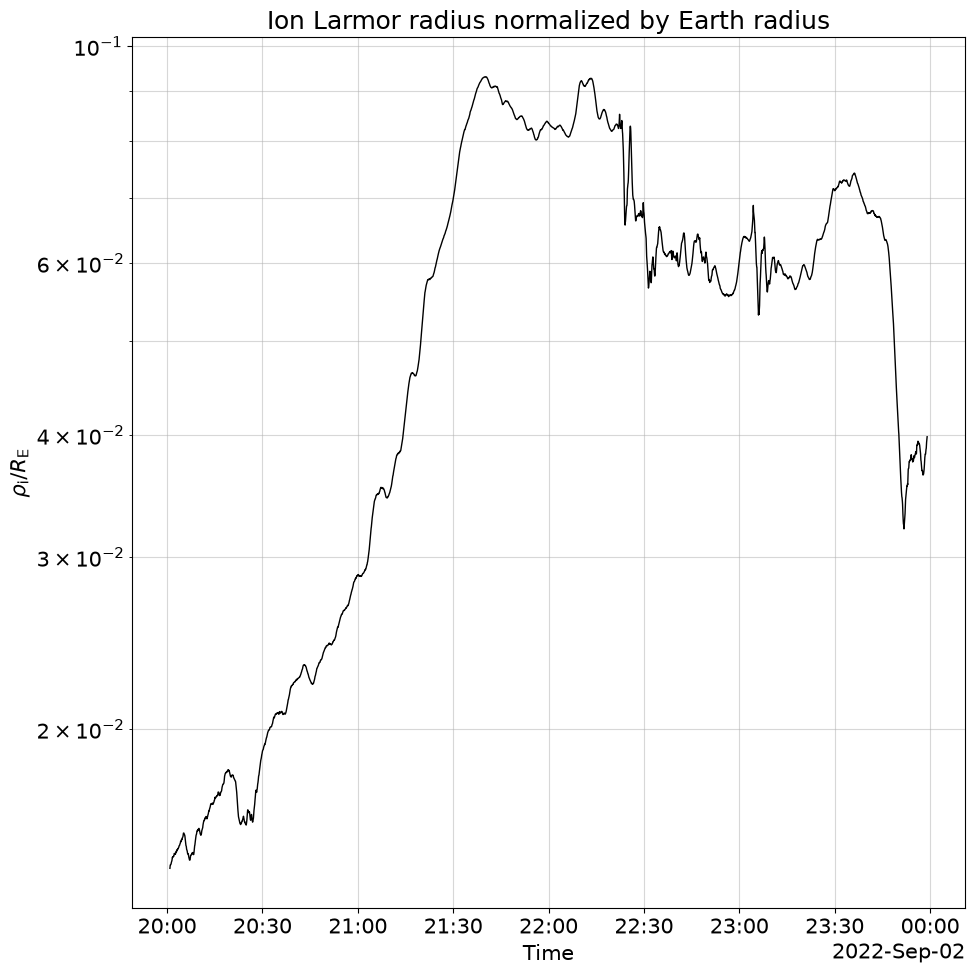

In [73]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(ion_Larmor_radius.time, (ion_Larmor_radius / (earth_radius*1E3)).data, lw=1, c='k')
ax.set_xlabel('Time')
ax.set_ylabel(r'$\rho_{\mathrm{i}} / R_{\mathrm{E}}$')
ax.set_yscale('log')
ax.set_title('Ion Larmor radius normalized by Earth radius')
ax.grid(which='both', alpha=0.5)
fig.tight_layout()

# Wavelet analysis

In [74]:
import os
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pyspedas as psp
import pytplot as pt
import pywt

import sys
from pathlib import Path

ROOT = Path("/home/satanka/Documents/observation_workspace")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import module_handmade.tdwavelet_themis as tw
import importlib
importlib.reload(tw)

<module 'module_handmade.tdwavelet_themis' from '/home/satanka/Documents/observation_workspace/module_handmade/tdwavelet_themis.py'>

In [75]:
import numpy as np
import xarray as xr
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import pandas as pd

def generate_red_noise(N, g=0.72):
    """AR(1)モデルによるレッドノイズの生成"""
    noise = np.random.randn(N)
    red_noise = np.zeros(N)
    for i in range(1, N):
        red_noise[i] = g * red_noise[i-1] + noise[i]
    return red_noise

BINS = np.linspace(0, 1, 1001)

def mc_worker_to_hist(idx, fs, n_points, g, dt, s0, dj, J):
    np.random.seed(idx)
    d1 = generate_red_noise(n_points, g=g)
    d2 = generate_red_noise(n_points, g=g)
    
    time = (np.arange(n_points) * dt * 1e9).astype('int64').astype('datetime64[ns]')
    ds_sim = xr.Dataset({"E": ("time", d1), "B": ("time", d2)}, coords={"time": time})
    
    ds_cwt = tw.cwt_from_dataset(ds_sim, dt=dt, s0=s0, dj=dj, J=J, variables=["E", "B"], apply_coi_mask=False)
    wco, _ = tw.calculate_xwt_wco(ds_cwt, "E_coef", "B_coef", dt, dj)
    
    mid = n_points // 4
    wco_target = wco[mid:-mid, :]
    
    # 各周波数ごとにヒストグラムを計算して返す
    # Shape: (n_freqs, 1000)
    hists = np.array([np.histogram(wco_target[:, f], bins=BINS)[0] for f in range(wco_target.shape[1])])
    return hists

def run_wco_monte_carlo(fs, n_iterations=1000, n_points=87168, g=0.72, n_jobs=-1, J=None):
    dt, s0, dj = 1.0/fs, 2.0, 1.0/32.0
    
    # Jが指定されていない場合のみ、点数から計算する
    if J is None:
        J = int(np.ceil(np.log2((n_points * dt / 3.0) / s0) / dj))
    
    # ダミーで周波数軸を取得
    time_coords = pd.to_datetime(np.arange(100) * dt, unit='s')
    dummy_ds = tw.cwt_from_dataset(
        xr.Dataset({"E": ("time", np.zeros(100)), "B": ("time", np.zeros(100))}, 
        coords={"time": time_coords}), 
        dt=dt, s0=s0, dj=dj, J=J, variables=["E","B"], apply_coi_mask=False
    )
    freqs = dummy_ds.freq.values
    n_freqs = len(freqs)
    
    # 全周波数の累積ヒストグラム (メモリ固定：数MB程度)
    # ※ BINS は外部で定義されている前提
    total_hists = np.zeros((n_freqs, len(BINS)-1), dtype=np.int64)

    print(f"Starting Robust Parallel MC: fs={fs}Hz, iterations={n_iterations}")
    
    # 小分けにして実行 (メモリの安全弁)
    batch_size = 40
    
    # tqdmで全体の進捗を管理
    with tqdm(total=n_iterations, desc="Monte Carlo Simulation") as pbar:
        for i in range(0, n_iterations, batch_size):
            current_batch = min(batch_size, n_iterations - i)
            
            # 並列実行
            results = Parallel(n_jobs=n_jobs)(
                delayed(mc_worker_to_hist)(i + j, fs, n_points, g, dt, s0, dj, J) 
                for j in range(current_batch)
            )
            
            # バッチ結果を累積
            for h in results:
                total_hists += h
            
            # プログレスバーを更新
            pbar.update(current_batch)
            
    # ヒストグラムから95%有意水準を逆算
    sig95_per_freq = []
    for f_idx in range(n_freqs):
        sum_hist = np.sum(total_hists[f_idx])
        if sum_hist == 0:
            sig95_per_freq.append(np.nan)
            continue
            
        cdf = np.cumsum(total_hists[f_idx]) / sum_hist
        # CDFが0.95を超える最初のビンの値を閾値とする
        idx95 = np.where(cdf >= 0.95)[0][0]
        sig95_per_freq.append(BINS[idx95])
        
    return freqs, np.array(sig95_per_freq)

#freqs, sig95 = run_wco_monte_carlo(fs=128.0, n_points=681*128, n_jobs=8, n_iterations=40)
#
#plt.figure(figsize=(14, 8))
#plt.semilogx(freqs, sig95, label='95% Significance Level')
#plt.axhline(np.mean(sig95), color='r', linestyle='--', label='Average')
#plt.xlabel('Frequency [Hz]')
#plt.ylabel('WCO Value')
#plt.title('Scale dependence of Significance Level (fs=128Hz)')
#plt.legend()
#plt.grid(True, which="both", ls="-", alpha=0.5)
#plt.show()

# 各データ(データ長)に合わせて、検証する必要がある。また、interation回数は1000以上にする。

28-Jul-26 13:59:56: /home/satanka/Documents/observation_workspace/.venv_pyspedas/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



In [76]:
import os
import numpy as np
import xarray as xr
import pandas as pd
from pathlib import Path

# --- 設定 ---
SAVE_DIR = Path(f"/mnt/j/observation_data/THEMIS_{probe.upper()}_analysis_save_data")
MC_CACHE_DIR = SAVE_DIR / "mc_cache"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
MC_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# パラメータ
fs = 0.3648
dt = 1.0 / fs
s0 = 2.0
dj = 1.0/32.0

f_target = 0.01
N_cycle_min = 3.0

# ---- 1) 全セグメントの長さを調べる ----
T_list = []
for ds_seg in ds_EBspin_fac_segs:
    t0 = ds_seg.time.values[0]
    t1 = ds_seg.time.values[-1]
    T_seg = (t1 - t0) / np.timedelta64(1, 's')
    T_list.append(T_seg)

T_max = max(T_list)
print("max segment length [s] =", T_max)

# ---- 2) 最長セグメントで意味のある最低周波数 ----
f_min_phys = N_cycle_min / T_max
f_min_seg = f_min_phys
print("f_min_seg (for longest segment) =", f_min_seg)

# ---- 3) その周波数に対応する scale_max ----
scale_target = 1.0 / (f_min_seg * dt)

# ---- 4) J_longest を計算 ----
J_longest = int(np.ceil(np.log2(scale_target / s0) / dj))
print("J_longest =", J_longest)

for i, ds_seg in enumerate(ds_EBspin_fac_segs):
    n_points        = len(ds_seg.time)
    print(f'seg_{i}: n_points = {n_points}')


EBspin_fac_vars = ['Espin_fac_x', 'Espin_fac_y', 'Espin_fac_z',
                   'Bspin_fac_x', 'Bspin_fac_y', 'Bspin_fac_z']

# ---- 5) Poynting flux calibration curve を計算 ----
#ds_KS, df_cal_scaled = tw.build_poynting_calibration_curve(
#    tw=tw,
#    fs=fs,
#    duration=T_max,
#    E0=10.0,
#    B0=2.0,
#    phase_deg=0.0,
#    s0=s0,
#    dj=dj,
#    J=J_longest,
#    use_coi_mask=True,
#    trim_cycles=5,
#)
#
#print(df_cal_scaled[[
#    "f0_input_hz", "f_bin_hz", "scale_bin",
#    "K_signed_for_mean_flux", "K_abs_for_absflux"
#]])

max segment length [s] = 13827.47090816
f_min_seg (for longest segment) = 0.0002169594150604657
J_longest = 311
seg_0: n_points = 4115
seg_1: n_points = 119


In [77]:
## --- セグメント処理ループ ---
#for i, ds_seg in enumerate(ds_EBspin_fac_segs):
#    n_points = len(ds_seg.time)
#    save_path = SAVE_DIR / f"themis_cwt_xwt_fs{fs:.4f}_seg{i}.nc"
#
#    mc_filename = MC_CACHE_DIR / f"sig95_fs{fs:.4f}_seg{i}_J{J_longest}.nc"
#
#    if mc_filename.exists():
#        ds_sig = xr.open_dataset(mc_filename)
#    else:
#        print(f"[{i+1}] Calculating MC sig95 for n_points={n_points}...")
#        freqs_mc, sig95 = run_wco_monte_carlo(
#            fs=fs, n_iterations=1000, n_points=n_points, n_jobs=12, J=J_longest
#        )
#        ds_sig = xr.Dataset(
#            {"sig95": ("freq", sig95)},
#            coords={"freq": freqs_mc}
#        )
#        ds_sig.to_netcdf(mc_filename)
#
#    sig95_values = ds_sig.sig95.values
#
#    # da_pow は自動 PSD 化、da_coef は従来通り保持
#    ds_cwt = tw.cwt_from_dataset(
#        ds_seg,
#        dt=dt,
#        s0=s0,
#        dj=dj,
#        J=J_longest,
#        variables=EBspin_fac_vars,
#        auto_calibrate_psd=False,
#        calibration_duration=T_max,
#        calibration_A0=1.0,
#        e_unit="mV/m",
#        b_unit="nT",
#    )
#    print(list(ds_cwt.data_vars.keys()))
#
#    wco_exby, phase_exby = tw.calculate_xwt_wco(ds_cwt, 'Espin_fac_x_coef', 'Bspin_fac_y_coef', dt, dj)
#    wco_eybx, phase_eybx = tw.calculate_xwt_wco(ds_cwt, 'Espin_fac_y_coef', 'Bspin_fac_x_coef', dt, dj)
#
#    # ---- parallel Poynting flux (frequency-dependent calibrated, scale-corrected) ----
#    WE_x = ds_cwt['Espin_fac_x_coef'].values.astype(np.complex64)
#    WE_y = ds_cwt['Espin_fac_y_coef'].values.astype(np.complex64)
#    WB_x = ds_cwt['Bspin_fac_x_coef'].values.astype(np.complex64)
#    WB_y = ds_cwt['Bspin_fac_y_coef'].values.astype(np.complex64)
#
#    freqs = ds_cwt['freq'].values.astype(np.float64)
#    scales = tw._get_scale_from_freq(freqs, dt).astype(np.float32)
#
#    K_signed_f = ds_KS["K_signed"].interp(
#        freq=xr.DataArray(freqs, dims="freq")
#    ).values.astype(np.float32)
#
#    cross_exby = np.real(WE_x * np.conj(WB_y))
#    cross_eybx = - np.real(WE_y * np.conj(WB_x))
#
#    S_para_cwt_exby = K_signed_f[None, :] * cross_exby / scales[None, :] * 1E-12   # [W/m2]
#    S_para_cwt_eybx = K_signed_f[None, :] * cross_eybx / scales[None, :] * 1E-12   # [W/m2]
#
#    # --- 結果の統合 ---
#    ds_cwt["EBspin_wco_exby"] = (("time", "freq"), wco_exby.astype(np.float32))
#    ds_cwt["EBspin_phase_exby"] = (("time", "freq"), phase_exby.astype(np.float32))
#    ds_cwt["EBspin_wco_eybx"] = (("time", "freq"), wco_eybx.astype(np.float32))
#    ds_cwt["EBspin_phase_eybx"] = (("time", "freq"), phase_eybx.astype(np.float32))
#
#    ds_cwt["EBspin_Spara_exby"] = (('time', 'freq'), S_para_cwt_exby.astype(np.float32))
#    ds_cwt["EBspin_Spara_eybx"] = (('time', 'freq'), S_para_cwt_eybx.astype(np.float32))
#    ds_cwt["wco_sig95"] = (("freq",), sig95_values.astype(np.float32))
#
#    vars_to_save = [
#        name for name in ds_cwt.data_vars.keys()
#        if isinstance(name, str) and not name.endswith('_coef')
#    ]
#    ds_cwt[vars_to_save].to_netcdf(save_path)
#
#    print(f"[{i+1}/{len(ds_EBspin_fac_segs)}] Done: {save_path.name}")
#
#    del ds_cwt, ds_sig

In [78]:
import os
import numpy as np
import xarray as xr
import pandas as pd
from pathlib import Path

# --- 設定 ---
SAVE_DIR = Path(f"/mnt/j/observation_data/THEMIS_{probe.upper()}_analysis_save_data")
MC_CACHE_DIR = SAVE_DIR / "mc_cache"  # 点数ごとの有意水準を保存するフォルダ
SAVE_DIR.mkdir(parents=True, exist_ok=True)
MC_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# パラメータ
fs = 8.0
dt = 1.0 / fs
s0 = 2.0
dj = 1.0/32.0

f_target = 0.01         # 目標最低周波数
N_cycle_min = 3.0       # 最低3周期は欲しい

# ---- 1) 全セグメントの長さを調べる ----
T_list = []
for ds_seg in ds_EB8_fac_segs:
    t0 = ds_seg.time.values[0]
    t1 = ds_seg.time.values[-1]
    T_seg = (t1 - t0) / np.timedelta64(1, 's')
    T_list.append(T_seg)

T_max = max(T_list)
print("max segment length [s] =", T_max)

# ---- 2) 最長セグメントで意味のある最低周波数 ----
f_min_phys = N_cycle_min / T_max
f_min_seg = f_min_phys #max(f_target, f_min_phys)
print("f_min_seg (for longest segment) =", f_min_seg)

# ---- 3) その周波数に対応する scale_max ----
scale_target = 1.0 / (f_min_seg * dt)

# ---- 4) J_longest を計算 ----
J_longest = int(np.ceil(np.log2(scale_target / s0) / dj))
print("J_longest =", J_longest)

for i, ds_seg in enumerate(ds_EB8_fac_segs):
    n_points        = len(ds_seg.time)
    print(f'seg_{i}: n_points = {n_points}')

EB8_fac_vars = ['E8_fac_x', 'E8_fac_y', 'E8_fac_z', 'B8_fac_x', 'B8_fac_y', 'B8_fac_z']

# ---- 5) Poynting flux calibration curve を計算 ----
#ds_KS, df_cal_scaled = tw.build_poynting_calibration_curve(
#    tw=tw,
#    fs=fs,
#    duration=T_max,
#    E0=10.0,
#    B0=2.0,
#    phase_deg=0.0,
#    s0=s0,
#    dj=dj,
#    J=J_longest,
#    use_coi_mask=True,
#    trim_cycles=5,
#)
#
#print(df_cal_scaled[[
#    "f0_input_hz", "f_bin_hz", "scale_bin",
#    "K_signed_for_mean_flux", "K_abs_for_absflux"
#]])

max segment length [s] = 14289.937484544
f_min_seg (for longest segment) = 0.00020993793732441453
J_longest = 455
seg_0: n_points = 228640


In [79]:
## --- セグメント処理ループ ---
#for i, ds_seg in enumerate(ds_EB8_fac_segs):
#    n_points = len(ds_seg.time)
#    start_time_str = pd.to_datetime(ds_seg.time.values[0]).strftime('%Y%m%d_%H%M%S')
#    save_path = SAVE_DIR / f"themis_cwt_xwt_fs{fs:.4f}_seg{i}.nc"
#
#    # --- 1) このセグメントの点数に対応する有意水準を取得 ---
#    # ファイル名にパラメータを含めて衝突を防ぐ
#    mc_filename = MC_CACHE_DIR / f"sig95_fs{fs:.4f}_seg{i}_J{J_longest}.nc"
#    
#    if mc_filename.exists():
#        ds_sig = xr.open_dataset(mc_filename)
#    else:
#        print(f"[{i+1}] Calculating MC sig95 for n_points={n_points}...")
#        # J=J_longest を明示的に渡すことで、周波数軸の数を 388 に固定する
#        freqs_mc, sig95 = run_wco_monte_carlo(
#            fs=fs, n_iterations=1000, n_points=n_points, n_jobs=8, J=J_longest
#        )
#        ds_sig = xr.Dataset(
#            {"sig95": ("freq", sig95)},
#            coords={"freq": freqs_mc}
#        )
#        ds_sig.to_netcdf(mc_filename)
#    
#    sig95_values = ds_sig.sig95.values
#
#    # --- 2) CWT / WCO 計算 ---
#    ds_cwt = tw.cwt_from_dataset(
#        ds_seg,
#        dt=dt,
#        s0=s0,
#        dj=dj,
#        J=J_longest,
#        variables=EB8_fac_vars,
#        auto_calibrate_psd=False,
#        calibration_duration=T_max,
#        calibration_A0=1.0,
#        e_unit="mV/m",
#        b_unit="nT",
#    )
#    
#    wco_exby, phase_exby = tw.calculate_xwt_wco(ds_cwt, 'E8_fac_x_coef', 'B8_fac_y_coef', dt, dj)
#    wco_eybx, phase_eybx = tw.calculate_xwt_wco(ds_cwt, 'E8_fac_y_coef', 'B8_fac_x_coef', dt, dj)
#
#    # ---- parallel Poynting flux (calibrated, scale-corrected) ----
#    WE_x = ds_cwt['E8_fac_x_coef'].values.astype(np.complex64)
#    WE_y = ds_cwt['E8_fac_y_coef'].values.astype(np.complex64)
#    WB_x = ds_cwt['B8_fac_x_coef'].values.astype(np.complex64)
#    WB_y = ds_cwt['B8_fac_y_coef'].values.astype(np.complex64)
#
#    freqs = ds_cwt['freq'].values.astype(np.float64)
#    scales = tw._get_scale_from_freq(freqs, dt).astype(np.float32)
#
#    K_signed_f = ds_KS["K_signed"].interp(
#        freq=xr.DataArray(freqs, dims="freq")
#    ).values.astype(np.float32)
#
#    cross_exby = np.real(WE_x * np.conj(WB_y))
#    cross_eybx = - np.real(WE_y * np.conj(WB_x))
#
#    S_para_cwt_exby = K_signed_f[None, :] * cross_exby / scales[None, :] * 1E-12   # [W/m2]
#    S_para_cwt_eybx = K_signed_f[None, :] * cross_eybx / scales[None, :] * 1E-12   # [W/m2]
#
#
#    # --- 3) 結果の統合 ---
#    ds_cwt["EB8_wco_exby"] = (("time", "freq"), wco_exby.astype(np.float32))
#    ds_cwt["EB8_phase_exby"] = (("time", "freq"), phase_exby.astype(np.float32))
#    ds_cwt["EB8_wco_eybx"] = (("time", "freq"), wco_eybx.astype(np.float32))
#    ds_cwt["EB8_phase_eybx"] = (("time", "freq"), phase_eybx.astype(np.float32))
#
#    ds_cwt["EB8_Spara_exby"] = (('time', 'freq'), S_para_cwt_exby.astype(np.float32))
#    ds_cwt["EB8_Spara_eybx"] = (('time', 'freq'), S_para_cwt_eybx.astype(np.float32))
#
#    # セグメントごとの有意水準も一緒に保存しておくと後で楽
#    # 周波数軸が一致していることを前提に、ブロードキャストして格納
#    ds_cwt["wco_sig95"] = (("freq"), sig95_values.astype(np.float32))
#
#    vars_to_save = [
#        name for name in ds_cwt.data_vars.keys()
#        if isinstance(name, str) and not name.endswith('_coef')
#    ]
#    ds_cwt[vars_to_save].to_netcdf(save_path)
#
#    print(f"[{i+1}/{len(ds_EB8_fac_segs)}] Done: {save_path.name}")
#
#    # メモリ解放
#    del ds_cwt, ds_sig

In [80]:
import os
import numpy as np
import xarray as xr
import pandas as pd
from pathlib import Path

# --- 設定 ---
SAVE_DIR = Path(f"/mnt/j/observation_data/THEMIS_{probe.upper()}_analysis_save_data")
MC_CACHE_DIR = SAVE_DIR / "mc_cache"  # 点数ごとの有意水準を保存するフォルダ
SAVE_DIR.mkdir(parents=True, exist_ok=True)
MC_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# パラメータ
fs = 128.0
dt = 1.0 / fs
s0 = 2.0
dj = 1.0/32.0

f_target = 4.0          # 目標最低周波数
N_cycle_min = 3.0       # 最低3周期は欲しい

# ---- 1) 全セグメントの長さを調べる ----
T_list = []
for ds_seg in ds_EB128_fac_segs:
    t0 = ds_seg.time.values[0]
    t1 = ds_seg.time.values[-1]
    T_seg = (t1 - t0) / np.timedelta64(1, 's')
    T_list.append(T_seg)

T_max = max(T_list)
print("max segment length [s] =", T_max)

# ---- 2) 最長セグメントで意味のある最低周波数 ----
f_min_phys = N_cycle_min / T_max
f_min_seg = f_min_phys #max(f_target, f_min_phys)
print("f_min_seg (for longest segment) =", f_min_seg)

# ---- 3) その周波数に対応する scale_max ----
scale_target = 1.0 / (f_min_seg * dt)

# ---- 4) J_longest を計算 ----
J_longest = int(np.ceil(np.log2(scale_target / s0) / dj))
print("J_longest =", J_longest)

for i, ds_seg in enumerate(ds_EB128_fac_segs):
    n_points        = len(ds_seg.time)
    print(f'seg_{i}: n_points = {n_points}')

EB128_fac_vars = ['E128_fac_x', 'E128_fac_y', 'E128_fac_z', 'B128_fac_x', 'B128_fac_y', 'B128_fac_z']

# ---- 5) Poynting flux calibration curve を計算 ----
#ds_KS, df_cal_scaled = tw.build_poynting_calibration_curve(
#    tw=tw,
#    fs=fs,
#    duration=T_max,
#    E0=10.0,
#    B0=2.0,
#    phase_deg=0.0,
#    s0=s0,
#    dj=dj,
#    J=J_longest,
#    use_coi_mask=True,
#    trim_cycles=5,
#)
#
#print(df_cal_scaled[[
#    "f0_input_hz", "f_bin_hz", "scale_bin",
#    "K_signed_for_mean_flux", "K_abs_for_absflux"
#]])

max segment length [s] = 357.984359936
f_min_seg (for longest segment) = 0.00838025437909169
J_longest = 413
seg_0: n_points = 38646
seg_1: n_points = 6399
seg_2: n_points = 45823
seg_3: n_points = 45302
seg_4: n_points = 45302


In [ ]:
# --- セグメント処理ループ ---
#for i, ds_seg in enumerate(ds_EB128_fac_segs):
#    n_points = len(ds_seg.time)
#    start_time_str = pd.to_datetime(ds_seg.time.values[0]).strftime('%Y%m%d_%H%M%S')
#    save_path = SAVE_DIR / f"themis_cwt_xwt_fs{fs:.4f}_seg{i}.nc"
#
#    # --- 1) このセグメントの点数に対応する有意水準を取得 ---
#    # ファイル名にパラメータを含めて衝突を防ぐ
#    mc_filename = MC_CACHE_DIR / f"sig95_fs{fs:.4f}_seg{i}_J{J_longest}.nc"
#
#    if mc_filename.exists():
#        ds_sig = xr.open_dataset(mc_filename)
#    else:
#        print(f"[{i+1}] Calculating MC sig95 for n_points={n_points}...")
#        # J=J_longest を明示的に渡すことで、周波数軸の数を 388 に固定する
#        freqs_mc, sig95 = run_wco_monte_carlo(
#            fs=fs, n_iterations=1000, n_points=n_points, n_jobs=8, J=J_longest
#        )
#        ds_sig = xr.Dataset(
#            {"sig95": ("freq", sig95)},
#            coords={"freq": freqs_mc}
#        )
#        ds_sig.to_netcdf(mc_filename)
#    
#    sig95_values = ds_sig.sig95.values
#
#    # --- 2) CWT / WCO 計算 ---
#    ds_cwt = tw.cwt_from_dataset(
#        ds_seg,
#        dt=dt,
#        s0=s0,
#        dj=dj,
#        J=J_longest,
#        variables=EB128_fac_vars,
#        auto_calibrate_psd=False,
#        calibration_duration=T_max,
#        calibration_A0=1.0,
#        e_unit="mV/m",
#        b_unit="nT",
#    )
#    
#    wco_exby, phase_exby = tw.calculate_xwt_wco(ds_cwt, 'E128_fac_x_coef', 'B128_fac_y_coef', dt, dj)
#    wco_eybx, phase_eybx = tw.calculate_xwt_wco(ds_cwt, 'E128_fac_y_coef', 'B128_fac_x_coef', dt, dj)
#
#    # ---- parallel Poynting flux (calibrated, scale-corrected) ----
#    WE_x = ds_cwt['E128_fac_x_coef'].values.astype(np.complex64)
#    WE_y = ds_cwt['E128_fac_y_coef'].values.astype(np.complex64)
#    WB_x = ds_cwt['B128_fac_x_coef'].values.astype(np.complex64)
#    WB_y = ds_cwt['B128_fac_y_coef'].values.astype(np.complex64)
#
#    freqs = ds_cwt['freq'].values.astype(np.float64)
#    scales = (1.0 / (freqs * dt)).astype(np.float32)
#
#    K_signed_f = ds_KS["K_signed"].interp(
#        freq=xr.DataArray(freqs, dims="freq")
#    ).values.astype(np.float32)
#
#    cross_exby = np.real(WE_x * np.conj(WB_y))
#    cross_eybx = - np.real(WE_y * np.conj(WB_x))
#
#    S_para_cwt_exby = K_signed_f[None, :] * cross_exby / scales[None, :] * 1E-12   # [W/m2]
#    S_para_cwt_eybx = K_signed_f[None, :] * cross_eybx / scales[None, :] * 1E-12   # [W/m2]
#
#    # --- 3) 結果の統合 ---
#    ds_cwt["EB128_wco_exby"] = (("time", "freq"), wco_exby.astype(np.float32))
#    ds_cwt["EB128_phase_exby"] = (("time", "freq"), phase_exby.astype(np.float32))
#    ds_cwt["EB128_wco_eybx"] = (("time", "freq"), wco_eybx.astype(np.float32))
#    ds_cwt["EB128_phase_eybx"] = (("time", "freq"), phase_eybx.astype(np.float32))
#
#    ds_cwt["EB128_Spara_exby"] = (('time', 'freq'), S_para_cwt_exby.astype(np.float32))
#    ds_cwt["EB128_Spara_eybx"] = (('time', 'freq'), S_para_cwt_eybx.astype(np.float32))
#
#    # セグメントごとの有意水準も一緒に保存しておくと後で楽
#    # 周波数軸が一致していることを前提に、ブロードキャストして格納
#    ds_cwt["wco_sig95"] = (("freq"), sig95_values.astype(np.float32))
#
#    # 不要な複素数係数は除外して保存
#    vars_to_save = [
#        name for name in ds_cwt.data_vars.keys()
#        if isinstance(name, str) and not name.endswith('_coef')
#    ]
#    ds_cwt[vars_to_save].to_netcdf(save_path)
#
#    print(f"[{i+1}/{len(ds_EB128_fac_segs)}] Done: {save_path.name}")
#
#    # メモリ解放
#    del ds_cwt, ds_sig

In [ ]:
#import xarray as xr
#import matplotlib.pyplot as plt
#from pathlib import Path
#from tqdm.auto import tqdm
#import matplotlib as mpl
#
## --- 設定 ---
#target_dir = Path("/mnt/j/observation_data/THEMIS_A_analysis_save_data/mc_cache/")
#
## ディレクトリ内のすべての .nc ファイルを取得
#nc_files = list(target_dir.glob("*.nc"))
#
#print(f"Found {len(nc_files)} files in {target_dir}")
#
#mpl.rcParams['font.size']=15
#
## 各ファイルに対して処理を実行
#for nc_path in tqdm(nc_files, desc="Generating plots"):
#    # 出力ファイルパスの生成 (.nc -> .png)
#    png_path = nc_path.with_suffix(".png")
#
#    try:
#        # データの読み込み
#        with xr.open_dataset(nc_path) as ds:
#            freq = ds.freq.values
#            sig95 = ds.sig95.values
#            
#            # 図の作成
#            plt.figure(figsize=(10, 5))
#            plt.semilogx(freq, sig95, color='red', lw=2, label='95% Significance Level')
#
#            plt.grid(True, which="both", ls="-", alpha=0.5)
#            plt.xlabel('Frequency [Hz]')
#            plt.ylabel('WCO Significance Threshold')
#            plt.title(f'95% Significance Level vs. Frequency\n{nc_path.name}')
#            plt.legend()
#
#            # 保存
#            plt.savefig(png_path, dpi=150, bbox_inches='tight')
#            plt.close() # メモリ解放のために閉じる
#
#    except Exception as e:
#        print(f"Error processing {nc_path.name}: {e}")
#
#print("Done. All plots saved in the same folder.")
#
#mpl.rcParams['font.size']=25

In [ ]:
#import xarray as xr
#
## パスの定義
#path_seg = "/mnt/j/observation_data/THEMIS_A_analysis_save_data/themis_cwt_xwt_fs128.0000_seg0.nc"
#path_mc = "/mnt/j/observation_data/THEMIS_A_analysis_save_data/mc_cache/sig95_fs128.0000_seg0_J443.nc"
#
## ファイルを開く
#try:
#    ds_seg = xr.open_dataset(path_seg)
#    ds_mc = xr.open_dataset(path_mc)
#
#    print("--- Segment Data (CWT/XWT) ---")
#    print(ds_seg)
#    print(ds_seg.time)
#    print(f"\n'freq' size in segment: {ds_seg.dims.get('freq')}")
#    
#    print("\n" + "="*50 + "\n")
#    
#    print("--- Monte Carlo Cache (sig95) ---")
#    print(ds_mc)
#    print(f"\n'freq' size in MC cache: {ds_mc.dims.get('freq')}")
#
#    # サイズの不一致を直接確認
#    if ds_seg.dims.get('freq') != ds_mc.dims.get('freq'):
#        print("\n[ALERT] Dimension mismatch detected!")
#        print(f"Segment freq ({ds_seg.dims.get('freq')}) != MC freq ({ds_mc.dims.get('freq')})")
#
#except FileNotFoundError as e:
#    print(f"Error: ファイルが見つからない。パスを確認してくれ。\n{e}")
#except Exception as e:
#    print(f"Error: ロード中に問題が発生した。\n{e}")

In [ ]:
#import matplotlib.pyplot as plt
#
#freq = ds_mc.freq.values
#sig95 = ds_mc.sig95.values
#
#plt.figure(figsize=(10, 5))
#plt.semilogx(freq, sig95, color='red', lw=2, label='95% Significance Level')
#
#plt.grid(True, which="both", ls="-", alpha=0.5)
#plt.xlabel('Frequency [Hz]')
#plt.ylabel('WCO Significance Threshold')
##plt.ylim((0, 0.05))
#plt.title('95% Significance Level vs. Frequency')
#plt.legend()
#
## 値の範囲を表示して確認
#print(f"Max Sig95: {sig95.max():.4f} at {freq[sig95.argmax()]:.2e} Hz")
#print(f"Min Sig95: {sig95.min():.4f} at {freq[sig95.argmin()]:.2e} Hz")
#
#plt.show()

In [ ]:
#fs = 0.3648
#dt = 1.0 / fs
#s0 = 2.0
#dj = 1.0/32.0
#
#f_target = 0.01         # 目標最低周波数
#N_cycle_min = 3.0       # 最低3周期は欲しい
#
## ---- 1) 全セグメントの長さを調べる ----
#T_list = []
#for ds_seg in ds_EB8_fac_segs:
#    t0 = ds_seg.time.values[0]
#    t1 = ds_seg.time.values[-1]
#    T_seg = (t1 - t0) / np.timedelta64(1, 's')
#    T_list.append(T_seg)
#
#T_max = max(T_list)
#print("max segment length [s] =", T_max)
#
## ---- 2) 最長セグメントで意味のある最低周波数 ----
#f_min_phys = N_cycle_min / T_max
#f_min_seg = f_min_phys #max(f_target, f_min_phys)
#print("f_min_seg (for longest segment) =", f_min_seg)
#
## ---- 3) その周波数に対応する scale_max ----
#scale_target = 1.0 / (f_min_seg * dt)
#
## ---- 4) J_longest を計算 ----
#J_longest = int(np.ceil(np.log2(scale_target / s0) / dj))
#print("J_longest =", J_longest)
#
#ds_EBspin_fac_cwt_segs    = []
#EBspin_fac_vars = ['Espin_fac_x', 'Espin_fac_y', 'Espin_fac_z', 'Bspin_fac_x', 'Bspin_fac_y', 'Bspin_fac_z']
#
#for ds_seg in ds_EBspin_fac_segs:
#    ds_cwt = tw.cwt_from_dataset(
#        ds_seg,
#        dt=dt,
#        s0=s0,
#        dj=dj,
#        J=J_longest,     # << 全てこれを使う
#        variables=EBspin_fac_vars
#    )
#    ds_EBspin_fac_cwt_segs.append(ds_cwt)
#
#print(ds_EBspin_fac_cwt_segs)
#
#ds_EBspin_fac_xwt_wco_segs = []
#
#def process_segment_EBspin(ds_cwt, dt, dj):
#
#    # XWT / WCO計算
#    wco_exby, phase_exby = tw.calculate_xwt_wco(ds_cwt, 'Espin_fac_x_coef', 'Bspin_fac_y_coef', dt, dj)
#    wco_eybx, phase_eybx = tw.calculate_xwt_wco(ds_cwt, 'Espin_fac_y_coef', 'Bspin_fac_x_coef', dt, dj)
#
#    # 結果の格納
#    ds_xwt = xr.Dataset({
#        "EBspin_wco_exby": (("time", "freq"), wco_exby.astype(np.float32)),
#        "EBspin_phase_exby": (("time", "freq"), phase_exby.astype(np.float32)),
#        "EBspin_wco_eybx": (("time", "freq"), wco_eybx.astype(np.float32)),
#        "EBspin_phase_eybx": (("time", "freq"), phase_eybx.astype(np.float32))
#    }, coords=ds_cwt.coords)
#
#    return ds_xwt
#
#for ds_seg in ds_EBspin_fac_cwt_segs:
#    ds_xwt = process_segment_EBspin(ds_seg, dt, dj)
#    ds_EBspin_fac_xwt_wco_segs.append(ds_xwt)
#
#print(ds_EBspin_fac_xwt_wco_segs)

In [ ]:
#fs = 8.0
#dt = 1.0 / fs
#s0 = 2.0
#dj = 1.0/32.0
#
#f_target = 0.01         # 目標最低周波数
#N_cycle_min = 3.0       # 最低3周期は欲しい
#
## ---- 1) 全セグメントの長さを調べる ----
#T_list = []
#for ds_seg in ds_EB8_fac_segs:
#    t0 = ds_seg.time.values[0]
#    t1 = ds_seg.time.values[-1]
#    T_seg = (t1 - t0) / np.timedelta64(1, 's')
#    T_list.append(T_seg)
#
#T_max = max(T_list)
#print("max segment length [s] =", T_max)
#
## ---- 2) 最長セグメントで意味のある最低周波数 ----
#f_min_phys = N_cycle_min / T_max
#f_min_seg = f_min_phys #max(f_target, f_min_phys)
#print("f_min_seg (for longest segment) =", f_min_seg)
#
## ---- 3) その周波数に対応する scale_max ----
#scale_target = 1.0 / (f_min_seg * dt)
#
## ---- 4) J_longest を計算 ----
#J_longest = int(np.ceil(np.log2(scale_target / s0) / dj))
#print("J_longest =", J_longest)
#
#ds_EB8_fac_cwt_segs    = []
#EB8_fac_vars = ['E8_fac_x', 'E8_fac_y', 'E8_fac_z', 'B8_fac_x', 'B8_fac_y', 'B8_fac_z']
#
#ds_EB8_fac_cwt_segs = []
#for ds_seg in ds_EB8_fac_segs:
#    ds_cwt = tw.cwt_from_dataset(
#        ds_seg, dt=dt, s0=s0, dj=dj, J=J_longest, variables=EB8_fac_vars
#    )
#    ds_EB8_fac_cwt_segs.append(ds_cwt)
#
#print(ds_EB8_fac_cwt_segs)
#
#ds_EB8_fac_xwt_wco_segs = []
#
#def process_segment_EB8(ds_cwt, dt, dj):
#
#    # XWT / WCO計算
#    wco_exby, phase_exby = tw.calculate_xwt_wco(ds_cwt, 'E8_fac_x_coef', 'B8_fac_y_coef', dt, dj)
#    wco_eybx, phase_eybx = tw.calculate_xwt_wco(ds_cwt, 'E8_fac_y_coef', 'B8_fac_x_coef', dt, dj)
#
#    # 結果の格納
#    ds_xwt = xr.Dataset({
#        "EB8_wco_exby": (("time", "freq"), wco_exby.astype(np.float32)),
#        "EB8_phase_exby": (("time", "freq"), phase_exby.astype(np.float32)),
#        "EB8_wco_eybx": (("time", "freq"), wco_eybx.astype(np.float32)),
#        "EB8_phase_eybx": (("time", "freq"), phase_eybx.astype(np.float32))
#    }, coords=ds_cwt.coords)
#
#    return ds_xwt
#
#for ds_seg in ds_EB8_fac_cwt_segs:
#    ds_xwt = process_segment_EB8(ds_seg, dt, dj)
#    ds_EB8_fac_xwt_wco_segs.append(ds_xwt)
#
#print(ds_EB8_fac_xwt_wco_segs)

In [ ]:
#fs = 128.0
#dt = 1.0 / fs
#s0 = 2.0
#dj = 1.0/32.0
#
#f_target = 4.0          # 目標最低周波数
#N_cycle_min = 3.0       # 最低3周期は欲しい
#
## ---- 1) 全セグメントの長さを調べる ----
#T_list = []
#for ds_seg in ds_EB128_fac_segs:
#    t0 = ds_seg.time.values[0]
#    t1 = ds_seg.time.values[-1]
#    T_seg = (t1 - t0) / np.timedelta64(1, 's')
#    T_list.append(T_seg)
#
#T_max = max(T_list)
#print("max segment length [s] =", T_max)
#
## ---- 2) 最長セグメントで意味のある最低周波数 ----
#f_min_phys = N_cycle_min / T_max
#f_min_seg = f_min_phys #max(f_target, f_min_phys)
#print("f_min_seg (for longest segment) =", f_min_seg)
#
## ---- 3) その周波数に対応する scale_max ----
#scale_target = 1.0 / (f_min_seg * dt)
#
## ---- 4) J_longest を計算 ----
#J_longest = int(np.ceil(np.log2(scale_target / s0) / dj))
#print("J_longest =", J_longest)
#
#ds_EB128_fac_cwt_segs    = []
#EB128_fac_vars = ['E128_fac_x', 'E128_fac_y', 'E128_fac_z', 'B128_fac_x', 'B128_fac_y', 'B128_fac_z']
#
#for ds_seg in ds_EB128_fac_segs:
#    ds_cwt = tw.cwt_from_dataset(
#        ds_seg,
#        dt=dt,
#        s0=s0,
#        dj=dj,
#        J=J_longest,     # << 全てこれを使う
#        variables=EB128_fac_vars
#    )
#    ds_EB128_fac_cwt_segs.append(ds_cwt)
#
#print(ds_EB128_fac_cwt_segs)
#
#ds_EB128_fac_xwt_wco_segs  = []
#
#for ds_seg in ds_EB128_fac_cwt_segs:
#    # 1) Ex - By ペア
#    wco_exby, phase_exby = tw.calculate_xwt_wco(ds_seg, 'E128_fac_x_coef', 'B128_fac_y_coef', dt, dj)
#    
#    # 2) Ey - Bx ペア
#    wco_eybx, phase_eybx = tw.calculate_xwt_wco(ds_seg, 'E128_fac_y_coef', 'B128_fac_x_coef', dt, dj)
#    
#    # 結果を Dataset に格納
#    ds_xwt = xr.Dataset({
#        "EB128_wco_exby": (("time", "freq"), wco_exby.astype(np.float32)),
#        "EB128_phase_exby": (("time", "freq"), phase_exby.astype(np.float32)),
#        "EB128_wco_eybx": (("time", "freq"), wco_eybx.astype(np.float32)),
#        "EB128_phase_eybx": (("time", "freq"), phase_eybx.astype(np.float32))
#    })
#
#    ds_EB128_fac_xwt_wco_segs.append(ds_xwt)
#
#print(ds_EB128_fac_xwt_wco_segs)
#
#ds_EB128_fac_xwt_wco_segs = []
#
#def process_segment_EB128(ds_cwt, dt, dj):
#
#    # XWT / WCO計算
#    wco_exby, phase_exby = tw.calculate_xwt_wco(ds_cwt, 'E128_fac_x_coef', 'B128_fac_y_coef', dt, dj)
#    wco_eybx, phase_eybx = tw.calculate_xwt_wco(ds_cwt, 'E128_fac_y_coef', 'B128_fac_x_coef', dt, dj)
#
#    # 結果の格納
#    ds_xwt = xr.Dataset({
#        "EB128_wco_exby": (("time", "freq"), wco_exby.astype(np.float32)),
#        "EB128_phase_exby": (("time", "freq"), phase_exby.astype(np.float32)),
#        "EB128_wco_eybx": (("time", "freq"), wco_eybx.astype(np.float32)),
#        "EB128_phase_eybx": (("time", "freq"), phase_eybx.astype(np.float32))
#    }, coords=ds_cwt.coords)
#
#    return ds_xwt
#
#for ds_seg in ds_EB128_fac_cwt_segs:
#    ds_xwt = process_segment_EB128(ds_seg, dt, dj)
#    ds_EB128_fac_xwt_wco_segs.append(ds_xwt)
#
#print(ds_EB128_fac_xwt_wco_segs)

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
import matplotlib as mpl

mpl.rcParams['font.size'] = 11

# ---- セグメント連結（freq合わせ）----
def concat_cwt_segments(dsets, var):
    # dsets をリストに正規化
    if isinstance(dsets, xr.Dataset):
        dsets = [dsets]
    elif isinstance(dsets, (str, bytes)):
        raise TypeError("dsets は Dataset のリストにして")

    das = []
    for ds in dsets:
        if ds is None or not isinstance(ds, xr.Dataset):
            continue
        if var in ds.data_vars:
            das.append(ds[var])

    if not das:
        return None, None

    pow_cat = xr.concat(das, dim="time").sortby("time")

    coi_name = var.replace("_cwt", "_coi")
    coi_list = []
    for ds in dsets:
        if isinstance(ds, xr.Dataset) and coi_name in ds.data_vars:
            coi_list.append(ds[coi_name])
    coi_cat = xr.concat(coi_list, dim="time").sortby("time") if coi_list else None
    return pow_cat, coi_cat

# ---- 1面描画：外でax/caxを用意する ----
def plot_cwt_on_ax(ax, da_pow, da_coi=None, t0=None, minutes=5,
                   zrange=(1e-6, 1e3), yrange=(1e-2, 4.0),
                   cmap="turbo", label_left="", unit_right=""):
    # 時間切り出し
    if t0 is not None:
        t1 = t0 + np.timedelta64(minutes, "m")
        da = da_pow.sel(time=slice(t0, t1))
        coi = da_coi.sel(time=slice(t0, t1)) if da_coi is not None else None
        #ax.set_xlim(t0, t1)
    else:
        da, coi = da_pow, da_coi
    if da.time.size == 0: return None, None

    T = mdates.date2num(da.time.values)
    F = da.freq.values
    Z = da.values.astype(float)

    # COIマスク（低周波側をNaN）
    if coi is not None:
        C = coi.values[:, None]
        Z = np.where(F[None, :] < C, np.nan, Z)

    # メッシュ
    Tm = np.tile(T, (F.size, 1)).T
    Fm = np.tile(F, (T.size, 1))

    pcm = ax.pcolormesh(Tm, Fm, Z, shading="auto",
                        norm=LogNorm(vmin=zrange[0], vmax=zrange[1]), cmap=cmap)

    ax.minorticks_on()
    ax.set_yscale("log")
    ax.set_ylim(yrange[0], yrange[1])
    ax.set_ylabel(f"{label_left}\n[Hz]")

    ax.grid(which='both', alpha=0.3)

    if t0 is not None:
        t1 = t0 + np.timedelta64(minutes, "m")
        ax.set_xlim(mdates.date2num(np.array([t0, t1], dtype="datetime64[ns]")))

    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))   # 1分刻み
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.tick_params(axis="x", rotation=0)


    # 右側カラーバー
    cax = ax.inset_axes([1.01, 0.05, 0.02, 0.9])
    cb = plt.colorbar(pcm, cax=cax)
    cb.set_label(f"{unit_right}")
    return pcm, cb


In [ ]:
targets_EB128_fac_cwt = [
    ("E128_fac_x_cwt", r"$E_{x}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("E128_fac_y_cwt", r"$E_{y}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("E128_fac_z_cwt", r"$E_{z}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("B128_fac_x_cwt", r"$B_{x}$ (FAC)", "[nT$^2$/Hz]"),
    ("B128_fac_y_cwt", r"$B_{y}$ (FAC)", "[nT$^2$/Hz]"),
    ("B128_fac_z_cwt", r"$B_{z}$ (FAC)", "[nT$^2$/Hz]"),
]
joined_EB128_fac_cwt = {}

path_seg_EB128_list = [
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/themis_cwt_xwt_fs128.0000_seg0.nc",
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/themis_cwt_xwt_fs128.0000_seg1.nc",
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/themis_cwt_xwt_fs128.0000_seg2.nc"
]

ds_EB128_fac_cwt_segs = []

for path in path_seg_EB128_list:
    ds_seg = xr.open_dataset(path)
    ds_EB128_fac_cwt_segs.append(ds_seg)

for v, _, _ in targets_EB128_fac_cwt:
    da, coi = concat_cwt_segments(ds_EB128_fac_cwt_segs, v)
    if da is not None: joined_EB128_fac_cwt[v] = (da, coi)

In [ ]:
#time_windows = [
#    np.datetime64('2022-09-01T22:25') + np.timedelta64(5, 'm')*n
#    for n in range(9)
#]
#
#for t0 in time_windows:
#    fig, axes = plt.subplots(len(targets_EB128_fac_cwt), 1, figsize=(10, 10), sharex=True)
#    for ax, (v, ylab, unit) in zip(axes, targets_EB128_fac_cwt):
#        if v not in joined_EB128_fac_cwt: continue
#        da, coi = joined_EB128_fac_cwt[v]
#        plot_cwt_on_ax(ax, da, coi, t0=t0, minutes=5,
#                       zrange=(1e-6, 1e3), yrange=(np.nanmin(da.freq), np.nanmax(da.freq)),
#                       cmap="turbo", label_left=ylab, unit_right=unit)
#
#    axes[-1].set_xlabel("time")
#    fig.tight_layout()
#
#    if os.path.isdir(path_base_save_plot):
#        t0_str = str(t0)
#        fn_time = t0_str.replace(':', '').replace('T', '_')
#        fig_path = os.path.join(path_base_save_plot, f'EB_fields_fac_high_freq_cwt_{fn_time}.png')
#        print(fig_path)
#        fig.savefig(fig_path)
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)

In [ ]:
targets_EB8_fac_cwt = [
    ("E8_fac_x_cwt", r"$E_{x}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("E8_fac_y_cwt", r"$E_{y}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("E8_fac_z_cwt", r"$E_{z}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("B8_fac_x_cwt", r"$B_{x}$ (FAC)", "[nT$^2$/Hz]"),
    ("B8_fac_y_cwt", r"$B_{y}$ (FAC)", "[nT$^2$/Hz]"),
    ("B8_fac_z_cwt", r"$B_{z}$ (FAC)", "[nT$^2$/Hz]"),
]
joined_EB8_fac_cwt = {}

path_seg_EB8_list = [
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/themis_cwt_xwt_fs8.0000_seg0.nc",
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/themis_cwt_xwt_fs8.0000_seg1.nc",
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/themis_cwt_xwt_fs8.0000_seg2.nc"
]

ds_EB8_fac_cwt_segs = []

for path in path_seg_EB8_list:
    ds_seg = xr.open_dataset(path)
    ds_EB8_fac_cwt_segs.append(ds_seg)

for v, _, _ in targets_EB8_fac_cwt:
    da, coi = concat_cwt_segments(ds_EB8_fac_cwt_segs, v)
    if da is not None: joined_EB8_fac_cwt[v] = (da, coi)

In [ ]:
#time_windows = [
#    np.datetime64('2022-09-01T20:00') + np.timedelta64(5, 'm')*n
#    for n in range(48)
#]
#
#for t0 in time_windows:
#    fig, axes = plt.subplots(len(targets_EB8_fac_cwt), 1, figsize=(10, 10), sharex=True)
#    for ax, (v, ylab, unit) in zip(axes, targets_EB8_fac_cwt):
#        if v not in joined_EB8_fac_cwt: continue
#        da, coi = joined_EB8_fac_cwt[v]
#        plot_cwt_on_ax(ax, da, coi, t0=t0, minutes=5,
#                       zrange=(1e-6, 1e3), yrange=(np.nanmin(da.freq), np.nanmax(da.freq)),
#                       cmap="turbo", label_left=ylab, unit_right=unit)
#
#    axes[-1].set_xlabel("time")
#    fig.tight_layout()
#
#    if os.path.isdir(path_base_save_plot):
#        t0_str = str(t0)
#        fn_time = t0_str.replace(':', '').replace('T', '_')
#        fig_path = os.path.join(path_base_save_plot, f'EB_fields_fac_low_freq_cwt_{fn_time}.png')
#        print(fig_path)
#        fig.savefig(fig_path)
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)

In [ ]:
targets_EBspin_fac_cwt = [
    ("Espin_fac_x_cwt", r"$E_{x}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("Espin_fac_y_cwt", r"$E_{y}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("Espin_fac_z_cwt", r"$E_{z}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("Bspin_fac_x_cwt", r"$B_{x}$ (FAC)", "[nT$^2$/Hz]"),
    ("Bspin_fac_y_cwt", r"$B_{y}$ (FAC)", "[nT$^2$/Hz]"),
    ("Bspin_fac_z_cwt", r"$B_{z}$ (FAC)", "[nT$^2$/Hz]"),
]
joined_EBspin_fac_cwt = {}

path_seg_EBspin_list = [
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/themis_cwt_xwt_fs0.3648_seg0.nc"
]

ds_EBspin_fac_cwt_segs = []

for path in path_seg_EBspin_list:
    ds_seg = xr.open_dataset(path)
    ds_EBspin_fac_cwt_segs.append(ds_seg)

for v, _, _ in targets_EBspin_fac_cwt:
    da, coi = concat_cwt_segments(ds_EBspin_fac_cwt_segs, v)
    if da is not None: joined_EBspin_fac_cwt[v] = (da, coi)

In [ ]:
#time_windows = [
#    np.datetime64('2022-09-01T20:00') + np.timedelta64(5, 'm')*n
#    for n in range(48)
#]
#
#for t0 in time_windows:
#    fig, axes = plt.subplots(len(targets_EBspin_fac_cwt), 1, figsize=(10, 10), sharex=True)
#    for ax, (v, ylab, unit) in zip(axes, targets_EBspin_fac_cwt):
#        if v not in joined_EBspin_fac_cwt: continue
#        da, coi = joined_EBspin_fac_cwt[v]
#        plot_cwt_on_ax(ax, da, coi, t0=t0, minutes=5,
#                       zrange=(1e-6, 1e3), yrange=(np.nanmin(da.freq), np.nanmax(da.freq)),
#                       cmap="turbo", label_left=ylab, unit_right=unit)
#
#    axes[-1].set_xlabel("time")
#    fig.tight_layout()
#
#    if os.path.isdir(path_base_save_plot):
#        t0_str = str(t0)
#        fn_time = t0_str.replace(':', '').replace('T', '_')
#        fig_path = os.path.join(path_base_save_plot, f'EB_fields_fac_spin_cwt_{fn_time}.png')
#        print(fig_path)
#        fig.savefig(fig_path)
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm

mpl.rcParams['font.size'] = 11

# --- 連結（周波数を合わせて縦結合）
def concat_cwt_segments(dsets, var):
    das = [ds[var] for ds in dsets if var in ds]
    if not das: return None, None
    freqs = np.unique(np.concatenate([da.freq.values for da in das]))
    das = [da if np.array_equal(da.freq.values, freqs) else da.interp(freq=freqs) for da in das]
    pow_cat = xr.concat(das, dim="time").sortby("time").assign_coords(freq=("freq", freqs))
    coi_name = var.replace("_cwt", "_coi")
    coi_cat = xr.concat([ds[coi_name] for ds in dsets if coi_name in ds], dim="time").sortby("time") \
              if all(coi_name in ds for ds in dsets) else None
    return pow_cat, coi_cat

# --- 2帯域を同一axに描画
def plot_cwt_dualband_on_ax(ax,
                            da_hi, coi_hi,   # 高周波 (128Hz系)
                            da_lo, coi_lo,   # 低周波 (8Hz系)
                            t0, t1, minutes,
                            f_lo=(1e-2, 4.0),
                            f_hi=(4.0, 64.0),
                            zrange=(1e-6, 1e3),
                            cmap="turbo",
                            ylabel="", unit_right="",
                            cax=None):

    if t1 is None:
        t1 = t0 + np.timedelta64(minutes, "m")

    # ---- データ切り出し ----
    dah  = da_hi.sel(time=slice(t0, t1)) if da_hi  is not None else None
    dal  = da_lo.sel(time=slice(t0, t1)) if da_lo  is not None else None
    coih = coi_hi.sel(time=slice(t0, t1)) if coi_hi is not None else None
    coil = coi_lo.sel(time=slice(t0, t1)) if coi_lo is not None else None

    if (dah is None or dah.time.size == 0) and (dal is None or dal.time.size == 0):
        return None, None

    def _prep(da, coi, fmin, fmax):
        if da is None or da.time.size == 0:
            return None, None, None
        da2 = da.sel(freq=slice(fmin, fmax))
        T = mdates.date2num(da2.time.values)
        F = da2.freq.values
        Z = da2.values.astype(float)
        if coi is not None:
            C = coi.values[:, None]
            Z = np.where(F[None, :] < C, np.nan, Z)
        Tm = np.tile(T, (F.size, 1)).T
        Fm = np.tile(F, (T.size, 1))
        return Tm, Fm, Z

    pcm_h = pcm_l = None

    # 低周波 (8 Hz 系)
    out_lo = _prep(dal, coil, *f_lo)
    if out_lo[0] is not None:
        Tm_l, Fm_l, Z_l = out_lo
        pcm_l = ax.pcolormesh(Tm_l, Fm_l, Z_l, shading="auto",
                              norm=LogNorm(vmin=zrange[0], vmax=zrange[1]),
                              cmap=cmap)

    # 高周波 (128 Hz 系)
    out_hi = _prep(dah, coih, *f_hi)
    if out_hi[0] is not None:
        Tm_h, Fm_h, Z_h = out_hi
        pcm_h = ax.pcolormesh(Tm_h, Fm_h, Z_h, shading="auto",
                              norm=LogNorm(vmin=zrange[0], vmax=zrange[1]),
                              cmap=cmap)

    # ---- 軸設定 ----
    ax.set_yscale("log")
    ax.set_ylim(f_lo[0], f_hi[1])
    ax.set_ylabel(f"{ylabel}\n[Hz]")

    ax.axhline(y=f_lo[1], c='k', alpha=0.5, lw=2)

    # t0〜t1 をそのまま xlim に
    ax.set_xlim(mdates.date2num(np.array([t0, t1], dtype="datetime64[ns]")))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.minorticks_on()
    ax.grid(which='both', alpha=0.3)

    # ---- カラーバー ----
    if cax == None:
        cax = ax.inset_axes([1.01, 0.05, 0.02, 0.9])
    pcm_main = pcm_h if pcm_h is not None else pcm_l
    cb = plt.colorbar(pcm_main, cax=cax)
    cb.set_label(unit_right)

    return (pcm_h, pcm_l), cb

In [ ]:
#targets_EB128_EB8 = [
#    ("E128_fac_x_cwt","E8_fac_x_cwt",  r"$E_{x}$ (FAC)", "[(mV/m)$^2$/Hz]"),
#    ("E128_fac_y_cwt","E8_fac_y_cwt",  r"$E_{y}$ (FAC)", "[(mV/m)$^2$/Hz]"),
#    ("E128_fac_z_cwt","E8_fac_z_cwt",  r"$E_{z}$ (FAC)", "[(mV/m)$^2$/Hz]"),
#    ("B128_fac_x_cwt","B8_fac_x_cwt",  r"$B_{x}$ (FAC)", "[nT$^2$/Hz]"),
#    ("B128_fac_y_cwt","B8_fac_y_cwt",  r"$B_{y}$ (FAC)", "[nT$^2$/Hz]"),
#    ("B128_fac_z_cwt","B8_fac_z_cwt",  r"$B_{z}$ (FAC)", "[nT$^2$/Hz]"),
#]
#
#joined_EB128_EB8_fac_cwt = {}
#for v_hi, v_lo, _, _ in targets_EB128_EB8:
#    da_hi, coi_hi = concat_cwt_segments(ds_EB128_fac_cwt_segs, v_hi)
#    da_lo, coi_lo = concat_cwt_segments(ds_EB8_fac_cwt_segs,   v_lo)
#    if (da_hi is not None) or (da_lo is not None):
#        joined_EB128_EB8_fac_cwt[(v_hi, v_lo)] = (da_hi, coi_hi, da_lo, coi_lo)

In [ ]:
targets_EB128_EBspin = [
    ("E128_fac_x_cwt","Espin_fac_x_cwt",  r"$E_{x}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("E128_fac_y_cwt","Espin_fac_y_cwt",  r"$E_{y}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("E128_fac_z_cwt","Espin_fac_z_cwt",  r"$E_{z}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("B128_fac_x_cwt","Bspin_fac_x_cwt",  r"$B_{x}$ (FAC)", "[nT$^2$/Hz]"),
    ("B128_fac_y_cwt","Bspin_fac_y_cwt",  r"$B_{y}$ (FAC)", "[nT$^2$/Hz]"),
    ("B128_fac_z_cwt","Bspin_fac_z_cwt",  r"$B_{z}$ (FAC)", "[nT$^2$/Hz]"),
]

joined_EB128_EBspin_fac_cwt = {}
for v_hi, v_lo, _, _ in targets_EB128_EBspin:
    da_hi, coi_hi = concat_cwt_segments(ds_EB128_fac_cwt_segs,  v_hi)
    da_lo, coi_lo = concat_cwt_segments(ds_EBspin_fac_cwt_segs, v_lo)
    if (da_hi is not None) or (da_lo is not None):
        joined_EB128_EBspin_fac_cwt[(v_hi, v_lo)] = (da_hi, coi_hi, da_lo, coi_lo)

In [ ]:
#time_windows = [
#    np.datetime64('2022-09-01T22:25') + np.timedelta64(5, 'm')*n
#    for n in range(12)
#]
#
#for t0 in time_windows:
#    fig, axes = plt.subplots(len(targets_EB128_EBspin), 1, figsize=(10, 10), sharex=True)
#    for ax, (v_hi, v_lo, ylab, unit) in zip(axes, targets_EB128_EBspin):
#        if (v_hi, v_lo) not in joined_EB128_EBspin_fac_cwt: continue
#        da_hi, coi_hi, da_lo, coi_lo = joined_EB128_EBspin_fac_cwt[(v_hi, v_lo)]
#        plot_cwt_dualband_on_ax(ax, da_hi, coi_hi, da_lo, coi_lo,
#                                t0=t0, t1=None, minutes=5,
#                                f_lo=(1e-2, 0.1824), f_hi=(0.1824, 64.0),
#                                zrange=(1e-6, 1e3), cmap="turbo",
#                                ylabel=ylab, unit_right=unit)
#
#    axes[-1].set_xlabel("time")
#    fig.tight_layout()
#
#    if os.path.isdir(path_base_save_plot):
#        t0_str = str(t0)
#        fn_time = t0_str.replace(':', '').replace('T', '_')
#        fig_path = os.path.join(path_base_save_plot, f'EB_fields_fac_cwt_{fn_time}.png')
#        print(fig_path)
#        fig.savefig(fig_path)
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm

mpl.rcParams['font.size'] = 11

def plot_cwt_prefer_hi_fill_lo(ax,
                              da_hi, coi_hi,
                              da_lo, coi_lo,
                              t0, t1, minutes,
                              f_range=(1e-2, 64.0),
                              zrange=(1e-6, 1e3),
                              cmap="turbo",
                              ylabel="", unit_right="", cax=None):

    if t1 is None:
        t1 = t0 + np.timedelta64(minutes, "m")

    # 切り出し（NoneならNoneのまま）
    dah  = da_hi.sel(time=slice(t0, t1)) if da_hi  is not None else None
    dal  = da_lo.sel(time=slice(t0, t1)) if da_lo  is not None else None
    coih = coi_hi.sel(time=slice(t0, t1)) if coi_hi is not None else None

    # 両方ないなら終了
    if (dah is None or dah.time.size == 0) and (dal is None or dal.time.size == 0):
        return None, None

    # --- 共通 time グリッド（和集合） ---
    times = []
    if dah is not None and dah.time.size > 0:
        times.append(dah.time.values)
    if dal is not None and dal.time.size > 0:
        times.append(dal.time.values)
    t_grid = np.unique(np.concatenate(times))
    t_grid = np.sort(t_grid)

    # --- 共通 freq グリッド（128優先、なければspin） ---
    if dah is not None and dah.time.size > 0:
        f_grid = dah.sel(freq=slice(*f_range)).freq.values
    else:
        f_grid = dal.sel(freq=slice(*f_range)).freq.values

    # --- 128側を共通グリッドへ（無ければNaNで埋める） ---
    if dah is not None and dah.time.size > 0:
        dah2 = dah.sel(freq=slice(*f_range)).interp(time=t_grid, freq=f_grid)
    else:
        dah2 = xr.DataArray(
            np.full((t_grid.size, f_grid.size), np.nan, dtype=float),
            dims=("time","freq"),
            coords={"time": t_grid, "freq": f_grid},
            name="hi"
        )

    # --- spin側を共通グリッドへ（無ければNaN） ---
    if dal is not None and dal.time.size > 0:
        dal2 = dal.sel(freq=slice(*f_range)).interp(time=t_grid, freq=f_grid)
    else:
        dal2 = xr.full_like(dah2, np.nan)

    # --- COI(128) を共通 time へ（128が無い時刻は NaN にして境界線を切る） ---
    if coih is not None and coih.time.size > 0:
        # まず time 補間（coih は (time)）
        coih1 = coih.interp(time=t_grid)
        # 128が元々存在しない時刻を判定して、その時刻のcoiをNaNに
        # (nearestで突っ張られるのを防ぐ)
        hi_has_time = xr.DataArray(np.isin(t_grid, dah.time.values if dah is not None else []),
                                   dims=("time",), coords={"time": t_grid})
        coih1 = coih1.where(hi_has_time, np.nan)

        coih2 = coih1.astype(float).broadcast_like(dah2)
        hi_valid = (dah2["freq"] >= coih2) & np.isfinite(dah2)
    else:
        hi_valid = np.isfinite(dah2)

    # --- 合成：128優先、無効部はspin ---
    Z = dah2.where(hi_valid, dal2)

    # --- 描画 ---
    T = mdates.date2num(Z.time.values)
    F = Z.freq.values
    pcm = ax.pcolormesh(T, F, Z.T.values, shading="auto",
                        norm=LogNorm(vmin=zrange[0], vmax=zrange[1]),
                        cmap=cmap)

    # 境界線（128がある時刻だけ描く）
    if coih is not None and coih.time.size > 0:
        coih_plot = coih.interp(time=t_grid)
        coih_plot = coih_plot.where(np.isin(t_grid, dah.time.values), np.nan)
        ax.plot(mdates.date2num(coih_plot.time.values), coih_plot.values,
                "k", lw=2, alpha=0.7)

    ax.set_yscale("log")
    ax.set_ylim(f_range[0], f_range[1])
    ax.set_ylabel(f"{ylabel}\n[Hz]")
    ax.set_xlim(mdates.date2num(np.array([t0, t1], dtype="datetime64[ns]")))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.minorticks_on()
    ax.grid(which="both", alpha=0.3)

    if cax == None:
        cax = ax.inset_axes([1.01, 0.05, 0.02, 0.9])
    cb = plt.colorbar(pcm, cax=cax)
    cb.set_label(unit_right)

    return pcm, cb


In [ ]:
#time_windows = [
#    np.datetime64('2022-09-01T22:25') + np.timedelta64(5, 'm')*n
#    for n in range(12)
#]
#
#for t0 in time_windows:
#    fig, axes = plt.subplots(len(targets_EB128_EBspin), 1, figsize=(10, 10), sharex=True)
#    for ax, (v_hi, v_lo, ylab, unit) in zip(axes, targets_EB128_EBspin):
#        if (v_hi, v_lo) not in joined_EB128_EBspin_fac_cwt: continue
#        da_hi, coi_hi, da_lo, coi_lo = joined_EB128_EBspin_fac_cwt[(v_hi, v_lo)]
#        plot_cwt_prefer_hi_fill_lo(
#            ax,
#            da_hi, coi_hi,
#            da_lo, coi_lo,
#            t0=t0, t1=None, minutes=5,
#            f_range=(1e-2, 64.0),
#            zrange=(1e-6, 1e3),
#            cmap="turbo",
#            ylabel=ylab, unit_right=unit
#        )
#
#    axes[-1].set_xlabel("time")
#    fig.tight_layout()
#
#    if os.path.isdir(path_base_save_plot):
#        t0_str = str(t0)
#        fn_time = t0_str.replace(':', '').replace('T', '_')
#        fig_path = os.path.join(path_base_save_plot, f'EB_fields_fac_cwt_prefer128_{fn_time}.png')
#        print(fig_path)
#        fig.savefig(fig_path)
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm


def plot_cwt_prefer_hi_fill_mid_lo(
    ax,
    da_hi,
    coi_hi,
    da_mid,
    coi_mid,
    da_lo,
    coi_lo,
    t0,
    t1,
    minutes,
    f_range=(1e-2, 64.0),
    zrange=(1e-6, 1e3),
    cmap="turbo",
    ylabel="",
    unit_right="",
    cax=None,
):
    """
    3種類のCWTデータを、hi > mid > low の優先順位で合成して描画する。

    各帯域では、以下を満たす点のみ有効とする。

    1. 元のDataArrayにその時刻のデータが存在する
    2. 値が有限である
    3. COIが与えられている場合、freq >= COIである

    Parameters
    ----------
    da_hi, da_mid, da_lo : xr.DataArray or None
        dims=("time", "freq")を持つCWTデータ。
    coi_hi, coi_mid, coi_lo : xr.DataArray or None
        dims=("time",)を持つCOI周波数。
    """

    if t1 is None:
        t1 = t0 + np.timedelta64(minutes, "m")

    # --------------------------------------------------------
    # 時間範囲の切り出し
    # --------------------------------------------------------
    def _slice_da(da):
        if da is None:
            return None

        da_cut = da.sel(time=slice(t0, t1))

        if da_cut.time.size == 0:
            return None

        return da_cut

    def _slice_coi(coi):
        if coi is None:
            return None

        coi_cut = coi.sel(time=slice(t0, t1))

        if coi_cut.time.size == 0:
            return None

        return coi_cut

    dah = _slice_da(da_hi)
    dam = _slice_da(da_mid)
    dal = _slice_da(da_lo)

    coih = _slice_coi(coi_hi)
    coim = _slice_coi(coi_mid)
    coil = _slice_coi(coi_lo)

    # すべての帯域が空なら終了
    if dah is None and dam is None and dal is None:
        return None, None

    # --------------------------------------------------------
    # 共通timeグリッド：3帯域の時刻の和集合
    # --------------------------------------------------------
    times = []

    for da in (dah, dam, dal):
        if da is not None:
            times.append(da.time.values)

    t_grid = np.unique(np.concatenate(times))
    t_grid = np.sort(t_grid)

    # --------------------------------------------------------
    # 共通freqグリッド
    #
    # hiが存在すればhiを優先し、
    # なければmid、さらにそれもなければlowを使用
    # --------------------------------------------------------
    da_reference = next(
        da for da in (dah, dam, dal)
        if da is not None
    )

    f_grid = (
        da_reference
        .sel(freq=slice(*f_range))
        .freq
        .values
    )

    template = xr.DataArray(
        np.full(
            (t_grid.size, f_grid.size),
            np.nan,
            dtype=float,
        ),
        dims=("time", "freq"),
        coords={
            "time": t_grid,
            "freq": f_grid,
        },
    )

    def _make_time_support_mask(
        source_time,
        target_time,
        gap_factor=3.0,
    ):
        """
        target_timeがsource_timeの通常のサンプリング区間内にあるか判定する。

        通常の時間間隔のgap_factor倍を超える欠測区間は補間しない。
        """

        src = np.asarray(source_time).astype("datetime64[ns]")
        tgt = np.asarray(target_time).astype("datetime64[ns]")

        src = src[~np.isnat(src)]
        src = np.unique(src)
        src = np.sort(src)

        if src.size == 0:
            return np.zeros(tgt.size, dtype=bool)

        if src.size == 1:
            return tgt == src[0]

        src_int = src.astype(np.int64)
        tgt_int = tgt.astype(np.int64)

        dt = np.diff(src_int)
        dt = dt[dt > 0]

        if dt.size == 0:
            return np.isin(tgt, src)

        typical_dt = np.median(dt)
        max_gap = gap_factor * typical_dt

        # targetが入る位置
        right = np.searchsorted(src_int, tgt_int, side="left")
        left = right - 1

        right_clip = np.clip(right, 0, src_int.size - 1)

        # 元時刻との完全一致
        exact = (
            (right < src_int.size)
            & (src_int[right_clip] == tgt_int)
        )

        # 左右の元データに挟まれている時刻
        inside = (
            (left >= 0)
            & (right < src_int.size)
        )

        gap = np.full(tgt_int.size, np.inf)

        gap[inside] = (
            src_int[right[inside]]
            - src_int[left[inside]]
        )

        # 通常のサンプリング区間なら補間を許可
        interpolatable = inside & (gap <= max_gap)

        return exact | interpolatable

    # --------------------------------------------------------
    # 各帯域を共通グリッドへ変換し、有効領域を求める
    # --------------------------------------------------------
    def _prepare_band(
        da,
        coi,
        name,
        gap_factor=3.0,
    ):
        """
        共通time/freqグリッドへの補間と有効領域の判定。
    
        gap_factor:
            元データの中央値時間間隔の何倍までを
            通常の補間可能区間とするか。
        """
    
        if da is None:
            da_grid = xr.full_like(template, np.nan)
            valid = xr.zeros_like(template, dtype=bool)
    
            return da_grid, valid, None
    
        da_band = (
            da
            .sel(freq=slice(*f_range))
            .sortby("time")
        )
    
        # 共通time/freqグリッドへ補間
        da_grid = da_band.interp(
            time=t_grid,
            freq=f_grid,
        )
    
        da_grid.name = name
    
        # 完全一致ではなく、通常の時間間隔内かどうかを判定
        time_supported = xr.DataArray(
            _make_time_support_mask(
                source_time=da_band.time.values,
                target_time=t_grid,
                gap_factor=gap_factor,
            ),
            dims=("time",),
            coords={"time": t_grid},
        )
    
        time_supported_2d = time_supported.broadcast_like(
            da_grid
        )
    
        # COIを使わない場合
        if coi is None:
            valid = (
                time_supported_2d
                & np.isfinite(da_grid)
            )
    
            return da_grid, valid, None
    
        coi_band = coi.sortby("time")
    
        # COIも共通timeへ補間
        coi_grid = coi_band.interp(time=t_grid)
    
        # データの時間範囲外や大きなgapではCOIも無効
        coi_grid = coi_grid.where(
            time_supported,
            np.nan,
        )
    
        coi_2d = (
            coi_grid
            .astype(float)
            .broadcast_like(da_grid)
        )
    
        valid = (
            time_supported_2d
            & np.isfinite(da_grid)
            & np.isfinite(coi_2d)
            & (da_grid["freq"] >= coi_2d)
        )
    
        return da_grid, valid, coi_grid

    dah2, hi_valid, coih_plot = _prepare_band(
        dah, coih, "hi"
    )

    dam2, mid_valid, coim_plot = _prepare_band(
        dam, coim, "mid"
    )

    dal2, low_valid, coil_plot = _prepare_band(
        dal, coil, "low"
    )

    # --------------------------------------------------------
    # 合成
    #
    # lowを基礎として、mid、hiの順で上書きする。
    # したがって優先順位は hi > mid > low。
    # --------------------------------------------------------
    Z = dal2.where(low_valid)
    Z = dam2.where(mid_valid, Z)
    Z = dah2.where(hi_valid, Z)

    # --------------------------------------------------------
    # 描画
    # --------------------------------------------------------
    T = mdates.date2num(Z.time.values)
    F = Z.freq.values

    pcm = ax.pcolormesh(
        T,
        F,
        Z.transpose("freq", "time").values,
        shading="auto",
        norm=LogNorm(
            vmin=zrange[0],
            vmax=zrange[1],
        ),
        cmap=cmap,
    )

    def _sample_valid_at_curve(valid_2d, curve_1d):
        """
        各時刻について、curve_1dの周波数以上で最初のfreqグリッドにおける
        valid_2dの値を取得する。
    
        Parameters
        ----------
        valid_2d : xr.DataArray
            dims=("time", "freq")のbool配列。
        curve_1d : xr.DataArray
            dims=("time",)のCOI周波数。
    
        Returns
        -------
        xr.DataArray
            dims=("time",)のbool配列。
        """
    
        valid_sorted = valid_2d.sortby("freq")
    
        freq = valid_sorted.freq.values.astype(float)
        valid_values = valid_sorted.transpose("time", "freq").values.astype(bool)
    
        curve = curve_1d.reindex(time=valid_sorted.time)
        curve_values = curve.values.astype(float)
    
        result = np.zeros(curve_values.size, dtype=bool)
    
        # COI以上となる最初の周波数グリッド
        freq_index = np.searchsorted(
            freq,
            curve_values,
            side="left",
        )
    
        usable = (
            np.isfinite(curve_values)
            & (freq_index >= 0)
            & (freq_index < freq.size)
        )
    
        row_index = np.flatnonzero(usable)
    
        result[row_index] = valid_values[
            row_index,
            freq_index[usable],
        ]
    
        return xr.DataArray(
            result,
            dims=("time",),
            coords={"time": valid_sorted.time},
        )

    # COI境界線
    #
    # hi: 実線
    # mid: 破線
    # low: 点線
    # --------------------------------------------------------
    # COIの表示制御
    #
    # 各帯域の有効領域は freq >= COI。
    #
    # hi COI:
    #   hiデータが存在する時間には常に表示
    #
    # mid COI:
    #   hiの有効領域内に入る部分は非表示
    #
    # low COI:
    #   hiまたはmidの有効領域内に入る部分は非表示
    # --------------------------------------------------------
    
    # 各時刻に、その帯域の有効PSDが少なくとも1点あるか
    hi_exists = hi_valid.any(dim="freq")
    mid_exists = mid_valid.any(dim="freq")
    low_exists = low_valid.any(dim="freq")
    
    
    def _higher_band_covers_curve(
        higher_exists,
        higher_coi,
        curve,
    ):
        """
        curveの位置が、上位帯域のPSD表示領域に入っているか判定する。
    
        上位帯域の有効領域は freq >= higher_coi。
        higher_coi=Noneの場合は、上位帯域が全周波数を覆うものとする。
        """
    
        if curve is None:
            return None
    
        # COI指定なしの場合、上位帯域は全周波数で有効
        if higher_coi is None:
            return higher_exists.broadcast_like(curve)
    
        return (
            higher_exists
            & np.isfinite(higher_coi)
            & np.isfinite(curve)
            & (curve >= higher_coi)
        )
    
    
    # --------------------------------------------------------
    # hi COI
    # --------------------------------------------------------
    coih_visible = None
    
    if coih_plot is not None:
        coih_visible = coih_plot.where(
            hi_exists
        )
    
    
    # --------------------------------------------------------
    # mid COI
    #
    # mid COIがhi COI以上の周波数にある場合、
    # その位置ではhi PSDが採用されるため非表示
    # --------------------------------------------------------
    coim_visible = None
    
    if coim_plot is not None:
        hi_covers_mid = _higher_band_covers_curve(
            higher_exists=hi_exists,
            higher_coi=coih_plot,
            curve=coim_plot,
        )
    
        coim_visible = coim_plot.where(
            mid_exists
            & ~hi_covers_mid
        )
    
    
    # --------------------------------------------------------
    # low COI
    #
    # low COIがhiまたはmidのPSD領域に入る場合は非表示
    # --------------------------------------------------------
    coil_visible = None
    
    if coil_plot is not None:
        hi_covers_low = _higher_band_covers_curve(
            higher_exists=hi_exists,
            higher_coi=coih_plot,
            curve=coil_plot,
        )
    
        mid_covers_low = _higher_band_covers_curve(
            higher_exists=mid_exists,
            higher_coi=coim_plot,
            curve=coil_plot,
        )
    
        coil_visible = coil_plot.where(
            low_exists
            & ~hi_covers_low
            & ~mid_covers_low
        )
    
    
    # --------------------------------------------------------
    # COI境界線の描画
    # --------------------------------------------------------
    coi_settings = [
        (coih_visible, "-",  2.0),
        (coim_visible, "--", 1.7),
        (coil_visible, ":",  1.5),
    ]
    
    for coi_curve, linestyle, linewidth in coi_settings:
        if coi_curve is None:
            continue
        
        ax.plot(
            mdates.date2num(coi_curve.time.values),
            coi_curve.values,
            color="k",
            linestyle=linestyle,
            linewidth=linewidth,
            alpha=0.7,
        )

    ax.set_yscale("log")
    ax.set_ylim(f_range[0], f_range[1])
    ax.set_ylabel(f"{ylabel}\n[Hz]")

    ax.set_xlim(
        mdates.date2num(
            np.array(
                [t0, t1],
                dtype="datetime64[ns]",
            )
        )
    )

    ax.xaxis.set_major_locator(
        mdates.MinuteLocator(interval=1)
    )
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%H:%M")
    )

    ax.minorticks_on()
    ax.grid(which="both", alpha=0.3)

    if cax is None:
        cax = ax.inset_axes(
            [1.01, 0.05, 0.02, 0.9]
        )

    cb = plt.colorbar(pcm, cax=cax)
    cb.set_label(unit_right)

    return pcm, cb

In [ ]:
targets_EB128_EB8_EBspin = [
    ("E128_fac_x_cwt","E8_fac_x_cwt","Espin_fac_x_cwt",  r"$E_{x}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("E128_fac_y_cwt","E8_fac_y_cwt","Espin_fac_y_cwt",  r"$E_{y}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("E128_fac_z_cwt","E8_fac_z_cwt","Espin_fac_z_cwt",  r"$E_{z}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("B128_fac_x_cwt","B8_fac_x_cwt","Bspin_fac_x_cwt",  r"$B_{x}$ (FAC)", "[nT$^2$/Hz]"),
    ("B128_fac_y_cwt","B8_fac_y_cwt","Bspin_fac_y_cwt",  r"$B_{y}$ (FAC)", "[nT$^2$/Hz]"),
    ("B128_fac_z_cwt","B8_fac_z_cwt","Bspin_fac_z_cwt",  r"$B_{z}$ (FAC)", "[nT$^2$/Hz]"),
]

joined_EB128_EB8_EBspin_fac_cwt = {}
for v_hi, v_mi, v_lo, _, _ in targets_EB128_EB8_EBspin:
    da_hi, coi_hi = concat_cwt_segments(ds_EB128_fac_cwt_segs,  v_hi)
    da_mi, coi_mi = concat_cwt_segments(ds_EB8_fac_cwt_segs,    v_mi)
    da_lo, coi_lo = concat_cwt_segments(ds_EBspin_fac_cwt_segs, v_lo)
    if (da_hi is not None) or (da_mi is not None) or (da_lo is not None):
        joined_EB128_EB8_EBspin_fac_cwt[(v_hi, v_mi, v_lo)] = (da_hi, coi_hi, da_mi, coi_mi, da_lo, coi_lo)

In [ ]:
#time_windows = [
#    np.datetime64('2022-09-01T20:00') + np.timedelta64(5, 'm')*n
#    for n in range(48)
#]
#
#for t0 in time_windows:
#    fig, axes = plt.subplots(len(targets_EB128_EB8_EBspin), 1, figsize=(10, 10), sharex=True)
#    for ax, (v_hi, v_mi, v_lo, ylab, unit) in zip(axes, targets_EB128_EB8_EBspin):
#        if (v_hi, v_mi, v_lo) not in joined_EB128_EB8_EBspin_fac_cwt: continue
#        da_hi, coi_hi, da_mi, coi_mi, da_lo, coi_lo = joined_EB128_EB8_EBspin_fac_cwt[(v_hi, v_mi, v_lo)]
#        plot_cwt_prefer_hi_fill_mid_lo(
#            ax,
#            da_hi, coi_hi,
#            da_mi, coi_mi,
#            da_lo, coi_lo,
#            t0=t0, t1=None, minutes=5,
#            f_range=(1e-2, 64.0),
#            zrange=(1e-6, 1e3),
#            cmap="turbo",
#            ylabel=ylab, unit_right=unit
#        )
#
#    axes[-1].set_xlabel("time")
#    fig.tight_layout()
#
#    if os.path.isdir(path_base_save_plot):
#        t0_str = str(t0)
#        fn_time = t0_str.replace(':', '').replace('T', '_')
#        fig_path = os.path.join(path_base_save_plot, f'EB_fields_fac_cwt_prefer128_and_8_{fn_time}.png')
#        print(fig_path)
#        fig.savefig(fig_path)
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)

In [ ]:
mpl.rcParams['font.size'] = 11

def concat_xwt_segments(dsets, var):
    das = []
    for ds in dsets:
        if ds is not None and var in ds.data_vars:
            das.append(ds[var])
    if not das: return None
    return xr.concat(das, dim="time").sortby("time")

from matplotlib.colors import Normalize

def plot_xwt_phase_on_ax(ax, da_wco, da_phase, t0=None, minutes=5,
                         wco_thresh=0, yrange=(1e-2, 4.0),
                         mode="wco", label_left="", unit=None, cax=None):
    # 時間切り出し
    if t0 is not None:
        t1 = t0 + np.timedelta64(minutes, "m")
        wco = da_wco.sel(time=slice(t0, t1))
        phase = da_phase.sel(time=slice(t0, t1))
    else:
        wco, phase = da_wco, da_phase

    if wco.time.size == 0: return None

    T = mdates.date2num(wco.time.values)
    F = wco.freq.values
    Tm, Fm = np.meshgrid(T, F, indexing='ij')

    if mode == "wco":
        Z = wco.values.astype(float)
        cmap = "viridis"
        norm = Normalize(vmin=0, vmax=1)
        if unit==None:
            unit = "Coherency"
    else: # mode == "phase"
        # WCOが低い領域をマスクする
        Z = np.abs(phase.where(wco > wco_thresh).values.astype(float))
        cmap = "Spectral"
        norm = Normalize(vmin=0, vmax=180)
        if unit==None:
            unit = "Phase (abs) [deg]"

    pcm = ax.pcolormesh(Tm, Fm, Z, shading="auto", norm=norm, cmap=cmap)

    ax.minorticks_on()
    ax.set_yscale("log")
    ax.set_ylim(yrange[0], yrange[1])
    ax.set_ylabel(f"{label_left}\n[Hz]")

    ax.grid(which='both', alpha=0.3)

    if t0 is not None:
        t1 = t0 + np.timedelta64(minutes, "m")
        ax.set_xlim(mdates.date2num(np.array([t0, t1], dtype="datetime64[ns]")))

    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))   # 1分刻み
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.tick_params(axis="x", rotation=0)

    if cax == None:
        cax = ax.inset_axes([1.01, 0.05, 0.02, 0.9])
    cb = plt.colorbar(pcm, cax=cax)
    cb.set_label(unit)
    if mode == "phase":
        cb.set_ticks([0, 45, 90, 135, 180])
    
    return pcm, cb

In [ ]:
targets_EBspin_xwt = [
    ("EBspin_wco_exby", "EBspin_phase_exby", r"$E_{x}$"+r' & '+r"$B_{y}$"),
    ("EBspin_wco_eybx", "EBspin_phase_eybx", r"$E_{y}$"+r' & '+r"$B_{x}$"),
]

joined_EBspin_xwt = {}

path_seg_EBspin_mc_list = [
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/mc_cache/sig95_fs0.3648_seg0_J313.nc"
]

for i, path in enumerate(path_seg_EBspin_mc_list):
    ds_seg_mc = xr.open_dataset(path)

    sig95 = ds_seg_mc["sig95"]

    ds = ds_EBspin_fac_cwt_segs[i]

    sig95_on_ds = sig95.copy()
    sig95_on_ds = sig95_on_ds.assign_coords(freq=ds["freq"])  # freq座標を強制的に一致させる

    sig95_2d = sig95_on_ds.broadcast_like(ds["EBspin_wco_exby"])

    m_exby = ds["EBspin_wco_exby"] >= sig95_2d
    m_eybx = ds["EBspin_wco_eybx"] >= sig95_2d

    ds = ds.assign(
        #EBspin_wco_exby   = ds["EBspin_wco_exby"].where(m_exby),
        EBspin_phase_exby = ds["EBspin_phase_exby"].where(m_exby),
        #EBspin_wco_eybx   = ds["EBspin_wco_eybx"].where(m_eybx),
        EBspin_phase_eybx = ds["EBspin_phase_eybx"].where(m_eybx),
    )

    ds_EBspin_fac_cwt_segs[i] = ds

for w_var, p_var, lab in targets_EBspin_xwt:
    w_da = concat_xwt_segments(ds_EBspin_fac_cwt_segs, w_var)
    p_da = concat_xwt_segments(ds_EBspin_fac_cwt_segs, p_var)
    if w_da is not None:
        joined_EBspin_xwt[lab] = (w_da, p_da)

print(joined_EBspin_xwt)

In [ ]:
#time_windows = [
#    np.datetime64('2022-09-01T20:00') + np.timedelta64(5, 'm')*n
#    for n in range(48)
#]
#
#for t0 in time_windows:
#    fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
#    
#    for i, (w_var, p_var, lab) in enumerate(targets_EBspin_xwt):
#        if lab not in joined_EBspin_xwt: continue
#        w_da, p_da = joined_EBspin_xwt[lab]
#        
#        # WCOプロット
#        plot_xwt_phase_on_ax(axes[2*i], w_da, p_da, t0=t0, mode="wco",
#                             label_left=f"Coherence ({lab})", yrange=(np.nanmin(p_da.freq), np.nanmax(p_da.freq)))
#        
#        # Phaseプロット
#        plot_xwt_phase_on_ax(axes[2*i+1], w_da, p_da, t0=t0, mode="phase", wco_thresh=0.5,
#                             label_left=f"Phase ({lab})", yrange=(np.nanmin(p_da.freq), np.nanmax(p_da.freq)))
#
#    axes[-1].set_xlabel("time")
#    fig.tight_layout()
#
#    if os.path.isdir(path_base_save_plot):
#        t0_str = str(t0)
#        fn_time = t0_str.replace(':', '').replace('T', '_')
#        fig_path = os.path.join(path_base_save_plot, f'EB_fields_fac_spin_xwt_{fn_time}_wco0.5.png')
#        print(fig_path)
#        fig.savefig(fig_path)
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)

In [ ]:
targets_EB8_xwt = [
    ("EB8_wco_exby", "EB8_phase_exby", r"$E_{x}$"+r' & '+r"$B_{y}$"),
    ("EB8_wco_eybx", "EB8_phase_eybx", r"$E_{y}$"+r' & '+r"$B_{x}$"),
]

joined_EB8_xwt = {}

path_seg_EB8_mc_list = [
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/mc_cache/sig95_fs8.0000_seg0_J437.nc",
    '/mnt/j/observation_data/THEMIS_A_analysis_save_data/mc_cache/sig95_fs8.0000_seg1_J437.nc',
    '/mnt/j/observation_data/THEMIS_A_analysis_save_data/mc_cache/sig95_fs8.0000_seg2_J437.nc'
]

for i, path in enumerate(path_seg_EB8_mc_list):
    ds_seg_mc = xr.open_dataset(path)

    sig95 = ds_seg_mc["sig95"]

    ds = ds_EB8_fac_cwt_segs[i]

    sig95_on_ds = sig95.copy()
    sig95_on_ds = sig95_on_ds.assign_coords(freq=ds["freq"])  # freq座標を強制的に一致させる

    sig95_2d = sig95_on_ds.broadcast_like(ds["EB8_wco_exby"])

    m_exby = ds["EB8_wco_exby"] >= sig95_2d
    m_eybx = ds["EB8_wco_eybx"] >= sig95_2d

    ds = ds.assign(
        #EB8_wco_exby   = ds["EB8_wco_exby"].where(m_exby),
        EB8_phase_exby = ds["EB8_phase_exby"].where(m_exby),
        #EB8_wco_eybx   = ds["EB8_wco_eybx"].where(m_eybx),
        EB8_phase_eybx = ds["EB8_phase_eybx"].where(m_eybx),
    )

    ds_EB8_fac_cwt_segs[i] = ds

for w_var, p_var, lab in targets_EB8_xwt:
    w_da = concat_xwt_segments(ds_EB8_fac_cwt_segs, w_var)
    p_da = concat_xwt_segments(ds_EB8_fac_cwt_segs, p_var)
    if w_da is not None:
        joined_EB8_xwt[lab] = (w_da, p_da)

print(joined_EB8_xwt)

In [ ]:
#time_windows = [
#    np.datetime64('2022-09-01T20:00') + np.timedelta64(5, 'm')*n
#    for n in range(48)
#]
#
#for t0 in time_windows:
#    fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
#    
#    for i, (w_var, p_var, lab) in enumerate(targets_EB8_xwt):
#        if lab not in joined_EB8_xwt: continue
#        w_da, p_da = joined_EB8_xwt[lab]
#        
#        # WCOプロット
#        plot_xwt_phase_on_ax(axes[2*i], w_da, p_da, t0=t0, mode="wco",
#                             label_left=f"Coherence ({lab})", yrange=(np.nanmin(p_da.freq), np.nanmax(p_da.freq)))
#        
#        # Phaseプロット
#        plot_xwt_phase_on_ax(axes[2*i+1], w_da, p_da, t0=t0, mode="phase", wco_thresh=0.5,
#                             label_left=f"Phase ({lab})", yrange=(np.nanmin(p_da.freq), np.nanmax(p_da.freq)))
#
#    axes[-1].set_xlabel("time")
#    fig.tight_layout()
#
#    if os.path.isdir(path_base_save_plot):
#        t0_str = str(t0)
#        fn_time = t0_str.replace(':', '').replace('T', '_')
#        fig_path = os.path.join(path_base_save_plot, f'EB_fields_fac_low_xwt_{fn_time}.png')
#        print(fig_path)
#        fig.savefig(fig_path)
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)

In [ ]:
targets_EB128_xwt = [
    ("EB128_wco_exby", "EB128_phase_exby", r"$E_{x}$"+r' & '+r"$B_{y}$"),
    ("EB128_wco_eybx", "EB128_phase_eybx", r"$E_{y}$"+r' & '+r"$B_{x}$"),
]

joined_EB128_xwt = {}

path_seg_EB128_mc_list = [
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/mc_cache/sig95_fs128.0000_seg0_J443.nc",
    '/mnt/j/observation_data/THEMIS_A_analysis_save_data/mc_cache/sig95_fs128.0000_seg1_J443.nc',
    '/mnt/j/observation_data/THEMIS_A_analysis_save_data/mc_cache/sig95_fs128.0000_seg2_J443.nc'
]

for i, path in enumerate(path_seg_EB128_mc_list):
    ds_seg_mc = xr.open_dataset(path)

    sig95 = ds_seg_mc["sig95"]

    ds = ds_EB128_fac_cwt_segs[i]

    sig95_on_ds = sig95.copy()
    sig95_on_ds = sig95_on_ds.assign_coords(freq=ds["freq"])  # freq座標を強制的に一致させる

    sig95_2d = sig95_on_ds.broadcast_like(ds["EB128_wco_exby"])

    m_exby = ds["EB128_wco_exby"] >= sig95_2d
    m_eybx = ds["EB128_wco_eybx"] >= sig95_2d

    ds = ds.assign(
        #EB128_wco_exby   = ds["EB128_wco_exby"].where(m_exby),
        EB128_phase_exby = ds["EB128_phase_exby"].where(m_exby),
        #EB128_wco_eybx   = ds["EB128_wco_eybx"].where(m_eybx),
        EB128_phase_eybx = ds["EB128_phase_eybx"].where(m_eybx),
    )

    ds_EB128_fac_cwt_segs[i] = ds

for w_var, p_var, lab in targets_EB128_xwt:
    w_da = concat_xwt_segments(ds_EB128_fac_cwt_segs, w_var)
    p_da = concat_xwt_segments(ds_EB128_fac_cwt_segs, p_var)
    if w_da is not None:
        joined_EB128_xwt[lab] = (w_da, p_da)

print(joined_EB128_xwt)

In [ ]:
#time_windows = [
#    np.datetime64('2022-09-01T22:25') + np.timedelta64(5, 'm')*n
#    for n in range(9)
#]
#
#for t0 in time_windows:
#    fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
#    
#    for i, (w_var, p_var, lab) in enumerate(targets_EB128_xwt):
#        if lab not in joined_EB128_xwt: continue
#        w_da, p_da = joined_EB128_xwt[lab]
#        
#        # WCOプロット
#        plot_xwt_phase_on_ax(axes[2*i], w_da, p_da, t0=t0, mode="wco",
#                             label_left=f"Coherence ({lab})", yrange=(np.nanmin(p_da.freq), np.nanmax(p_da.freq)))
#        
#        # Phaseプロット
#        plot_xwt_phase_on_ax(axes[2*i+1], w_da, p_da, t0=t0, mode="phase", wco_thresh=0.5,
#                             label_left=f"Phase ({lab})", yrange=(np.nanmin(p_da.freq), np.nanmax(p_da.freq)))
#
#    axes[-1].set_xlabel("time")
#    fig.tight_layout()
#
#    if os.path.isdir(path_base_save_plot):
#        t0_str = str(t0)
#        fn_time = t0_str.replace(':', '').replace('T', '_')
#        fig_path = os.path.join(path_base_save_plot, f'EB_fields_fac_high_xwt_{fn_time}_wco0.5.png')
#        print(fig_path)
#        fig.savefig(fig_path)
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
from matplotlib.colors import SymLogNorm

mpl.rcParams['font.size'] = 11

# ---- 1面描画：外でax/caxを用意する ----
def plot_Spara_on_ax(
    ax, da, da_coi=None, t0=None, t1=None, minutes=5,
    f_range=(1e-2, 64.0), zrange=(-1e-3, 1e-3),
    cmap="turbo", ylabel="", unit_right="", cax=None,
    linthresh=1e-6
):
    if t0 is not None:
        if t1 is None:
            t1 = t0 + np.timedelta64(minutes, "m")
        da = da.sel(time=slice(t0, t1))
        coi = da_coi.sel(time=slice(t0, t1)) if da_coi is not None else None
    else:
        coi = da_coi

    if da.time.size == 0:
        return None, None

    T = mdates.date2num(da.time.values)
    F = da.freq.values
    Z = da.values.astype(float)

    if coi is not None:
        C = coi.values[:, None]
        Z = np.where(F[None, :] < C, np.nan, Z)

    # 有限値チェック
    finite = np.isfinite(Z)
    if not finite.any():
        ax.text(0.5, 0.5, "No finite data in this window",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_yscale("log")
        ax.set_ylim(f_range[0], f_range[1])
        ax.set_ylabel(f"{ylabel}\n[Hz]")
        ax.set_xlim(mdates.date2num(np.array([t0, t1], dtype="datetime64[ns]")))
        return None, None

    # zrange を使う
    vmin, vmax = zrange
    if not (np.isfinite(vmin) and np.isfinite(vmax)) or vmin >= vmax:
        vals = Z[finite]
        vmax = np.nanmax(np.abs(vals))
        vmin = -vmax

    norm = SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax, base=10)

    Tm = np.tile(T, (F.size, 1)).T
    Fm = np.tile(F, (T.size, 1))

    pcm = ax.pcolormesh(Tm, Fm, Z, shading="auto", norm=norm, cmap=cmap)

    ax.set_yscale("log")
    ax.set_ylim(f_range[0], f_range[1])
    ax.set_ylabel(f"{ylabel}\n[Hz]")
    ax.set_xlim(mdates.date2num(np.array([t0, t1], dtype="datetime64[ns]")))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.minorticks_on()
    ax.grid(which="both", alpha=0.3)

    if cax is None:
        cax = ax.inset_axes([1.01, 0.05, 0.02, 0.9])

    cb = ax.figure.colorbar(pcm, cax=cax)
    cb.set_label(unit_right)

    return pcm, cb

In [ ]:
targets_EBspin_fac_Spara = [
    ("EBspin_Spara_exby", r"$S_{\parallel \mathrm{tor}}$ (FAC)", "[W/m$^2$]"),
    ("EBspin_Spara_eybx", r"$S_{\parallel \mathrm{pol}}$ (FAC)", "[W/m$^2$]"),
]
joined_EBspin_fac_Spara = {}

path_seg_EBspin_list = [
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/themis_cwt_xwt_fs0.3648_seg0.nc"
]

ds_EBspin_fac_Spara_segs = []

for path in path_seg_EBspin_list:
    ds_seg = xr.open_dataset(path)
    ds_EBspin_fac_Spara_segs.append(ds_seg)

for v, _, _ in targets_EBspin_fac_Spara:
    da = concat_xwt_segments(ds_EBspin_fac_Spara_segs, v)
    if da is not None: joined_EBspin_fac_Spara[v] = da

In [ ]:
#time_windows = [
#    np.datetime64('2022-09-01T20:00') + np.timedelta64(5, 'm')*n
#    for n in range(48)
#]
#
#os.makedirs(f'{path_base_save_plot}/wavelet_Spara', exist_ok=True)
#
#for t0 in time_windows:
#    fig, axes = plt.subplots(len(targets_EBspin_fac_Spara), 1, figsize=(10, 5), sharex=True)
#    for ax, (v, ylab, unit) in zip(axes, targets_EBspin_fac_Spara):
#        if v not in joined_EBspin_fac_Spara: continue
#        da = joined_EBspin_fac_Spara[v]
#        plot_Spara_on_ax(ax, da*1E3, t0=t0, minutes=5,
#                       zrange=(-1e-2, 1e-2), f_range=(np.nanmin(da.freq.data), np.nanmax(da.freq.data)),
#                       cmap="BrBG", ylabel=ylab, unit_right="[mW/m$^2$]", linthresh=1E-5)
#    axes[-1].set_xlabel("time")
#    fig.tight_layout()
#
#    if os.path.isdir(path_base_save_plot):
#        t0_str = str(t0)
#        fn_time = t0_str.replace(':', '').replace('T', '_')
#        fig_path = os.path.join(path_base_save_plot, f'wavelet_Spara/EB_fields_fac_spin_Spara_{fn_time}.png')
#        print(fig_path)
#        fig.savefig(fig_path)
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)

In [ ]:
targets_EB8_fac_Spara = [
    ("EB8_Spara_exby", r"$S_{\parallel \mathrm{tor}}$ (FAC)", "[W/m$^2$]"),
    ("EB8_Spara_eybx", r"$S_{\parallel \mathrm{pol}}$ (FAC)", "[W/m$^2$]"),
]
joined_EB8_fac_Spara = {}

path_seg_EB8_list = [
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/themis_cwt_xwt_fs8.0000_seg0.nc",
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/themis_cwt_xwt_fs8.0000_seg1.nc",
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/themis_cwt_xwt_fs8.0000_seg2.nc"
]

ds_EB8_fac_Spara_segs = []

for path in path_seg_EB8_list:
    ds_seg = xr.open_dataset(path)
    ds_EB8_fac_Spara_segs.append(ds_seg)

for v, _, _ in targets_EB8_fac_Spara:
    da = concat_xwt_segments(ds_EB8_fac_Spara_segs, v)
    if da is not None: joined_EB8_fac_Spara[v] = da

In [ ]:
#time_windows = [
#    np.datetime64('2022-09-01T20:00') + np.timedelta64(5, 'm')*n
#    for n in range(48)
#]
#
#os.makedirs(f'{path_base_save_plot}/wavelet_Spara', exist_ok=True)
#
#for t0 in time_windows:
#    fig, axes = plt.subplots(len(targets_EB8_fac_Spara), 1, figsize=(10, 5), sharex=True)
#    for ax, (v, ylab, unit) in zip(axes, targets_EB8_fac_Spara):
#        if v not in joined_EB8_fac_Spara: continue
#        da = joined_EB8_fac_Spara[v]
#        plot_Spara_on_ax(ax, da*1E3, t0=t0, minutes=5,
#                       zrange=(-1e-2, 1e-2), f_range=(np.nanmin(da.freq.data), np.nanmax(da.freq.data)),
#                       cmap="BrBG", ylabel=ylab, unit_right="[mW/m$^2$]", linthresh=1E-5)
#    axes[-1].set_xlabel("time")
#    fig.tight_layout()
#
#    if os.path.isdir(path_base_save_plot):
#        t0_str = str(t0)
#        fn_time = t0_str.replace(':', '').replace('T', '_')
#        fig_path = os.path.join(path_base_save_plot, f'wavelet_Spara/EB_fields_fac_low_Spara_{fn_time}.png')
#        print(fig_path)
#        fig.savefig(fig_path)
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)

In [ ]:
targets_EB128_fac_Spara = [
    ("EB128_Spara_exby", r"$S_{\parallel \mathrm{tor}}$ (FAC)", "[W/m$^2$]"),
    ("EB128_Spara_eybx", r"$S_{\parallel \mathrm{pol}}$ (FAC)", "[W/m$^2$]"),
]
joined_EB128_fac_Spara = {}

path_seg_EB128_list = [
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/themis_cwt_xwt_fs128.0000_seg0.nc",
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/themis_cwt_xwt_fs128.0000_seg1.nc",
    "/mnt/j/observation_data/THEMIS_A_analysis_save_data/themis_cwt_xwt_fs128.0000_seg2.nc"
]

ds_EB128_fac_Spara_segs = []

for path in path_seg_EB128_list:
    ds_seg = xr.open_dataset(path)
    ds_EB128_fac_Spara_segs.append(ds_seg)

for v, _, _ in targets_EB128_fac_Spara:
    da = concat_xwt_segments(ds_EB128_fac_Spara_segs, v)
    if da is not None:
        joined_EB128_fac_Spara[v] = da

In [ ]:
#time_windows = [
#    np.datetime64('2022-09-01T22:25') + np.timedelta64(5, 'm')*n
#    for n in range(9)
#]
#
#os.makedirs(f'{path_base_save_plot}/wavelet_Spara', exist_ok=True)
#
#for t0 in time_windows:
#    fig, axes = plt.subplots(len(targets_EB128_fac_Spara), 1, figsize=(10, 5), sharex=True)
#    for ax, (v, ylab, unit) in zip(axes, targets_EB128_fac_Spara):
#        if v not in joined_EB128_fac_Spara: continue
#        da = joined_EB128_fac_Spara[v]
#        plot_Spara_on_ax(ax, da*1E3, t0=t0, minutes=5,
#                       zrange=(-1e-2, 1e-2), f_range=(np.nanmin(da.freq.data), np.nanmax(da.freq.data)),
#                       cmap="BrBG", ylabel=ylab, unit_right="[mW/m$^2$]", linthresh=1E-5)
#    axes[-1].set_xlabel("time")
#    fig.tight_layout()
#
#    if os.path.isdir(path_base_save_plot):
#        t0_str = str(t0)
#        fn_time = t0_str.replace(':', '').replace('T', '_')
#        fig_path = os.path.join(path_base_save_plot, f'wavelet_Spara/EB_fields_fac_high_Spara_{fn_time}.png')
#        print(fig_path)
#        fig.savefig(fig_path)
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
from matplotlib.colors import SymLogNorm

mpl.rcParams['font.size'] = 11

def plot_Spara_prefer_hi_fill_lo(ax,
                              da_hi, coi_hi,
                              da_lo, coi_lo,
                              t0, t1=None, minutes=5,
                              f_range=(1e-2, 64.0),
                              zrange=(-1e-3, 1e-3),
                              linthresh=1e-6,
                              cmap="turbo",
                              ylabel="", unit_right="", cax=None):

    if t1 is None:
        t1 = t0 + np.timedelta64(minutes, "m")

    # 切り出し（NoneならNoneのまま）
    dah  = da_hi.sel(time=slice(t0, t1)) if da_hi  is not None else None
    dal  = da_lo.sel(time=slice(t0, t1)) if da_lo  is not None else None
    coih = coi_hi.sel(time=slice(t0, t1)) if coi_hi is not None else None

    # 両方ないなら終了
    if (dah is None or dah.time.size == 0) and (dal is None or dal.time.size == 0):
        return None, None

    # --- 共通 time グリッド（和集合） ---
    times = []
    if dah is not None and dah.time.size > 0:
        times.append(dah.time.values)
    if dal is not None and dal.time.size > 0:
        times.append(dal.time.values)
    t_grid = np.unique(np.concatenate(times))
    t_grid = np.sort(t_grid)

    # --- 共通 freq グリッド（128優先、なければspin） ---
    if dah is not None and dah.time.size > 0:
        f_grid = dah.sel(freq=slice(*f_range)).freq.values
    else:
        f_grid = dal.sel(freq=slice(*f_range)).freq.values

    # --- 128側を共通グリッドへ（無ければNaNで埋める） ---
    if dah is not None and dah.time.size > 0:
        dah2 = dah.sel(freq=slice(*f_range)).interp(time=t_grid, freq=f_grid)
    else:
        dah2 = xr.DataArray(
            np.full((t_grid.size, f_grid.size), np.nan, dtype=float),
            dims=("time","freq"),
            coords={"time": t_grid, "freq": f_grid},
            name="hi"
        )

    # --- spin側を共通グリッドへ（無ければNaN） ---
    if dal is not None and dal.time.size > 0:
        dal2 = dal.sel(freq=slice(*f_range)).interp(time=t_grid, freq=f_grid)
    else:
        dal2 = xr.full_like(dah2, np.nan)

    # --- COI(128) を共通 time へ（128が無い時刻は NaN にして境界線を切る） ---
    if coih is not None and coih.time.size > 0:
        # まず time 補間（coih は (time)）
        coih1 = coih.interp(time=t_grid)
        # 128が元々存在しない時刻を判定して、その時刻のcoiをNaNに
        # (nearestで突っ張られるのを防ぐ)
        hi_has_time = xr.DataArray(np.isin(t_grid, dah.time.values if dah is not None else []),
                                   dims=("time",), coords={"time": t_grid})
        coih1 = coih1.where(hi_has_time, np.nan)

        coih2 = coih1.astype(float).broadcast_like(dah2)
        hi_valid = (dah2["freq"] >= coih2) & np.isfinite(dah2)
    else:
        hi_valid = np.isfinite(dah2)

    # --- 合成：128優先、無効部はspin ---
    Z = dah2.where(hi_valid, dal2)

    # --- 有限値チェックと zrange の動的決定 (Spara仕様) ---
    finite = np.isfinite(Z.values)
    if not finite.any():
        ax.text(0.5, 0.5, "No finite data in this window",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_yscale("log")
        ax.set_ylim(f_range[0], f_range[1])
        ax.set_ylabel(f"{ylabel}\n[Hz]")
        ax.set_xlim(mdates.date2num(np.array([t0, t1], dtype="datetime64[ns]")))
        return None, None

    vmin, vmax = zrange
    if not (np.isfinite(vmin) and np.isfinite(vmax)) or vmin >= vmax:
        vals = Z.values[finite]
        vmax = np.nanmax(np.abs(vals))
        vmin = -vmax

    # --- 描画 ---
    T = mdates.date2num(Z.time.values)
    F = Z.freq.values
    norm = SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax, base=10)
    
    pcm = ax.pcolormesh(T, F, Z.T.values, shading="auto",
                        norm=norm, cmap=cmap)

    # 境界線（128がある時刻だけ描く）
    if coih is not None and coih.time.size > 0:
        coih_plot = coih.interp(time=t_grid)
        coih_plot = coih_plot.where(np.isin(t_grid, dah.time.values), np.nan)
        ax.plot(mdates.date2num(coih_plot.time.values), coih_plot.values,
                "k", lw=2, alpha=0.7)

    ax.set_yscale("log")
    ax.set_ylim(f_range[0], f_range[1])
    ax.set_ylabel(f"{ylabel}\n[Hz]")
    ax.set_xlim(mdates.date2num(np.array([t0, t1], dtype="datetime64[ns]")))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.minorticks_on()
    ax.grid(which="both", alpha=0.3)

    if cax is None:
        cax = ax.inset_axes([1.01, 0.05, 0.02, 0.9])
    
    cb = ax.figure.colorbar(pcm, cax=cax)
    cb.set_label(unit_right)

    return pcm, cb

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
from matplotlib.colors import SymLogNorm

mpl.rcParams["font.size"] = 11


def plot_Spara_prefer_hi_fill_mid_lo(
    ax,
    da_hi,
    coi_hi,
    da_mid,
    coi_mid,
    da_lo,
    coi_lo,
    t0,
    t1=None,
    minutes=5,
    f_range=(1e-2, 64.0),
    zrange=(-1e-3, 1e-3),
    linthresh=1e-6,
    cmap="turbo",
    ylabel="",
    unit_right="",
    cax=None,
    gap_factor=3.0,
):
    """
    3帯域のfield-aligned Poynting fluxを
    hi > mid > low の優先順位で合成して描画する。

    各帯域は、

        1. 時間的にデータが存在する
        2. 値がfinite
        3. COIがある場合は freq >= COI

    を満たす領域で有効とする。

    Parameters
    ----------
    da_hi, da_mid, da_lo : xr.DataArray or None
        dims=("time", "freq")を持つSparaデータ。

    coi_hi, coi_mid, coi_lo : xr.DataArray or None
        dims=("time",)を持つCOI周波数。

    gap_factor : float
        各帯域の代表時間間隔の何倍までを
        補間可能な通常サンプリング間隔とみなすか。
    """

    if t1 is None:
        t1 = t0 + np.timedelta64(minutes, "m")

    # ========================================================
    # 切り出し
    # ========================================================
    def _slice_da(da):
        if da is None:
            return None

        da_cut = da.sel(time=slice(t0, t1))

        if da_cut.time.size == 0:
            return None

        return da_cut

    def _slice_coi(coi):
        if coi is None:
            return None

        coi_cut = coi.sel(time=slice(t0, t1))

        if coi_cut.time.size == 0:
            return None

        return coi_cut

    dah = _slice_da(da_hi)
    dam = _slice_da(da_mid)
    dal = _slice_da(da_lo)

    coih = _slice_coi(coi_hi)
    coim = _slice_coi(coi_mid)
    coil = _slice_coi(coi_lo)

    if dah is None and dam is None and dal is None:
        return None, None

    # ========================================================
    # 共通timeグリッド
    # ========================================================
    time_arrays = [
        da.time.values
        for da in (dah, dam, dal)
        if da is not None
    ]

    t_grid = np.unique(
        np.concatenate(time_arrays)
    )
    t_grid = np.sort(t_grid)

    # ========================================================
    # 共通freqグリッド
    #
    # hiがあればhi、なければmid、さらにlowを基準にする
    # ========================================================
    da_reference = next(
        da
        for da in (dah, dam, dal)
        if da is not None
    )

    da_reference = (
        da_reference
        .sortby("freq")
        .sel(freq=slice(*f_range))
    )

    f_grid = da_reference.freq.values

    if f_grid.size == 0:
        raise ValueError(
            f"f_range={f_range} 内に周波数データがない。"
        )

    template = xr.DataArray(
        np.full(
            (t_grid.size, f_grid.size),
            np.nan,
            dtype=float,
        ),
        dims=("time", "freq"),
        coords={
            "time": t_grid,
            "freq": f_grid,
        },
    )

    # ========================================================
    # 長いgapをまたぐ補間を防ぐ時間マスク
    # ========================================================
    def _make_time_support_mask(
        source_time,
        target_time,
        gap_factor=3.0,
    ):
        src = np.asarray(
            source_time
        ).astype("datetime64[ns]")

        tgt = np.asarray(
            target_time
        ).astype("datetime64[ns]")

        src = src[~np.isnat(src)]
        src = np.unique(src)
        src = np.sort(src)

        if src.size == 0:
            return np.zeros(
                tgt.size,
                dtype=bool,
            )

        if src.size == 1:
            return tgt == src[0]

        src_int = src.astype(np.int64)
        tgt_int = tgt.astype(np.int64)

        dt = np.diff(src_int)
        dt = dt[dt > 0]

        if dt.size == 0:
            return np.isin(tgt, src)

        typical_dt = np.median(dt)
        max_gap = gap_factor * typical_dt

        right = np.searchsorted(
            src_int,
            tgt_int,
            side="left",
        )
        left = right - 1

        right_clip = np.clip(
            right,
            0,
            src_int.size - 1,
        )

        # 元データ時刻との完全一致
        exact = (
            (right < src_int.size)
            & (
                src_int[right_clip]
                == tgt_int
            )
        )

        # 左右のデータ点に挟まれているか
        inside = (
            (left >= 0)
            & (right < src_int.size)
        )

        gap = np.full(
            tgt_int.size,
            np.inf,
        )

        gap[inside] = (
            src_int[right[inside]]
            - src_int[left[inside]]
        )

        interpolatable = (
            inside
            & (gap <= max_gap)
        )

        return exact | interpolatable

    # ========================================================
    # 1帯域分の補間・有効領域判定
    # ========================================================
    def _prepare_band(
        da,
        coi,
        name,
    ):
        if da is None:
            da_grid = xr.full_like(
                template,
                np.nan,
            )

            valid = xr.zeros_like(
                template,
                dtype=bool,
            )

            available = xr.DataArray(
                np.zeros(
                    t_grid.size,
                    dtype=bool,
                ),
                dims=("time",),
                coords={"time": t_grid},
            )

            return (
                da_grid,
                valid,
                None,
                available,
            )

        da_band = (
            da
            .sortby("time")
            .sortby("freq")
            .sel(freq=slice(*f_range))
        )

        da_grid = da_band.interp(
            time=t_grid,
            freq=f_grid,
        )

        da_grid.name = name

        time_supported = xr.DataArray(
            _make_time_support_mask(
                source_time=da_band.time.values,
                target_time=t_grid,
                gap_factor=gap_factor,
            ),
            dims=("time",),
            coords={"time": t_grid},
        )

        time_supported_2d = (
            time_supported
            .broadcast_like(da_grid)
        )

        # その時刻に少なくとも1周波数のfinite値があるか
        available = (
            time_supported
            & np.isfinite(da_grid).any(dim="freq")
        )

        # COIなしなら、有限値をすべて有効とする
        if coi is None:
            valid = (
                time_supported_2d
                & np.isfinite(da_grid)
            )

            return (
                da_grid,
                valid,
                None,
                available,
            )

        coi_band = (
            coi
            .sortby("time")
        )

        coi_grid = coi_band.interp(
            time=t_grid
        )

        # 長いgapやデータ範囲外ではCOIも無効化
        coi_grid = coi_grid.where(
            time_supported,
            np.nan,
        )

        coi_2d = (
            coi_grid
            .astype(float)
            .broadcast_like(da_grid)
        )

        valid = (
            time_supported_2d
            & np.isfinite(da_grid)
            & np.isfinite(coi_2d)
            & (da_grid["freq"] >= coi_2d)
        )

        return (
            da_grid,
            valid,
            coi_grid,
            available,
        )

    (
        dah2,
        hi_valid,
        coih_plot,
        hi_available,
    ) = _prepare_band(
        dah,
        coih,
        "hi",
    )

    (
        dam2,
        mid_valid,
        coim_plot,
        mid_available,
    ) = _prepare_band(
        dam,
        coim,
        "mid",
    )

    (
        dal2,
        low_valid,
        coil_plot,
        low_available,
    ) = _prepare_band(
        dal,
        coil,
        "low",
    )

    # ========================================================
    # 合成
    #
    # low → mid → hiの順に上書き
    # ========================================================
    Z = dal2.where(low_valid)
    Z = dam2.where(mid_valid, Z)
    Z = dah2.where(hi_valid, Z)

    # ========================================================
    # finiteデータ確認
    # ========================================================
    finite = np.isfinite(Z.values)

    if not finite.any():
        ax.text(
            0.5,
            0.5,
            "No finite data in this window",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

        ax.set_yscale("log")
        ax.set_ylim(
            f_range[0],
            f_range[1],
        )
        ax.set_ylabel(
            f"{ylabel}\n[Hz]"
        )
        ax.set_xlim(
            mdates.date2num(
                np.array(
                    [t0, t1],
                    dtype="datetime64[ns]",
                )
            )
        )

        return None, None

    # ========================================================
    # SymLogNorm設定
    # ========================================================
    vmin, vmax = zrange

    if (
        not np.isfinite(vmin)
        or not np.isfinite(vmax)
        or vmin >= vmax
    ):
        vals = Z.values[finite]

        absmax = np.nanmax(
            np.abs(vals)
        )

        if not np.isfinite(absmax) or absmax == 0:
            absmax = linthresh

        vmin = -absmax
        vmax = absmax

    if linthresh <= 0:
        raise ValueError(
            "linthreshは正の値である必要がある。"
        )

    norm = SymLogNorm(
        linthresh=linthresh,
        vmin=vmin,
        vmax=vmax,
        base=10,
    )

    # ========================================================
    # Poynting flux描画
    # ========================================================
    T = mdates.date2num(
        Z.time.values
    )
    F = Z.freq.values

    pcm = ax.pcolormesh(
        T,
        F,
        Z.transpose(
            "freq",
            "time",
        ).values,
        shading="auto",
        norm=norm,
        cmap=cmap,
    )

    # ========================================================
    # COI表示制御
    #
    # 上位帯域の有効領域は freq >= COI。
    # 下位帯域のCOIが上位帯域のPSD領域に入る場合は隠す。
    # ========================================================
    def _higher_band_covers_curve(
        higher_available,
        higher_coi,
        curve,
    ):
        if curve is None:
            return None

        # 上位帯域にCOIがないなら、
        # その帯域が存在する時間は全周波数を覆う
        if higher_coi is None:
            return (
                higher_available
                .broadcast_like(curve)
            )

        return (
            higher_available
            & np.isfinite(higher_coi)
            & np.isfinite(curve)
            & (curve >= higher_coi)
        )

    # --------------------------------------------------------
    # hi COI
    # --------------------------------------------------------
    coih_visible = None

    if coih_plot is not None:
        coih_visible = coih_plot.where(
            hi_available
        )

    # --------------------------------------------------------
    # mid COI
    # --------------------------------------------------------
    coim_visible = None

    if coim_plot is not None:
        hi_covers_mid = (
            _higher_band_covers_curve(
                higher_available=hi_available,
                higher_coi=coih_plot,
                curve=coim_plot,
            )
        )

        coim_visible = coim_plot.where(
            mid_available
            & ~hi_covers_mid
        )

    # --------------------------------------------------------
    # low COI
    # --------------------------------------------------------
    coil_visible = None

    if coil_plot is not None:
        hi_covers_low = (
            _higher_band_covers_curve(
                higher_available=hi_available,
                higher_coi=coih_plot,
                curve=coil_plot,
            )
        )

        mid_covers_low = (
            _higher_band_covers_curve(
                higher_available=mid_available,
                higher_coi=coim_plot,
                curve=coil_plot,
            )
        )

        coil_visible = coil_plot.where(
            low_available
            & ~hi_covers_low
            & ~mid_covers_low
        )

    # ========================================================
    # COI境界線
    # ========================================================
    coi_settings = [
        (coih_visible, "-", 2.0),
        (coim_visible, "--", 1.7),
        (coil_visible, ":", 1.5),
    ]

    for coi_curve, linestyle, linewidth in coi_settings:
        if coi_curve is None:
            continue

        ax.plot(
            mdates.date2num(
                coi_curve.time.values
            ),
            coi_curve.values,
            color="k",
            linestyle=linestyle,
            linewidth=linewidth,
            alpha=0.7,
        )

    # ========================================================
    # 軸設定
    # ========================================================
    ax.set_yscale("log")
    ax.set_ylim(
        f_range[0],
        f_range[1],
    )
    ax.set_ylabel(
        f"{ylabel}\n[Hz]"
    )

    ax.set_xlim(
        mdates.date2num(
            np.array(
                [t0, t1],
                dtype="datetime64[ns]",
            )
        )
    )

    ax.xaxis.set_major_locator(
        mdates.MinuteLocator(
            interval=1
        )
    )
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter(
            "%H:%M"
        )
    )

    ax.minorticks_on()
    ax.grid(
        which="both",
        alpha=0.3,
    )

    # ========================================================
    # カラーバー
    # ========================================================
    if cax is None:
        cax = ax.inset_axes(
            [1.01, 0.05, 0.02, 0.9]
        )

    cb = ax.figure.colorbar(
        pcm,
        cax=cax,
    )
    cb.set_label(
        unit_right
    )

    return pcm, cb

In [ ]:
targets_EB128_EB8_EBspin_fac_Spara = [
    ("EB128_Spara_exby","EB8_Spara_exby","EBspin_Spara_exby",  r"$S_{\parallel}^{E_{x} B_{y}}$ (FAC)", r"[W/m$^2$]"),
    ("EB128_Spara_eybx","EB8_Spara_eybx","EBspin_Spara_eybx",  r"$S_{\parallel}^{E_{y} B_{x}}$ (FAC)", r"[W/m$^2$]"),
    ]

joined_EB128_EB8_EBspin_fac_Spara = {}
for v_hi, v_mi, v_lo, _, _ in targets_EB128_EB8_EBspin_fac_Spara:
    da_hi = concat_xwt_segments(ds_EB128_fac_Spara_segs,  v_hi)
    da_mi = concat_xwt_segments(ds_EB8_fac_Spara_segs,    v_mi)
    da_lo = concat_xwt_segments(ds_EBspin_fac_Spara_segs, v_lo)
    _, coi_hi = concat_cwt_segments(ds_EB128_fac_cwt_segs, targets_EB128_EB8_EBspin[0][0])
    _, coi_mi = concat_cwt_segments(ds_EB8_fac_cwt_segs, targets_EB128_EB8_EBspin[0][1])
    _, coi_lo = concat_cwt_segments(ds_EBspin_fac_cwt_segs, targets_EB128_EB8_EBspin[0][2])

    if (da_hi is not None) or (da_mi is not None) or (da_lo is not None):
        joined_EB128_EB8_EBspin_fac_Spara[(v_hi, v_mi, v_lo)] = (da_hi, coi_hi, da_mi, coi_mi, da_lo, coi_lo)

print(joined_EB128_EB8_EBspin_fac_Spara)

In [ ]:
#time_windows = [
#    np.datetime64('2022-09-01T20:00') + np.timedelta64(5, 'm')*n
#    for n in range(48)
#]
#
#path_base_save_plot = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_third/2230-2330'
#os.makedirs(f'{path_base_save_plot}/wavelet_Spara', exist_ok=True)
#
#for t0 in time_windows:
#    fig, axes = plt.subplots(len(targets_EB128_EB8_EBspin_fac_Spara), 1, figsize=(10, 5), sharex=True)
#    for ax, (v_hi, v_mi, v_lo, ylab, unit) in zip(axes, targets_EB128_EB8_EBspin_fac_Spara):
#        if (v_hi, v_mi, v_lo) not in joined_EB128_EB8_EBspin_fac_Spara: continue
#        da_hi, coi_hi, da_mi, coi_mi, da_lo, coi_lo = joined_EB128_EB8_EBspin_fac_Spara[(v_hi, v_mi, v_lo)]
#        plot_Spara_prefer_hi_fill_mid_lo(ax, da_hi*1E3, coi_hi, da_mi*1E3, coi_mi, da_lo*1E3, coi_lo, t0=t0, minutes=5,
#                                         zrange=(-1E-2, 1E-2), f_range=(1E-2, 64), cmap="BrBG", ylabel=ylab, unit_right=r"[mW/m$^2]", linthresh=1E-5)
#    axes[-1].set_xlabel("time")
#    fig.tight_layout()
#
#    if os.path.isdir(path_base_save_plot):
#        t0_str = str(t0)
#        fn_time = t0_str.replace(':', '').replace('T', '_')
#        fig_path = os.path.join(path_base_save_plot, f'wavelet_Spara/EB_fields_fac_prefer128_and_8_Spara_{fn_time}.png')
#        print(fig_path)
#        fig.savefig(fig_path)
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize


def plot_xwt_phase_prefer_hi_fill_mid_lo(
    ax,
    da_hi,
    coi_hi,
    da_mid,
    coi_mid,
    da_lo,
    coi_lo,
    t0=None,
    t1=None,
    minutes=5,
    yrange=(1e-2, 4.0),
    absolute=True,
    cmap=None,
    label_left="",
    unit=None,
    cax=None,
    gap_factor=3.0,
    phasor_min=1e-6,
):
    """
    3帯域のXWT phaseを、hi > mid > lowの優先順位で合成して描画する。

    WCOによるマスクは行わず、phaseとCOIのみを使用する。

    各帯域の有効条件
    ----------------
    1. phaseがfinite
    2. 時間的にデータが存在する
    3. COIが与えられている場合、freq >= COI

    Parameters
    ----------
    da_hi, da_mid, da_lo : xr.DataArray or None
        dims=("time", "freq")を持つphaseデータ。単位はdegreeを想定。

    coi_hi, coi_mid, coi_lo : xr.DataArray or None
        dims=("time",)を持つCOI周波数。

    absolute : bool
        Trueなら|phase|を表示し、範囲を0--180 degreeとする。
        Falseなら符号付きphaseを-180--180 degreeで表示する。

    gap_factor : float
        代表的な時間間隔の何倍までを通常の補間区間とみなすか。

    phasor_min : float
        複素位相ベクトルを補間した後の振幅がこの値未満ならNaNにする。
    """

    if t0 is not None and t1 is None:
        t1 = t0 + np.timedelta64(minutes, "m")

    # ========================================================
    # 時間切り出し
    # ========================================================
    def _slice_da(da):
        if da is None:
            return None

        if t0 is None:
            da_cut = da
        else:
            da_cut = da.sel(time=slice(t0, t1))

        if da_cut.time.size == 0:
            return None

        return da_cut

    def _slice_coi(coi):
        if coi is None:
            return None

        if t0 is None:
            coi_cut = coi
        else:
            coi_cut = coi.sel(time=slice(t0, t1))

        if coi_cut.time.size == 0:
            return None

        return coi_cut

    dah = _slice_da(da_hi)
    dam = _slice_da(da_mid)
    dal = _slice_da(da_lo)

    coih = _slice_coi(coi_hi)
    coim = _slice_coi(coi_mid)
    coil = _slice_coi(coi_lo)

    if dah is None and dam is None and dal is None:
        return None, None

    # ========================================================
    # 共通timeグリッド
    # ========================================================
    time_arrays = [
        da.time.values
        for da in (dah, dam, dal)
        if da is not None
    ]

    t_grid = np.unique(np.concatenate(time_arrays))
    t_grid = np.sort(t_grid)

    # ========================================================
    # 共通freqグリッド
    #
    # hiがあればhi、なければmid、さらにlowを基準とする
    # ========================================================
    da_reference = next(
        da
        for da in (dah, dam, dal)
        if da is not None
    )

    da_reference = (
        da_reference
        .sortby("freq")
        .sel(freq=slice(*yrange))
    )

    f_grid = da_reference.freq.values

    if f_grid.size == 0:
        raise ValueError(
            f"yrange={yrange}内に周波数データがない。"
        )

    template = xr.DataArray(
        np.full(
            (t_grid.size, f_grid.size),
            np.nan,
            dtype=float,
        ),
        dims=("time", "freq"),
        coords={
            "time": t_grid,
            "freq": f_grid,
        },
    )

    # ========================================================
    # 長い時間gapをまたぐ補間を防ぐ
    # ========================================================
    def _make_time_support_mask(
        source_time,
        target_time,
        gap_factor=3.0,
    ):
        src = np.asarray(
            source_time
        ).astype("datetime64[ns]")

        tgt = np.asarray(
            target_time
        ).astype("datetime64[ns]")

        src = src[~np.isnat(src)]
        src = np.unique(src)
        src = np.sort(src)

        if src.size == 0:
            return np.zeros(
                tgt.size,
                dtype=bool,
            )

        if src.size == 1:
            return tgt == src[0]

        src_int = src.astype(np.int64)
        tgt_int = tgt.astype(np.int64)

        dt = np.diff(src_int)
        dt = dt[dt > 0]

        if dt.size == 0:
            return np.isin(tgt, src)

        typical_dt = np.median(dt)
        max_gap = gap_factor * typical_dt

        right = np.searchsorted(
            src_int,
            tgt_int,
            side="left",
        )
        left = right - 1

        right_clip = np.clip(
            right,
            0,
            src_int.size - 1,
        )

        exact = (
            (right < src_int.size)
            & (src_int[right_clip] == tgt_int)
        )

        inside = (
            (left >= 0)
            & (right < src_int.size)
        )

        gap = np.full(
            tgt_int.size,
            np.inf,
        )

        gap[inside] = (
            src_int[right[inside]]
            - src_int[left[inside]]
        )

        interpolatable = (
            inside
            & (gap <= max_gap)
        )

        return exact | interpolatable

    # ========================================================
    # 位相の循環補間
    #
    # phaseを直接補間せず、
    #
    #     cos(phi), sin(phi)
    #
    # を補間してatan2でphaseへ戻す。
    # ========================================================
    def _interp_phase_circular(
        da_phase,
        target_time,
        target_freq,
    ):
        phase_rad = np.deg2rad(
            da_phase.astype(float)
        )

        phase_cos = np.cos(phase_rad)
        phase_sin = np.sin(phase_rad)

        cos_interp = phase_cos.interp(
            time=target_time,
            freq=target_freq,
        )

        sin_interp = phase_sin.interp(
            time=target_time,
            freq=target_freq,
        )

        phasor_amplitude = np.hypot(
            cos_interp,
            sin_interp,
        )

        phase_interp = np.rad2deg(
            np.arctan2(
                sin_interp,
                cos_interp,
            )
        )

        # 位相ベクトルが打ち消し合った点は不定としてNaN
        phase_interp = phase_interp.where(
            phasor_amplitude >= phasor_min
        )

        return phase_interp

    # ========================================================
    # 1帯域分の準備
    # ========================================================
    def _prepare_band(
        da,
        coi,
        name,
    ):
        if da is None:
            da_grid = xr.full_like(
                template,
                np.nan,
            )

            valid = xr.zeros_like(
                template,
                dtype=bool,
            )

            available = xr.DataArray(
                np.zeros(
                    t_grid.size,
                    dtype=bool,
                ),
                dims=("time",),
                coords={"time": t_grid},
            )

            return (
                da_grid,
                valid,
                None,
                available,
            )

        da_band = (
            da
            .sortby("time")
            .sortby("freq")
            .sel(freq=slice(*yrange))
        )

        # 位相を循環量として補間
        da_grid = _interp_phase_circular(
            da_phase=da_band,
            target_time=t_grid,
            target_freq=f_grid,
        )

        da_grid.name = name

        time_supported = xr.DataArray(
            _make_time_support_mask(
                source_time=da_band.time.values,
                target_time=t_grid,
                gap_factor=gap_factor,
            ),
            dims=("time",),
            coords={"time": t_grid},
        )

        time_supported_2d = (
            time_supported
            .broadcast_like(da_grid)
        )

        available = (
            time_supported
            & np.isfinite(da_grid).any(dim="freq")
        )

        # COIがない場合は全finite値を有効化
        if coi is None:
            valid = (
                time_supported_2d
                & np.isfinite(da_grid)
            )

            return (
                da_grid,
                valid,
                None,
                available,
            )

        coi_band = coi.sortby("time")

        coi_grid = coi_band.interp(
            time=t_grid
        )

        coi_grid = coi_grid.where(
            time_supported,
            np.nan,
        )

        coi_2d = (
            coi_grid
            .astype(float)
            .broadcast_like(da_grid)
        )

        valid = (
            time_supported_2d
            & np.isfinite(da_grid)
            & np.isfinite(coi_2d)
            & (da_grid["freq"] >= coi_2d)
        )

        return (
            da_grid,
            valid,
            coi_grid,
            available,
        )

    (
        dah2,
        hi_valid,
        coih_plot,
        hi_available,
    ) = _prepare_band(
        dah,
        coih,
        "hi",
    )

    (
        dam2,
        mid_valid,
        coim_plot,
        mid_available,
    ) = _prepare_band(
        dam,
        coim,
        "mid",
    )

    (
        dal2,
        low_valid,
        coil_plot,
        low_available,
    ) = _prepare_band(
        dal,
        coil,
        "low",
    )

    # ========================================================
    # 合成：low → mid → hiの順で上書き
    # ========================================================
    Z = dal2.where(low_valid)
    Z = dam2.where(mid_valid, Z)
    Z = dah2.where(hi_valid, Z)

    if absolute:
        Z = np.abs(Z)

    finite = np.isfinite(Z.values)

    if not finite.any():
        ax.text(
            0.5,
            0.5,
            "No finite phase data in this window",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

        ax.set_yscale("log")
        ax.set_ylim(
            yrange[0],
            yrange[1],
        )
        ax.set_ylabel(
            f"{label_left}\n[Hz]"
        )

        if t0 is not None:
            ax.set_xlim(
                mdates.date2num(
                    np.array(
                        [t0, t1],
                        dtype="datetime64[ns]",
                    )
                )
            )

        return None, None

    # ========================================================
    # カラーマップ・規格化
    # ========================================================
    if absolute:
        if cmap is None:
            cmap = "Spectral"

        norm = Normalize(
            vmin=0,
            vmax=180,
        )

        if unit is None:
            unit = "Phase (abs) [deg]"

    else:
        if cmap is None:
            cmap = "twilight_shifted"

        norm = Normalize(
            vmin=-180,
            vmax=180,
        )

        if unit is None:
            unit = "Phase [deg]"

    # ========================================================
    # phase描画
    # ========================================================
    T = mdates.date2num(
        Z.time.values
    )

    F = Z.freq.values

    pcm = ax.pcolormesh(
        T,
        F,
        Z.transpose(
            "freq",
            "time",
        ).values,
        shading="auto",
        norm=norm,
        cmap=cmap,
    )

    # ========================================================
    # COI表示制御
    # ========================================================
    def _higher_band_covers_curve(
        higher_available,
        higher_coi,
        curve,
    ):
        if curve is None:
            return None

        # COIなしなら、その帯域が存在する時間は全周波数を覆う
        if higher_coi is None:
            return (
                higher_available
                .broadcast_like(curve)
            )

        return (
            higher_available
            & np.isfinite(higher_coi)
            & np.isfinite(curve)
            & (curve >= higher_coi)
        )

    # hi COI
    coih_visible = None

    if coih_plot is not None:
        coih_visible = coih_plot.where(
            hi_available
        )

    # mid COI
    coim_visible = None

    if coim_plot is not None:
        hi_covers_mid = _higher_band_covers_curve(
            higher_available=hi_available,
            higher_coi=coih_plot,
            curve=coim_plot,
        )

        coim_visible = coim_plot.where(
            mid_available
            & ~hi_covers_mid
        )

    # low COI
    coil_visible = None

    if coil_plot is not None:
        hi_covers_low = _higher_band_covers_curve(
            higher_available=hi_available,
            higher_coi=coih_plot,
            curve=coil_plot,
        )

        mid_covers_low = _higher_band_covers_curve(
            higher_available=mid_available,
            higher_coi=coim_plot,
            curve=coil_plot,
        )

        coil_visible = coil_plot.where(
            low_available
            & ~hi_covers_low
            & ~mid_covers_low
        )

    coi_settings = [
        (coih_visible, "-", 2.0),
        (coim_visible, "--", 1.7),
        (coil_visible, ":", 1.5),
    ]

    for coi_curve, linestyle, linewidth in coi_settings:
        if coi_curve is None:
            continue

        ax.plot(
            mdates.date2num(
                coi_curve.time.values
            ),
            coi_curve.values,
            color="k",
            linestyle=linestyle,
            linewidth=linewidth,
            alpha=0.7,
        )

    # ========================================================
    # 軸設定
    # ========================================================
    ax.minorticks_on()
    ax.set_yscale("log")
    ax.set_ylim(
        yrange[0],
        yrange[1],
    )
    ax.set_ylabel(
        f"{label_left}\n[Hz]"
    )

    ax.grid(
        which="both",
        alpha=0.3,
    )

    if t0 is not None:
        ax.set_xlim(
            mdates.date2num(
                np.array(
                    [t0, t1],
                    dtype="datetime64[ns]",
                )
            )
        )

    ax.xaxis.set_major_locator(
        mdates.MinuteLocator(
            interval=1
        )
    )
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter(
            "%H:%M"
        )
    )
    ax.tick_params(
        axis="x",
        rotation=0,
    )

    # ========================================================
    # カラーバー
    # ========================================================
    if cax is None:
        cax = ax.inset_axes(
            [1.01, 0.05, 0.02, 0.9]
        )

    cb = ax.figure.colorbar(
        pcm,
        cax=cax,
    )
    cb.set_label(unit)

    if absolute:
        cb.set_ticks(
            [0, 45, 90, 135, 180]
        )
    else:
        cb.set_ticks(
            [-180, -90, 0, 90, 180]
        )

    return pcm, cb

In [ ]:
targets_EB128_EB8_EBspin_phase = [
    ("EB128_phase_exby","EB8_phase_exby","EBspin_phase_exby",  r"$E_{x}$"+r' & '+r"$B_{y}$", r"[deg]"),
    ("EB128_phase_eybx","EB8_phase_eybx","EBspin_phase_eybx",  r"$E_{y}$"+r' & '+r"$B_{x}$", r"[deg]"),
    ]

joined_EB128_EB8_EBspin_phase = {}
for v_hi, v_mi, v_lo, _, _ in targets_EB128_EB8_EBspin_phase:
    da_hi = concat_xwt_segments(ds_EB128_fac_cwt_segs,  v_hi)
    da_mi = concat_xwt_segments(ds_EB8_fac_cwt_segs,    v_mi)
    da_lo = concat_xwt_segments(ds_EBspin_fac_cwt_segs, v_lo)
    _, coi_hi = concat_cwt_segments(ds_EB128_fac_cwt_segs, targets_EB128_EB8_EBspin[0][0])
    _, coi_mi = concat_cwt_segments(ds_EB8_fac_cwt_segs, targets_EB128_EB8_EBspin[0][1])
    _, coi_lo = concat_cwt_segments(ds_EBspin_fac_cwt_segs, targets_EB128_EB8_EBspin[0][2])

    if (da_hi is not None) or (da_mi is not None) or (da_lo is not None):
        joined_EB128_EB8_EBspin_phase[(v_hi, v_mi, v_lo)] = (da_hi, coi_hi, da_mi, coi_mi, da_lo, coi_lo)

print(joined_EB128_EB8_EBspin_phase)

In [ ]:
#time_windows = [
#    np.datetime64('2022-09-01T20:00') + np.timedelta64(5, 'm')*n
#    for n in range(48)
#]
#
#path_base_save_plot = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_third/2230-2330'
#
#for t0 in time_windows:
#    fig, axes = plt.subplots(len(targets_EB128_EB8_EBspin_phase), 1, figsize=(10, 5), sharex=True)
#    for ax, (v_hi, v_mi, v_lo, ylab, unit) in zip(axes, targets_EB128_EB8_EBspin_phase):
#        if (v_hi, v_mi, v_lo) not in joined_EB128_EB8_EBspin_phase: continue
#        da_hi, coi_hi, da_mi, coi_mi, da_lo, coi_lo = joined_EB128_EB8_EBspin_phase[(v_hi, v_mi, v_lo)]
#        plot_xwt_phase_prefer_hi_fill_mid_lo(ax, da_hi, coi_hi, da_mi, coi_mi, da_lo, coi_lo, t0=t0, minutes=5,
#                                         yrange=(1E-2, 64), cmap="Spectral", label_left=ylab, unit=r"[deg]")
#    axes[-1].set_xlabel("time")
#    fig.tight_layout()
#
#    if os.path.isdir(path_base_save_plot):
#        t0_str = str(t0)
#        fn_time = t0_str.replace(':', '').replace('T', '_')
#        fig_path = os.path.join(path_base_save_plot, f'EB_fields_fac_prefer128_and_8_phase_{fn_time}.png')
#        print(fig_path)
#        fig.savefig(fig_path)
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)

# 5分毎のPSDのMedianをplot

In [ ]:
da_Espin_fac_x_cwt  = joined_EBspin_fac_cwt["Espin_fac_x_cwt"]
da_Espin_fac_y_cwt  = joined_EBspin_fac_cwt["Espin_fac_y_cwt"]
da_Espin_fac_z_cwt  = joined_EBspin_fac_cwt["Espin_fac_z_cwt"]
da_Bspin_fac_x_cwt  = joined_EBspin_fac_cwt["Bspin_fac_x_cwt"]
da_Bspin_fac_y_cwt  = joined_EBspin_fac_cwt["Bspin_fac_y_cwt"]
da_Bspin_fac_z_cwt  = joined_EBspin_fac_cwt["Bspin_fac_z_cwt"]

da_E8_fac_x_cwt     = joined_EB8_fac_cwt["E8_fac_x_cwt"]
da_E8_fac_y_cwt     = joined_EB8_fac_cwt["E8_fac_y_cwt"]
da_E8_fac_z_cwt     = joined_EB8_fac_cwt["E8_fac_z_cwt"]
da_B8_fac_x_cwt     = joined_EB8_fac_cwt["B8_fac_x_cwt"]
da_B8_fac_y_cwt     = joined_EB8_fac_cwt["B8_fac_y_cwt"]
da_B8_fac_z_cwt     = joined_EB8_fac_cwt["B8_fac_z_cwt"]

da_E128_fac_x_cwt   = joined_EB128_fac_cwt["E128_fac_x_cwt"]
da_E128_fac_y_cwt   = joined_EB128_fac_cwt["E128_fac_y_cwt"]
da_E128_fac_z_cwt   = joined_EB128_fac_cwt["E128_fac_z_cwt"]
da_B128_fac_x_cwt   = joined_EB128_fac_cwt["B128_fac_x_cwt"]
da_B128_fac_y_cwt   = joined_EB128_fac_cwt["B128_fac_y_cwt"]
da_B128_fac_z_cwt   = joined_EB128_fac_cwt["B128_fac_z_cwt"]

In [ ]:
#import numpy as np
#import xarray as xr
#import matplotlib.pyplot as plt
#import os
#import matplotlib as mpl
#
#mpl.rcdefaults()
#mpl.rcParams['font.size'] = 20
#
## ---- 入力 ----
#pairs_spin = [
#    ("E_spin_FAC_x_cwt",    da_Espin_fac_x_cwt),
#    ("E_spin_FAC_y_cwt",    da_Espin_fac_y_cwt),
#    ("E_spin_FAC_z_cwt",    da_Espin_fac_z_cwt),
#    ("B_spin_FAC_x_cwt",    da_Bspin_fac_x_cwt),
#    ("B_spin_FAC_y_cwt",    da_Bspin_fac_y_cwt),
#    ("B_spin_FAC_z_cwt",    da_Bspin_fac_z_cwt),
#]
#
##pairs_8 = [
##    ("E_8_FAC_x_cwt",   da_E8_fac_x_cwt),
##    ("E_8_FAC_y_cwt",   da_E8_fac_y_cwt),
##    ("E_8_FAC_z_cwt",   da_E8_fac_z_cwt),
##    ("B_8_FAC_x_cwt",   da_B8_fac_x_cwt),
##    ("B_8_FAC_y_cwt",   da_B8_fac_y_cwt),
##    ("B_8_FAC_z_cwt",   da_B8_fac_z_cwt),
##]
#
#pairs_128 = [
#    ("E_128_FAC_x_cwt", da_E128_fac_x_cwt),
#    ("E_128_FAC_y_cwt", da_E128_fac_y_cwt),
#    ("E_128_FAC_z_cwt", da_E128_fac_z_cwt),
#    ("B_128_FAC_x_cwt", da_B128_fac_x_cwt),
#    ("B_128_FAC_y_cwt", da_B128_fac_y_cwt),
#    ("B_128_FAC_z_cwt", da_B128_fac_z_cwt),
#]
#
#t_all_start = np.datetime64('2022-09-01T20:00:00')
#t_all_end   = np.datetime64('2022-09-02T00:00:00')
#step        = np.timedelta64(5, 'm')  # 5分
#outdir      = (
#    "/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_third/2230-2330/wavelet_PSD/5min_PSD"
#)
#os.makedirs(outdir, exist_ok=True)
#
## 事前に CWT 本体のみ取り出し、timeでソート
#pairs_spin_sorted = []
#for name, da in pairs_spin:
#    if isinstance(da, tuple):
#        da = da[0]
#    if isinstance(da, xr.DataArray):
#        pairs_spin_sorted.append((name, da.sortby('time')))
#
##pairs_8_sorted = []
##for name, da in pairs_8:
##    if isinstance(da, tuple):
##        da = da[0]
##    if isinstance(da, xr.DataArray):
##        pairs_8_sorted.append((name, da.sortby('time')))
#
#pairs_128_sorted = []
#for name, da in pairs_128:
#    if isinstance(da, tuple):
#        da = da[0]
#    if isinstance(da, xr.DataArray):
#        pairs_128_sorted.append((name, da.sortby('time')))
#
#def compute_median_dict(pairs_sorted, t0, t1):
#    d = {}
#    for name, da in pairs_sorted:
#        sub = da.sel(time=slice(t0, t1))
#        if sub.sizes.get('time', 0) == 0:
#            continue
#        if np.iscomplexobj(sub.data):
#            sub = (sub.real**2 + sub.imag**2)
#        d[name] = sub.median(dim='time', skipna=True)  # (freq,)
#    return d
#
#def plot_median_dict(mdict_1, mdict_2, mdict_3, t0, t1, outdir=None):
#    fig, ax = plt.subplots(figsize=(8, 8))
#
#    color_map = {
#        ('E', 'x'): 'blue',      # Ex
#        ('E', 'y'): 'orange',    # Ey
#        ('E', 'z'): 'brown',     # Ez
#        ('B', 'x'): 'green',     # Bx
#        ('B', 'y'): 'red',       # By
#        ('B', 'z'): 'purple',    # Bz
#    }
#
#    for name, med in mdict_1.items():
#        if name.split('_')[3] == 'z':
#            continue
#        prefix  = name.split('_')[0]
#        freq    = name.split('_')[1]
#        comp    = name.split('_')[3]
#        coor    = name.split('_')[2]
#        label  = f"${prefix}_{comp}$ ({coor})"
#        #label   = f"${prefix}_{comp} $"# ({coor}, {freq})"
#        col     = color_map.get((prefix, comp), 'gray')
#        ax.loglog(med['freq'], med, label=label, lw=1, color=col)
#
#    #for name, med in mdict_2.items():
#    #    prefix  = name.split('_')[0]
#    #    freq    = name.split('_')[1]
#    #    comp    = name.split('_')[3]
#    #    coor    = name.split('_')[2]
#    #    label  = f"${prefix}_{comp}$ ({coor}, {freq} Hz)"
#    #    ax.loglog(med['freq'], med, label=label)
#
#    for name, med in mdict_3.items():
#        if name.split('_')[3] == 'z':
#            continue
#        prefix  = name.split('_')[0]
#        freq    = name.split('_')[1]
#        comp    = name.split('_')[3]
#        coor    = name.split('_')[2]
#        label  = f"${prefix}_{comp}$ ({coor}, {freq} Hz)"
#        col     = color_map.get((prefix, comp), 'gray')
#        ax.loglog(med['freq'][med['freq']>0.3648/2.], med[med['freq']>0.3648/2.], lw=1, color=col)
#    
#    ax.axvline(0.3648/2., c='k', lw=1)
#
#    ax.minorticks_on()
#    ax.set_xlabel('Frequency [Hz]')
#    ax.set_ylabel('Median PSD')
#    ax.set_title(f"Median {str(t0)[11:]}–{str(t1)[11:]}\n (E: (mV/m)$^2$/Hz,  B: nT$^2$/Hz)")
#    ax.grid(True, which='both', ls=':')
#    ax.set_yticks([1E-8, 1E-7, 1E-6, 1E-5, 1E-4, 1E-3, 1E-2, 1E-1, 1E0, 1E1, 1E2, 1E3, 1E4])
#    ax.legend(ncol=2, fontsize=15)
#    ax.set_xlim(1e-2, 64)
#    ax.set_ylim(1e-8, 1e4)
#    plt.tight_layout()
#
#    if outdir and os.path.isdir(outdir):
#        fn = f"median_bs_E_{str(t0).replace(':','')}_{str(t1).replace(':','')}.png"
#        fig.savefig(os.path.join(outdir, fn), dpi=300, bbox_inches='tight')
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)
#
## ---- 5分窓でループ ----
#t_starts = np.arange(t_all_start, t_all_end, step)  # 21:00, 21:05, ..., 23:25
#for t0 in t_starts:
#    t1 = t0 + step
#    mdict_spin  = compute_median_dict(pairs_spin_sorted, t0, t1)
#    mdict_128   = compute_median_dict(pairs_128_sorted, t0, t1)
#    if not mdict_spin and not mdict_128:  # その窓でデータ無し
#        continue
#    plot_median_dict(mdict_spin, None, mdict_128, t0, t1, outdir=outdir)
#
#t_starts    = np.datetime64('2022-09-01T23:05:45')
#t_ends      = np.datetime64('2022-09-01T23:08:15')
#mdict_spin  = compute_median_dict(pairs_spin_sorted, t_starts, t_ends)
#mdict_128   = compute_median_dict(pairs_128_sorted, t_starts, t_ends)
#plot_median_dict(mdict_spin, None, mdict_128, t_starts, t_ends, outdir)

In [ ]:
mu_0 = 4.*np.pi*1E-7

Ex_fac  = xr.concat([ds_EB128_fac_segs[0]['E128_fac_x'], ds_EB128_fac_segs[1]['E128_fac_x'], ds_EB128_fac_segs[2]['E128_fac_x']], dim='time')
Ey_fac  = xr.concat([ds_EB128_fac_segs[0]['E128_fac_y'], ds_EB128_fac_segs[1]['E128_fac_y'], ds_EB128_fac_segs[2]['E128_fac_y']], dim='time')
Ez_fac  = xr.concat([ds_EB128_fac_segs[0]['E128_fac_z'], ds_EB128_fac_segs[1]['E128_fac_z'], ds_EB128_fac_segs[2]['E128_fac_z']], dim='time')
Bx_fac  = xr.concat([ds_EB128_fac_segs[0]['B128_fac_x'], ds_EB128_fac_segs[1]['B128_fac_x'], ds_EB128_fac_segs[2]['B128_fac_x']], dim='time')
By_fac  = xr.concat([ds_EB128_fac_segs[0]['B128_fac_y'], ds_EB128_fac_segs[1]['B128_fac_y'], ds_EB128_fac_segs[2]['B128_fac_y']], dim='time')
Bz_fac  = xr.concat([ds_EB128_fac_segs[0]['B128_fac_z'], ds_EB128_fac_segs[1]['B128_fac_z'], ds_EB128_fac_segs[2]['B128_fac_z']], dim='time')

S_para  = (Ex_fac * By_fac - Ey_fac * Bx_fac) / mu_0 * 1E-12

S_para_toroidal = Ex_fac * By_fac / mu_0 * 1E-12
S_para_poloidal = - Ey_fac * Bx_fac / mu_0 * 1E-12

print(S_para)
print(S_para_toroidal)
print(S_para_poloidal)

In [ ]:
mu_0 = 4.*np.pi*1E-7

Ex_fac_8  = xr.concat([ds_EB8_fac_segs[0]['E8_fac_x'], ds_EB8_fac_segs[1]['E8_fac_x'], ds_EB8_fac_segs[2]['E8_fac_x']], dim='time')
Ey_fac_8  = xr.concat([ds_EB8_fac_segs[0]['E8_fac_y'], ds_EB8_fac_segs[1]['E8_fac_y'], ds_EB8_fac_segs[2]['E8_fac_y']], dim='time')
Ez_fac_8  = xr.concat([ds_EB8_fac_segs[0]['E8_fac_z'], ds_EB8_fac_segs[1]['E8_fac_z'], ds_EB8_fac_segs[2]['E8_fac_z']], dim='time')
Bx_fac_8  = xr.concat([ds_EB8_fac_segs[0]['B8_fac_x'], ds_EB8_fac_segs[1]['B8_fac_x'], ds_EB8_fac_segs[2]['B8_fac_x']], dim='time')
By_fac_8  = xr.concat([ds_EB8_fac_segs[0]['B8_fac_y'], ds_EB8_fac_segs[1]['B8_fac_y'], ds_EB8_fac_segs[2]['B8_fac_y']], dim='time')
Bz_fac_8  = xr.concat([ds_EB8_fac_segs[0]['B8_fac_z'], ds_EB8_fac_segs[1]['B8_fac_z'], ds_EB8_fac_segs[2]['B8_fac_z']], dim='time')

S_para_8  = (Ex_fac_8 * By_fac_8 - Ey_fac_8 * Bx_fac_8) / mu_0 * 1E-12

S_para_toroidal_8 = Ex_fac_8 * By_fac_8 / mu_0 * 1E-12
S_para_poloidal_8 = - Ey_fac_8 * Bx_fac_8 / mu_0 * 1E-12

print(S_para_8)
print(S_para_toroidal_8)
print(S_para_poloidal_8)

In [ ]:
mu_0 = 4.*np.pi*1E-7

Ex_fac_spin  = xr.concat([ds_EBspin_fac_segs[0]['Espin_fac_x']], dim='time')
Ey_fac_spin  = xr.concat([ds_EBspin_fac_segs[0]['Espin_fac_y']], dim='time')
Ez_fac_spin  = xr.concat([ds_EBspin_fac_segs[0]['Espin_fac_z']], dim='time')
Bx_fac_spin  = xr.concat([ds_EBspin_fac_segs[0]['Bspin_fac_x']], dim='time')
By_fac_spin  = xr.concat([ds_EBspin_fac_segs[0]['Bspin_fac_y']], dim='time')
Bz_fac_spin  = xr.concat([ds_EBspin_fac_segs[0]['Bspin_fac_z']], dim='time')

S_para_spin  = (Ex_fac_spin * By_fac_spin - Ey_fac_spin * Bx_fac_spin) / mu_0 * 1E-12

S_para_toroidal_spin = Ex_fac_spin * By_fac_spin / mu_0 * 1E-12
S_para_poloidal_spin = - Ey_fac_spin * Bx_fac_spin / mu_0 * 1E-12

print(S_para_spin)
print(S_para_toroidal_spin)
print(S_para_poloidal_spin)

In [ ]:
#import matplotlib as mpl
#from datetime import datetime
#import matplotlib.pyplot as plt
#
#mpl.rcParams['font.size'] = 20
#
#def add_panel_label(ax, label, x=-0.075, y=0.95):
#    ax.text(x, y, label, transform=ax.transAxes,
#            ha='right', va='bottom', clip_on=False)
#
## S_para_spin をプロット
#fig, ax = plt.subplots(figsize=(12, 6))
#
#ax.scatter(S_para_spin.time, np.abs(S_para_spin.values*1E3) * np.sqrt(1E6 * ds_parameter['number_density_cc'].interp(time=S_para_spin.time)) / (ds_parameter['B_total_nT'].interp(time=S_para_spin.time))**2, s=1, c='k')
#ax.set_yscale('log')
#ax.set_xlabel('Time')
#ax.set_ylabel(r'$|S_{\parallel}| \sqrt{n}/ B_{0}^{2}$ [mW/m$^{7/2}$/nT$^{2}$]')
#
#ax.minorticks_on()
#ax.grid(which='both', alpha=0.5)
#ax.axhline(y=1E-4, c='r', linestyle='--', alpha=0.5)
#ax.set_ylim(bottom=1E-7, top=1E0)
#
#time_range_analysis     = ['20220901/21:00:00', '20220902/00:00:00']
#time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]
#to_npdt = lambda s: np.datetime64(datetime.strptime(s, '%Y%m%d/%H:%M:%S'))
#time_range_T_analysis_0, time_range_T_analysis_1 = map(to_npdt, time_range_analysis)
#ax.set_xlim(time_range_T_analysis_0, time_range_T_analysis_1)
#ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
#
#add_panel_label(ax, '(a)')
#
#fig.tight_layout()
#
#if os.path.isdir(path_base_save_plot):
#    fig_path = os.path.join(path_base_save_plot, 'THEMIS-A_S_para_spin.png')
#    print(fig_path)
#    fig.savefig(fig_path, dpi=150)
#    fig_path = os.path.join(path_base_save_plot, 'THEMIS-A_S_para_spin.pdf')
#    print(fig_path)
#    fig.savefig(fig_path, dpi=150)
#    plt.close(fig)
#else:
#    plt.show()
#    plt.close(fig)

In [ ]:
Vph_toroidal    = np.abs(Ey_fac / Bx_fac) * 1E6 # [m/s]
Vph_poloidal    = np.abs(Ex_fac / By_fac) * 1E6 # [m/s]

Vph_perp_comp   = np.sqrt((Ex_fac**2E0 + Ey_fac**2E0) / (Bx_fac**2E0 + By_fac**2E0)) * 1E6 # [m/s]

# 22:30:45~22:32:45, 22:48:30~22:51:00, 23:05:45~23:08:15

In [ ]:
path_base_save_plot = (
    "/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_third/2230-2330/wavelet_PSD"
)
os.makedirs(path_base_save_plot, exist_ok=True)

In [ ]:
#import matplotlib as mpl
#
#mpl.rcdefaults()
#mpl.rcParams['font.size'] = 20
#
#time_windows = [
#    (np.datetime64('2022-09-01T22:30:45'),
#     np.datetime64('2022-09-01T22:32:45')),
#
#    (np.datetime64('2022-09-01T22:48:30'),
#     np.datetime64('2022-09-01T22:51:00')),
#
#    (np.datetime64('2022-09-01T23:05:45'),
#     np.datetime64('2022-09-01T23:08:15')),
#]
#
#def add_panel_label(ax, label, x=-0.10, y=0.95):
#    ax.text(x, y, label, transform=ax.transAxes,
#            ha='right', va='bottom', clip_on=False)
#
#for t0, t1 in time_windows:
#    fig, axes = plt.subplots(len(targets_EB128_EBspin)+2, 1, figsize=(14, 18), sharex=True)
#
#    # --- dualband CWT 部分 ---
#    for ax, (v_hi, v_lo, ylab, unit) in zip(axes, targets_EB128_EBspin):
#        if (v_hi, v_lo) not in joined_EB128_EBspin_fac_cwt: continue
#        da_hi, coi_hi, da_lo, coi_lo = joined_EB128_EBspin_fac_cwt[(v_hi, v_lo)]
#        plot_cwt_dualband_on_ax(
#            ax, da_hi, coi_hi, da_lo, coi_lo,
#            t0=t0, t1=t1, minutes=None,
#            f_lo=(1e-2, 0.1824), f_hi=(0.1824, 64.0),
#            zrange=(1e-6, 1e3), cmap="turbo",
#            ylabel=ylab, unit_right=unit
#        )
#        ax.axhline(0.1824, c='k', lw=2)
#
#    S_para_window = S_para.sel(time=slice(t0, t1))
#    S_para_toroidal_window = S_para_toroidal.sel(time=slice(t0, t1))
#    S_para_poloidal_window = S_para_poloidal.sel(time=slice(t0, t1))
#
#    axes[len(targets_EB128_EBspin)].plot(S_para_window.time, S_para_window.data*1E3, c='k', linewidth=0.5, label='total')
#    axes[len(targets_EB128_EBspin)].set_ylabel(r'$S_{\parallel}$' + '\n' + r'[$\mathrm{mW/m^{2}}$]')
#    axes[len(targets_EB128_EBspin)].minorticks_on()
#    axes[len(targets_EB128_EBspin)].grid(which='both', alpha=0.5)
#
##    axes[len(targets_EB128_EBspin)+1].plot(S_para_poloidal_window.time, S_para_poloidal_window.data*1E3, c='green', #linewidth=0.5, label='poloidal')
##    axes[len(targets_EB128_EBspin)+1].plot(S_para_toroidal_window.time, S_para_toroidal_window.data*1E3, c='orange', #linewidth=0.5, label='toroidal')
##    axes[len(targets_EB128_EBspin)+1].set_ylabel(r'$S_{\parallel}$' + '\n' + r'[$\mathrm{mW/m^{2}}$]')
##    axes[len(targets_EB128_EBspin)+1].minorticks_on()
##    axes[len(targets_EB128_EBspin)+1].grid(which='both', alpha=0.5)
##    axes[len(targets_EB128_EBspin)+1].legend(ncol=5, loc='lower left', fontsize=10)
#
#    Vph_poloidal_window = Vph_poloidal.sel(time=slice(t0, t1))
#    Vph_toroidal_window = Vph_toroidal.sel(time=slice(t0, t1))
#    Vph_perp_window     = Vph_perp_comp.sel(time=slice(t0, t1))
#    VA_window = ds_velocity_ms_perp['Alfven_speed'].sel(time=slice(t0, t1))
#    print(Vph_perp_window)
#
#    axes[len(targets_EB128_EBspin)+1].plot(Vph_perp_window.time, Vph_perp_window.data*1E-3, c='k', lw=0.5, linestyle='solid', label=r'$|\mathbf{E}_{\perp}| / |\mathbf{B}_{\perp}|$')
#    axes[len(targets_EB128_EBspin)+1].plot(VA_window.time, VA_window.data*1E-3, c='blue', lw=2, linestyle='dotted', label=r'$v_{\mathrm{A}}$')
#    axes[len(targets_EB128_EBspin)+1].set_ylabel(r'Velocity' + '\n' + r'[$\mathrm{km/s}$]')
#    axes[len(targets_EB128_EBspin)+1].set_ylim(ymin=1E2, ymax=1E5)
#    axes[len(targets_EB128_EBspin)+1].set_yscale('log')
#    axes[len(targets_EB128_EBspin)+1].minorticks_on()
#    axes[len(targets_EB128_EBspin)+1].grid(which='both', alpha=0.5)
#    axes[len(targets_EB128_EBspin)+1].legend(ncol=2, loc='lower left', fontsize=15)
#
##    axes[len(targets_EB128_EBspin)+2].plot(Vph_poloidal_window.time, Vph_poloidal_window.data*1E-3, c='green', lw=0.5, ##linestyle='solid', label='poloidal')
##    axes[len(targets_EB128_EBspin)+2].plot(Vph_toroidal_window.time, Vph_toroidal_window.data*1E-3, c='orange', lw=0.5, ##linestyle='solid', label='toroidal')
##    axes[len(targets_EB128_EBspin)+2].plot(VA_window.time, VA_window.data*1E-3, c='blue', lw=2, linestyle='dotted', ##label=r'$v_{\mathrm{A}}$')
##    axes[len(targets_EB128_EBspin)+2].set_ylabel(r'Velocity' + '\n' + r'[$\mathrm{km/s}$]')
##    axes[len(targets_EB128_EBspin)+2].set_ylim(ymin=1E2, ymax=1E5)
##    axes[len(targets_EB128_EBspin)+2].set_yscale('log')
##    axes[len(targets_EB128_EBspin)+2].minorticks_on()
##    axes[len(targets_EB128_EBspin)+2].grid(which='both', alpha=0.5)
##    axes[len(targets_EB128_EBspin)+2].legend(ncol=5, loc='lower left', fontsize=10)
#
#    axes[-1].set_xlabel("time")
#    fig.tight_layout()
#    fig.subplots_adjust(hspace=0.1)
#
#    add_panel_label(axes[0], '(a)')
#    add_panel_label(axes[1], '(b)')
#    add_panel_label(axes[2], '(c)')
#    add_panel_label(axes[3], '(d)')
#    add_panel_label(axes[4], '(e)')
#    add_panel_label(axes[5], '(f)')
#    add_panel_label(axes[6], '(g)')
#    add_panel_label(axes[7], '(h)')
#    #add_panel_label(axes[8], '(9)')
#
#
#    if os.path.isdir(path_base_save_plot):
#        t0_str = str(t0)
#        fn_time = t0_str.replace(':', '').replace('T', '_')
#        fig_path = os.path.join(path_base_save_plot, f'EB_fields_fac_cwt_{fn_time}_for_figure.png')
#        print(fig_path)
#        fig.savefig(fig_path)
#        plt.close(fig)
#    else:
#        plt.show()
#        plt.close(fig)

In [ ]:
#targets_EB128_EBspin_analysis = [
#    ("E128_fac_x_cwt","Espin_fac_x_cwt",  r"$E_{x}$ (FAC)", "[(mV/m)$^2$/Hz]"),
#    ("B128_fac_y_cwt","Bspin_fac_y_cwt",  r"$B_{y}$ (FAC)", "[nT$^2$/Hz]"),
#    ("EB128_Spara_exby", "EBspin_Spara_exby", r"$S_{\parallel \mathrm{tor}}$", r"[mW/m$^{2}$]"),
##    ("E128_fac_y_cwt","Espin_fac_y_cwt",  r"$E_{y}$ (FAC)", "[(mV/m)$^2$/Hz]"),
##    ("B128_fac_x_cwt","Bspin_fac_x_cwt",  r"$B_{x}$ (FAC)", "[nT$^2$/Hz]"),
##    ("EB128_Spara_eybx", "EBspin_Spara_eybx", r"$S_{\parallel \mathrm{pol}}$", r"[mW/m$^{2}$]"),
#]
#joined_EB128_EBspin_fac_cwt_analysis = {}
#for v_hi, v_lo, _, _ in targets_EB128_EBspin_analysis:
#    da_hi, coi_hi = concat_cwt_segments(ds_EB128_fac_cwt_segs,  v_hi)
#    da_lo, coi_lo = concat_cwt_segments(ds_EBspin_fac_cwt_segs, v_lo)
#    if (da_hi is not None) or (da_lo is not None):
#        joined_EB128_EBspin_fac_cwt_analysis[(v_hi, v_lo)] = (da_hi, coi_hi, da_lo, coi_lo)

In [ ]:
targets_EB128_EB8_EBspin_analysis = [
    ("E128_fac_x_cwt", "E8_fac_x_cwt", "Espin_fac_x_cwt",  r"$E_{x}$ (FAC)", "[(mV/m)$^2$/Hz]"),
    ("B128_fac_y_cwt", "B8_fac_y_cwt", "Bspin_fac_y_cwt",  r"$B_{y}$ (FAC)", "[nT$^2$/Hz]"),
    ("EB128_phase_exby", "EB8_phase_exby", "EBspin_phase_exby", r"$\left| \phi \right|$", "[deg]"),
    ("EB128_Spara_exby", "EB8_Spara_exby", "EBspin_Spara_exby", r"$S_{\parallel}^{E_{x} B_{y}}$", r"[mW/m$^{2}$]"),
]

joined_EB128_EB8_EBspin_fac_cwt_analysis = {}
for v_hi, v_mi, v_lo, _, _ in targets_EB128_EB8_EBspin_analysis:
    if v_hi == "E128_fac_x_cwt" or v_hi == "B128_fac_y_cwt":
        da_hi, coi_hi = concat_cwt_segments(ds_EB128_fac_cwt_segs,  v_hi)
        da_mi, coi_mi = concat_cwt_segments(ds_EB8_fac_cwt_segs,    v_mi)
        da_lo, coi_lo = concat_cwt_segments(ds_EBspin_fac_cwt_segs, v_lo)
    elif v_hi == 'EB128_phase_exby':
        da_hi = concat_xwt_segments(ds_EB128_fac_cwt_segs,  v_hi)
        da_mi = concat_xwt_segments(ds_EB8_fac_cwt_segs,    v_mi)
        da_lo = concat_xwt_segments(ds_EBspin_fac_cwt_segs, v_lo)
        _, coi_hi = concat_cwt_segments(ds_EB128_fac_cwt_segs, targets_EB128_EB8_EBspin[0][0])
        _, coi_mi = concat_cwt_segments(ds_EB8_fac_cwt_segs, targets_EB128_EB8_EBspin[0][1])
        _, coi_lo = concat_cwt_segments(ds_EBspin_fac_cwt_segs, targets_EB128_EB8_EBspin[0][2])
    elif v_hi == "EB128_Spara_exby":
        da_hi = concat_xwt_segments(ds_EB128_fac_Spara_segs,  v_hi)
        da_mi = concat_xwt_segments(ds_EB8_fac_Spara_segs,    v_mi)
        da_lo = concat_xwt_segments(ds_EBspin_fac_Spara_segs, v_lo)
        _, coi_hi = concat_cwt_segments(ds_EB128_fac_cwt_segs, targets_EB128_EB8_EBspin[0][0])
        _, coi_mi = concat_cwt_segments(ds_EB8_fac_cwt_segs, targets_EB128_EB8_EBspin[0][1])
        _, coi_lo = concat_cwt_segments(ds_EBspin_fac_cwt_segs, targets_EB128_EB8_EBspin[0][2])
    if (da_hi is not None) or (da_mi is not None) or (da_lo is not None):
        joined_EB128_EB8_EBspin_fac_cwt_analysis[(v_hi, v_mi, v_lo)] = (da_hi, coi_hi, da_mi, coi_mi, da_lo, coi_lo)

joined_EB128_EB8_EBspin_fac_cwt_analysis

In [ ]:
#time_range_analysis     = ['20220901/22:25:00', '20220901/23:15:00']
#time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]
#time_windows_analysis   = [np.datetime64('2022-09-01T22:25:00'), np.datetime64('2022-09-01T23:15:00')]
#
#ds_velocity_ms_poloidal_analysis    = ds_velocity_ms_poloidal.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
#ds_velocity_ms_toroidal_analysis    = ds_velocity_ms_toroidal.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
#
#S_para_toroidal_analysis    = S_para_toroidal.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
#S_para_poloidal_analysis    = S_para_poloidal.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
#
#S_para_toroidal_8_analysis   = S_para_toroidal_8.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
#S_para_poloidal_8_analysis   = S_para_poloidal_8.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
#
#S_para_toroidal_spin_analysis   = S_para_toroidal_spin.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
#S_para_poloidal_spin_analysis   = S_para_poloidal_spin.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
#
#import matplotlib.pyplot as plt
#import matplotlib as mpl
#import matplotlib.ticker as mticker
#from datetime import datetime
#import matplotlib.dates as mdates
#
#mpl.rcParams['font.size'] = 22
#
#fig = plt.figure(figsize=(10, 15))
#gs = fig.add_gridspec(5, 2, height_ratios=[1, 1, 0.52546, 0.75, 1], width_ratios=[1, 0.025], wspace=0.05, hspace=0.15)
#ax_0 = fig.add_subplot(gs[0, 0])
#ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
#ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
#ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)
#ax_4 = fig.add_subplot(gs[4, 0], sharex=ax_0)
#
#cax_0 = fig.add_subplot(gs[0, 1])
#cax_1 = fig.add_subplot(gs[1, 1])
#cax_2 = fig.add_subplot(gs[2, 1])
#cax_4 = fig.add_subplot(gs[4, 1])
#
#ax_0.tick_params(axis='x', which='both', labelbottom=False)
#ax_1.tick_params(axis='x', which='both', labelbottom=False)
#ax_2.tick_params(axis='x', which='both', labelbottom=False)
#ax_3.tick_params(axis='x', which='both', labelbottom=False)
#
#axes = [ax_0, ax_1, ax_2, ax_4]
#caxes = [cax_0, cax_1, cax_2, cax_4]
#
#def scale_if_not_none(da, factor):
#    return None if da is None else da * factor
#
#
#phase_vars = {
#    "EB128_phase_exby",
#    "EB128_phase_eybx",
#}
#
#spara_vars = {
#    "EB128_Spara_exby",
#    "EB128_Spara_eybx",
#}
#
#for ax, cax, (v_hi, v_mi, v_lo, ylab, unit) in zip(
#    axes,
#    caxes,
#    targets_EB128_EB8_EBspin_analysis,
#):
#    key = (v_hi, v_mi, v_lo)
#
#    if key not in joined_EB128_EB8_EBspin_fac_cwt_analysis:
#        continue
#
#    (
#        da_hi,
#        coi_hi,
#        da_mi,
#        coi_mi,
#        da_lo,
#        coi_lo,
#    ) = joined_EB128_EB8_EBspin_fac_cwt_analysis[key]
#
#    if v_hi in phase_vars:
#        plot_xwt_phase_prefer_hi_fill_mid_lo(
#            ax,
#            da_hi, coi_hi,
#            da_mi, coi_mi,
#            da_lo, coi_lo,
#            t0=time_windows_analysis[0],
#            t1=time_windows_analysis[1],
#            minutes=None,
#            yrange=(1e-2, 1.),
#            cmap="Spectral",
#            label_left=ylab,
#            unit=unit,
#            cax=cax,
#        )
#
#    elif v_hi in spara_vars:
#        plot_Spara_prefer_hi_fill_mid_lo(
#            ax,
#            scale_if_not_none(da_hi, 1E3), coi_hi,
#            da_mid=scale_if_not_none(da_mi, 1E3),
#            coi_mid=coi_mi,
#            da_lo=scale_if_not_none(da_lo, 1E3),
#            coi_lo=coi_lo,
#            t0=time_windows_analysis[0],
#            t1=time_windows_analysis[1],
#            minutes=None,
#            f_range=(1e-2, 64.),
#            zrange=(-1e-2, 1e-2),
#            cmap="BrBG",
#            ylabel=ylab,
#            unit_right=unit,
#            cax=cax,
#            linthresh=1E-5,
#        )
#
#    else:
#        plot_cwt_prefer_hi_fill_mid_lo(
#            ax,
#            da_hi, coi_hi,
#            da_mi, coi_mi,
#            da_lo, coi_lo,
#            t0=time_windows_analysis[0],
#            t1=time_windows_analysis[1],
#            minutes=None,
#            f_range=(1e-2, 64.),
#            zrange=(1e-6, 1e3),
#            cmap="turbo",
#            ylabel=ylab,
#            unit_right=unit,
#            cax=cax,
#        )
#
#
## ax_2はPhase (abs) Ex-By (128 Hzのみ)
#
#ax_3.plot(S_para_toroidal_8_analysis.time, S_para_toroidal_8_analysis.data*1E3, c='r', lw=1, label='8 Hz')
#ax_3.plot(S_para_toroidal_spin_analysis.time, S_para_toroidal_spin_analysis.data*1E3, c='b', lw=1, label='Spin')
#ax_3.scatter(S_para_toroidal_analysis.time, S_para_toroidal_analysis.data*1E3, c='k', s=0.1, label='128 Hz')
#
#ax_0.set_ylabel(r'$E_{x}$'                      + '\n' + r'[$\mathrm{Hz}$]')
#ax_1.set_ylabel(r'$B_{y}$'                      + '\n' + r'[$\mathrm{Hz}$]')
#ax_2.set_ylabel(r'$|\phi|$'      + '\n' + r'[$\mathrm{Hz}$]')
#ax_3.set_ylabel(r'$S_{\parallel}^{E_{x} B_{y}}$' + '\n' + r'[$\mathrm{mW/m^{2}}$]')
#ax_4.set_ylabel(r'$S_{\parallel}^{E_{x} B_{y}}$' + '\n' + r'[$\mathrm{Hz}$]')
#
#
#ax_0.minorticks_on()
#ax_0.grid(which='both', alpha=0.5)
#ax_1.minorticks_on()
#ax_1.grid(which='both', alpha=0.5)
#ax_2.minorticks_on()
#ax_2.grid(which='both', alpha=0.5)
#ax_3.minorticks_on()
#ax_3.grid(which='both', alpha=0.5)
#ax_4.minorticks_on()
#ax_4.grid(which='both', alpha=0.5)
#
#to_npdt = lambda s: np.datetime64(datetime.strptime(s, '%Y%m%d/%H:%M:%S'))
#time_range_T_analysis_0, time_range_T_analysis_1 = map(to_npdt, time_range_analysis)
#ax_4.set_xlim(time_range_T_analysis_0, time_range_T_analysis_1)
#ax_4.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
#ax_4.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
#
#def add_panel_label(ax, label, x=-0.15, y=0.90):
#    ax.text(x, y, label, transform=ax.transAxes,
#            ha='right', va='bottom', clip_on=False)
#
#def to_py_datetime(t_np64):
#    return np.array(t_np64, dtype='datetime64[ms]').astype('datetime64[ms]').astype(object)
#
## 軌道データ
#THA_GSM_pos = psp.get_data('tha_pos_gsm', xarray=True).sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
#t_pos_py = to_py_datetime(THA_GSM_pos.time.values)
#t_pos_num = mdates.date2num(t_pos_py)               # Matplotlib の日数
#
#earth_radius = 6378.1  # km
#pos_X   = np.asarray(THA_GSM_pos[:, 0] / earth_radius, dtype=float)
#pos_Y   = np.asarray(THA_GSM_pos[:, 1] / earth_radius, dtype=float)
#pos_Z   = np.asarray(THA_GSM_pos[:, 2] / earth_radius, dtype=float)
#
## 補間関数（tick の x は「日数」なのでそのまま使う）
#def interp_at(x_num):
#    pos_X_i = np.interp(x_num, t_pos_num, pos_X, left=np.nan, right=np.nan)
#    pos_Y_i = np.interp(x_num, t_pos_num, pos_Y, left=np.nan, right=np.nan)
#    pos_Z_i = np.interp(x_num, t_pos_num, pos_Z, left=np.nan, right=np.nan)
#    return pos_X_i, pos_Y_i, pos_Z_i
#
## 目盛フォーマッタ
#def pos_formatter(x, pos=None):
#    pos_X_i, pos_Y_i, pos_Z_i = interp_at(x)
#    if np.any(~np.isfinite([pos_X_i, pos_Y_i, pos_Z_i])):
#        return ""  # 範囲外は空
#    return (f"{pos_X_i:0.2f}\n"
#            f"{pos_Y_i:0.2f}\n"
#            f"{pos_Z_i:0.2f}")
#
## セカンダリ x 軸（底 side）を作ってラベルを差し替え
#secax = ax_4.secondary_xaxis('bottom', functions=(lambda x: x, lambda x: x))
#secax.xaxis.set_major_formatter(mticker.FuncFormatter(pos_formatter))
#
## メインの時間ラベルと重ならないよう余白を広げる
#ax_4.tick_params(axis='x', which='major', pad=2)      # 時間ラベル
#secax.tick_params(axis='x', which='major', pad=30)  # R/MLAT/MLTラベル
#
#secax.set_ticks(ax_4.get_xticks())
#
#fig.text(0.09, 0.085, "hhmm", ha='center', va='center')
#fig.text(0.09, 0.059, r"X-GSM", ha='center', va='center')
#fig.text(0.09, 0.037, r"Y-GSM", ha='center', va='center')
#fig.text(0.09, 0.015, r"Z-GSM", ha='center', va='center')
#
#add_panel_label(ax_0, '(a)')
#add_panel_label(ax_1, '(b)')
#add_panel_label(ax_2, '(c)')
#add_panel_label(ax_3, '(d)')
#add_panel_label(ax_4, '(e)')
#
#fig.suptitle('THEMIS-A', y=0.995)   # タイトルは上に寄せる
#
#fig.subplots_adjust(
#    left=0.20,
#    right=0.85,
#    top=0.975,
#    bottom=0.10,
#    hspace=0.10,
#    wspace=0.05,
#)
#
#if os.path.isdir(path_base_save_plot):
#    fig_path = os.path.join(path_base_save_plot, 'THEMIS-A_wavelet_overview.png')
#    print(fig_path)
#    fig.savefig(fig_path)
#    plt.close(fig)
#else:
#    plt.show()
#    plt.close(fig)

# E/B plot

- Poloidal components: $B_{x}$, $E_{y}$
- Toroidal components: $B_{y}$, $E_{x}$

## 各時間で出力してみる

In [ ]:
ds_wco_128_0 = ds_EB128_fac_cwt_segs[0]['wco_sig95'].broadcast_like(ds_EB128_fac_cwt_segs[0]['EB128_wco_exby'])
ds_wco_128_1 = ds_EB128_fac_cwt_segs[1]['wco_sig95'].broadcast_like(ds_EB128_fac_cwt_segs[1]['EB128_wco_exby'])
ds_wco_128_2 = ds_EB128_fac_cwt_segs[2]['wco_sig95'].broadcast_like(ds_EB128_fac_cwt_segs[2]['EB128_wco_exby'])

In [ ]:
ds_wco_128_0 = ds_wco_128_0.where(ds_wco_128_0 >= 0.5, 0.5)
ds_wco_128_1 = ds_wco_128_1.where(ds_wco_128_1 >= 0.5, 0.5)
ds_wco_128_2 = ds_wco_128_2.where(ds_wco_128_2 >= 0.5, 0.5)

In [ ]:
ds_EB128_fac_toroidal  = xr.Dataset({
    'E':            xr.concat([ds_EB128_fac_cwt_segs[0]['E128_fac_x_cwt'], ds_EB128_fac_cwt_segs[1]['E128_fac_x_cwt'], ds_EB128_fac_cwt_segs[2]['E128_fac_x_cwt']], dim='time'),
    'B':            xr.concat([ds_EB128_fac_cwt_segs[0]['B128_fac_y_cwt'], ds_EB128_fac_cwt_segs[1]['B128_fac_y_cwt'], ds_EB128_fac_cwt_segs[2]['B128_fac_y_cwt']], dim='time'),
    'coherency':    xr.concat([ds_EB128_fac_cwt_segs[0]['EB128_wco_exby'], ds_EB128_fac_cwt_segs[1]['EB128_wco_exby'], ds_EB128_fac_cwt_segs[2]['EB128_wco_exby']], dim='time'),
    'phase':        xr.concat([ds_EB128_fac_cwt_segs[0]['EB128_phase_exby'], ds_EB128_fac_cwt_segs[1]['EB128_phase_exby'], ds_EB128_fac_cwt_segs[2]['EB128_phase_exby']], dim='time'),
    'wco_sig95':    xr.concat([ds_wco_128_0, ds_wco_128_1, ds_wco_128_2], dim='time'),
    'Spara':        xr.concat([ds_EB128_fac_cwt_segs[0]['EB128_Spara_exby'], ds_EB128_fac_cwt_segs[1]['EB128_Spara_exby'], ds_EB128_fac_cwt_segs[2]['EB128_Spara_exby']], dim='time'),
})

print(ds_EB128_fac_toroidal)

ds_EB128_fac_poloidal  = xr.Dataset({
    'E':         xr.concat([ds_EB128_fac_cwt_segs[0]['E128_fac_y_cwt'], ds_EB128_fac_cwt_segs[1]['E128_fac_y_cwt'], ds_EB128_fac_cwt_segs[2]['E128_fac_y_cwt']], dim='time'),
    'B':         xr.concat([ds_EB128_fac_cwt_segs[0]['B128_fac_x_cwt'], ds_EB128_fac_cwt_segs[1]['B128_fac_x_cwt'], ds_EB128_fac_cwt_segs[2]['B128_fac_x_cwt']], dim='time'),
    'coherency':    xr.concat([ds_EB128_fac_cwt_segs[0]['EB128_wco_eybx'], ds_EB128_fac_cwt_segs[1]['EB128_wco_eybx'], ds_EB128_fac_cwt_segs[2]['EB128_wco_eybx']], dim='time'),
    'phase':        xr.concat([ds_EB128_fac_cwt_segs[0]['EB128_phase_eybx'], ds_EB128_fac_cwt_segs[1]['EB128_phase_eybx'], ds_EB128_fac_cwt_segs[2]['EB128_phase_eybx']], dim='time'),
    'wco_sig95':    xr.concat([ds_wco_128_0, ds_wco_128_1, ds_wco_128_2], dim='time'),
    'Spara':        xr.concat([ds_EB128_fac_cwt_segs[0]['EB128_Spara_eybx'], ds_EB128_fac_cwt_segs[1]['EB128_Spara_eybx'], ds_EB128_fac_cwt_segs[2]['EB128_Spara_eybx']], dim='time'),

})

print(ds_EB128_fac_poloidal)

In [ ]:
ds_EB128_fac_toroidal_seg0  = xr.Dataset({
    'E':            ds_EB128_fac_cwt_segs[0]['E128_fac_x_cwt'],
    'B':            ds_EB128_fac_cwt_segs[0]['B128_fac_y_cwt'],
    'coherency':    ds_EB128_fac_cwt_segs[0]['EB128_wco_exby'],
    'phase':        ds_EB128_fac_cwt_segs[0]['EB128_phase_exby'],
    'wco_sig95':    ds_wco_128_0,
    'Spara':        ds_EB128_fac_cwt_segs[0]['EB128_Spara_exby'],
})

ds_EB128_fac_toroidal_seg1  = xr.Dataset({
    'E':            ds_EB128_fac_cwt_segs[1]['E128_fac_x_cwt'],
    'B':            ds_EB128_fac_cwt_segs[1]['B128_fac_y_cwt'],
    'coherency':    ds_EB128_fac_cwt_segs[1]['EB128_wco_exby'],
    'phase':        ds_EB128_fac_cwt_segs[1]['EB128_phase_exby'],
    'wco_sig95':    ds_wco_128_1,
    'Spara':        ds_EB128_fac_cwt_segs[1]['EB128_Spara_exby'],
})

ds_EB128_fac_toroidal_seg2  = xr.Dataset({
    'E':            ds_EB128_fac_cwt_segs[2]['E128_fac_x_cwt'],
    'B':            ds_EB128_fac_cwt_segs[2]['B128_fac_y_cwt'],
    'coherency':    ds_EB128_fac_cwt_segs[2]['EB128_wco_exby'],
    'phase':        ds_EB128_fac_cwt_segs[2]['EB128_phase_exby'],
    'wco_sig95':    ds_wco_128_2,
    'Spara':        ds_EB128_fac_cwt_segs[2]['EB128_Spara_exby'],
})

In [ ]:
ds_EB128_fac_poloidal_seg0  = xr.Dataset({
    'E':            ds_EB128_fac_cwt_segs[0]['E128_fac_y_cwt'],
    'B':            ds_EB128_fac_cwt_segs[0]['B128_fac_x_cwt'],
    'coherency':    ds_EB128_fac_cwt_segs[0]['EB128_wco_eybx'],
    'phase':        ds_EB128_fac_cwt_segs[0]['EB128_phase_eybx'],
    'wco_sig95':    ds_wco_128_0,
    'Spara':        ds_EB128_fac_cwt_segs[0]['EB128_Spara_eybx'],
})

ds_EB128_fac_poloidal_seg1  = xr.Dataset({
    'E':            ds_EB128_fac_cwt_segs[1]['E128_fac_y_cwt'],
    'B':            ds_EB128_fac_cwt_segs[1]['B128_fac_x_cwt'],
    'coherency':    ds_EB128_fac_cwt_segs[1]['EB128_wco_eybx'],
    'phase':        ds_EB128_fac_cwt_segs[1]['EB128_phase_eybx'],
    'wco_sig95':    ds_wco_128_1,
    'Spara':        ds_EB128_fac_cwt_segs[1]['EB128_Spara_eybx'],
})

ds_EB128_fac_poloidal_seg2  = xr.Dataset({
    'E':            ds_EB128_fac_cwt_segs[2]['E128_fac_y_cwt'],
    'B':            ds_EB128_fac_cwt_segs[2]['B128_fac_x_cwt'],
    'coherency':    ds_EB128_fac_cwt_segs[2]['EB128_wco_eybx'],
    'phase':        ds_EB128_fac_cwt_segs[2]['EB128_phase_eybx'],
    'wco_sig95':    ds_wco_128_2,
    'Spara':        ds_EB128_fac_cwt_segs[2]['EB128_Spara_eybx'],
})

In [ ]:
ds_wco_8_0 = ds_EB8_fac_cwt_segs[0]['wco_sig95'].broadcast_like(ds_EB8_fac_cwt_segs[0]['EB8_wco_exby'])
ds_wco_8_1 = ds_EB8_fac_cwt_segs[1]['wco_sig95'].broadcast_like(ds_EB8_fac_cwt_segs[1]['EB8_wco_exby'])
ds_wco_8_2 = ds_EB8_fac_cwt_segs[2]['wco_sig95'].broadcast_like(ds_EB8_fac_cwt_segs[2]['EB8_wco_exby'])

In [ ]:
ds_wco_8_0 = ds_wco_8_0.where(ds_wco_8_0 >= 0.5, 0.5)
ds_wco_8_1 = ds_wco_8_1.where(ds_wco_8_1 >= 0.5, 0.5)
ds_wco_8_2 = ds_wco_8_2.where(ds_wco_8_2 >= 0.5, 0.5)

In [ ]:
ds_EB8_fac_toroidal_seg0  = xr.Dataset({
    'E':            ds_EB8_fac_cwt_segs[0]['E8_fac_x_cwt'],
    'B':            ds_EB8_fac_cwt_segs[0]['B8_fac_y_cwt'],
    'coherency':    ds_EB8_fac_cwt_segs[0]['EB8_wco_exby'],
    'phase':        ds_EB8_fac_cwt_segs[0]['EB8_phase_exby'],
    'wco_sig95':    ds_wco_8_0,
    'Spara':        ds_EB8_fac_cwt_segs[0]['EB8_Spara_exby'],
})

ds_EB8_fac_toroidal_seg1  = xr.Dataset({
    'E':            ds_EB8_fac_cwt_segs[1]['E8_fac_x_cwt'],
    'B':            ds_EB8_fac_cwt_segs[1]['B8_fac_y_cwt'],
    'coherency':    ds_EB8_fac_cwt_segs[1]['EB8_wco_exby'],
    'phase':        ds_EB8_fac_cwt_segs[1]['EB8_phase_exby'],
    'wco_sig95':    ds_wco_8_1,
    'Spara':        ds_EB8_fac_cwt_segs[1]['EB8_Spara_exby'],
})

ds_EB8_fac_toroidal_seg2  = xr.Dataset({
    'E':            ds_EB8_fac_cwt_segs[2]['E8_fac_x_cwt'],
    'B':            ds_EB8_fac_cwt_segs[2]['B8_fac_y_cwt'],
    'coherency':    ds_EB8_fac_cwt_segs[2]['EB8_wco_exby'],
    'phase':        ds_EB8_fac_cwt_segs[2]['EB8_phase_exby'],
    'wco_sig95':    ds_wco_8_2,
    'Spara':        ds_EB8_fac_cwt_segs[2]['EB8_Spara_exby'],
})

In [ ]:
ds_EB8_fac_poloidal_seg0  = xr.Dataset({
    'E':            ds_EB8_fac_cwt_segs[0]['E8_fac_y_cwt'],
    'B':            ds_EB8_fac_cwt_segs[0]['B8_fac_x_cwt'],
    'coherency':    ds_EB8_fac_cwt_segs[0]['EB8_wco_eybx'],
    'phase':        ds_EB8_fac_cwt_segs[0]['EB8_phase_eybx'],
    'wco_sig95':    ds_wco_8_0,
    'Spara':        ds_EB8_fac_cwt_segs[0]['EB8_Spara_eybx'],
})

ds_EB8_fac_poloidal_seg1  = xr.Dataset({
    'E':            ds_EB8_fac_cwt_segs[1]['E8_fac_y_cwt'],
    'B':            ds_EB8_fac_cwt_segs[1]['B8_fac_x_cwt'],
    'coherency':    ds_EB8_fac_cwt_segs[1]['EB8_wco_eybx'],
    'phase':        ds_EB8_fac_cwt_segs[1]['EB8_phase_eybx'],
    'wco_sig95':    ds_wco_8_1,
    'Spara':        ds_EB8_fac_cwt_segs[1]['EB8_Spara_eybx'],
})

ds_EB8_fac_poloidal_seg2  = xr.Dataset({
    'E':            ds_EB8_fac_cwt_segs[2]['E8_fac_y_cwt'],
    'B':            ds_EB8_fac_cwt_segs[2]['B8_fac_x_cwt'],
    'coherency':    ds_EB8_fac_cwt_segs[2]['EB8_wco_eybx'],
    'phase':        ds_EB8_fac_cwt_segs[2]['EB8_phase_eybx'],
    'wco_sig95':    ds_wco_8_2,
    'Spara':        ds_EB8_fac_cwt_segs[2]['EB8_Spara_eybx'],
})

In [ ]:
ds_wco_spin_0 = ds_EBspin_fac_cwt_segs[0]['wco_sig95'].broadcast_like(ds_EBspin_fac_cwt_segs[0]['EBspin_wco_exby'])

In [ ]:
ds_wco_spin_0 = ds_wco_spin_0.where(ds_wco_spin_0 >= 0.5, 0.5)

In [ ]:
ds_EBspin_fac_toroidal_seg0  = xr.Dataset({
    'E':            ds_EBspin_fac_cwt_segs[0]['Espin_fac_x_cwt'],
    'B':            ds_EBspin_fac_cwt_segs[0]['Bspin_fac_y_cwt'],
    'coherency':    ds_EBspin_fac_cwt_segs[0]['EBspin_wco_exby'],
    'phase':        ds_EBspin_fac_cwt_segs[0]['EBspin_phase_exby'],
    'wco_sig95':    ds_wco_spin_0,
    'Spara':        ds_EBspin_fac_cwt_segs[0]['EBspin_Spara_exby'],
})

In [ ]:
ds_EBspin_fac_poloidal_seg0  = xr.Dataset({
    'E':            ds_EBspin_fac_cwt_segs[0]['Espin_fac_y_cwt'],
    'B':            ds_EBspin_fac_cwt_segs[0]['Bspin_fac_x_cwt'],
    'coherency':    ds_EBspin_fac_cwt_segs[0]['EBspin_wco_eybx'],
    'phase':        ds_EBspin_fac_cwt_segs[0]['EBspin_phase_eybx'],
    'wco_sig95':    ds_wco_spin_0,
    'Spara':        ds_EBspin_fac_cwt_segs[0]['EBspin_Spara_eybx'],
})

In [ ]:
da_coi_128_seg0 = ds_EB128_fac_cwt_segs[0]['B128_fac_x_coi']
da_coi_128_seg1 = ds_EB128_fac_cwt_segs[1]['B128_fac_x_coi']
da_coi_128_seg2 = ds_EB128_fac_cwt_segs[2]['B128_fac_x_coi']

da_coi_8_seg0   = ds_EB8_fac_cwt_segs[0]['B8_fac_x_coi']
da_coi_8_seg1   = ds_EB8_fac_cwt_segs[1]['B8_fac_x_coi']
da_coi_8_seg2   = ds_EB8_fac_cwt_segs[2]['B8_fac_x_coi']

da_coi_spin_seg0   = ds_EBspin_fac_cwt_segs[0]['Bspin_fac_x_coi']

In [ ]:
def _segment_mask(time_values, ds_list):
    t = np.asarray(time_values).astype("datetime64[ns]")
    mask = np.zeros(t.size, dtype=bool)

    for ds in ds_list:
        if ds is None or ds.time.size == 0:
            continue
        t0 = ds.time.min().values.astype("datetime64[ns]")
        t1 = ds.time.max().values.astype("datetime64[ns]")
        mask |= (t >= t0) & (t <= t1)

    return xr.DataArray(mask, dims=("time",), coords={"time": time_values})


def _concat_segments(seg_list):
    valid = [x for x in seg_list if x is not None and x.time.size > 0]
    if len(valid) == 0:
        return None
    return xr.concat(valid, dim="time").sortby("time")


def make_preferred_time_grid(ds128_segs, ds8_segs, dsspin_segs):
    t128 = np.concatenate([ds.time.values for ds in ds128_segs if ds.time.size > 0])
    t8 = np.concatenate([ds.time.values for ds in ds8_segs if ds.time.size > 0])
    tspin = np.concatenate([ds.time.values for ds in dsspin_segs if ds.time.size > 0])

    use8 = ~_segment_mask(t8, ds128_segs).values
    usespin = (
        ~_segment_mask(tspin, ds128_segs).values
        & ~_segment_mask(tspin, ds8_segs).values
    )

    time_grid = np.concatenate([t128, t8[use8], tspin[usespin]])
    return np.sort(np.unique(time_grid.astype("datetime64[ns]")))

In [ ]:
def combine_eb_segments_by_priority(
    ds128_segs,
    coi128_segs,
    ds8_segs,
    coi8_segs,
    dsspin_segs,
    coispin_segs,
    freq_min=1e-2,
    variables=("E", "B", "coherency", "phase", "wco_sig95", "Spara"),
):
    ds128 = _concat_segments(ds128_segs)
    ds8 = _concat_segments(ds8_segs)
    dsspin = _concat_segments(dsspin_segs)

    coi128 = _concat_segments(coi128_segs)
    coi8 = _concat_segments(coi8_segs)
    coispin = _concat_segments(coispin_segs)

    time_grid = make_preferred_time_grid(ds128_segs, ds8_segs, dsspin_segs)

    freq_grid = ds128.freq.sel(freq=slice(None, freq_min)).values

    template = xr.DataArray(
        np.nan,
        dims=("time", "freq"),
        coords={"time": time_grid, "freq": freq_grid},
    )

    def _prepare(ds, coi, ds_segs):
        if ds is None or coi is None:
            ds_grid = xr.Dataset({v: xr.full_like(template, np.nan) for v in variables})
            valid = xr.zeros_like(template, dtype=bool)
            return ds_grid, valid

        ds_grid = ds.interp(time=time_grid, freq=freq_grid)
        coi_grid = coi.interp(time=time_grid)

        support_1d = _segment_mask(time_grid, ds_segs)
        support_2d = support_1d.broadcast_like(ds_grid[variables[0]])

        coi_2d = coi_grid.broadcast_like(ds_grid[variables[0]])

        valid = (
            support_2d
            & np.isfinite(ds_grid[variables[0]])
            & np.isfinite(coi_2d)
            & (ds_grid.freq >= coi_2d)
        )

        return ds_grid, valid

    ds128_g, valid128 = _prepare(ds128, coi128, ds128_segs)
    ds8_g, valid8 = _prepare(ds8, coi8, ds8_segs)
    dsspin_g, validspin = _prepare(dsspin, coispin, dsspin_segs)

    out = xr.Dataset()

    for v in variables:
        z = xr.full_like(template, np.nan)
        z = dsspin_g[v].where(validspin, z)
        z = ds8_g[v].where(valid8, z)
        z = ds128_g[v].where(valid128, z)
        out[v] = z

    source = xr.full_like(template, 0)
    source = source.where(~validspin, 1)
    source = source.where(~valid8, 2)
    source = source.where(~valid128, 3)
    source.attrs["description"] = "0:none, 1:spin, 2:8Hz, 3:128Hz"
    out["source"] = source

    out.attrs["priority"] = "128 > 8 > spin"
    out.attrs["freq_grid"] = "128Hz freq grid"
    out.attrs["freq_min"] = freq_min

    return out

In [ ]:
list_ds128_toroidal_segs    = [ds_EB128_fac_toroidal_seg0, ds_EB128_fac_toroidal_seg1, ds_EB128_fac_toroidal_seg2]
list_ds128_poloidal_segs    = [ds_EB128_fac_poloidal_seg0, ds_EB128_fac_poloidal_seg1, ds_EB128_fac_poloidal_seg2]
list_da128_coi_segs         = [da_coi_128_seg0, da_coi_128_seg1, da_coi_128_seg2]

list_ds8_toroidal_segs    = [ds_EB8_fac_toroidal_seg0, ds_EB8_fac_toroidal_seg1, ds_EB8_fac_toroidal_seg2]
list_ds8_poloidal_segs    = [ds_EB8_fac_poloidal_seg0, ds_EB8_fac_poloidal_seg1, ds_EB8_fac_poloidal_seg2]
list_da8_coi_segs         = [da_coi_8_seg0, da_coi_8_seg1, da_coi_8_seg2]

list_dsspin_toroidal_segs    = [ds_EBspin_fac_toroidal_seg0]
list_dsspin_poloidal_segs    = [ds_EBspin_fac_poloidal_seg0]
list_daspin_coi_segs         = [da_coi_spin_seg0]

In [ ]:
ds_EB_combined_fac_toroidal = combine_eb_segments_by_priority(
    list_ds128_toroidal_segs,
    list_da128_coi_segs,
    list_ds8_toroidal_segs,
    list_da8_coi_segs,
    list_dsspin_toroidal_segs,
    list_daspin_coi_segs,
)

In [ ]:
ds_EB_combined_fac_poloidal = combine_eb_segments_by_priority(
    list_ds128_poloidal_segs,
    list_da128_coi_segs,
    list_ds8_poloidal_segs,
    list_da8_coi_segs,
    list_dsspin_poloidal_segs,
    list_daspin_coi_segs,
)

In [ ]:
da_Spara_128_toroidal_seg0 = ds_EB128_fac_segs[0]['E128_fac_x'] * ds_EB128_fac_segs[0]['B128_fac_y'] / mu_0 * 1E-12
da_Spara_128_toroidal_seg1 = ds_EB128_fac_segs[1]['E128_fac_x'] * ds_EB128_fac_segs[1]['B128_fac_y'] / mu_0 * 1E-12
da_Spara_128_toroidal_seg2 = ds_EB128_fac_segs[2]['E128_fac_x'] * ds_EB128_fac_segs[2]['B128_fac_y'] / mu_0 * 1E-12

list_da_Spara_128_toroidal_segs = [da_Spara_128_toroidal_seg0, da_Spara_128_toroidal_seg1, da_Spara_128_toroidal_seg2]

da_Spara_128_poloidal_seg0 = - ds_EB128_fac_segs[0]['E128_fac_y'] * ds_EB128_fac_segs[0]['B128_fac_x'] / mu_0 * 1E-12
da_Spara_128_poloidal_seg1 = - ds_EB128_fac_segs[1]['E128_fac_y'] * ds_EB128_fac_segs[1]['B128_fac_x'] / mu_0 * 1E-12
da_Spara_128_poloidal_seg2 = - ds_EB128_fac_segs[2]['E128_fac_y'] * ds_EB128_fac_segs[2]['B128_fac_x'] / mu_0 * 1E-12

list_da_Spara_128_poloidal_segs = [da_Spara_128_poloidal_seg0, da_Spara_128_poloidal_seg1, da_Spara_128_poloidal_seg2]


da_Spara_8_toroidal_seg0 = ds_EB8_fac_segs[0]['E8_fac_x'] * ds_EB8_fac_segs[0]['B8_fac_y'] / mu_0 * 1E-12
da_Spara_8_toroidal_seg1 = ds_EB8_fac_segs[1]['E8_fac_x'] * ds_EB8_fac_segs[1]['B8_fac_y'] / mu_0 * 1E-12
da_Spara_8_toroidal_seg2 = ds_EB8_fac_segs[2]['E8_fac_x'] * ds_EB8_fac_segs[2]['B8_fac_y'] / mu_0 * 1E-12

list_da_Spara_8_toroidal_segs = [da_Spara_8_toroidal_seg0, da_Spara_8_toroidal_seg1, da_Spara_8_toroidal_seg2]

da_Spara_8_poloidal_seg0 = - ds_EB8_fac_segs[0]['E8_fac_y'] * ds_EB8_fac_segs[0]['B8_fac_x'] / mu_0 * 1E-12
da_Spara_8_poloidal_seg1 = - ds_EB8_fac_segs[1]['E8_fac_y'] * ds_EB8_fac_segs[1]['B8_fac_x'] / mu_0 * 1E-12
da_Spara_8_poloidal_seg2 = - ds_EB8_fac_segs[2]['E8_fac_y'] * ds_EB8_fac_segs[2]['B8_fac_x'] / mu_0 * 1E-12

list_da_Spara_8_poloidal_segs = [da_Spara_8_poloidal_seg0, da_Spara_8_poloidal_seg1, da_Spara_8_poloidal_seg2]


da_Spara_spin_toroidal_seg0 = ds_EBspin_fac_segs[0]['Espin_fac_x'] * ds_EBspin_fac_segs[0]['Bspin_fac_y'] / mu_0 * 1E-12

list_da_Spara_spin_toroidal_segs = [da_Spara_spin_toroidal_seg0]

da_Spara_spin_poloidal_seg0 = - ds_EBspin_fac_segs[0]['Espin_fac_y'] * ds_EBspin_fac_segs[0]['Bspin_fac_x'] / mu_0 * 1E-12

list_da_Spara_spin_poloidal_segs = [da_Spara_spin_poloidal_seg0]

In [ ]:
def combine_timeseries_by_priority(
    da128_segs,
    da8_segs,
    daspin_segs,
    name="Spara",
):
    da128 = _concat_segments(da128_segs)
    da8 = _concat_segments(da8_segs)
    daspin = _concat_segments(daspin_segs)

    time_grid = make_preferred_time_grid(
        da128_segs,
        da8_segs,
        daspin_segs,
    )

    template = xr.DataArray(
        np.nan,
        dims=("time",),
        coords={"time": time_grid},
        name=name,
    )

    def _prepare(da, time_segs):
        if da is None:
            da_grid = xr.full_like(template, np.nan)
            valid = xr.zeros_like(template, dtype=bool)
            return da_grid, valid

        da_grid = da.interp(time=time_grid)

        support = _segment_mask(time_grid, time_segs)

        valid = (
            support
            & np.isfinite(da_grid)
        )

        return da_grid, valid

    da128_g, valid128 = _prepare(da128, da128_segs)
    da8_g, valid8 = _prepare(da8, da8_segs)
    daspin_g, validspin = _prepare(daspin, daspin_segs)

    out = xr.full_like(template, np.nan)
    out = daspin_g.where(validspin, out)
    out = da8_g.where(valid8, out)
    out = da128_g.where(valid128, out)
    out.name = name

    source = xr.full_like(template, 0)
    source = source.where(~validspin, 1)
    source = source.where(~valid8, 2)
    source = source.where(~valid128, 3)
    source.name = "source"
    source.attrs["description"] = "0:none, 1:spin, 2:8Hz, 3:128Hz"

    ds_out = xr.Dataset({
        name: out,
        "source": source,
    })

    ds_out.attrs["priority"] = "128 > 8 > spin"

    return ds_out

In [ ]:
ds_Spara_toroidal_combined = combine_timeseries_by_priority(
    list_da_Spara_128_toroidal_segs,
    list_da_Spara_8_toroidal_segs,
    list_da_Spara_spin_toroidal_segs,
    name="Spara",
)

ds_Spara_toroidal_combined

In [ ]:
ds_Spara_poloidal_combined = combine_timeseries_by_priority(
    list_da_Spara_128_poloidal_segs,
    list_da_Spara_8_poloidal_segs,
    list_da_Spara_spin_poloidal_segs,
    name="Spara",
)

ds_Spara_poloidal_combined

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr

new_time    = pd.DatetimeIndex(ds_EB_combined_fac_toroidal.time.values)

ds_EB_combined_fac_toroidal_interp  = ds_EB_combined_fac_toroidal.interp(time=new_time, method='linear').assign_coords(time=new_time)
ds_EB_combined_fac_poloidal_interp  = ds_EB_combined_fac_poloidal.interp(time=new_time, method='linear').assign_coords(time=new_time)

da_Spara_toroidal_combined_interp   = ds_Spara_toroidal_combined['Spara'].interp(time=new_time, method='linear').assign_coords(time=new_time)
da_Spara_poloidal_combined_interp   = ds_Spara_poloidal_combined['Spara'].interp(time=new_time, method='linear').assign_coords(time=new_time)

ds_parameter_interp             = ds_parameter_gmom.interp(time=new_time, method='linear').assign_coords(time=new_time)
ds_velocity_ms_toroidal_interp  = ds_velocity_ms_toroidal_gmom.interp(time=new_time, method='linear').assign_coords(time=new_time)
ds_velocity_ms_poloidal_interp  = ds_velocity_ms_poloidal_gmom.interp(time=new_time, method='linear').assign_coords(time=new_time)

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr

def _fit_powerlaw_kappa(freq, psd, mask, min_points=5):

    f = np.asarray(freq)
    y = np.asarray(psd)

    msk = np.asarray(mask, dtype=bool)
    msk &= np.isfinite(f) & np.isfinite(y) & (f > 0) & (y > 0)

    if msk.sum() < min_points:
        return np.nan, np.nan

    x = np.log10(f[msk])
    yy = np.log10(y[msk])

    N = len(x)

    # 線形回帰
    slope, intercept = np.polyfit(x, yy, 1)

    # 残差
    y_fit = intercept + slope * x
    residual = yy - y_fit

    # 残差分散
    sigma2 = np.sum(residual**2) / (N - 2)

    Sxx = np.sum((x - x.mean())**2)

    if Sxx == 0:
        return np.nan, np.nan

    slope_std = np.sqrt(sigma2 / Sxx)

    kappa = -slope
    kappa_std = slope_std

    return kappa, kappa_std


def _corr_log_model(freq, y_obs, y_model_at_freq, min_points=5):
    f = np.asarray(freq)
    y = np.asarray(y_obs)
    m = np.asarray(y_model_at_freq)

    msk = np.isfinite(f) & np.isfinite(y) & np.isfinite(m) & (f > 0) & (y > 0) & (m > 0)

    if msk.sum() < min_points:
        return np.nan, int(msk.sum())

    logy = np.log10(y[msk])
    logm = np.log10(m[msk])

    # 分散が小さいと相関が不安定なので弾く
    if np.std(logy) < 1e-6 or np.std(logm) < 1e-6:
        return np.nan, int(msk.sum())

    r = np.corrcoef(logy, logm)[0, 1]
    return float(r), int(msk.sum())

def _logrmse_model(freq, y_obs, y_model, min_points=5, allow_offset=False):
    """
    logRMSE = sqrt(mean((log10(y_obs) - (log10(y_model)+a))^2))
    allow_offset=True: a を平均差で最小二乗フィット（縦オフセット許容）
    """
    f = np.asarray(freq)
    y = np.asarray(y_obs)
    m = np.asarray(y_model)

    msk = np.isfinite(f) & np.isfinite(y) & np.isfinite(m) & (f > 0) & (y > 0) & (m > 0)

    n = int(msk.sum())
    if n < min_points:
        return np.nan, np.nan, n  # (logRMSE, a, n)

    logy = np.log10(y[msk])
    logm = np.log10(m[msk])

    a = 0.0
    if allow_offset:
        a = float(np.mean(logy - logm))
        resid = logy - (logm + a)
    else:
        resid = logy - logm

    rmse = float(np.sqrt(np.mean(resid**2)))
    return rmse, a, n



def plot_freq_spectrum(time, ds_128, ds_par, ds_vel, da_Spara_128, title_label,
                      E2_label, B2_label, phi_label, EBratio_label, vsys_label, S_para_label,
                      fit_range=[3.0, 30.0], fig_plot=True):

    time    = pd.Timestamp(time)

    ds_128_time  = ds_128.sel(time=time, method="nearest")
    ds_par_time  = ds_par.sel(time=time, method="nearest")
    ds_vel_time  = ds_vel.sel(time=time, method="nearest")
    da_Spara_128_time   = da_Spara_128.sel(time=time, method="nearest")

    # 理論曲線
    f_sc    = np.logspace(-2, 2, 1000)
    tau     = ds_par_time['i-e_temp_ratio'].item()
    f_ci    = ds_par_time['proton_cycl_freq_Hz'].item()
    v_thi   = ds_vel_time['ion_thermal_speed'].item()
    v_sys   = ds_vel_time['perp_sys_speed'].item()
    Spara_128   = da_Spara_128_time.item()
    KAW_dr  = (1. + (f_sc / f_ci * v_thi / v_sys)**2 / 2.) / np.sqrt(1. + (f_sc / f_ci * v_thi / v_sys)**2 / 2. * (1. + 1. / tau))

    if fit_range[1] == 0:
        fit_range[1] = np.sqrt(1.67262192E-27 / 9.1093837E-31 * tau)

    f_sc_krho_1     = np.abs(f_ci * v_sys / v_thi)
    f_sc_krho_low   = f_sc_krho_1 * fit_range[0]
    f_sc_krho_high  = f_sc_krho_1 * fit_range[1]

    f_spin_1 = 0.3648
    f_spin_2 = f_spin_1 * 2.
    f_spin_3 = f_spin_1 * 3.
    f_spin_4 = f_spin_1 * 4.
    f_spin_5 = f_spin_1 * 5.

    # PSD
    E_128   = ds_128_time['E']
    B_128   = ds_128_time['B']


    coherency   = ds_128_time['coherency']
    wco_sig95   = ds_128_time['wco_sig95']
    phase       = ds_128_time['phase']

    v_A     = ds_vel_time['Alfven_speed'].item()

    EB_128_ratio    = np.sqrt(E_128 / B_128) * 1E6 / v_A

    # --- fit用マスク（coherency + fit_range） ---
    freq = E_128.freq.values
    mask_coh = (coherency >= wco_sig95).values
    mask_fit = (freq >= f_sc_krho_low) & (freq <= f_sc_krho_high) & (freq >= 1E-2)
    mask_all = mask_coh & mask_fit

    KAW_dr_corr = (1. + (freq / f_ci * v_thi / v_sys)**2 / 2.) / np.sqrt(1. + (freq / f_ci * v_thi / v_sys)**2 / 2. * (1. + 1. / tau))

    for_max_n_EB_dr     = KAW_dr_corr[mask_fit]
    for_max_n_EB_ratio  = EB_128_ratio[mask_fit]

    KAW_dr_corr = KAW_dr_corr[mask_all]
    EB_128_ratio_corr = EB_128_ratio[mask_all]
    EB_128_ratio_coh    = EB_128_ratio.where(coherency >= wco_sig95)

    phase_coh   = phase.where(coherency >= wco_sig95)

    _, n_EB_max             = _corr_log_model(for_max_n_EB_ratio.freq, for_max_n_EB_ratio.data, for_max_n_EB_dr, min_points=10)

    r_EB, n_EB              = _corr_log_model(EB_128_ratio_corr.freq, EB_128_ratio_corr.data, KAW_dr_corr, min_points=10)
    logrmse_EB_abs, _, _    = _logrmse_model(EB_128_ratio_corr.freq, EB_128_ratio_corr.data, KAW_dr_corr, min_points=10)

    # κ推定（失敗なら NaN）
    kappa_E, kappa_E_err    = _fit_powerlaw_kappa(freq, E_128.values, mask_all, min_points=10)
    kappa_B, kappa_B_err    = _fit_powerlaw_kappa(freq, B_128.values, mask_all, min_points=10)

    # Spara (frequency依存)
    Spara_freq_128  = ds_128_time['Spara'] * 1E3    # [mW m-2]
    Spara_freq_128  = Spara_freq_128.where(coherency >= wco_sig95)

    #v_g_para_128    = v_A * np.sqrt(1. + 0.5 * (Spara_freq_128.freq / f_ci * v_thi / v_sys)**2 * (1. + 1. / tau))  # [m s-1]
    #v_g_para_spin   = v_A * np.sqrt(1. + 0.5 * (Spara_freq_spin.freq / f_ci * v_thi / v_sys)**2 * (1. + 1. / tau))  # [m s-1]

    #Effective_wave_energy_density_128   = np.abs(Spara_freq_128 / v_g_para_128) * 1E9   # [pJ m-3]
    #Effective_wave_energy_density_spin  = np.abs(Spara_freq_spin / v_g_para_spin) * 1E9   # [pJ m-3]

    wave_energy_density_128 = 0.5 / mu_0 / v_A**2. / (1. + 0.5 * (Spara_freq_128.freq / f_ci * v_thi / v_sys)**2.) * E_128*1E-6 / elementary_charge * 1E-6  # [eV cm-3 Hz-1]
    wave_energy_density_128 = wave_energy_density_128.where(coherency >= wco_sig95)

    if fig_plot == True:
        # plot
        import matplotlib as mpl
        import matplotlib.pyplot as plt

        mpl.rcParams['font.size'] = 20

        fig     = plt.figure(figsize=(10, 20))
        gs      = fig.add_gridspec(6, 1, height_ratios=[4, 3, 3, 4, 4, 4], hspace=0.15)
        ax_0    = fig.add_subplot(gs[0, 0])
        ax_1    = fig.add_subplot(gs[1, 0], sharex=ax_0)
        ax_2    = fig.add_subplot(gs[2, 0], sharex=ax_0)
        ax_3    = fig.add_subplot(gs[3, 0], sharex=ax_0)
        ax_4    = fig.add_subplot(gs[4, 0], sharex=ax_0)
        ax_5    = fig.add_subplot(gs[5, 0], sharex=ax_0)

        ax_0.tick_params(axis='x', which='both', labelbottom=False)
        ax_1.tick_params(axis='x', which='both', labelbottom=False)
        ax_2.tick_params(axis='x', which='both', labelbottom=False)
        ax_3.tick_params(axis='x', which='both', labelbottom=False)
        ax_4.tick_params(axis='x', which='both', labelbottom=False)

        # 灰色マスク（coherency>=sig95 だけ。fit_rangeではなく“灰色領域”を強調したいならこれ）
        mask_gray = mask_coh
        ax_0.plot(E_128.freq,   E_128,  lw=2, linestyle='solid',  c='green')
        ax_0.plot(B_128.freq,   B_128,  lw=2, linestyle='solid',  c='purple')
        ax_0.set_yscale('log')
        ax_0.set_ylim(1E-6, 1E4)
        ax_0.set_yticks([1E-6, 1E-5, 1E-4, 1E-3, 1E-2, 1E-1, 1E0, 1E1, 1E2, 1E3, 1E4])
        ax_0.set_xscale('log')
        ax_0.set_xlim(1E-2, 64)
        ax_0.minorticks_on()
        ax_0.grid(which='both', alpha=0.3, linestyle='dashed')
        ax_0.fill_between(freq, 1E-6, 1E4, where=mask_gray, color='gray', alpha=0.30)

#        if np.isfinite(kappa_E):
#            txt_E = rf'$\kappa_E$={kappa_E:.2f}±{kappa_E_err:.2f}'
#            ax_0.text(
#                0.98, 0.95, txt_E,
#                transform=ax_0.transAxes,
#                ha='right', va='top',
#                color='green',
#                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
#            )
#
#        if np.isfinite(kappa_B):
#            txt_B = rf'$\kappa_B$={kappa_B:.2f}±{kappa_B_err:.2f}'
#            ax_0.text(
#                0.98, 0.82, txt_B,
#                transform=ax_0.transAxes,
#                ha='right', va='top',
#                color='purple',
#                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
#            )

        ax_0.set_ylabel(E2_label + r' [$\mathrm{(mV/m)^{2}/Hz}$]' + '\n' + B2_label + r' [$\mathrm{nT^{2}/Hz}$]')

        ax_1.plot(wco_sig95.freq, wco_sig95, lw=2, linestyle='dotted', c='r')
        ax_1.plot(coherency.freq, coherency, lw=2, linestyle='solid',  c='k')
        #ax_1.set_yscale('log')
        #ax_1.set_ylim(1E-3, 1)
        ax_1.set_ylim(0, 1)
        ax_1.minorticks_on()
        ax_1.grid(which='both', alpha=0.3, linestyle='dashed')
        ax_1.set_ylabel('Coherence')

        ax_2.plot(phase_coh.freq, np.abs(phase_coh), lw=2, linestyle='solid', c='k')
        ax_2.axhline(90, lw=2, linestyle='dashed', c='gray', alpha=0.5)
        ax_2.set_ylim(0, 180)
        ax_2.set_yticks([0, 45, 90, 135, 180])
        ax_2.minorticks_on()
        ax_2.grid(which='both', alpha=0.3, linestyle='dashed')
        ax_2.set_ylabel('|' + phi_label + '| [deg]')

        ax_3.plot(EB_128_ratio_coh.freq,  EB_128_ratio_coh,  lw=2, linestyle='solid',  c='k')
        ax_3.plot(f_sc, KAW_dr, lw=2, linestyle='dotted', c='r')
        ax_3.set_yscale('log')
        ax_3.set_ylim(1E-1, 1E3)
        ax_3.minorticks_on()
        ax_3.grid(which='both', alpha=0.3, linestyle='dashed')
        ax_3.set_ylabel(EBratio_label)
        if np.isfinite(r_EB):
            ax_3.text(
                0.98, 0.47, r'$r_{\mathrm{KAW}}$ =' + f'{r_EB:.2f}',
                transform=ax_3.transAxes, ha='right', va='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
            )
        if np.isfinite(logrmse_EB_abs):
            ax_3.text(
                0.98, 0.34, rf'logRMSE={logrmse_EB_abs:.2f}',
                transform=ax_3.transAxes, ha='right', va='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
            )
        ax_3.text(0.98, 0.21, r'$n_{\mathrm{KAW}}$' + f'= {n_EB}',
                  transform=ax_3.transAxes, ha='right', va='center',
                  bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
        ax_3.text(0.98, 0.08, r'$n_{\mathrm{KAW, max}}$' + f'= {n_EB_max}',
                  transform=ax_3.transAxes, ha='right', va='center',
                  bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

        #ax_3.text(0.98, 0.08, vsys_label + f'={v_sys*1E-3:.2f} [km/s]',
        #          transform=ax_3.transAxes, ha='right', va='center',
        #          bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

        ax_4.plot(Spara_freq_128.freq, Spara_freq_128, lw=2, linestyle='solid', c='r')
        ax_4.plot(Spara_freq_128.freq, -Spara_freq_128, lw=2, linestyle='solid', c='b')
        ax_4.set_yscale('log')
        ax_4.set_ylim(1E-7, 1E-1)
        ax_4.set_yticks([1E-7, 1E-6, 1E-5, 1E-4, 1E-3, 1E-2, 1E-1])
        ax_4.minorticks_on()
        ax_4.grid(which='both', alpha=0.3, linestyle='dashed')
        ax_4.set_ylabel(S_para_label + r' [$\mathrm{mW}/\mathrm{m}^{2}$]')

        #ax_5.plot(Effective_wave_energy_density_128.freq, Effective_wave_energy_density_128, lw=2, linestyle='solid', c='k')
        ax_5.plot(wave_energy_density_128.freq, wave_energy_density_128, lw=2, linestyle='solid', c='k')
        ax_5.set_yscale('log')
        ax_5.set_ylim(1E-7, 1E3)
        ax_5.set_yticks([1E-7, 1E-6, 1E-5, 1E-4, 1E-3, 1E-2, 1E-1, 1E0, 1E1, 1E2, 1E3])
        ax_5.minorticks_on()
        ax_5.grid(which='both', alpha=0.3, linestyle='dashed')
        ax_5.set_ylabel(r'$W$ [$\mathrm{eV}/\mathrm{cm}^{3}/\mathrm{Hz}$]')
        ax_5.set_xlabel('Frequency [Hz]')

        ax_0.set_title(
            f"{time.strftime('%H:%M:%S.%f')}" + '\n THEMIS-A, ' +
            title_label + ', ' + S_para_label + f' = {(Spara_128*1E3):.3f} ' + r'[$\mathrm{mW/m^{2}}$]'
        )

        for ax in [ax_0, ax_1, ax_2, ax_3, ax_4, ax_5]:
            ax.axvline(f_spin_1, lw=2, linestyle='dotted', c='blue', alpha=0.5)
            ax.axvline(f_spin_2, lw=2, linestyle='dotted', c='blue', alpha=0.5)
            ax.axvline(f_spin_3, lw=2, linestyle='dotted', c='blue', alpha=0.5)
            ax.axvline(f_spin_4, lw=2, linestyle='dotted', c='blue', alpha=0.5)
            ax.axvline(f_spin_5, lw=2, linestyle='dotted', c='blue', alpha=0.5)
            ax.axvline(f_sc_krho_1,   lw=2, linestyle='dashed', c='orange',  alpha=0.7)
            ax.axvline(f_sc_krho_low, lw=2, linestyle='dashed', c='magenta', alpha=0.7)
            ax.axvline(f_sc_krho_high,lw=2, linestyle='dashed', c='magenta', alpha=0.7)

        def add_panel_label(ax, label, x=-0.15, y=0.95):
            ax.text(x, y, label, transform=ax.transAxes,
                ha='right', va='bottom', clip_on=False)

        add_panel_label(ax_0, '(a)')
        add_panel_label(ax_1, '(b)')
        add_panel_label(ax_2, '(c)')
        add_panel_label(ax_3, '(d)')
        add_panel_label(ax_4, '(e)')
        add_panel_label(ax_5, '(f)')

        fig.tight_layout()
    
    elif fig_plot == False:
        fig = None

    fit_results = {
        'time':         time,
        'kappa_E':      kappa_E if kappa_E else np.nan,
        'kappa_E_err':  kappa_E_err if kappa_E_err else np.nan,
        'kappa_B':      kappa_B if kappa_B else np.nan,
        'kappa_B_err':  kappa_B_err if kappa_B_err else np.nan,
        'r_EB':         r_EB if r_EB else np.nan,
        'logrmse_EB':   logrmse_EB_abs if logrmse_EB_abs else np.nan,
        'n_EB':         n_EB if n_EB else np.nan,
        'n_EB_max':     n_EB_max if n_EB_max else np.nan
    }

    return fig, fit_results

In [ ]:
from tqdm.auto import tqdm
import joblib
from joblib import Parallel, delayed

class TqdmJoblib(tqdm):
    """
    joblib.Parallel の進捗を「完了ベース」で tqdm に反映するコンテキストマネージャ
    """
    def __enter__(self):
        self._old_cb = joblib.parallel.BatchCompletionCallBack
        pbar = self

        class _BatchCompletionCallBack(self._old_cb):
            def __call__(self, *args, **kwargs):
                # 完了したバッチサイズ分だけ進捗を進める
                pbar.update(n=self.batch_size)
                return super().__call__(*args, **kwargs)

        joblib.parallel.BatchCompletionCallBack = _BatchCompletionCallBack
        return super().__enter__()

    def __exit__(self, exc_type, exc, tb):
        joblib.parallel.BatchCompletionCallBack = self._old_cb
        return super().__exit__(exc_type, exc, tb)

In [ ]:
import os
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
import matplotlib as mpl
import matplotlib.pyplot as plt

direction           = 'toroidal'
E2_label            = r'$E_{x}^{2}$'
B2_label            = r'$B_{y}^{2}$'
phi_label           = r'$\phi_{\mathrm{tor}}$'
EBratio_label       = r'$\sqrt{E_{x}^{2} / B_{y}^{2}} / v_{\mathrm{A}}$'
vsys_label          = r'$V_{\mathrm{sys}x}$'
Spara_label         = r'$S_{\parallel\mathrm{tor}}$'

ds_128              = ds_EB_combined_fac_toroidal_interp
ds_par              = ds_parameter_interp
ds_vel              = ds_velocity_ms_toroidal_interp
da_Spara_128        = da_Spara_toroidal_combined_interp

out_dir = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_third/EB_ratio_{direction}_eachtime'
os.makedirs(out_dir, exist_ok=True)

out_dir_pdf = f'{out_dir}/PDF/'
os.makedirs(out_dir_pdf, exist_ok=True)
out_dir_png = f'{out_dir}/PNG/'
os.makedirs(out_dir_png, exist_ok=True)

def process_and_save_plot(t):
    fig, fit_results = plot_freq_spectrum(t, ds_128, ds_par, ds_vel, da_Spara_128,
                                          direction, E2_label, B2_label, phi_label,
                                          EBratio_label, vsys_label, Spara_label, fit_range=[3, 0], fig_plot=False) # np.sqrt(1.67262192E-27 / 9.1093837E-31)
    if fig is None and fit_results is None:
        return None
    elif fig is None and fit_results is not None:
        return fit_results

    ts = pd.Timestamp(t)
    base = ts.strftime('%Y-%m-%dT%H%M%S%f')
    png_path = os.path.join(out_dir_png, base + '.png')
    pdf_path = os.path.join(out_dir_pdf, base + '.pdf')

    try:
        fig.savefig(png_path, dpi=200, bbox_inches='tight')
        fig.savefig(pdf_path, bbox_inches='tight')
    finally:
        plt.close(fig)

    return fit_results

time_range = ['2022-09-01T20:00:00', '2022-09-02T00:00:00']

t_min, t_max    = pd.to_datetime(time_range)
time_grid = ds_128.sel(time=slice(t_min, t_max)).time.values

with TqdmJoblib(total=len(time_grid), desc="Saving plots", unit="frame") as pbar:
    results_list = Parallel(n_jobs=-1, backend="loky", verbose=0)(
        delayed(process_and_save_plot)(t) for t in time_grid
    )
print('Finished saving all plots!')

# Noneが含まれる可能性を考慮してフィルタリング
results_list = [r for r in results_list if r is not None]

if results_list:
    # リストからDataFrameを作成
    df_results = pd.DataFrame(results_list)
    df_results = df_results.set_index('time').sort_index()

    # CSVファイルとして保存
    time_str_start = t_min.strftime('%Y%m%d_%H%M%S')
    time_str_end = t_max.strftime('%Y%m%d_%H%M%S')
    kappa_csv_filename = f'kappa_timeseries_{direction}_{time_str_start}_to_{time_str_end}.csv'
    csv_path = os.path.join(out_dir, kappa_csv_filename)
    df_results.to_csv(csv_path)
    print(f"Fitting results saved to {csv_path}")

In [ ]:
plot_freq_spectrum('2022-09-01T23:10:45', ds_EB_combined_fac_toroidal_interp, ds_parameter_interp, ds_velocity_ms_toroidal_interp, da_Spara_toroidal_combined_interp, r'toroidal', r'$E_{x}^{2}$', r'$B_{y}^{2}$', r'$\phi$', r'$\sqrt{E_{x}^{2} / B_{y}^{2}} / v_{\mathrm{A}}$', r'$V_{\mathrm{sys}x}$', r'$S_{\parallel}^{E_{x} B_{y}}$', fit_range=[3, 0])

In [ ]:
#import matplotlib as mpl
#import matplotlib.pyplot as plt
#mpl.rcParams['font.size'] = 20
#
#direction           = 'toroidal'
#
#ds_128              = ds_EB128_fac_toroidal_interp
#ds_par              = ds_parameter_interp
#ds_vel              = ds_velocity_ms_toroidal_interp
#S_par_128           = da_Spara_toroidal_128_interp
#
#S_par_label         = r'$S_{\parallel\mathrm{tor}}$'
#v_sys_label         = r'$V_{\mathrm{sys}x}$'
#
#out_dir = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_third/EB_ratio_{direction}_eachtime'
#
#time_range_data     = ['2022-09-01T22:20:00', '2022-09-01T23:10:00']
#t_min_data, t_max_data    = pd.to_datetime(time_range_data)
#time_str_start_data = t_min_data.strftime('%Y%m%d_%H%M%S')
#time_str_end_data = t_max_data.strftime('%Y%m%d_%H%M%S')
#
#kappa_csv_filename = f'kappa_timeseries_{direction}_{time_str_start_data}_to_{time_str_end_data}.csv'
#csv_path = os.path.join(out_dir, kappa_csv_filename)
#
##time_range_analysis = ['2022-09-01T22:28:50', '2022-09-01T22:34:29']
##time_range_analysis = ['2022-09-01T22:45:30', '2022-09-01T22:57:25']
##time_range_analysis = ['2022-09-01T23:03:50', '2022-09-01T23:09:29']
#time_range_analysis = ['2022-09-01T22:25:00', '2022-09-01T23:15:00']
#t_min, t_max = pd.to_datetime(time_range_analysis)
#time_str_start = t_min.strftime('%Y%m%d_%H%M%S')
#time_str_end = t_max.strftime('%Y%m%d_%H%M%S')
#
#data = pd.read_csv(csv_path)
#
#data["time"] = pd.to_datetime(data["time"])
#data = data.sort_values("time")
#data = data.set_index("time").to_xarray()
#data = data.sel(time=slice(t_min, t_max))
#
#S_par_128_window    = S_par_128.sel(time=slice(t_min, t_max))
#v_sys_window        = ds_vel['perp_sys_speed'].sel(time=slice(t_min, t_max))
#
#data, S_par_128_window, v_sys_window = xr.align(
#    data, S_par_128_window, v_sys_window, join='inner'
#)
#print(np.nanmax(S_par_128_window))
#
#m = (
#    (data['r_EB'].data >= 0.7) &
#    (data['logrmse_EB'].data <= 1.0) &
#    (data['n_EB'].data >= data['n_EB_max'].data / 3.) &
#    (data['n_EB_max'].data >= 100) &
#    (np.abs(S_par_128_window.data * 1E3) >= 3E-3)
#)
#
#x = pd.to_datetime(data['time'].values[m])
#yB = data['kappa_B'].values[m]
#eB = data['kappa_B_err'].values[m]
#yE = data['kappa_E'].values[m]
#eE = data['kappa_E_err'].values[m]
#
#yB_valid = yB[np.isfinite(yB)]
#yE_valid = yE[np.isfinite(yE)]
#
## 平均・標準偏差（サンプル標準偏差 ddof=1 推奨。母集団なら ddof=0）
#if yB_valid.size > 0:
#    kB_mean = float(np.mean(yB_valid))
#    kB_std  = float(np.std(yB_valid, ddof=1)) if yB_valid.size > 1 else 0.0
#else:
#    kB_mean, kB_std = np.nan, np.nan
#
#if yE_valid.size > 0:
#    kE_mean = float(np.mean(yE_valid))
#    kE_std  = float(np.std(yE_valid, ddof=1)) if yE_valid.size > 1 else 0.0
#else:
#    kE_mean, kE_std = np.nan, np.nan
#
## --- 時間変化をプロット ---
#fig_kappa = plt.figure(figsize=(15, 8))
#gs = fig_kappa.add_gridspec(4, 1)
#ax_0 = fig_kappa.add_subplot(gs[0:2, 0])
#ax_1 = fig_kappa.add_subplot(gs[2, 0], sharex=ax_0)
#ax_2 = fig_kappa.add_subplot(gs[3, 0], sharex=ax_0)
#
#ax_0.tick_params(axis='x', which='both', labelbottom=False)
#ax_1.tick_params(axis='x', which='both', labelbottom=False)
#
## kappa_Bのプロット（エラーバー付き）
#ax_0.scatter(x, yB, s=1, color='purple')
##ax_0.errorbar(x, yB, yerr=eB, fmt='o', linestyle='none',
##              color='purple', label=r'$\kappa_{\mathrm{B}}$', ms=4, capsize=3, elinewidth=1)
#ax_0.axhline(7./3., lw=2, linestyle='dotted', c='purple', label=r'$\kappa_{\mathrm{B}}$ in KAW cascade')
#if np.isfinite(kB_mean):
#    ax_0.axhline(kB_mean, lw=2, linestyle='--', c='purple', label=rf'$\kappa_{{\mathrm{{B}}}}$ mean ({kB_mean:.2f})')
#
## kappa_Eのプロット（エラーバー付き）
#ax_0.scatter(x, yE, s=1, color='green')
##ax_0.errorbar(x, yE, yerr=eE, fmt='o', linestyle='none',
##              color='green', label=r'$\kappa_{\mathrm{E}}$', ms=4, capsize=3, elinewidth=1)
#ax_0.axhline(1./3., lw=2, linestyle='dotted', c='green', label=r'$\kappa_{\mathrm{E}}$ in KAW cascade')
#if np.isfinite(kE_mean):
#    ax_0.axhline(kE_mean, lw=2, linestyle='--', c='green', label=rf'$\kappa_{{\mathrm{{E}}}}$ mean ({kE_mean:.2f})')
#
#ax_0.set_title(r'Time evolution of spectral index $\kappa$ (THEMIS-A)' + f' ({direction})' + '\n' + rf'$\kappa_{{\mathrm{{E}}}} = {kE_mean:.2f} \pm {kE_std:.2f}$, $\kappa_{{\mathrm{{B}}}} = {kB_mean:.2f} \pm {kB_std:.2f}$')
#ax_0.set_ylabel(r'Spectral index $\kappa$')
##ax_0.legend(ncol=1)
#ax_0.minorticks_on()
#ax_0.grid(True, linestyle=':', which='both')
#
#ax_0.set_xlim(t_min, t_max)
#ax_0.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
##ax_0.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
#
#ax_1.plot(S_par_128_window.time, S_par_128_window.data*1E3, c='k', linewidth=1)
##ax_1.scatter(S_par_128_window.time, S_par_128_window.data*1E3, c='k', s=0.1)
#ax_1.axhline(0, c='gray', linewidth=2, linestyle='dashed', alpha=0.7)
#ax_1.set_ylabel(S_par_label + '\n' + r'[$\mathrm{mW/m^{2}}$]')
#ax_1.minorticks_on()
#ax_1.grid(True, linestyle=':', which='both')
#
#ax_2.plot(v_sys_window.time, v_sys_window.data*1E-3, c='k', linewidth=1)
#ax_2.axhline(0, c='gray', linewidth=2, linestyle='dashed', alpha=0.7)
#ax_2.set_ylabel(v_sys_label + '\n' + r'[$\mathrm{km/s}$]')
#ax_2.minorticks_on()
#ax_2.grid(True, linestyle=':', which='both')
#ax_2.set_xlabel('Time')
#
#ax_0.set_xlim(t_min, t_max)
#
#fig_kappa.tight_layout()
#
## プロットを画像として保存
#kappa_base      = f'kappa_timeseries_{direction}_{time_str_start}_to_{time_str_end}'
#kappa_png_path  = os.path.join(out_dir, kappa_base + '.png')
#kappa_pdf_path  = os.path.join(out_dir, kappa_base + '.pdf')
#fig_kappa.savefig(kappa_png_path, dpi=200, bbox_inches='tight')
#fig_kappa.savefig(kappa_pdf_path, bbox_inches='tight')
#plt.close(fig_kappa)
#print(f"Time series plot of kappa saved to {kappa_png_path}")

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
mpl.rcParams['font.size'] = 20

direction           = 'toroidal'

ds_128              = ds_EB_combined_fac_toroidal_interp
ds_par              = ds_parameter_interp
ds_vel              = ds_velocity_ms_toroidal
S_par_128           = da_Spara_toroidal_combined_interp

S_par_label         = r'$S_{\parallel}^{E_{x} B_{y}}$'
v_sys_label         = r'$V_{\mathrm{sys}x}$'
title_label         = r'$E_{x}$‒$B_{y}$'

out_dir = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_third/EB_ratio_{direction}_eachtime'

time_range_data     = ['2022-09-01T20:00:00', '2022-09-02T00:00:00']
t_min_data, t_max_data    = pd.to_datetime(time_range_data)
time_str_start_data = t_min_data.strftime('%Y%m%d_%H%M%S')
time_str_end_data = t_max_data.strftime('%Y%m%d_%H%M%S')

kappa_csv_filename = f'kappa_timeseries_{direction}_{time_str_start_data}_to_{time_str_end_data}.csv'
csv_path = os.path.join(out_dir, kappa_csv_filename)


data = pd.read_csv(csv_path)
data["time"] = pd.to_datetime(data["time"])
data = data.sort_values("time")
data = data.set_index("time").to_xarray()

def true_intervals(time_values, mask):
    """
    mask=True の連続時間区間を返す。
    time_values: datetime64 array or pandas DatetimeIndex
    mask: bool array
    """
    time_index = pd.DatetimeIndex(time_values)
    mask = np.asarray(mask, dtype=bool)

    if len(time_index) == 0 or not np.any(mask):
        return []

    # True/False の変化点を検出
    padded = np.r_[False, mask, False]
    changes = np.diff(padded.astype(int))
    start_idx = np.where(changes == 1)[0]
    end_idx = np.where(changes == -1)[0] - 1

    intervals = []
    for i0, i1 in zip(start_idx, end_idx):
        t0 = time_index[i0]
        t1 = time_index[i1]

        # 最後の点だけだと幅がゼロになるので、次点との差を使って少し幅を持たせる
        if i1 + 1 < len(time_index):
            t1 = time_index[i1 + 1]
        elif len(time_index) >= 2:
            dt = time_index[i1] - time_index[i1 - 1]
            t1 = time_index[i1] + dt

        intervals.append((t0, t1))

    return intervals

def add_panel_label(ax, label, x=-0.15, y=0.95):
    ax.text(x, y, label, transform=ax.transAxes,
            ha='right', va='bottom', clip_on=False)
    

def plot_one_window(t_min: pd.Timestamp, t_max: pd.Timestamp) -> None:
    data_win = data.sel(time=slice(t_min, t_max))

    S_par_64_window = S_par_128.sel(time=slice(t_min, t_max))
    v_sys_window    = ds_vel['perp_sys_speed'].sel(time=slice(t_min, t_max))
    B_total_window  = ds_par['B_total_nT'].sel(time=slice(t_min, t_max))

    data_win, S_par_64_window = xr.align(
        data_win, S_par_64_window, join="inner"
    )

    m = (
        (data_win['r_EB'].data >= 0.7) &
        (data_win['logrmse_EB'].data <= 1.0) &
        (data_win['n_EB'].data >= data_win['n_EB_max'].data / 3.) &
        (data_win['n_EB_max'].data >= 100) &
        (np.abs(S_par_64_window.data * 1E3) >= 3E-3)
    )
    # --- count grids ---
    n_grid = data_win.sizes["time"]
    n_kaw  = int(np.count_nonzero(m))
    kaw_frac = n_kaw / n_grid if n_grid > 0 else np.nan


    # --- plot ---
    fig_kappa = plt.figure(figsize=(15, 6))
    gs = fig_kappa.add_gridspec(5, 1)
    ax_0 = fig_kappa.add_subplot(gs[0, 0])
    ax_1 = fig_kappa.add_subplot(gs[1:3, 0], sharex=ax_0)
    ax_2 = fig_kappa.add_subplot(gs[3:5, 0], sharex=ax_0)

    ax_0.tick_params(axis='x', which='both', labelbottom=False)
    ax_1.tick_params(axis='x', which='both', labelbottom=False)

    ax_0.set_title(
        f'THEMIS-A, {title_label}, '
        f'{n_kaw}/{n_grid} time samples ({kaw_frac:.3%})'
    )

    ax_0.set_xlim(t_min, t_max)
    ax_0.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

    ax_0.set_ylim(0, 1)
    ax_0.set_yticks([])
    ax_0.set_ylabel("KAW\ndetection")
    ax_0.grid(True, linestyle=':', which='both', axis='x')
    ax_0.minorticks_on()

    for t0_det, t1_det in true_intervals(data_win.time.values, m):
        ax_0.axvspan(t0_det, t1_det, color='tab:red', alpha=0.6, lw=1)

    ax_0.axhline(0.5, color='gray', lw=0.8, alpha=0.5)

    ax_1.plot(S_par_64_window.time, S_par_64_window.data*1E3, c='k', lw=1)    #  / B_total_window.data
    ax_1.set_ylabel(S_par_label + '\n' + r'[$\mathrm{mW/m^{2}}$]')           #  + r'$/B_{{0}}$' /nT
    ax_1.axhline(0, c='gray', linewidth=2, linestyle='dashed', alpha=0.7)
    ax_1.minorticks_on()
    #ax_1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax_1.grid(True, linestyle=':', which='both')

    ax_2.plot(v_sys_window.time, v_sys_window.data*1E-3, c='k', linewidth=1)
    ax_2.axhline(0, c='gray', linewidth=2, linestyle='dashed', alpha=0.7)
    ax_2.set_ylabel(v_sys_label + '\n' + r'[$\mathrm{km/s}$]')
    ax_2.minorticks_on()
    ax_2.grid(True, linestyle=':', which='both')
    ax_2.set_xlabel('Time')

    add_panel_label(ax_0, '(a)', x=-0.05)
    add_panel_label(ax_1, '(b)', x=-0.05)
    add_panel_label(ax_2, '(c)', x=-0.05)

    fig_kappa.tight_layout()

    # ファイル名
    time_str_start = t_min.strftime('%Y%m%d_%H%M%S%f')
    time_str_end   = t_max.strftime('%Y%m%d_%H%M%S%f')
    kappa_base     = f'detection_time_{direction}_{time_str_start}_to_{time_str_end}'
    kappa_png_path = os.path.join(out_dir, kappa_base + '.png')
    kappa_pdf_path = os.path.join(out_dir, kappa_base + '.pdf')

    fig_kappa.savefig(kappa_png_path, dpi=200, bbox_inches='tight')
    fig_kappa.savefig(kappa_pdf_path, bbox_inches='tight')
    plt.close(fig_kappa)


# --- 5分窓でループ ---
start = pd.Timestamp('2022-09-01T20:00:00')
end   = pd.Timestamp('2022-09-02T00:00:00')
step  = pd.Timedelta(minutes=5)

t = start
while t < end:
    plot_one_window(t, t + step)
    t += step

plot_one_window(pd.Timestamp('2022-09-01T22:25:00'), pd.Timestamp('2022-09-01T23:15:00'))

In [ ]:
import numpy as np
from scipy.stats import binned_statistic

def mean_by_kbin(values_2d, k_2d, k_edges):
    """
    values_2d: shape (ntime, nfreq)
    k_2d     : shape (ntime, nfreq)
    k_edges  : bin edges for kperp*rhoi

    returns:
        mean   : shape (len(k_edges)-1,)
        count  : shape (len(k_edges)-1,)
    """
    valid = (
        np.isfinite(values_2d) &
        np.isfinite(k_2d) &
        (k_2d > 0)
    )

    mean, _, _ = binned_statistic(
        k_2d[valid].ravel(),
        values_2d[valid].ravel(),
        statistic='mean',
        bins=k_edges,
    )

    count, _, _ = binned_statistic(
        k_2d[valid].ravel(),
        values_2d[valid].ravel(),
        statistic='count',
        bins=k_edges,
    )

    return mean, count

In [ ]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

def _fit_powerlaw_kappa(freq, psd, mask, min_points=5):

    f = np.asarray(freq, dtype=float)
    y = np.asarray(psd, dtype=float)

    # 必ずコピーを作り、入力maskを変更しない
    msk = np.array(mask, dtype=bool, copy=True)

    msk &= (
        np.isfinite(f)
        & np.isfinite(y)
        & (f > 0)
        & (y > 0)
    )

    if np.count_nonzero(msk) < min_points:
        return np.nan, np.nan

    x = np.log10(f[msk])
    yy = np.log10(y[msk])

    n = len(x)

    slope, intercept = np.polyfit(x, yy, 1)

    y_fit = intercept + slope * x
    residual = yy - y_fit

    sigma2 = np.sum(residual**2) / (n - 2)
    sxx = np.sum((x - x.mean())**2)

    if not np.isfinite(sxx) or sxx <= 0:
        return np.nan, np.nan

    slope_std = np.sqrt(sigma2 / sxx)

    kappa = -slope
    kappa_std = slope_std

    return kappa, kappa_std

def _fit_kappa_from_prelogged(
    logk,
    logpsd,
    fit_mask,
    min_points=30,
):
    """
    log10(k), log10(PSD)からpower-law index kappaを高速に計算する。

    log10(PSD) = intercept - kappa * log10(k)
    """

    valid = (
        np.asarray(fit_mask, dtype=bool)
        & np.isfinite(logk)
        & np.isfinite(logpsd)
    )

    n = int(np.count_nonzero(valid))

    if n < min_points:
        return np.nan

    x = logk[valid]
    y = logpsd[valid]

    sx = np.sum(x, dtype=np.float64)
    sy = np.sum(y, dtype=np.float64)
    sxx = np.sum(x * x, dtype=np.float64)
    sxy = np.sum(x * y, dtype=np.float64)

    denominator = sxx - sx * sx / n

    if not np.isfinite(denominator) or denominator <= 0:
        return np.nan

    slope = (sxy - sx * sy / n) / denominator

    return -slope


def block_bootstrap_kappa_parallel(
    times,
    accepted_time_mask,
    frequency,
    E2_all,
    B2_all,
    f_ci_all,
    v_thi_all,
    v_sys_all,
    tau_all,
    block_duration="10s",
    n_boot=2000,
    k_lower=3.0,
    rho_e_scale_reference=None,
    recompute_rho_e_scale=True,
    min_points=30,
    seed=42,
    n_jobs=-1,
    backend="threading",
    verbose=0,
):
    """
    時間方向のnon-overlapping block bootstrapにより、
    kappa_E, kappa_Bの不確かさを並列評価する。

    Parameters
    ----------
    times : array-like of datetime64
        tmask適用前の全時間軸。shape (ntime,)

    accepted_time_mask : array-like of bool
        KAW detection criteriaを満たす時間。shape (ntime,)

    frequency : array-like
        使用周波数。shape (nfreq,)

    E2_all, B2_all : array-like
        coherence/phase criterion適用後のPSD。
        使用不可点はNaN。shape (ntime, nfreq)

    f_ci_all, v_thi_all, v_sys_all, tau_all : array-like
        各時間のプラズマパラメータ。shape (ntime,)

    block_duration : str or Timedelta
        bootstrapの時間ブロック長。

    n_boot : int
        bootstrap回数。

    k_lower : float
        fitting範囲の下限。

    rho_e_scale_reference : float or None
        recompute_rho_e_scale=Falseの場合の固定上限。

    recompute_rho_e_scale : bool
        各試行でtau平均から上限を再計算するか。

    min_points : int
        fittingに必要な最小time-frequency点数。

    seed : int
        乱数seed。

    n_jobs : int
        並列数。-1で全論理CPUを使用。

    backend : {"threading", "loky"}
        threading:
            配列を共有するため低メモリ。まずはこちらを推奨。
        loky:
            process並列。CPU並列性は高いがメモリ負荷も高い。

    verbose : int
        joblibの進捗表示。10程度で進捗を表示。

    Returns
    -------
    dict
        bootstrap分布、percentile、標準偏差など。
    """

    # --------------------------------------------------------
    # Input conversion
    # --------------------------------------------------------

    times = pd.DatetimeIndex(pd.to_datetime(times))

    accepted_time_mask = np.asarray(
        accepted_time_mask,
        dtype=bool,
    )

    frequency = np.asarray(
        frequency,
        dtype=np.float64,
    )

    E2_all = np.asarray(
        E2_all,
        dtype=np.float64,
    )

    B2_all = np.asarray(
        B2_all,
        dtype=np.float64,
    )

    f_ci_all = np.asarray(
        f_ci_all,
        dtype=np.float64,
    )

    v_thi_all = np.asarray(
        v_thi_all,
        dtype=np.float64,
    )

    v_sys_all = np.asarray(
        v_sys_all,
        dtype=np.float64,
    )

    tau_all = np.asarray(
        tau_all,
        dtype=np.float64,
    )

    ntime = len(times)
    nfreq = len(frequency)

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if ntime == 0:
        raise ValueError("times is empty")

    if accepted_time_mask.shape != (ntime,):
        raise ValueError(
            "accepted_time_mask must have shape (ntime,)"
        )

    if E2_all.shape != B2_all.shape:
        raise ValueError(
            "E2_all and B2_all must have the same shape"
        )

    if E2_all.shape != (ntime, nfreq):
        raise ValueError(
            "E2_all and B2_all must have shape (ntime, nfreq)"
        )

    for name, array in {
        "f_ci_all": f_ci_all,
        "v_thi_all": v_thi_all,
        "v_sys_all": v_sys_all,
        "tau_all": tau_all,
    }.items():
        if array.shape != (ntime,):
            raise ValueError(
                f"{name} must have shape (ntime,)"
            )

    if n_boot < 1:
        raise ValueError("n_boot must be >= 1")

    if min_points < 3:
        raise ValueError("min_points must be >= 3")

    if k_lower <= 0:
        raise ValueError("k_lower must be positive")

    block_ns = pd.to_timedelta(block_duration).value

    if block_ns <= 0:
        raise ValueError(
            "block_duration must be positive"
        )

    if not recompute_rho_e_scale:
        if (
            rho_e_scale_reference is None
            or not np.isfinite(rho_e_scale_reference)
            or rho_e_scale_reference <= 0
        ):
            raise ValueError(
                "A positive finite rho_e_scale_reference is required "
                "when recompute_rho_e_scale=False"
            )

    # --------------------------------------------------------
    # Define time blocks
    # --------------------------------------------------------

    elapsed_ns = times.asi8 - times.asi8[0]

    block_id = (
        elapsed_ns // block_ns
    ).astype(np.int64)

    n_blocks = int(block_id.max()) + 1

    # 各blockについて、最初からaccepted timeだけを保存する。
    # bootstrap内で毎回accepted_time_maskを適用する必要がなくなる。
    accepted_block_members = []

    for iblock in range(n_blocks):

        idx = np.flatnonzero(
            (block_id == iblock)
            & accepted_time_mask
        )

        accepted_block_members.append(idx)

    # --------------------------------------------------------
    # Precompute log10(k) and log10(PSD)
    # --------------------------------------------------------

    with np.errstate(
        divide="ignore",
        invalid="ignore",
        over="ignore",
    ):
        k_all = np.abs(
            frequency[None, :]
            / f_ci_all[:, None]
            * v_thi_all[:, None]
            / v_sys_all[:, None]
        )

    logk_all = np.full(
        k_all.shape,
        np.nan,
        dtype=np.float64,
    )

    valid_k = (
        np.isfinite(k_all)
        & (k_all > 0)
    )

    logk_all[valid_k] = np.log10(
        k_all[valid_k]
    )

    # k_all自体は以後不要なので削除可能
    del k_all

    logE_all = np.full(
        E2_all.shape,
        np.nan,
        dtype=np.float64,
    )

    valid_E = (
        np.isfinite(E2_all)
        & (E2_all > 0)
    )

    logE_all[valid_E] = np.log10(
        E2_all[valid_E]
    )

    logB_all = np.full(
        B2_all.shape,
        np.nan,
        dtype=np.float64,
    )

    valid_B = (
        np.isfinite(B2_all)
        & (B2_all > 0)
    )

    logB_all[valid_B] = np.log10(
        B2_all[valid_B]
    )

    logk_lower = np.log10(k_lower)

    mass_ratio = (
        1.67262192e-27
        / 9.1093837e-31
    )

    # --------------------------------------------------------
    # Generate bootstrap draws serially
    # --------------------------------------------------------

    # 並列数に依存せず、同じseedなら同じ結果を得るため、
    # block抽出乱数は並列実行前にまとめて生成する。
    rng = np.random.default_rng(seed)

    selected_blocks_all = rng.integers(
        low=0,
        high=n_blocks,
        size=(n_boot, n_blocks),
        dtype=np.int32,
    )

    # --------------------------------------------------------
    # One bootstrap realization
    # --------------------------------------------------------

    def run_one_bootstrap(selected_blocks):

        selected_parts = [
            accepted_block_members[iblock]
            for iblock in selected_blocks
            if accepted_block_members[iblock].size > 0
        ]

        if len(selected_parts) == 0:
            return np.nan, np.nan, 0

        selected_idx = np.concatenate(
            selected_parts
        )

        n_selected = selected_idx.size

        if n_selected == 0:
            return np.nan, np.nan, 0

        # --------------------------------------------
        # Upper fitting boundary
        # --------------------------------------------

        if recompute_rho_e_scale:

            tau_b = tau_all[selected_idx]

            valid_tau = (
                np.isfinite(tau_b)
                & (tau_b > 0)
            )

            if not np.any(valid_tau):
                return np.nan, np.nan, n_selected

            rho_e_scale_b = np.sqrt(
                mass_ratio
                * np.mean(tau_b[valid_tau])
            )

        else:
            rho_e_scale_b = rho_e_scale_reference

        if (
            not np.isfinite(rho_e_scale_b)
            or rho_e_scale_b <= k_lower
        ):
            return np.nan, np.nan, n_selected

        logk_upper = np.log10(
            rho_e_scale_b
        )

        # --------------------------------------------
        # Extract selected rows
        # --------------------------------------------

        logk_b = logk_all[selected_idx, :]

        fit_mask_b = (
            (logk_b >= logk_lower)
            & (logk_b <= logk_upper)
        )

        # --------------------------------------------
        # Fit E and B
        # --------------------------------------------

        kappa_E_b = _fit_kappa_from_prelogged(
            logk=logk_b,
            logpsd=logE_all[selected_idx, :],
            fit_mask=fit_mask_b,
            min_points=min_points,
        )

        kappa_B_b = _fit_kappa_from_prelogged(
            logk=logk_b,
            logpsd=logB_all[selected_idx, :],
            fit_mask=fit_mask_b,
            min_points=min_points,
        )

        return (
            kappa_E_b,
            kappa_B_b,
            n_selected,
        )

    # --------------------------------------------------------
    # Parallel execution
    # --------------------------------------------------------

    parallel_kwargs = {
        "n_jobs": n_jobs,
        "backend": backend,
        "verbose": verbose,
        "batch_size": 1,
    }

    # process並列時には大配列をmemmap経由で共有する
    if backend == "loky":
        parallel_kwargs.update({
            "max_nbytes": "50M",
            "mmap_mode": "r",
        })

    results = Parallel(
        **parallel_kwargs
    )(
        delayed(run_one_bootstrap)(
            selected_blocks_all[iboot]
        )
        for iboot in range(n_boot)
    )

    kappa_E_boot = np.asarray(
        [result[0] for result in results],
        dtype=np.float64,
    )

    kappa_B_boot = np.asarray(
        [result[1] for result in results],
        dtype=np.float64,
    )

    n_selected_time_boot = np.asarray(
        [result[2] for result in results],
        dtype=np.int64,
    )

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    def summarize(samples):

        samples = np.asarray(
            samples,
            dtype=np.float64,
        )

        samples = samples[
            np.isfinite(samples)
        ]

        if samples.size == 0:
            return {
                "samples": samples,
                "n_valid": 0,
                "mean": np.nan,
                "median": np.nan,
                "std": np.nan,
                "q16": np.nan,
                "q84": np.nan,
                "q025": np.nan,
                "q975": np.nan,
            }

        q025, q16, q50, q84, q975 = np.percentile(
            samples,
            [2.5, 16, 50, 84, 97.5],
        )

        return {
            "samples": samples,
            "n_valid": samples.size,
            "mean": np.mean(samples),
            "median": q50,
            "std": np.std(samples, ddof=1),
            "q16": q16,
            "q84": q84,
            "q025": q025,
            "q975": q975,
        }

    return {
        "E": summarize(kappa_E_boot),
        "B": summarize(kappa_B_boot),
        "n_selected_time": n_selected_time_boot,
        "n_boot": n_boot,
        "n_blocks": n_blocks,
        "block_duration": str(block_duration),
        "n_jobs": n_jobs,
        "backend": backend,
    }

In [ ]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["font.size"] = 20

# ----------------------------------------------------------------------
# Assumes these functions/constants/datasets are already defined:
#   mean_by_kbin
#   _fit_powerlaw_kappa
#   block_bootstrap_kappa
#   mu_0, elementary_charge
#   ds_EB_combined_fac_toroidal_interp
#   ds_parameter_interp
#   ds_velocity_ms_toroidal_interp
#   da_Spara_toroidal_combined_interp
# ----------------------------------------------------------------------

PHASE_MODE_CONFIG = {
    "north_traveling": {
        "title": r"Northward traveling ($|\phi| \leq 60^\circ$)",
    },
    "south_traveling": {
        "title": r"Southward traveling ($|\phi| \geq 120^\circ$)",
    },
    "standing": {
        "title": r"Standing-wave-like ($60^\circ < |\phi| < 120^\circ$)",
    },
    "all": {
        "title": "All phase components",
    },
}


def make_phase_mask(phase, mode):
    """
    Select phase components using the absolute phase difference.

    north_traveling : |phi| <= 60 deg
    south_traveling : |phi| >= 120 deg
    standing        : 60 deg < |phi| < 120 deg
    all             : no phase-angle restriction, but undefined phase is excluded
    """
    if mode not in PHASE_MODE_CONFIG:
        raise ValueError(
            f"Unknown phase mode: {mode}. "
            f"Choose from {list(PHASE_MODE_CONFIG)}"
        )

    abs_phase = np.abs(np.asarray(phase, dtype=float))
    finite = np.isfinite(abs_phase)

    if mode == "north_traveling":
        return finite & (abs_phase <= 60.0)

    if mode == "south_traveling":
        return finite & (abs_phase >= 120.0)

    if mode == "standing":
        return finite & (abs_phase > 60.0) & (abs_phase < 120.0)

    return finite


def safe_log10(a):
    """Return log10(a), replacing nonpositive/nonfinite values with NaN."""
    a = np.asarray(a, dtype=float)
    out = np.full(a.shape, np.nan, dtype=float)
    valid = np.isfinite(a) & (a > 0)
    out[valid] = np.log10(a[valid])
    return out


direction = "toroidal"

E2_label = r"$E_{x}^{2}$"
B2_label = r"$B_{y}^{2}$"
EBratio_label = r"$\sqrt{E_{x}^{2} / B_{y}^{2}} / v_{\mathrm{A}}$"
Spara_label = r"$S_{\parallel}^{E_{x} B_{y}}$"

ds_128 = ds_EB_combined_fac_toroidal_interp
ds_par = ds_parameter_interp
ds_vel = ds_velocity_ms_toroidal_interp
S_par_128 = da_Spara_toroidal_combined_interp

out_dir = (
    "/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/"
    f"2022-09-01_third/EB_ratio_{direction}_eachtime"
)
os.makedirs(out_dir, exist_ok=True)

time_range_data = ["2022-09-01T20:00:00", "2022-09-02T00:00:00"]
t_min_data, t_max_data = pd.to_datetime(time_range_data)
time_str_start_data = t_min_data.strftime("%Y%m%d_%H%M%S")
time_str_end_data = t_max_data.strftime("%Y%m%d_%H%M%S")

kappa_csv_filename = (
    f"kappa_timeseries_{direction}_"
    f"{time_str_start_data}_to_{time_str_end_data}.csv"
)
csv_path = os.path.join(out_dir, kappa_csv_filename)

time_range_analysis = ["2022-09-01T22:25:00", "2022-09-01T23:15:00"]
t_min, t_max = pd.to_datetime(time_range_analysis)
time_str_start = t_min.strftime("%Y%m%d_%H%M%S")
time_str_end = t_max.strftime("%Y%m%d_%H%M%S")

data = pd.read_csv(csv_path)
data["time"] = pd.to_datetime(data["time"])
data = data.sort_values("time").set_index("time").to_xarray()
data = data.sel(time=slice(t_min, t_max))

ds_128_window = ds_128.sel(time=slice(t_min, t_max))
ds_par_window = ds_par.sel(time=slice(t_min, t_max))
ds_vel_window = ds_vel.sel(time=slice(t_min, t_max))
S_par_128_window = S_par_128.sel(time=slice(t_min, t_max))

(
    data,
    ds_128_window,
    ds_par_window,
    ds_vel_window,
    S_par_128_window,
) = xr.align(
    data,
    ds_128_window,
    ds_par_window,
    ds_vel_window,
    S_par_128_window,
    join="inner",
)

# ----------------------------------------------------------------------
# Common masks and arrays
# ----------------------------------------------------------------------

tmask = (
    (data["r_EB"].data >= 0.7)
    & (data["logrmse_EB"].data <= 1.0)
    & (data["n_EB"].data >= data["n_EB_max"].data / 3.0)
    & (data["n_EB_max"].data >= 100)
    & (np.abs(S_par_128_window.data * 1e3) >= 3e-3)
)

fmask = ds_128_window["freq"].values >= 1e-2
frequency_mask = ds_128_window["freq"].values[fmask]

coherency_all = ds_128_window["coherency"].values[:, fmask]
wco_sig95_all = ds_128_window["wco_sig95"].values[:, fmask]
phase_all = ds_128_window["phase"].values[:, fmask]

E_all = ds_128_window["E"].values[:, fmask]
B_all = ds_128_window["B"].values[:, fmask]
Spara_all = ds_128_window["Spara"].values[:, fmask]

f_ci_all = ds_par_window["proton_cycl_freq_Hz"].values
v_thi_all = ds_vel_window["ion_thermal_speed"].values
v_sys_all = ds_vel_window["perp_sys_speed"].values
v_A_all = ds_vel_window["Alfven_speed"].values
tau_all = ds_par_window["i-e_temp_ratio"].values
B_total_all = ds_par_window["B_total_nT"].values

f_ci_mask = f_ci_all[tmask]
v_thi_mask = v_thi_all[tmask]
v_sys_mask = v_sys_all[tmask]
v_A_mask = v_A_all[tmask]
tau_mask = tau_all[tmask]
B_total_mask = B_total_all[tmask]

with np.errstate(divide="ignore", invalid="ignore"):
    kperp_rhoi_abs = np.abs(
        frequency_mask[None, :]
        / f_ci_mask[:, None]
        * v_thi_mask[:, None]
        / v_sys_mask[:, None]
    )

valid_k = np.isfinite(kperp_rhoi_abs) & (kperp_rhoi_abs > 0)
if not np.any(valid_k):
    raise RuntimeError("No finite positive |kx| rho_i values were obtained.")

kmin = np.nanmin(kperp_rhoi_abs[valid_k])
kmax = np.nanmax(kperp_rhoi_abs[valid_k])

nkbin = 100
k_edges = np.logspace(np.log10(kmin), np.log10(kmax), nkbin + 1)
k_centers = np.sqrt(k_edges[:-1] * k_edges[1:])

valid_tau = np.isfinite(tau_mask) & (tau_mask > 0)
if not np.any(valid_tau):
    raise RuntimeError("No finite positive ion-to-electron temperature ratios.")

mass_ratio = 1.67262192e-27 / 9.1093837e-31
rho_e_scale = np.sqrt(mass_ratio * np.mean(tau_mask[valid_tau]))

kappa_mask = (
    (kperp_rhoi_abs >= 3.0)
    & (kperp_rhoi_abs <= rho_e_scale)
)


def run_one_phase_mode(
    phase_mode,
    *,
    n_boot=2000,
    block_duration="10s",
    seed=42,
    save_pdf=False,
):
    """Calculate, bootstrap, and plot one phase-component selection."""
    phase_title = PHASE_MODE_CONFIG[phase_mode]["title"]

    # Apply exactly the same phase/coherence rule to the ordinary fit
    # and to the bootstrap input.
    phase_condition_all = make_phase_mask(phase_all, phase_mode)
    cmask_all = (
        (coherency_all >= wco_sig95_all)
        & phase_condition_all
    )

    E_all_for_fit = np.where(cmask_all, E_all, np.nan)
    B_all_for_fit = np.where(cmask_all, B_all, np.nan)

    cmask = cmask_all[tmask]
    E_mask = np.where(cmask, E_all[tmask], np.nan)
    B_mask = np.where(cmask, B_all[tmask], np.nan)

    with np.errstate(divide="ignore", invalid="ignore"):
        Spara_freq_mask = (
            Spara_all[tmask]
            * 1e3
            / B_total_mask[:, None]
        )
        Spara_freq_mask = np.abs(
            np.where(cmask, Spara_freq_mask, np.nan)
        )

        EB_ratio_mask = (
            np.sqrt(E_mask / B_mask)
            / v_A_mask[:, None]
            * 1e6
        )

        W_wave_mask = (
            0.5
            / mu_0
            / v_A_mask[:, None] ** 2
            / (1.0 + 0.5 * kperp_rhoi_abs ** 2)
            * E_mask
            * 1e-6
            / elementary_charge
            * 1e-6
        )

    log10_E_mean_k, E_count_k = mean_by_kbin(
        safe_log10(E_mask),
        kperp_rhoi_abs,
        k_edges,
    )
    log10_B_mean_k, B_count_k = mean_by_kbin(
        safe_log10(B_mask),
        kperp_rhoi_abs,
        k_edges,
    )
    log10_EB_ratio_mean_k, EB_ratio_count_k = mean_by_kbin(
        safe_log10(EB_ratio_mask),
        kperp_rhoi_abs,
        k_edges,
    )
    log10_Spara_mean_k, Spara_count_k = mean_by_kbin(
        safe_log10(Spara_freq_mask),
        kperp_rhoi_abs,
        k_edges,
    )
    log10_W_wave_mean_k, W_wave_count_k = mean_by_kbin(
        safe_log10(W_wave_mask),
        kperp_rhoi_abs,
        k_edges,
    )

    kappa_E, kappa_E_err_formal = _fit_powerlaw_kappa(
        kperp_rhoi_abs,
        E_mask,
        kappa_mask,
        min_points=30,
    )
    kappa_B, kappa_B_err_formal = _fit_powerlaw_kappa(
        kperp_rhoi_abs,
        B_mask,
        kappa_mask,
        min_points=30,
    )

    bootstrap_result = block_bootstrap_kappa_parallel(
        times=data["time"].values,
        accepted_time_mask=np.asarray(tmask, dtype=bool),
        frequency=frequency_mask,
        E2_all=E_all_for_fit,
        B2_all=B_all_for_fit,
        f_ci_all=f_ci_all,
        v_thi_all=v_thi_all,
        v_sys_all=v_sys_all,
        tau_all=tau_all,
        block_duration=block_duration,
        n_boot=n_boot,
        k_lower=3.0,
        recompute_rho_e_scale=True,
        rho_e_scale_reference=rho_e_scale,
        min_points=30,
        seed=seed,

        # 全論理CPUを使用
        n_jobs=-1,
    
        # 大配列を共有する
        backend="threading",
    
        # 進捗表示
        verbose=10,
    )

    E_boot = bootstrap_result["E"]
    B_boot = bootstrap_result["B"]

    print(f"\n[{phase_mode}] {phase_title}")
    print(
        f"E: kappa={kappa_E:.4f}, formal={kappa_E_err_formal:.4g}, "
        f"bootstrap 16--84%=[{E_boot['q16']:.4f}, {E_boot['q84']:.4f}]"
    )
    print(
        f"B: kappa={kappa_B:.4f}, formal={kappa_B_err_formal:.4g}, "
        f"bootstrap 16--84%=[{B_boot['q16']:.4f}, {B_boot['q84']:.4f}]"
    )

    # ------------------------------------------------------------------
    # Main figure
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(10, 16))
    gs = fig.add_gridspec(4, 1)
    ax_0 = fig.add_subplot(gs[0, 0])
    ax_1 = fig.add_subplot(gs[1, 0], sharex=ax_0)
    ax_2 = fig.add_subplot(gs[2, 0], sharex=ax_0)
    ax_3 = fig.add_subplot(gs[3, 0], sharex=ax_0)

    ax_0.tick_params(axis="x", which="both", labelbottom=False)
    ax_1.tick_params(axis="x", which="both", labelbottom=False)
    ax_2.tick_params(axis="x", which="both", labelbottom=False)

    ax_0.scatter(
        kperp_rhoi_abs,
        E_mask,
        s=0.05,
        alpha=1 / 510,
        c="lime",
    )
    ax_0.plot(
        k_centers,
        10 ** log10_E_mean_k,
        lw=2,
        linestyle="solid",
        c="green",
    )
    ax_0.scatter(
        kperp_rhoi_abs,
        B_mask,
        s=0.05,
        alpha=1 / 510,
        c="violet",
    )
    ax_0.plot(
        k_centers,
        10 ** log10_B_mean_k,
        lw=2,
        linestyle="solid",
        c="purple",
    )
    ax_0.set_yscale("log")
    ax_0.set_ylim(1e-6, 1e4)
    ax_0.set_yticks(
        [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1,
         1e0, 1e1, 1e2, 1e3, 1e4]
    )
    ax_0.set_xscale("log")
    ax_0.set_xlim(1e-1, 4e2)
    ax_0.minorticks_on()
    ax_0.grid(which="both", alpha=0.3, linestyle="dashed")
    ax_0.set_ylabel(
        E2_label
        + r" [$\mathrm{(mV/m)^{2}/Hz}$]"
        + "\n"
        + B2_label
        + r" [$\mathrm{nT^{2}/Hz}$]"
    )

    if np.isfinite(kappa_E):
        E_err_minus = kappa_E - E_boot["q16"]
        E_err_plus = E_boot["q84"] - kappa_E
        txt_E = (
            rf"$\kappa_E={kappa_E:.2f}"
            rf"^{{+{E_err_plus:.2f}}}"
            rf"_{{-{E_err_minus:.2f}}}$"
        )
        ax_0.text(
            0.02,
            0.15,
            txt_E,
            transform=ax_0.transAxes,
            ha="left",
            va="bottom",
            color="green",
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                edgecolor="none",
                pad=2,
            ),
        )

    if np.isfinite(kappa_B):
        B_err_minus = kappa_B - B_boot["q16"]
        B_err_plus = B_boot["q84"] - kappa_B
        txt_B = (
            rf"$\kappa_B={kappa_B:.2f}"
            rf"^{{+{B_err_plus:.2f}}}"
            rf"_{{-{B_err_minus:.2f}}}$"
        )
        ax_0.text(
            0.02,
            0.02,
            txt_B,
            transform=ax_0.transAxes,
            ha="left",
            va="bottom",
            color="purple",
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                edgecolor="none",
                pad=2,
            ),
        )

    ax_1.scatter(
        kperp_rhoi_abs,
        EB_ratio_mask,
        s=0.05,
        alpha=1 / 510,
        c="gray",
    )
    ax_1.plot(
        k_centers,
        10 ** log10_EB_ratio_mean_k,
        lw=2,
        linestyle="solid",
        c="k",
    )
    ax_1.set_yscale("log")
    ax_1.set_ylim(1e-1, 1e2)
    ax_1.set_yticks([1e-1, 1e0, 1e1, 1e2])
    ax_1.minorticks_on()
    ax_1.grid(which="both", alpha=0.3, linestyle="dashed")
    ax_1.set_ylabel(EBratio_label)

    ax_2.scatter(
        kperp_rhoi_abs,
        Spara_freq_mask,
        s=0.05,
        alpha=1 / 510,
        c="gray",
    )
    ax_2.plot(
        k_centers,
        10 ** log10_Spara_mean_k,
        lw=2,
        linestyle="solid",
        c="k",
    )
    ax_2.set_yscale("log")
    ax_2.set_ylim(1e-9, 1e-3)
    ax_2.set_yticks([1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3])
    ax_2.minorticks_on()
    ax_2.grid(which="both", alpha=0.3, linestyle="dashed")
    ax_2.set_ylabel(
        Spara_label
        + r"$/B_{0}$"
        + "\n"
        + r"[$\mathrm{mW}/\mathrm{m}^{2}/\mathrm{nT}$]"
    )

    ax_3.scatter(
        kperp_rhoi_abs,
        W_wave_mask,
        s=0.05,
        alpha=1 / 510,
        c="gray",
    )
    ax_3.plot(
        k_centers,
        10 ** log10_W_wave_mean_k,
        lw=2,
        linestyle="solid",
        c="k",
    )
    ax_3.set_yscale("log")
    ax_3.set_ylim(1e-7, 1e3)
    ax_3.set_yticks(
        [1e-7, 1e-6, 1e-5, 1e-4, 1e-3,
         1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3]
    )
    ax_3.minorticks_on()
    ax_3.grid(which="both", alpha=0.3, linestyle="dashed")
    ax_3.set_ylabel(r"$W$ [$\mathrm{eV}/\mathrm{cm}^{3}/\mathrm{Hz}$]")
    ax_3.set_xlabel(r"$\left| k_{x} \right| \rho_{\mathrm{i}}$")

    ax_0.set_title(
        f"THEMIS-A, {phase_title}\n"
        f"{t_min.strftime('%H:%M:%S.%f')} - "
        f"{t_max.strftime('%H:%M:%S.%f')}"
    )

    def add_panel_label(ax, label, x=-0.10, y=0.95):
        ax.text(
            x,
            y,
            label,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            clip_on=False,
        )

    add_panel_label(ax_0, "(a)")
    add_panel_label(ax_1, "(b)")
    add_panel_label(ax_2, "(c)")
    add_panel_label(ax_3, "(d)")

    for ax in [ax_0, ax_1, ax_2, ax_3]:
        ax.axvline(
            3,
            lw=2,
            linestyle="dashed",
            c="magenta",
            alpha=0.7,
        )
        ax.axvline(
            rho_e_scale,
            lw=2,
            linestyle="dashed",
            c="magenta",
            alpha=0.7,
        )

    fig.tight_layout()

    kappa_base = (
        f"kperp_rhoi_averaged_{direction}_{phase_mode}_"
        f"{time_str_start}_to_{time_str_end}"
    )
    main_png_path = os.path.join(out_dir, kappa_base + ".png")
    main_pdf_path = os.path.join(out_dir, kappa_base + ".pdf")

    fig.savefig(main_png_path, dpi=200, bbox_inches="tight")
    if save_pdf:
        fig.savefig(main_pdf_path, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved to {main_png_path}")

    # ------------------------------------------------------------------
    # Bootstrap histogram
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(
        E_boot["samples"],
        bins=40,
        alpha=0.5,
        label=r"$\kappa_E$",
    )
    ax.hist(
        B_boot["samples"],
        bins=40,
        alpha=0.5,
        label=r"$\kappa_B$",
    )
    ax.axvline(kappa_E, linestyle="--")
    ax.axvline(kappa_B, linestyle="--")
    ax.set_xlabel(r"$\kappa$")
    ax.set_ylabel("Count")
    ax.set_title(phase_title)
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()

    bootstrap_base = kappa_base + "_bootstrap"
    bootstrap_png_path = os.path.join(
        out_dir,
        bootstrap_base + ".png",
    )
    fig.savefig(
        bootstrap_png_path,
        dpi=200,
        bbox_inches="tight",
    )
    plt.close(fig)
    print(f"Saved to {bootstrap_png_path}")

    n_phase_points = int(np.count_nonzero(cmask))
    n_coherent_points = int(
        np.count_nonzero((coherency_all[tmask] >= wco_sig95_all[tmask]))
    )

    return {
        "phase_mode": phase_mode,
        "phase_label": phase_title,
        "n_phase_coherent_points": n_phase_points,
        "n_all_coherent_points": n_coherent_points,
        "phase_fraction_of_coherent": (
            n_phase_points / n_coherent_points
            if n_coherent_points > 0
            else np.nan
        ),
        "kappa_E": kappa_E,
        "kappa_E_formal_err": kappa_E_err_formal,
        "kappa_E_boot_median": E_boot["median"],
        "kappa_E_boot_std": E_boot["std"],
        "kappa_E_q16": E_boot["q16"],
        "kappa_E_q84": E_boot["q84"],
        "kappa_B": kappa_B,
        "kappa_B_formal_err": kappa_B_err_formal,
        "kappa_B_boot_median": B_boot["median"],
        "kappa_B_boot_std": B_boot["std"],
        "kappa_B_q16": B_boot["q16"],
        "kappa_B_q84": B_boot["q84"],
        "main_figure": main_png_path,
        "bootstrap_figure": bootstrap_png_path,
    }


# ----------------------------------------------------------------------
# Run all four phase selections
# ----------------------------------------------------------------------

phase_modes = [
    "north_traveling",
    "south_traveling",
    "standing",
    "all",
]

results = []

for phase_mode in phase_modes:
    result = run_one_phase_mode(
        phase_mode,
        n_boot=2000,
        block_duration="10s",
        seed=42,
        save_pdf=False,
    )
    results.append(result)

summary_df = pd.DataFrame(results)

summary_filename = (
    f"kappa_phase_summary_{direction}_"
    f"{time_str_start}_to_{time_str_end}.csv"
)
summary_path = os.path.join(out_dir, summary_filename)
summary_df.to_csv(summary_path, index=False)

print("\nSummary")
print(
    summary_df[
        [
            "phase_mode",
            "n_phase_coherent_points",
            "phase_fraction_of_coherent",
            "kappa_E",
            "kappa_E_q16",
            "kappa_E_q84",
            "kappa_B",
            "kappa_B_q16",
            "kappa_B_q84",
        ]
    ].to_string(index=False)
)
print(f"\nSaved summary to {summary_path}")

In [ ]:
#import matplotlib as mpl
#import matplotlib.pyplot as plt
#mpl.rcParams['font.size'] = 20
#
#direction           = 'toroidal'
#E2_label            = r'$E_{x}^{2}$'
#B2_label            = r'$B_{y}^{2}$'
#EBratio_label       = r'$\sqrt{E_{x}^{2} / B_{y}^{2}} / v_{\mathrm{A}}$'
#Spara_label         = r'$S_{\parallel}^{E_{x} B_{y}}$'
#
#ds_128              = ds_EB_combined_fac_toroidal_interp
#ds_par              = ds_parameter_interp
#ds_vel              = ds_velocity_ms_toroidal_interp
#S_par_128           = da_Spara_toroidal_combined_interp
#
#S_par_label         = Spara_label
#v_sys_label         = r'$V_{\mathrm{sys}x}$'
#
#out_dir = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_third/EB_ratio_{direction}_eachtime'
#
#time_range_data     = ['2022-09-01T20:00:00', '2022-09-02T00:00:00']
#t_min_data, t_max_data    = pd.to_datetime(time_range_data)
#time_str_start_data = t_min_data.strftime('%Y%m%d_%H%M%S')
#time_str_end_data = t_max_data.strftime('%Y%m%d_%H%M%S')
#
#kappa_csv_filename = f'kappa_timeseries_{direction}_{time_str_start_data}_to_{time_str_end_data}.csv'
#csv_path = os.path.join(out_dir, kappa_csv_filename)
#
#time_range_analysis = ['2022-09-01T22:25:00', '2022-09-01T23:15:00']
#t_min, t_max = pd.to_datetime(time_range_analysis)
#time_str_start = t_min.strftime('%Y%m%d_%H%M%S')
#time_str_end = t_max.strftime('%Y%m%d_%H%M%S')
#
#data = pd.read_csv(csv_path)
#
#data["time"] = pd.to_datetime(data["time"])
#data = data.sort_values("time")
#data = data.set_index("time").to_xarray()
#data = data.sel(time=slice(t_min, t_max))
#
#ds_128_window       = ds_128.sel(time=slice(t_min, t_max))
#ds_par_window       = ds_par.sel(time=slice(t_min, t_max))
#ds_vel_window       = ds_vel.sel(time=slice(t_min, t_max))
#S_par_128_window    = S_par_128.sel(time=slice(t_min, t_max))
#
#data, ds_128_window, ds_par_window, ds_vel_window, S_par_128_window = xr.align(
#    data, ds_128_window, ds_par_window, ds_vel_window, S_par_128_window, join='inner'
#)
#
## --- time mask ---
#tmask = (
#    (data['r_EB'].data >= 0.7) &
#    (data['logrmse_EB'].data <= 1.0) &
#    (data['n_EB'].data >= data['n_EB_max']/3.) &
#    (data['n_EB_max'].data >= 100) &
#    (np.abs(S_par_128_window.data * 1E3) >= 3E-3)
#)
#
## --- frequency mask ---
#fmask = ds_128_window['freq'].values >= 1E-2
#
## ============================================================
## Bootstrap用: tmask適用前の全時間についてcoherence maskを作る
## ============================================================
#
#coherency_all = ds_128_window['coherency'].values[:, fmask]
#wco_sig95_all = ds_128_window['wco_sig95'].values[:, fmask]
#phase_all = ds_128_window['phase'].values[:, fmask]
#
#cmask_all = (
#    (coherency_all >= wco_sig95_all)
#    & (np.abs(phase_all) <= 60.0) #& (np.abs(phase_128_mask) <= 120.) #& (S_par_128_mask > 0.)
#)
#
#E128_all_for_fit = np.where(
#    cmask_all,
#    ds_128_window['E'].values[:, fmask],
#    np.nan,
#)
#
#B128_all_for_fit = np.where(
#    cmask_all,
#    ds_128_window['B'].values[:, fmask],
#    np.nan,
#)
#
#f_ci_all = ds_par_window[
#    'proton_cycl_freq_Hz'
#].values
#
#v_thi_all = ds_vel_window[
#    'ion_thermal_speed'
#].values
#
#v_sys_all = ds_vel_window[
#    'perp_sys_speed'
#].values
#
#tau_all = ds_par_window[
#    'i-e_temp_ratio'
#].values
#
## --- coherency mask ---
#coherency_mask  = ds_128_window['coherency'].values[tmask][:, fmask]
#wco_sig95_mask  = ds_128_window['wco_sig95'].values[tmask][:, fmask]
#S_par_128_mask  = ds_128_window['Spara'].values[tmask][:, fmask]
#phase_128_mask  = ds_128_window['phase'].values[tmask][:, fmask]
#cmask = (coherency_mask >= wco_sig95_mask) & (np.abs(phase_128_mask) <= 60.) #& (np.abs(phase_128_mask) <= 120.) #& (S_par_128_mask > 0.)
#
#time_mask = pd.to_datetime(data['time'].values[tmask])
#frequency_mask = ds_128_window['freq'].values[fmask]
#
#E128_mask = ds_128_window['E'].values[tmask][:, fmask]
#E128_mask = np.where(cmask, E128_mask, np.nan)
#B128_mask = ds_128_window['B'].values[tmask][:, fmask]
#B128_mask = np.where(cmask, B128_mask, np.nan)
#Spara_freq_128_mask = ds_128_window['Spara'].values[tmask][:, fmask] * 1E3 / ds_par_window['B_total_nT'].values[tmask][:, None]  # [mW m-2 nT-1]
#Spara_freq_128_mask = np.abs(np.where(cmask, Spara_freq_128_mask, np.nan))
#
#tau_mask    = ds_par_window['i-e_temp_ratio'].values[tmask]
#f_ci_mask   = ds_par_window['proton_cycl_freq_Hz'].values[tmask]
#v_thi_mask  = ds_vel_window['ion_thermal_speed'].values[tmask]
#v_sys_mask  = ds_vel_window['perp_sys_speed'].values[tmask]
#v_A_mask    = ds_vel_window['Alfven_speed'].values[tmask]
#
#kperp_rhoi_abs  = np.abs(frequency_mask[None, :] / f_ci_mask[:, None] * v_thi_mask[:, None] / v_sys_mask[:, None])
#
#EB_ratio_mask   = np.sqrt(E128_mask / B128_mask) / v_A_mask[:, None] * 1E6
#print(EB_ratio_mask)
#W_wave_mask     = 0.5 / mu_0 / v_A_mask[:, None]**2. / (1. + 0.5 * kperp_rhoi_abs**2.) * E128_mask*1E-6 / elementary_charge * 1E-6  # [eV cm-3 Hz-1]
#
#kperp_rhoi_abs  = np.abs(frequency_mask[None, :] / f_ci_mask[:, None] * v_thi_mask[:, None] / v_sys_mask[:, None])
#
## 0 以下や NaN/inf を除くため、log bin の下限・上限を有限値から決める
#valid_k = np.isfinite(kperp_rhoi_abs) & (kperp_rhoi_abs > 0)
#kmin = np.nanmin(kperp_rhoi_abs[valid_k])
#kmax = np.nanmax(kperp_rhoi_abs[valid_k])
#print(kmin, kmax)
#
## 例: 対数 bin
#nkbin = 100
#k_edges = np.logspace(np.log10(kmin), np.log10(kmax), nkbin + 1)
#k_centers = np.sqrt(k_edges[:-1] * k_edges[1:])
#
#log10_E128_mean_k, E128_count_k         = mean_by_kbin(np.log10(E128_mask), kperp_rhoi_abs, k_edges)
#log10_B128_mean_k, B128_count_k         = mean_by_kbin(np.log10(B128_mask), kperp_rhoi_abs, k_edges)
#log10_EB_ratio_mean_k, EB_ratio_count_k = mean_by_kbin(np.log10(EB_ratio_mask), kperp_rhoi_abs, k_edges)
#log10_Spara_mean_k, Spara_count_k       = mean_by_kbin(np.log10(Spara_freq_128_mask), kperp_rhoi_abs, k_edges)
#log10_W_wave_mean_k, W_wave_count_k     = mean_by_kbin(np.log10(W_wave_mask), kperp_rhoi_abs, k_edges)
#
#rho_e_scale = np.sqrt(1.67262192E-27 / 9.1093837E-31 * np.average(tau_mask))
#
#kappa_mask              = (kperp_rhoi_abs >= 3E0) & (kperp_rhoi_abs <= rho_e_scale)
#kappa_E, kappa_E_err_formal = _fit_powerlaw_kappa(
#    kperp_rhoi_abs,
#    E128_mask,
#    kappa_mask,
#    min_points=30,
#)
#
#kappa_B, kappa_B_err_formal = _fit_powerlaw_kappa(
#    kperp_rhoi_abs,
#    B128_mask,
#    kappa_mask,
#    min_points=30,
#)
#
#print(
#    "formal fit:",
#    kappa_E,
#    kappa_E_err_formal,
#    kappa_B,
#    kappa_B_err_formal,
#)
#
#bootstrap_result = block_bootstrap_kappa(
#    times=data['time'].values,
#    accepted_time_mask=np.asarray(tmask, dtype=bool),
#    frequency=frequency_mask,
#    E2_all=E128_all_for_fit,
#    B2_all=B128_all_for_fit,
#    f_ci_all=f_ci_all,
#    v_thi_all=v_thi_all,
#    v_sys_all=v_sys_all,
#    tau_all=tau_all,
#
#    # ここは自己相関時間等を踏まえて調整
#    block_duration="10s",
#
#    n_boot=2000,
#    k_lower=3.0,
#
#    # Trueなら各bootstrap試行でtau平均から上限を再計算
#    recompute_rho_e_scale=True,
#
#    # Falseの場合に使用
#    rho_e_scale_reference=rho_e_scale,
#
#    min_points=30,
#    seed=42,
#)
#
#E_boot = bootstrap_result["E"]
#B_boot = bootstrap_result["B"]
#
#print("\nBootstrap result")
#print(
#    f"E: n={E_boot['n_valid']}, "
#    f"median={E_boot['median']:.4f}, "
#    f"std={E_boot['std']:.4f}, "
#    f"16--84%=[{E_boot['q16']:.4f}, "
#    f"{E_boot['q84']:.4f}]"
#)
#
#print(
#    f"B: n={B_boot['n_valid']}, "
#    f"median={B_boot['median']:.4f}, "
#    f"std={B_boot['std']:.4f}, "
#    f"16--84%=[{B_boot['q16']:.4f}, "
#    f"{B_boot['q84']:.4f}]"
#)
#
## plot
#fig     = plt.figure(figsize=(10, 16))
#gs      = fig.add_gridspec(4, 1)
#ax_0    = fig.add_subplot(gs[0, 0])
#ax_1    = fig.add_subplot(gs[1, 0], sharex=ax_0)
#ax_2    = fig.add_subplot(gs[2, 0], sharex=ax_0)
#ax_3    = fig.add_subplot(gs[3, 0], sharex=ax_0)
#
#ax_0.tick_params(axis='x', which='both', labelbottom=False)
#ax_1.tick_params(axis='x', which='both', labelbottom=False)
#ax_2.tick_params(axis='x', which='both', labelbottom=False)
#
#ax_0.scatter(kperp_rhoi_abs, E128_mask, s=0.05, alpha=1/510, c='lime')
#ax_0.plot(k_centers, 10**log10_E128_mean_k, lw=2, linestyle='solid', c='green')
#ax_0.scatter(kperp_rhoi_abs, B128_mask, s=0.05, alpha=1/510, c='violet')
#ax_0.plot(k_centers, 10**log10_B128_mean_k, lw=2, linestyle='solid', c='purple')
#ax_0.set_yscale('log')
#ax_0.set_ylim(1E-6, 1E4)
#ax_0.set_yticks([1E-6, 1E-5, 1E-4, 1E-3, 1E-2, 1E-1, 1E0, 1E1, 1E2, 1E3, 1E4])
#ax_0.set_xscale('log')
#ax_0.set_xlim(1E-1, 4E2)
#ax_0.minorticks_on()
#ax_0.grid(which='both', alpha=0.3, linestyle='dashed')
#ax_0.set_ylabel(E2_label + r' [$\mathrm{(mV/m)^{2}/Hz}$]' + '\n' + B2_label + r' [$\mathrm{nT^{2}/Hz}$]')
#
#if np.isfinite(kappa_E):
#    E_err_minus = kappa_E - E_boot["q16"]
#    E_err_plus = E_boot["q84"] - kappa_E
#    txt_E = (
#        rf'$\kappa_E={kappa_E:.2f}'
#        rf'^{{+{E_err_plus:.2f}}}'
#        rf'_{{-{E_err_minus:.2f}}}$'
#    )
#    ax_0.text(
#        0.02, 0.15, txt_E,
#        transform=ax_0.transAxes,
#        ha='left', va='bottom',
#        color='green',
#        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
#    )
#if np.isfinite(kappa_B):
#    B_err_minus = kappa_B - B_boot["q16"]
#    B_err_plus = B_boot["q84"] - kappa_B
#    txt_B = (
#        rf'$\kappa_B={kappa_B:.2f}'
#        rf'^{{+{B_err_plus:.2f}}}'
#        rf'_{{-{B_err_minus:.2f}}}$'
#    )
#    ax_0.text(
#        0.02, 0.02, txt_B,
#        transform=ax_0.transAxes,
#        ha='left', va='bottom',
#        color='purple',
#        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
#    )
#
#ax_1.scatter(kperp_rhoi_abs, EB_ratio_mask, s=0.05, alpha=1/510, c='gray')
#ax_1.plot(k_centers, 10**log10_EB_ratio_mean_k, lw=2, linestyle='solid', c='k')
#ax_1.set_yscale('log')
#ax_1.set_ylim(1E-1, 1E2)
#ax_1.set_yticks([1E-1, 1E0, 1E1, 1E2])
#ax_1.minorticks_on()
#ax_1.grid(which='both', alpha=0.3, linestyle='dashed')
#ax_1.set_ylabel(EBratio_label)
#
#ax_2.scatter(kperp_rhoi_abs, np.abs(Spara_freq_128_mask), s=0.05, alpha=1/510, c='gray')
#ax_2.plot(k_centers, 10**log10_Spara_mean_k, lw=2, linestyle='solid', c='k')
#ax_2.set_yscale('log')
#ax_2.set_ylim(1E-9, 1E-3)
#ax_2.set_yticks([1E-9, 1E-8, 1E-7, 1E-6, 1E-5, 1E-4, 1E-3])
#ax_2.minorticks_on()
#ax_2.grid(which='both', alpha=0.3, linestyle='dashed')
#ax_2.set_ylabel(Spara_label + r'$/B_{0}$' + '\n' + r'[$\mathrm{mW}/\mathrm{m}^{2}/\mathrm{nT}$]')
#
#ax_3.scatter(kperp_rhoi_abs, W_wave_mask, s=0.05, alpha=1/510, c='gray')
#ax_3.plot(k_centers, 10**log10_W_wave_mean_k, lw=2, linestyle='solid', c='k')
#ax_3.set_yscale('log')
#ax_3.set_ylim(1E-7, 1E3)
#ax_3.set_yticks([1E-7, 1E-6, 1E-5, 1E-4, 1E-3, 1E-2, 1E-1, 1E0, 1E1, 1E2, 1E3])
#ax_3.minorticks_on()
#ax_3.grid(which='both', alpha=0.3, linestyle='dashed')
#ax_3.set_ylabel(r'$W$ [$\mathrm{eV}/\mathrm{cm}^{3}/\mathrm{Hz}$]')
#ax_3.set_xlabel(r'$\left| k_{x} \right| \rho_{\mathrm{i}}$')
#
#ax_0.set_title(
#    f"THEMIS-A\n {t_min.strftime('%H:%M:%S.%f')} - {t_max.strftime('%H:%M:%S.%f')}"
#)
#
#def add_panel_label(ax, label, x=-0.10, y=0.95):
#    ax.text(x, y, label, transform=ax.transAxes,
#            ha='right', va='bottom', clip_on=False)
#add_panel_label(ax_0, '(a)')
#add_panel_label(ax_1, '(b)')
#add_panel_label(ax_2, '(c)')
#add_panel_label(ax_3, '(d)')
#
#for ax in [ax_0, ax_1, ax_2, ax_3]:
#    ax.axvline(3, lw=2, linestyle='dashed', c='magenta', alpha=0.7)
#    ax.axvline(rho_e_scale, lw=2, linestyle='dashed', c='magenta', alpha=0.7)
#
#fig.tight_layout()
#
## プロットを画像として保存
#kappa_base      = f'kperp_rhoi_averaged_{direction}_north_traveling_{time_str_start}_to_{time_str_end}'
#kappa_png_path  = os.path.join(out_dir, kappa_base + '.png')
#kappa_pdf_path  = os.path.join(out_dir, kappa_base + '.pdf')
#fig.savefig(kappa_png_path, dpi=200, bbox_inches='tight')
##fig.savefig(kappa_pdf_path, bbox_inches='tight')
#plt.close(fig)
#print(f"Saved to {kappa_png_path}")
#
#fig, ax = plt.subplots(figsize=(8, 5))
#
#ax.hist(
#    E_boot["samples"],
#    bins=40,
#    alpha=0.5,
#    label=r"$\kappa_E$",
#)
#
#ax.hist(
#    B_boot["samples"],
#    bins=40,
#    alpha=0.5,
#    label=r"$\kappa_B$",
#)
#
#ax.axvline(kappa_E, linestyle="--")
#ax.axvline(kappa_B, linestyle="--")
#
#ax.set_xlabel(r"$\kappa$")
#ax.set_ylabel("Count")
#ax.legend()
#ax.grid(alpha=0.3)
#
#fig.tight_layout()
#
#kappa_base_bootstrap      = f'kperp_rhoi_averaged_{direction}_north_traveling_{time_str_start}_to_{time_str_end}_bootstrap'
#kappa_png_path_bootstrap  = os.path.join(out_dir, kappa_base_bootstrap + '.png')
#fig.savefig(kappa_png_path_bootstrap, dpi=200, bbox_inches='tight')
#plt.close(fig)
#print(f"Saved to {kappa_png_path_bootstrap}")

## 以下、1 secで平均化したもの

In [ ]:
ds_EBspin_fac_toroidal  = xr.Dataset({
    'Espin':        xr.concat([ds_EBspin_fac_cwt_segs[0]['Espin_fac_x_cwt']], dim='time'),
    'Bspin':        xr.concat([ds_EBspin_fac_cwt_segs[0]['Bspin_fac_y_cwt']], dim='time'),
    'Spara':        xr.concat([ds_EBspin_fac_cwt_segs[0]['EBspin_Spara_exby']], dim='time'),
})

ds_EBspin_fac_poloidal  = xr.Dataset({
    'Espin':        xr.concat([ds_EBspin_fac_cwt_segs[0]['Espin_fac_y_cwt']], dim='time'),
    'Bspin':        xr.concat([ds_EBspin_fac_cwt_segs[0]['Bspin_fac_x_cwt']], dim='time'),
    'Spara':        xr.concat([ds_EBspin_fac_cwt_segs[0]['EBspin_Spara_eybx']], dim='time'),
})

print(ds_EBspin_fac_toroidal)
print(ds_EBspin_fac_poloidal)

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr

# 元の時間範囲
t0 = pd.Timestamp(ds_EBspin_fac_toroidal.time.min().values)
t1 = pd.Timestamp(ds_EBspin_fac_toroidal.time.max().values)

# 「毎秒 +0.5秒」のグリッドを作る
# まず t0 の属する秒の 0.500 に揃える（t0 がそれより後なら次の秒へ）
anchor = t0.floor("s") + pd.Timedelta(milliseconds=500)
if anchor < t0:
    anchor = anchor + pd.Timedelta(seconds=1)

# 1秒刻みで t1 まで（範囲内に限定）
new_time = pd.date_range(start=anchor, end=t1, freq="1s")

# 線形補間（time方向のみ）
ds_EBspin_fac_toroidal_interp = ds_EBspin_fac_toroidal.interp(
    time=xr.DataArray(new_time, dims="time"),
    method="linear"
)

ds_EBspin_fac_poloidal_interp = ds_EBspin_fac_poloidal.interp(
    time=xr.DataArray(new_time, dims="time"),
    method="linear"
)

ds_parameter_interp = ds_parameter.interp(
    time=xr.DataArray(new_time, dims="time"),
    method="linear"
)

ds_velocity_ms_toroidal_interp  = ds_velocity_ms_toroidal.interp(
    time=xr.DataArray(new_time, dims="time"),
    method="linear"
)

ds_velocity_ms_poloidal_interp  = ds_velocity_ms_poloidal.interp(
    time=xr.DataArray(new_time, dims="time"),
    method="linear"
)

da_Spara_toroidal_spin_interp        = S_para_toroidal_spin.interp(
    time=xr.DataArray(new_time, dims="time"),
    method="linear"
)

da_Spara_poloidal_spin_interp        = S_para_poloidal_spin.interp(
    time=xr.DataArray(new_time, dims="time"),
    method="linear"
)

print(ds_EBspin_fac_toroidal_interp)
print(ds_EBspin_fac_poloidal_interp)
print(ds_parameter_interp)
print(ds_velocity_ms_toroidal_interp)
print(ds_velocity_ms_poloidal_interp)

In [ ]:
print(np.nanmax(np.abs(da_Spara_toroidal_spin_interp))*1E3)

print(np.nanmax(np.abs(S_para_toroidal_spin))*1E3)

In [ ]:
ds_wco_0 = ds_EB128_fac_cwt_segs[0]['wco_sig95'].broadcast_like(ds_EB128_fac_cwt_segs[0]['EB128_wco_exby'])
ds_wco_1 = ds_EB128_fac_cwt_segs[1]['wco_sig95'].broadcast_like(ds_EB128_fac_cwt_segs[1]['EB128_wco_exby'])
ds_wco_2 = ds_EB128_fac_cwt_segs[2]['wco_sig95'].broadcast_like(ds_EB128_fac_cwt_segs[2]['EB128_wco_exby'])

In [ ]:
ds_wco_0 = ds_wco_0.where(ds_wco_0 >= 0.5, 0.5)
ds_wco_1 = ds_wco_1.where(ds_wco_1 >= 0.5, 0.5)
ds_wco_2 = ds_wco_2.where(ds_wco_2 >= 0.5, 0.5)

In [ ]:
ds_EB128_fac_toroidal  = xr.Dataset({
    'E128':         xr.concat([ds_EB128_fac_cwt_segs[0]['E128_fac_x_cwt'], ds_EB128_fac_cwt_segs[1]['E128_fac_x_cwt'], ds_EB128_fac_cwt_segs[2]['E128_fac_x_cwt']], dim='time'),
    'B128':         xr.concat([ds_EB128_fac_cwt_segs[0]['B128_fac_y_cwt'], ds_EB128_fac_cwt_segs[1]['B128_fac_y_cwt'], ds_EB128_fac_cwt_segs[2]['B128_fac_y_cwt']], dim='time'),
    'coherency':    xr.concat([ds_EB128_fac_cwt_segs[0]['EB128_wco_exby'], ds_EB128_fac_cwt_segs[1]['EB128_wco_exby'], ds_EB128_fac_cwt_segs[2]['EB128_wco_exby']], dim='time'),
    'phase':        xr.concat([ds_EB128_fac_cwt_segs[0]['EB128_phase_exby'], ds_EB128_fac_cwt_segs[1]['EB128_phase_exby'], ds_EB128_fac_cwt_segs[2]['EB128_phase_exby']], dim='time'),
    'wco_sig95':    xr.concat([ds_wco_0, ds_wco_1, ds_wco_2], dim='time'),
    'Spara':        xr.concat([ds_EB128_fac_cwt_segs[0]['EB128_Spara_exby'], ds_EB128_fac_cwt_segs[1]['EB128_Spara_exby'], ds_EB128_fac_cwt_segs[2]['EB128_Spara_exby']], dim='time'),
})

print(ds_EB128_fac_toroidal)

ds_EB128_fac_poloidal  = xr.Dataset({
    'E128':         xr.concat([ds_EB128_fac_cwt_segs[0]['E128_fac_y_cwt'], ds_EB128_fac_cwt_segs[1]['E128_fac_y_cwt'], ds_EB128_fac_cwt_segs[2]['E128_fac_y_cwt']], dim='time'),
    'B128':         xr.concat([ds_EB128_fac_cwt_segs[0]['B128_fac_x_cwt'], ds_EB128_fac_cwt_segs[1]['B128_fac_x_cwt'], ds_EB128_fac_cwt_segs[2]['B128_fac_x_cwt']], dim='time'),
    'coherency':    xr.concat([ds_EB128_fac_cwt_segs[0]['EB128_wco_eybx'], ds_EB128_fac_cwt_segs[1]['EB128_wco_eybx'], ds_EB128_fac_cwt_segs[2]['EB128_wco_eybx']], dim='time'),
    'phase':        xr.concat([ds_EB128_fac_cwt_segs[0]['EB128_phase_eybx'], ds_EB128_fac_cwt_segs[1]['EB128_phase_eybx'], ds_EB128_fac_cwt_segs[2]['EB128_phase_eybx']], dim='time'),
    'wco_sig95':    xr.concat([ds_wco_0, ds_wco_1, ds_wco_2], dim='time'),
    'Spara':        xr.concat([ds_EB128_fac_cwt_segs[0]['EB128_Spara_eybx'], ds_EB128_fac_cwt_segs[1]['EB128_Spara_eybx'], ds_EB128_fac_cwt_segs[2]['EB128_Spara_eybx']], dim='time'),

})

print(ds_EB128_fac_poloidal)

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr

# 元の時間範囲
t0 = pd.Timestamp(ds_EBspin_fac_toroidal.time.min().values)
t1 = pd.Timestamp(ds_EBspin_fac_toroidal.time.max().values)

# 「毎秒 +0.5秒」のグリッドを作る
# まず t0 の属する秒の 0.500 に揃える（t0 がそれより後なら次の秒へ）
anchor = t0.floor("s") + pd.Timedelta(milliseconds=500)
if anchor < t0:
    anchor = anchor + pd.Timedelta(seconds=1)

# 1秒刻みで t1 まで（範囲内に限定）
new_time = pd.date_range(start=anchor, end=t1, freq="1s")

ds_EB128_fac_toroidal_avg = (
    ds_EB128_fac_toroidal
    .resample(time="1s", offset="500ms")
    .mean()
)

ds_EB128_fac_poloidal_avg = (
    ds_EB128_fac_poloidal
    .resample(time="1s", offset="500ms")
    .mean()
)

ds_EB128_fac_toroidal_avg = ds_EB128_fac_toroidal_avg.reindex(
    time=new_time
)

ds_EB128_fac_poloidal_avg = ds_EB128_fac_poloidal_avg.reindex(
    time=new_time
)

da_Spara_toroidal_128_avg       = (
    S_para_toroidal
    .resample(time="1s", offset="500ms")
    .mean()
)

da_Spara_poloidal_128_avg       = (
    S_para_poloidal
    .resample(time="1s", offset="500ms")
    .mean()
)
print(da_Spara_toroidal_128_avg)
print(da_Spara_poloidal_128_avg)

da_Spara_toroidal_128_avg       = da_Spara_toroidal_128_avg.reindex(
    time=new_time
)

da_Spara_poloidal_128_avg       = da_Spara_poloidal_128_avg.reindex(
    time=new_time
)

print(ds_EB128_fac_toroidal_avg)
print(ds_EB128_fac_poloidal_avg)
print(da_Spara_toroidal_128_avg)
print(da_Spara_poloidal_128_avg)

In [ ]:
print(np.nanmax(np.abs(da_Spara_toroidal_128_avg))*1E3)

print(np.nanmax(np.abs(S_para_toroidal))*1E3)

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr

def _fit_powerlaw_kappa(freq, psd, mask, min_points=5):

    f = np.asarray(freq)
    y = np.asarray(psd)

    msk = np.asarray(mask, dtype=bool)
    msk &= np.isfinite(f) & np.isfinite(y) & (f > 0) & (y > 0)

    if msk.sum() < min_points:
        return np.nan, np.nan

    x = np.log10(f[msk])
    yy = np.log10(y[msk])

    N = len(x)

    # 線形回帰
    slope, intercept = np.polyfit(x, yy, 1)

    # 残差
    y_fit = intercept + slope * x
    residual = yy - y_fit

    # 残差分散
    sigma2 = np.sum(residual**2) / (N - 2)

    Sxx = np.sum((x - x.mean())**2)

    if Sxx == 0:
        return np.nan, np.nan

    slope_std = np.sqrt(sigma2 / Sxx)

    kappa = -slope
    kappa_std = slope_std

    return kappa, kappa_std


def _corr_log_model(freq, y_obs, y_model_at_freq, min_points=5):
    f = np.asarray(freq)
    y = np.asarray(y_obs)
    m = np.asarray(y_model_at_freq)

    msk = np.isfinite(f) & np.isfinite(y) & np.isfinite(m) & (f > 0) & (y > 0) & (m > 0)

    if msk.sum() < min_points:
        return np.nan, int(msk.sum())

    logy = np.log10(y[msk])
    logm = np.log10(m[msk])

    # 分散が小さいと相関が不安定なので弾く
    if np.std(logy) < 1e-6 or np.std(logm) < 1e-6:
        return np.nan, int(msk.sum())

    r = np.corrcoef(logy, logm)[0, 1]
    return float(r), int(msk.sum())

def _logrmse_model(freq, y_obs, y_model, min_points=5, allow_offset=False):
    """
    logRMSE = sqrt(mean((log10(y_obs) - (log10(y_model)+a))^2))
    allow_offset=True: a を平均差で最小二乗フィット（縦オフセット許容）
    """
    f = np.asarray(freq)
    y = np.asarray(y_obs)
    m = np.asarray(y_model)

    msk = np.isfinite(f) & np.isfinite(y) & np.isfinite(m) & (f > 0) & (y > 0) & (m > 0)

    n = int(msk.sum())
    if n < min_points:
        return np.nan, np.nan, n  # (logRMSE, a, n)

    logy = np.log10(y[msk])
    logm = np.log10(m[msk])

    a = 0.0
    if allow_offset:
        a = float(np.mean(logy - logm))
        resid = logy - (logm + a)
    else:
        resid = logy - logm

    rmse = float(np.sqrt(np.mean(resid**2)))
    return rmse, a, n



def plot_freq_spectrum(time, ds_spin, ds_128, ds_par, ds_vel, da_Spara_spin, da_Spara_128, title_label,
                      E2_label, B2_label, phi_label, EBratio_label, vsys_label, S_para_label,
                      fit_range=[3.0, 30.0]):

    time    = pd.Timestamp(time)
    time_0  = time - np.timedelta64(500, 'ms')
    time_1  = time + np.timedelta64(500, 'ms')

    ds_spin_time = ds_spin.sel(time=time, method="nearest")
    ds_128_time  = ds_128.sel(time=time, method="nearest")
    ds_par_time  = ds_par.sel(time=time, method="nearest")
    ds_vel_time  = ds_vel.sel(time=time, method="nearest")
    da_Spara_spin_time  = da_Spara_spin.sel(time=time, method="nearest")
    da_Spara_128_time   = da_Spara_128.sel(time=time, method="nearest")

    # 理論曲線
    f_sc    = np.logspace(-2, 2, 1000)
    tau     = ds_par_time['i-e_temp_ratio'].item()
    f_ci    = ds_par_time['proton_cycl_freq_Hz'].item()
    v_thi   = ds_vel_time['ion_thermal_speed'].item()
    v_sys   = ds_vel_time['perp_sys_speed'].item()
    Spara_spin  = da_Spara_spin_time.item()
    Spara_128   = da_Spara_128_time.item()
    if np.isnan(Spara_128):
        Spara = Spara_spin
    else:
        Spara = Spara_128
    KAW_dr  = (1. + (f_sc / f_ci * v_thi / v_sys)**2 / 2.) / np.sqrt(1. + (f_sc / f_ci * v_thi / v_sys)**2 / 2. * (1. + 1. / tau))

    if fit_range[1] == 0:
        fit_range[1] = np.sqrt(1.67262192E-27 / 9.1093837E-31 * tau)

    f_sc_krho_1     = np.abs(f_ci * v_sys / v_thi)
    f_sc_krho_low   = f_sc_krho_1 * fit_range[0]
    f_sc_krho_high  = f_sc_krho_1 * fit_range[1]

    f_spin_1 = 0.3648
    f_spin_2 = f_spin_1 * 2.
    f_spin_3 = f_spin_1 * 3.
    f_spin_4 = f_spin_1 * 4.
    f_spin_5 = f_spin_1 * 5.

    # PSD
    E_spin  = ds_spin_time['Espin']
    B_spin  = ds_spin_time['Bspin']

    E_128   = ds_128_time['E128']
    B_128   = ds_128_time['B128']

    coherency   = ds_128_time['coherency']
    wco_sig95   = ds_128_time['wco_sig95']
    phase       = ds_128_time['phase']

    v_A     = ds_vel_time['Alfven_speed'].item()

    EB_spin_ratio   = np.sqrt(E_spin / B_spin) * 1E6 / v_A
    EB_128_ratio    = np.sqrt(E_128 / B_128) * 1E6 / v_A

    # --- fit用マスク（coherency + fit_range） ---
    freq = E_128.freq.values
    mask_coh = (coherency >= wco_sig95).values
    mask_fit = (freq >= f_sc_krho_low) & (freq <= f_sc_krho_high) & (freq >= 1E-2)
    mask_all = mask_coh & mask_fit

    KAW_dr_corr = (1. + (freq / f_ci * v_thi / v_sys)**2 / 2.) / np.sqrt(1. + (freq / f_ci * v_thi / v_sys)**2 / 2. * (1. + 1. / tau))

    for_max_n_EB_dr     = KAW_dr_corr[mask_fit]
    for_max_n_EB_ratio  = EB_128_ratio[mask_fit]

    KAW_dr_corr = KAW_dr_corr[mask_all]
    EB_128_ratio_corr = EB_128_ratio[mask_all]
    EB_128_ratio_coh    = EB_128_ratio.where(coherency >= wco_sig95)

    phase_coh   = phase.where(coherency >= wco_sig95)

    _, n_EB_max             = _corr_log_model(for_max_n_EB_ratio.freq, for_max_n_EB_ratio.data, for_max_n_EB_dr, min_points=10)

    r_EB, n_EB              = _corr_log_model(EB_128_ratio_corr.freq, EB_128_ratio_corr.data, KAW_dr_corr, min_points=10)
    logrmse_EB_abs, _, _    = _logrmse_model(EB_128_ratio_corr.freq, EB_128_ratio_corr.data, KAW_dr_corr, min_points=10)

    # κ推定（失敗なら NaN）
    kappa_E, kappa_E_err    = _fit_powerlaw_kappa(freq, E_128.values, mask_all, min_points=10)
    kappa_B, kappa_B_err    = _fit_powerlaw_kappa(freq, B_128.values, mask_all, min_points=10)

    # Spara (frequency依存)
    Spara_freq_128  = ds_128_time['Spara'] * 1E3    # [mW m-2]
    Spara_freq_128  = Spara_freq_128.where(coherency >= wco_sig95)
    Spara_freq_spin = ds_spin_time['Spara'] * 1E3   # [mW m-2]

    #v_g_para_128    = v_A * np.sqrt(1. + 0.5 * (Spara_freq_128.freq / f_ci * v_thi / v_sys)**2 * (1. + 1. / tau))  # [m s-1]
    #v_g_para_spin   = v_A * np.sqrt(1. + 0.5 * (Spara_freq_spin.freq / f_ci * v_thi / v_sys)**2 * (1. + 1. / tau))  # [m s-1]

    #Effective_wave_energy_density_128   = np.abs(Spara_freq_128 / v_g_para_128) * 1E9   # [pJ m-3]
    #Effective_wave_energy_density_spin  = np.abs(Spara_freq_spin / v_g_para_spin) * 1E9   # [pJ m-3]

    wave_energy_density_128 = 0.5 / mu_0 / v_A**2. / (1. + 0.5 * (Spara_freq_128.freq / f_ci * v_thi / v_sys)**2.) * E_128*1E-6 / elementary_charge * 1E-6  # [eV cm-3 Hz-1]
    wave_energy_density_128 = wave_energy_density_128.where(coherency >= wco_sig95)

    wave_energy_density_spin = 0.5 / mu_0 / v_A**2. / (1. + 0.5 * (Spara_freq_spin.freq / f_ci * v_thi / v_sys)**2.) * E_spin*1E-6 / elementary_charge * 1E-6  # [eV cm-3 Hz-1]

#    fig = None

    # plot
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    mpl.rcParams['font.size'] = 20

    fig     = plt.figure(figsize=(10, 20))
    gs      = fig.add_gridspec(6, 1, height_ratios=[4, 3, 3, 4, 4, 4], hspace=0.15)
    ax_0    = fig.add_subplot(gs[0, 0])
    ax_1    = fig.add_subplot(gs[1, 0], sharex=ax_0)
    ax_2    = fig.add_subplot(gs[2, 0], sharex=ax_0)
    ax_3    = fig.add_subplot(gs[3, 0], sharex=ax_0)
    ax_4    = fig.add_subplot(gs[4, 0], sharex=ax_0)
    ax_5    = fig.add_subplot(gs[5, 0], sharex=ax_0)

    ax_0.tick_params(axis='x', which='both', labelbottom=False)
    ax_1.tick_params(axis='x', which='both', labelbottom=False)
    ax_2.tick_params(axis='x', which='both', labelbottom=False)
    ax_3.tick_params(axis='x', which='both', labelbottom=False)
    ax_4.tick_params(axis='x', which='both', labelbottom=False)

    # 灰色マスク（coherency>=sig95 だけ。fit_rangeではなく“灰色領域”を強調したいならこれ）
    mask_gray = mask_coh
    ax_0.plot(E_spin.freq,  E_spin, lw=2, linestyle='dotted', c='green')
    ax_0.plot(B_spin.freq,  B_spin, lw=2, linestyle='dotted', c='purple')
    ax_0.plot(E_128.freq,   E_128,  lw=2, linestyle='solid',  c='green')
    ax_0.plot(B_128.freq,   B_128,  lw=2, linestyle='solid',  c='purple')
    ax_0.set_yscale('log')
    ax_0.set_ylim(1E-6, 1E4)
    ax_0.set_yticks([1E-6, 1E-5, 1E-4, 1E-3, 1E-2, 1E-1, 1E0, 1E1, 1E2, 1E3, 1E4])
    ax_0.set_xscale('log')
    ax_0.set_xlim(1E-2, 64)
    ax_0.minorticks_on()
    ax_0.grid(which='both', alpha=0.3, linestyle='dashed')
    ax_0.fill_between(freq, 1E-6, 1E4, where=mask_gray, color='gray', alpha=0.30)

    if np.isfinite(kappa_E):
        txt_E = rf'$\kappa_E$={kappa_E:.2f}±{kappa_E_err:.2f}'
        ax_0.text(
            0.98, 0.95, txt_E,
            transform=ax_0.transAxes,
            ha='right', va='top',
            color='green',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
        )

    if np.isfinite(kappa_B):
        txt_B = rf'$\kappa_B$={kappa_B:.2f}±{kappa_B_err:.2f}'
        ax_0.text(
            0.98, 0.82, txt_B,
            transform=ax_0.transAxes,
            ha='right', va='top',
            color='purple',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
        )

    ax_0.set_ylabel(E2_label + r' [$\mathrm{(mV/m)^{2}/Hz}$]' + '\n' + B2_label + r' [$\mathrm{nT^{2}/Hz}$]')

    ax_1.plot(wco_sig95.freq, wco_sig95, lw=2, linestyle='dotted', c='r')
    ax_1.plot(coherency.freq, coherency, lw=2, linestyle='solid',  c='k')
    #ax_1.set_yscale('log')
    #ax_1.set_ylim(1E-3, 1)
    ax_1.set_ylim(0, 1)
    ax_1.minorticks_on()
    ax_1.grid(which='both', alpha=0.3, linestyle='dashed')
    ax_1.set_ylabel('Coherence')

    ax_2.plot(phase_coh.freq, np.abs(phase_coh), lw=2, linestyle='solid', c='k')
    ax_2.axhline(90, lw=2, linestyle='dashed', c='gray', alpha=0.5)
    ax_2.set_ylim(0, 180)
    ax_2.set_yticks([0, 45, 90, 135, 180])
    ax_2.minorticks_on()
    ax_2.grid(which='both', alpha=0.3, linestyle='dashed')
    ax_2.set_ylabel('|' + phi_label + '| [deg]')

    ax_3.plot(EB_spin_ratio.freq, EB_spin_ratio, lw=2, linestyle='dotted', c='k')
    ax_3.plot(EB_128_ratio_coh.freq,  EB_128_ratio_coh,  lw=2, linestyle='solid',  c='k')
    ax_3.plot(f_sc, KAW_dr, lw=2, linestyle='dotted', c='r')
    ax_3.set_yscale('log')
    ax_3.set_ylim(1E-1, 1E3)
    ax_3.minorticks_on()
    ax_3.grid(which='both', alpha=0.3, linestyle='dashed')
    ax_3.set_ylabel(EBratio_label)
    if np.isfinite(r_EB):
        ax_3.text(
            0.98, 0.34, r'$r_{\mathrm{EB}}$ =' + f'{r_EB:.2f}',
            transform=ax_3.transAxes, ha='right', va='center',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
        )
    if np.isfinite(logrmse_EB_abs):
        ax_3.text(
            0.98, 0.21, rf'logRMSE={logrmse_EB_abs:.2f}',
            transform=ax_3.transAxes, ha='right', va='center',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
        )
    ax_3.text(0.98, 0.08, vsys_label + f'={v_sys*1E-3:.2f} [km/s]',
              transform=ax_3.transAxes, ha='right', va='center',
              bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
    
    ax_4.plot(Spara_freq_spin.freq, Spara_freq_spin, lw=2, linestyle='dotted', c='r')
    ax_4.plot(Spara_freq_spin.freq, -Spara_freq_spin, lw=2, linestyle='dotted', c='b')
    ax_4.plot(Spara_freq_128.freq, Spara_freq_128, lw=2, linestyle='solid', c='r')
    ax_4.plot(Spara_freq_128.freq, -Spara_freq_128, lw=2, linestyle='solid', c='b')
    ax_4.set_yscale('log')
    ax_4.set_ylim(1E-7, 1E-1)
    ax_4.set_yticks([1E-7, 1E-6, 1E-5, 1E-4, 1E-3, 1E-2, 1E-1])
    ax_4.minorticks_on()
    ax_4.grid(which='both', alpha=0.3, linestyle='dashed')
    ax_4.set_ylabel(S_para_label + r' [$\mathrm{mW}/\mathrm{m}^{2}$]')

    W_para_label = S_para_label.replace('S_{\\parallel', 'W_').replace('}}$', '}$')
    
    #ax_5.plot(Effective_wave_energy_density_spin.freq, Effective_wave_energy_density_spin, lw=2, linestyle='dotted', c='k')
    #ax_5.plot(Effective_wave_energy_density_128.freq, Effective_wave_energy_density_128, lw=2, linestyle='solid', c='k')
    ax_5.plot(wave_energy_density_spin.freq, wave_energy_density_spin, lw=2, linestyle='dotted', c='k')
    ax_5.plot(wave_energy_density_128.freq, wave_energy_density_128, lw=2, linestyle='solid', c='k')
    ax_5.set_yscale('log')
    ax_5.set_ylim(1E-7, 1E3)
    ax_5.set_yticks([1E-7, 1E-6, 1E-5, 1E-4, 1E-3, 1E-2, 1E-1, 1E0, 1E1, 1E2, 1E3])
    ax_5.minorticks_on()
    ax_5.grid(which='both', alpha=0.3, linestyle='dashed')
    ax_5.set_ylabel(W_para_label + r' [$\mathrm{eV}/\mathrm{cm}^{3}/\mathrm{Hz}$]')
    ax_5.set_xlabel('Frequency [Hz]')

    ax_0.set_title(
        f"{time_0.strftime('%H:%M:%S.%f')} - {time_1.strftime('%H:%M:%S.%f')}" + '\n' +
        title_label + ', ' + S_para_label + f' = {(Spara*1E3):.3f} ' + r'[$\mathrm{mW/m^{2}}$]'
    )

    for ax in [ax_0, ax_1, ax_2, ax_3, ax_4, ax_5]:
        ax.axvline(f_spin_1, lw=2, linestyle='dotted', c='blue', alpha=0.5)
        ax.axvline(f_spin_2, lw=2, linestyle='dotted', c='blue', alpha=0.5)
        ax.axvline(f_spin_3, lw=2, linestyle='dotted', c='blue', alpha=0.5)
        ax.axvline(f_spin_4, lw=2, linestyle='dotted', c='blue', alpha=0.5)
        ax.axvline(f_spin_5, lw=2, linestyle='dotted', c='blue', alpha=0.5)
        ax.axvline(f_sc_krho_1,   lw=2, linestyle='dashed', c='orange',  alpha=0.7)
        ax.axvline(f_sc_krho_low, lw=2, linestyle='dashed', c='magenta', alpha=0.7)
        ax.axvline(f_sc_krho_high,lw=2, linestyle='dashed', c='magenta', alpha=0.7)

    fig.tight_layout()

    fit_results = {
        'time':         time,
        'kappa_E':      kappa_E if kappa_E else np.nan,
        'kappa_E_err':  kappa_E_err if kappa_E_err else np.nan,
        'kappa_B':      kappa_B if kappa_B else np.nan,
        'kappa_B_err':  kappa_B_err if kappa_B_err else np.nan,
        'r_EB':         r_EB if r_EB else np.nan,
        'logrmse_EB':   logrmse_EB_abs if logrmse_EB_abs else np.nan,
        'n_EB':         n_EB if n_EB else np.nan,
        'n_EB_max':     n_EB_max if n_EB_max else np.nan
    }

    return fig, fit_results

In [ ]:
plot_freq_spectrum('2022-09-01T22:32:08.500000', ds_EBspin_fac_toroidal_interp, ds_EB128_fac_toroidal_avg, ds_parameter_interp, ds_velocity_ms_toroidal_interp, da_Spara_toroidal_spin_interp, da_Spara_toroidal_128_avg, r'toroidal', r'$E_{x}^{2}$', r'$B_{y}^{2}$', r'$\phi_{\mathrm{tor}}$', r'$\sqrt{E_{x}^{2} / B_{y}^{2}} / v_{\mathrm{A}}$', r'$v_{\mathrm{sys}x}$', r'$S_{\parallel\mathrm{tor}}$', fit_range=[3, 100])

In [ ]:
from tqdm.auto import tqdm
import joblib
from joblib import Parallel, delayed

class TqdmJoblib(tqdm):
    """
    joblib.Parallel の進捗を「完了ベース」で tqdm に反映するコンテキストマネージャ
    """
    def __enter__(self):
        self._old_cb = joblib.parallel.BatchCompletionCallBack
        pbar = self

        class _BatchCompletionCallBack(self._old_cb):
            def __call__(self, *args, **kwargs):
                # 完了したバッチサイズ分だけ進捗を進める
                pbar.update(n=self.batch_size)
                return super().__call__(*args, **kwargs)

        joblib.parallel.BatchCompletionCallBack = _BatchCompletionCallBack
        return super().__enter__()

    def __exit__(self, exc_type, exc, tb):
        joblib.parallel.BatchCompletionCallBack = self._old_cb
        return super().__exit__(exc_type, exc, tb)

In [ ]:
import os
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
import matplotlib as mpl
import matplotlib.pyplot as plt

direction           = 'poloidal'
E2_label            = r'$E_{y}^{2}$'
B2_label            = r'$B_{x}^{2}$'
phi_label           = r'$\phi_{\mathrm{pol}}$'
EBratio_label       = r'$\sqrt{E_{y}^{2} / B_{x}^{2}} / v_{\mathrm{A}}$'
vsys_label          = r'$v_{\mathrm{sys}y}$'
Spara_label         = r'$S_{\parallel\mathrm{pol}}$'

ds_spin             = ds_EBspin_fac_poloidal_interp
ds_128              = ds_EB128_fac_poloidal_avg
ds_par              = ds_parameter_interp
ds_vel              = ds_velocity_ms_poloidal_interp
da_Spara_spin       = da_Spara_poloidal_spin_interp
da_Spara_128        = da_Spara_poloidal_128_avg

out_dir = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_third/EB_ratio_{direction}'
os.makedirs(out_dir, exist_ok=True)

out_dir_pdf = f'{out_dir}/PDF/'
os.makedirs(out_dir_pdf, exist_ok=True)
out_dir_png = f'{out_dir}/PNG/'
os.makedirs(out_dir_png, exist_ok=True)

def process_and_save_plot(t):
    fig, fit_results = plot_freq_spectrum(t, ds_spin, ds_128, ds_par, ds_vel, da_Spara_spin, da_Spara_128,
                                          direction, E2_label, B2_label, phi_label,
                                          EBratio_label, vsys_label, Spara_label, fit_range=[3, 0]) # np.sqrt(1.67262192E-27 / 9.1093837E-31)
    if fig is None and fit_results is None:
        return None
    elif fig is None and fit_results is not None:
        return fit_results

    ts = pd.Timestamp(t)
    base = ts.strftime('%Y-%m-%dT%H%M%S%f')
    png_path = os.path.join(out_dir_png, base + '.png')
    pdf_path = os.path.join(out_dir_pdf, base + '.pdf')

    try:
        fig.savefig(png_path, dpi=200, bbox_inches='tight')
        fig.savefig(pdf_path, bbox_inches='tight')
    finally:
        plt.close(fig)

    return fit_results

time_range = ['2022-09-01T20:50:00', '2022-09-02T00:00:00']

t_min, t_max    = pd.to_datetime(time_range)
time_grid = ds_spin.sel(time=slice(t_min, t_max)).time.values

with TqdmJoblib(total=len(time_grid), desc="Saving plots", unit="frame") as pbar:
    results_list = Parallel(n_jobs=-1, backend="loky", verbose=0)(
        delayed(process_and_save_plot)(t) for t in time_grid
    )
print('Finished saving all plots!')

# Noneが含まれる可能性を考慮してフィルタリング
results_list = [r for r in results_list if r is not None]

if results_list:
    # リストからDataFrameを作成
    df_results = pd.DataFrame(results_list)
    df_results = df_results.set_index('time').sort_index()

    # CSVファイルとして保存
    time_str_start = t_min.strftime('%Y%m%d_%H%M%S')
    time_str_end = t_max.strftime('%Y%m%d_%H%M%S')
    kappa_csv_filename = f'kappa_timeseries_{direction}_{time_str_start}_to_{time_str_end}.csv'
    csv_path = os.path.join(out_dir, kappa_csv_filename)
    df_results.to_csv(csv_path)
    print(f"Fitting results saved to {csv_path}")

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.size'] = 20

direction           = 'toroidal'

ds_spin             = ds_EBspin_fac_toroidal_interp
ds_128              = ds_EB128_fac_toroidal_avg
ds_par              = ds_parameter_interp
ds_vel              = ds_velocity_ms_toroidal_interp
S_par_spin          = da_Spara_toroidal_spin_interp
S_par_128           = da_Spara_toroidal_128_avg

S_par_label         = r'$S_{\parallel\mathrm{tor}}$'
v_sys_label         = r'$V_{\mathrm{sys}x}$'

out_dir = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_third/EB_ratio_{direction}'

time_range_data     = ['2022-09-01T20:50:00', '2022-09-02T00:00:00']
t_min_data, t_max_data    = pd.to_datetime(time_range_data)
time_str_start_data = t_min_data.strftime('%Y%m%d_%H%M%S')
time_str_end_data = t_max_data.strftime('%Y%m%d_%H%M%S')

kappa_csv_filename = f'kappa_timeseries_{direction}_{time_str_start_data}_to_{time_str_end_data}.csv'
csv_path = os.path.join(out_dir, kappa_csv_filename)

#time_range_analysis = ['2022-09-01T22:28:50', '2022-09-01T22:34:29']
#time_range_analysis = ['2022-09-01T22:45:30', '2022-09-01T22:57:25']
#time_range_analysis = ['2022-09-01T23:03:50', '2022-09-01T23:09:29']
time_range_analysis = ['2022-09-01T22:25:00', '2022-09-01T23:15:00']
t_min, t_max = pd.to_datetime(time_range_analysis)
time_str_start = t_min.strftime('%Y%m%d_%H%M%S')
time_str_end = t_max.strftime('%Y%m%d_%H%M%S')

data = pd.read_csv(csv_path)

data["time"] = pd.to_datetime(data["time"])
data = data.sort_values("time")
data = data.set_index("time").to_xarray()
data = data.sel(time=slice(t_min, t_max))

S_par_spin_window   = S_par_spin.sel(time=slice(t_min, t_max))
S_par_128_window    = S_par_128.sel(time=slice(t_min, t_max))
v_sys_window        = ds_vel['perp_sys_speed'].sel(time=slice(t_min, t_max))

data, S_par_spin_window, S_par_128_window, v_sys_window = xr.align(
    data, S_par_spin_window, S_par_128_window, v_sys_window, join='inner'
)
print(np.nanmax(S_par_128_window))

m = (
    (data['r_EB'].data >= 0.7) &
    (data['logrmse_EB'].data <= 1.0) &
    (data['n_EB'].data >= data['n_EB_max'].data / 3.) &
    (np.abs(S_par_128_window.data * 1E3) >= 3E-3)
)

x = pd.to_datetime(data['time'].values[m])
yB = data['kappa_B'].values[m]
eB = data['kappa_B_err'].values[m]
yE = data['kappa_E'].values[m]
eE = data['kappa_E_err'].values[m]

yB_valid = yB[np.isfinite(yB)]
yE_valid = yE[np.isfinite(yE)]

# 平均・標準偏差（サンプル標準偏差 ddof=1 推奨。母集団なら ddof=0）
if yB_valid.size > 0:
    kB_mean = float(np.mean(yB_valid))
    kB_std  = float(np.std(yB_valid, ddof=1)) if yB_valid.size > 1 else 0.0
else:
    kB_mean, kB_std = np.nan, np.nan

if yE_valid.size > 0:
    kE_mean = float(np.mean(yE_valid))
    kE_std  = float(np.std(yE_valid, ddof=1)) if yE_valid.size > 1 else 0.0
else:
    kE_mean, kE_std = np.nan, np.nan

# --- 時間変化をプロット ---
fig_kappa = plt.figure(figsize=(15, 8))
gs = fig_kappa.add_gridspec(4, 1)
ax_0 = fig_kappa.add_subplot(gs[0:2, 0])
ax_1 = fig_kappa.add_subplot(gs[2, 0], sharex=ax_0)
ax_2 = fig_kappa.add_subplot(gs[3, 0], sharex=ax_0)

ax_0.tick_params(axis='x', which='both', labelbottom=False)
ax_1.tick_params(axis='x', which='both', labelbottom=False)

# kappa_Bのプロット（エラーバー付き）
ax_0.errorbar(x, yB, yerr=eB, fmt='o', linestyle='none',
              color='purple', label=r'$\kappa_{\mathrm{B}}$', ms=4, capsize=3, elinewidth=1)
ax_0.axhline(7./3., lw=2, linestyle='dotted', c='purple', label=r'$\kappa_{\mathrm{B}}$ in KAW cascade')
if np.isfinite(kB_mean):
    ax_0.axhline(kB_mean, lw=2, linestyle='--', c='purple', label=rf'$\kappa_{{\mathrm{{B}}}}$ mean ({kB_mean:.2f})')

# kappa_Eのプロット（エラーバー付き）
ax_0.errorbar(x, yE, yerr=eE, fmt='o', linestyle='none',
              color='green', label=r'$\kappa_{\mathrm{E}}$', ms=4, capsize=3, elinewidth=1)
ax_0.axhline(1./3., lw=2, linestyle='dotted', c='green', label=r'$\kappa_{\mathrm{E}}$ in KAW cascade')
if np.isfinite(kE_mean):
    ax_0.axhline(kE_mean, lw=2, linestyle='--', c='green', label=rf'$\kappa_{{\mathrm{{E}}}}$ mean ({kE_mean:.2f})')

ax_0.set_title(r'Time evolution of spectral index $\kappa$ (THEMIS-A)' + f' ({direction})' + '\n' + rf'$\kappa_{{\mathrm{{E}}}} = {kE_mean:.2f} \pm {kE_std:.2f}$, $\kappa_{{\mathrm{{B}}}} = {kB_mean:.2f} \pm {kB_std:.2f}$')
ax_0.set_ylabel(r'Spectral index $\kappa$')
#ax_0.legend(ncol=1)
ax_0.minorticks_on()
ax_0.grid(True, linestyle=':', which='both')

ax_0.set_xlim(t_min, t_max)
ax_0.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
#ax_0.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))

ax_1.plot(S_par_128_window.time, S_par_128_window.data*1E3, c='k', linewidth=1)
#ax_1.scatter(S_par_128_window.time, S_par_128_window.data*1E3, c='k', s=0.1)
ax_1.axhline(0, c='gray', linewidth=2, linestyle='dashed', alpha=0.7)
ax_1.set_ylabel(S_par_label + '\n' + r'[$\mathrm{mW/m^{2}}$]')
ax_1.minorticks_on()
ax_1.grid(True, linestyle=':', which='both')

ax_2.plot(v_sys_window.time, v_sys_window.data*1E-3, c='k', linewidth=1)
ax_2.axhline(0, c='gray', linewidth=2, linestyle='dashed', alpha=0.7)
ax_2.set_ylabel(v_sys_label + '\n' + r'[$\mathrm{km/s}$]')
ax_2.minorticks_on()
ax_2.grid(True, linestyle=':', which='both')
ax_2.set_xlabel('Time')

ax_0.set_xlim(t_min, t_max)

fig_kappa.tight_layout()

# プロットを画像として保存
kappa_base      = f'kappa_timeseries_{direction}_{time_str_start}_to_{time_str_end}'
kappa_png_path  = os.path.join(out_dir, kappa_base + '.png')
kappa_pdf_path  = os.path.join(out_dir, kappa_base + '.pdf')
fig_kappa.savefig(kappa_png_path, dpi=200, bbox_inches='tight')
fig_kappa.savefig(kappa_pdf_path, bbox_inches='tight')
plt.close(fig_kappa)
print(f"Time series plot of kappa saved to {kappa_png_path}")

# KAW検出時刻データの平均plot

In [ ]:
import numpy as np
from scipy.stats import binned_statistic

def mean_by_kbin(values_2d, k_2d, k_edges):
    """
    values_2d: shape (ntime, nfreq)
    k_2d     : shape (ntime, nfreq)
    k_edges  : bin edges for kperp*rhoi

    returns:
        mean   : shape (len(k_edges)-1,)
        count  : shape (len(k_edges)-1,)
    """
    valid = (
        np.isfinite(values_2d) &
        np.isfinite(k_2d) &
        (k_2d > 0)
    )

    mean, _, _ = binned_statistic(
        k_2d[valid].ravel(),
        values_2d[valid].ravel(),
        statistic='mean',
        bins=k_edges,
    )

    count, _, _ = binned_statistic(
        k_2d[valid].ravel(),
        values_2d[valid].ravel(),
        statistic='count',
        bins=k_edges,
    )

    return mean, count

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.size'] = 20

direction           = 'poloidal'
E2_label            = r'$E_{y}^{2}$'
B2_label            = r'$B_{x}^{2}$'
EBratio_label       = r'$\sqrt{E_{y}^{2} / B_{x}^{2}} / v_{\mathrm{A}}$'
Spara_label         = r'$S_{\parallel\mathrm{pol}}$'

ds_spin             = ds_EBspin_fac_poloidal_interp
ds_128              = ds_EB128_fac_poloidal_avg
ds_par              = ds_parameter_interp
ds_vel              = ds_velocity_ms_poloidal_interp
S_par_spin          = da_Spara_poloidal_spin_interp
S_par_128           = da_Spara_poloidal_128_avg

S_par_label         = r'$S_{\parallel\mathrm{pol}}$'
v_sys_label         = r'$V_{\mathrm{sys}y}$'

out_dir = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_third/EB_ratio_{direction}'

time_range_data     = ['2022-09-01T20:50:00', '2022-09-02T00:00:00']
t_min_data, t_max_data    = pd.to_datetime(time_range_data)
time_str_start_data = t_min_data.strftime('%Y%m%d_%H%M%S')
time_str_end_data = t_max_data.strftime('%Y%m%d_%H%M%S')

kappa_csv_filename = f'kappa_timeseries_{direction}_{time_str_start_data}_to_{time_str_end_data}.csv'
csv_path = os.path.join(out_dir, kappa_csv_filename)

time_range_analysis = ['2022-09-01T22:25:00', '2022-09-01T23:15:00']
t_min, t_max = pd.to_datetime(time_range_analysis)
time_str_start = t_min.strftime('%Y%m%d_%H%M%S')
time_str_end = t_max.strftime('%Y%m%d_%H%M%S')

data = pd.read_csv(csv_path)

data["time"] = pd.to_datetime(data["time"])
data = data.sort_values("time")
data = data.set_index("time").to_xarray()
data = data.sel(time=slice(t_min, t_max))

ds_128_window       = ds_128.sel(time=slice(t_min, t_max))
ds_par_window       = ds_par.sel(time=slice(t_min, t_max))
ds_vel_window       = ds_vel.sel(time=slice(t_min, t_max))
S_par_128_window    = S_par_128.sel(time=slice(t_min, t_max))

data, ds_128_window, ds_par_window, ds_vel_window, S_par_128_window = xr.align(
    data, ds_128_window, ds_par_window, ds_vel_window, S_par_128_window, join='inner'
)

# --- time mask ---
tmask = (
    (data['r_EB'].data >= 0.7) &
    (data['logrmse_EB'].data <= 1.0) &
    (data['n_EB'].data >= data['n_EB_max']/3.) &
    (np.abs(S_par_128_window.data * 1E3) >= 3E-3)
)

# --- frequency mask ---
fmask = ds_128_window['freq'].values >= 1E-2

# --- coherency mask ---
coherency_mask  = ds_128_window['coherency'].values[tmask][:, fmask]
wco_sig95_mask  = ds_128_window['wco_sig95'].values[tmask][:, fmask]
S_par_128_mask  = ds_128_window['Spara'].values[tmask][:, fmask]
cmask = (coherency_mask >= wco_sig95_mask) & (S_par_128_mask > 0.)

time_mask = pd.to_datetime(data['time'].values[tmask])
frequency_mask = ds_128_window['freq'].values[fmask]

E128_mask = ds_128_window['E128'].values[tmask][:, fmask]
E128_mask = np.where(cmask, E128_mask, np.nan)
B128_mask = ds_128_window['B128'].values[tmask][:, fmask]
B128_mask = np.where(cmask, B128_mask, np.nan)
Spara_freq_128_mask = ds_128_window['Spara'].values[tmask][:, fmask] * 1E3 / ds_par_window['B_total_nT'].values[tmask][:, None]  # [mW m-2 nT-1]
Spara_freq_128_mask = np.abs(np.where(cmask, Spara_freq_128_mask, np.nan))

tau_mask    = ds_par_window['i-e_temp_ratio'].values[tmask]
f_ci_mask   = ds_par_window['proton_cycl_freq_Hz'].values[tmask]
v_thi_mask  = ds_vel_window['ion_thermal_speed'].values[tmask]
v_sys_mask  = ds_vel_window['perp_sys_speed'].values[tmask]
v_A_mask    = ds_vel_window['Alfven_speed'].values[tmask]

kperp_rhoi_abs  = np.abs(frequency_mask[None, :] / f_ci_mask[:, None] * v_thi_mask[:, None] / v_sys_mask[:, None])

EB_ratio_mask   = np.sqrt(E128_mask / B128_mask) / v_A_mask[:, None] * 1E6
print(EB_ratio_mask)
W_wave_mask     = 0.5 / mu_0 / v_A_mask[:, None]**2. / (1. + 0.5 * kperp_rhoi_abs**2.) * E128_mask*1E-6 / elementary_charge * 1E-6  # [eV cm-3 Hz-1]

kperp_rhoi_abs  = np.abs(frequency_mask[None, :] / f_ci_mask[:, None] * v_thi_mask[:, None] / v_sys_mask[:, None])

# 0 以下や NaN/inf を除くため、log bin の下限・上限を有限値から決める
valid_k = np.isfinite(kperp_rhoi_abs) & (kperp_rhoi_abs > 0)
kmin = np.nanmin(kperp_rhoi_abs[valid_k])
kmax = np.nanmax(kperp_rhoi_abs[valid_k])
print(kmin, kmax)

# 例: 対数 bin
nkbin = 100
k_edges = np.logspace(np.log10(kmin), np.log10(kmax), nkbin + 1)
k_centers = np.sqrt(k_edges[:-1] * k_edges[1:])

log10_E128_mean_k, E128_count_k         = mean_by_kbin(np.log10(E128_mask), kperp_rhoi_abs, k_edges)
log10_B128_mean_k, B128_count_k         = mean_by_kbin(np.log10(B128_mask), kperp_rhoi_abs, k_edges)
log10_EB_ratio_mean_k, EB_ratio_count_k = mean_by_kbin(np.log10(EB_ratio_mask), kperp_rhoi_abs, k_edges)
log10_Spara_mean_k, Spara_count_k       = mean_by_kbin(np.log10(Spara_freq_128_mask), kperp_rhoi_abs, k_edges)
log10_W_wave_mean_k, W_wave_count_k     = mean_by_kbin(np.log10(W_wave_mask), kperp_rhoi_abs, k_edges)

rho_e_scale = np.sqrt(1.67262192E-27 / 9.1093837E-31 * np.average(tau_mask))

kappa_mask              = (kperp_rhoi_abs >= 3E0) & (kperp_rhoi_abs <= rho_e_scale)
kappa_E, kappa_E_err    = _fit_powerlaw_kappa(kperp_rhoi_abs, E128_mask, kappa_mask, min_points=30)
kappa_B, kappa_B_err    = _fit_powerlaw_kappa(kperp_rhoi_abs, B128_mask, kappa_mask, min_points=30)
print(kappa_E, kappa_E_err)
print(kappa_B, kappa_B_err)

# plot
fig     = plt.figure(figsize=(10, 16))
gs      = fig.add_gridspec(4, 1)
ax_0    = fig.add_subplot(gs[0, 0])
ax_1    = fig.add_subplot(gs[1, 0], sharex=ax_0)
ax_2    = fig.add_subplot(gs[2, 0], sharex=ax_0)
ax_3    = fig.add_subplot(gs[3, 0], sharex=ax_0)

ax_0.tick_params(axis='x', which='both', labelbottom=False)
ax_1.tick_params(axis='x', which='both', labelbottom=False)
ax_2.tick_params(axis='x', which='both', labelbottom=False)

ax_0.scatter(kperp_rhoi_abs, E128_mask, s=1, alpha=0.1, c='lime')
ax_0.plot(k_centers, 10**log10_E128_mean_k, lw=2, linestyle='solid', c='green')
ax_0.scatter(kperp_rhoi_abs, B128_mask, s=1, alpha=0.1, c='violet')
ax_0.plot(k_centers, 10**log10_B128_mean_k, lw=2, linestyle='solid', c='purple')
ax_0.set_yscale('log')
ax_0.set_ylim(1E-6, 1E4)
ax_0.set_yticks([1E-6, 1E-5, 1E-4, 1E-3, 1E-2, 1E-1, 1E0, 1E1, 1E2, 1E3, 1E4])
ax_0.set_xscale('log')
ax_0.set_xlim(1E-1, 4E2)
ax_0.minorticks_on()
ax_0.grid(which='both', alpha=0.3, linestyle='dashed')
ax_0.set_ylabel(E2_label + r' [$\mathrm{(mV/m)^{2}/Hz}$]' + '\n' + B2_label + r' [$\mathrm{nT^{2}/Hz}$]')

if np.isfinite(kappa_E):
    txt_E = rf'$\kappa_E$={kappa_E:.2f}±{kappa_E_err:.2f}'
    ax_0.text(
        0.02, 0.15, txt_E,
        transform=ax_0.transAxes,
        ha='left', va='bottom',
        color='green',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
    )
if np.isfinite(kappa_B):
    txt_B = rf'$\kappa_B$={kappa_B:.2f}±{kappa_B_err:.2f}'
    ax_0.text(
        0.02, 0.02, txt_B,
        transform=ax_0.transAxes,
        ha='left', va='bottom',
        color='purple',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
    )

ax_1.scatter(kperp_rhoi_abs, EB_ratio_mask, s=1, alpha=0.1, c='gray')
ax_1.plot(k_centers, 10**log10_EB_ratio_mean_k, lw=2, linestyle='solid', c='k')
ax_1.set_yscale('log')
ax_1.set_ylim(1E-1, 1E2)
ax_1.set_yticks([1E-1, 1E0, 1E1, 1E2])
ax_1.minorticks_on()
ax_1.grid(which='both', alpha=0.3, linestyle='dashed')
ax_1.set_ylabel(EBratio_label)

ax_2.scatter(kperp_rhoi_abs, np.abs(Spara_freq_128_mask), s=1, alpha=0.1, c='gray')
ax_2.plot(k_centers, 10**log10_Spara_mean_k, lw=2, linestyle='solid', c='k')
ax_2.set_yscale('log')
ax_2.set_ylim(1E-10, 1E-4)
ax_2.set_yticks([1E-10, 1E-9, 1E-8, 1E-7, 1E-6, 1E-5, 1E-4])
ax_2.minorticks_on()
ax_2.grid(which='both', alpha=0.3, linestyle='dashed')
ax_2.set_ylabel(Spara_label + r'$/B_{0}$' + '\n' + r'[$\mathrm{mW}/\mathrm{m}^{2}/\mathrm{nT}$]')

W_label = Spara_label.replace('S_{\\parallel', 'W_').replace('}}$', '}$')

ax_3.scatter(kperp_rhoi_abs, W_wave_mask, s=1, alpha=0.1, c='gray')
ax_3.plot(k_centers, 10**log10_W_wave_mean_k, lw=2, linestyle='solid', c='k')
ax_3.set_yscale('log')
ax_3.set_ylim(1E-7, 1E3)
ax_3.set_yticks([1E-7, 1E-6, 1E-5, 1E-4, 1E-3, 1E-2, 1E-1, 1E0, 1E1, 1E2, 1E3])
ax_3.minorticks_on()
ax_3.grid(which='both', alpha=0.3, linestyle='dashed')
ax_3.set_ylabel(W_label + r' [$\mathrm{eV}/\mathrm{cm}^{3}/\mathrm{Hz}$]')
ax_3.set_xlabel(r'$k_{\perp} \rho_{\mathrm{i}}$')

ax_0.set_title(
    f"THEMIS-A\n {t_min.strftime('%H:%M:%S.%f')} - {t_max.strftime('%H:%M:%S.%f')}"
)

def add_panel_label(ax, label, x=-0.10, y=0.95):
    ax.text(x, y, label, transform=ax.transAxes,
            ha='right', va='bottom', clip_on=False)
add_panel_label(ax_0, '(a)')
add_panel_label(ax_1, '(b)')
add_panel_label(ax_2, '(c)')
add_panel_label(ax_3, '(d)')

for ax in [ax_0, ax_1, ax_2, ax_3]:
    ax.axvline(3, lw=2, linestyle='dashed', c='magenta', alpha=0.7)
    ax.axvline(rho_e_scale, lw=2, linestyle='dashed', c='magenta', alpha=0.7)

fig.tight_layout()

# プロットを画像として保存
kappa_base      = f'kperp_rhoi_averaged_{direction}_{time_str_start}_to_{time_str_end}'
kappa_png_path  = os.path.join(out_dir, kappa_base + '.png')
kappa_pdf_path  = os.path.join(out_dir, kappa_base + '.pdf')
fig.savefig(kappa_png_path, dpi=200, bbox_inches='tight')
fig.savefig(kappa_pdf_path, bbox_inches='tight')
plt.close(fig)
print(f"Saved to {kappa_png_path}")

# 以下、過去

In [ ]:
#da_zeros_spin       = xr.zeros_like(joined_EBspin_fac_cwt['Espin_fac_x_cwt'][0])
#time_interp_base    = (joined_EB128_fac_cwt['E128_fac_x_cwt'][0]).time
#da_zeros_spin       = da_zeros_spin.interp(time=time_interp_base).sortby('freq')
#
#da_E_spin_fac_x_interp  = (joined_EBspin_fac_cwt['Espin_fac_x_cwt'][0]).interp(time=time_interp_base).sortby('freq')
#da_E_spin_fac_y_interp  = (joined_EBspin_fac_cwt['Espin_fac_y_cwt'][0]).interp(time=time_interp_base).sortby('freq')
#da_B_spin_fac_x_interp  = (joined_EBspin_fac_cwt['Bspin_fac_x_cwt'][0]).interp(time=time_interp_base).sortby('freq')
#da_B_spin_fac_y_interp  = (joined_EBspin_fac_cwt['Bspin_fac_y_cwt'][0]).interp(time=time_interp_base).sortby('freq')
#
#ds_EBspin_fac_cwt_toroidal  = xr.Dataset({
#    'Espin_fac_x_cwt':  da_E_spin_fac_x_interp,
#    'Espin_fac_y_cwt':  da_zeros_spin,
#    'Espin_fac_z_cwt':  da_zeros_spin,
#    'Bspin_fac_x_cwt':  da_zeros_spin,
#    'Bspin_fac_y_cwt':  da_B_spin_fac_y_interp,
#    'Bspin_fac_z_cwt':  da_zeros_spin,
#})
#
#ds_EBspin_fac_cwt_poloidal  = xr.Dataset({
#    'Espin_fac_x_cwt':  da_zeros_spin,
#    'Espin_fac_y_cwt':  da_E_spin_fac_y_interp,
#    'Espin_fac_z_cwt':  da_zeros_spin,
#    'Bspin_fac_x_cwt':  da_B_spin_fac_x_interp,
#    'Bspin_fac_y_cwt':  da_zeros_spin,
#    'Bspin_fac_z_cwt':  da_zeros_spin,
#})
#
#ds_EBspin_fac_cwt_perp      = xr.Dataset({
#    'Espin_fac_x_cwt':  da_E_spin_fac_x_interp,
#    'Espin_fac_y_cwt':  da_E_spin_fac_y_interp,
#    'Espin_fac_z_cwt':  da_zeros_spin,
#    'Bspin_fac_x_cwt':  da_B_spin_fac_x_interp,
#    'Bspin_fac_y_cwt':  da_B_spin_fac_y_interp,
#    'Bspin_fac_z_cwt':  da_zeros_spin,
#})
#
#print(ds_EBspin_fac_cwt_toroidal)
#print('')
#print(ds_EBspin_fac_cwt_poloidal)
#print('')
#print(ds_EBspin_fac_cwt_perp)

In [ ]:
#da_zeros_128   = xr.zeros_like(joined_EB128_fac_cwt['E128_fac_x_cwt'][0]).sortby('freq')
#
#da_E_128_fac_x_interp  = (joined_EB128_fac_cwt['E128_fac_x_cwt'][0]).sortby('freq')
#da_E_128_fac_y_interp  = (joined_EB128_fac_cwt['E128_fac_y_cwt'][0]).sortby('freq')
#da_B_128_fac_x_interp  = (joined_EB128_fac_cwt['B128_fac_x_cwt'][0]).sortby('freq')
#da_B_128_fac_y_interp  = (joined_EB128_fac_cwt['B128_fac_y_cwt'][0]).sortby('freq')
#
#ds_EB128_fac_cwt_toroidal  = xr.Dataset({
#    'E128_fac_x_cwt':  da_E_128_fac_x_interp,
#    'E128_fac_y_cwt':  da_zeros_128,
#    'E128_fac_z_cwt':  da_zeros_128,
#    'B128_fac_x_cwt':  da_zeros_128,
#    'B128_fac_y_cwt':  da_B_128_fac_y_interp,
#    'B128_fac_z_cwt':  da_zeros_128,
#})
#
#ds_EB128_fac_cwt_poloidal  = xr.Dataset({
#    'E128_fac_x_cwt':  da_zeros_128,
#    'E128_fac_y_cwt':  da_E_128_fac_y_interp,
#    'E128_fac_z_cwt':  da_zeros_128,
#    'B128_fac_x_cwt':  da_B_128_fac_x_interp,
#    'B128_fac_y_cwt':  da_zeros_128,
#    'B128_fac_z_cwt':  da_zeros_128,
#})
#
#ds_EB128_fac_cwt_perp      = xr.Dataset({
#    'E128_fac_x_cwt':  da_E_128_fac_x_interp,
#    'E128_fac_y_cwt':  da_E_128_fac_y_interp,
#    'E128_fac_z_cwt':  da_zeros_128,
#    'B128_fac_x_cwt':  da_B_128_fac_x_interp,
#    'B128_fac_y_cwt':  da_B_128_fac_y_interp,
#    'B128_fac_z_cwt':  da_zeros_128,
#})
#
#print(ds_EB128_fac_cwt_toroidal)
#print('')
#print(ds_EB128_fac_cwt_poloidal)
#print('')
#print(ds_EB128_fac_cwt_perp)

In [ ]:
#import os
#import numpy as np
#import pandas as pd
#from joblib import Parallel, delayed
#import matplotlib as mpl
#import matplotlib.pyplot as plt
#
## --- モジュール読み込み ---
#import sys
#from pathlib import Path
#
#ROOT = Path("/home/satanka/Documents/observation_workspace")
#if str(ROOT) not in sys.path:
#    sys.path.insert(0, str(ROOT))
#import module_handmade.psd_plotter_themis_xarray as psdptx
#import importlib
#importlib.reload(psdptx)
#
#mpl.rcdefaults()
#mpl.rcParams['font.size'] = 12
#
#direction           = 'perp'
#dsets_spin_clean    = [ds_EBspin_fac_cwt_perp]
#dsets_128           = [ds_EB128_fac_cwt_perp]
#ds_velocity_ms      = ds_velocity_ms_perp
#
## ------------------------------------------------------------
## 0. 出力フォルダ
## ------------------------------------------------------------
#dt_time = 1
#out_dir = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_second/22-24_CWT_{dt_time}sec_{direction}'
#os.makedirs(out_dir, exist_ok=True)
#
## ------------------------------------------------------------
## 1. データ準備（ここは一度だけ）
## ------------------------------------------------------------
#
#data_dict = psdptx.build_data_dict_xr(
#    dsets_spin_clean, dsets_128, ds_velocity_ms, ds_parameter,
#    f_split=0.3648/2., cutoff_freq=[1/100, 0.7/3, 5/3, 64]
#)
#
#if data_dict is None:
#    print("データ準備に失敗。終了。")
#    raise SystemExit
#
#
## ------------------------------------------------------------
## 2. X秒ごとにプロットして保存（並列）
## ------------------------------------------------------------
#def process_and_save_plot(t_start, dd, dt, out_dir):
#    fig = psdptx.plot_freq_spectrum_dual(dd, np.datetime64(t_start), dt_sec=dt)
#    if fig is None:
#        return
#    try:
#        fname = pd.Timestamp(t_start).strftime('%Y-%m-%dT%H%M%S.png')
#        fig.savefig(os.path.join(out_dir, fname), dpi=200, bbox_inches='tight')
#    finally:
#        plt.close(fig)
#
#time_range = ['2022-09-01T22:25:00', '2022-09-01T23:15:00']
#t_min, t_max = pd.to_datetime(time_range)
#time_steps = pd.date_range(start=t_min, end=t_max, freq=f'{dt_time}s')
#
#print(f"Processing {len(time_steps)} plots in parallel...")
#
#Parallel(n_jobs=-1, backend="loky", verbose=10)(
#    delayed(process_and_save_plot)(t, data_dict, dt_time, out_dir) for t in time_steps
#)
#
#print('Finished saving all plots!')

In [ ]:
#import os
#import numpy as np
#import pandas as pd
#from joblib import Parallel, delayed
#import matplotlib as mpl
#import matplotlib.pyplot as plt
#
## --- モジュール読み込み ---
#import sys
#from pathlib import Path
#
#ROOT = Path("/home/satanka/Documents/observation_workspace")
#if str(ROOT) not in sys.path:
#    sys.path.insert(0, str(ROOT))
#import module_handmade.psd_plotter_themis_xarray as psdptx
#import importlib
#importlib.reload(psdptx)
#
#mpl.rcdefaults()
#mpl.rcParams['font.size'] = 12
#
#direction           = 'poloidal'
#dsets_spin_clean    = [ds_EBspin_fac_cwt_poloidal]
#dsets_128           = [ds_EB128_fac_cwt_poloidal]
#ds_velocity_ms      = ds_velocity_ms_poloidal
#
## ------------------------------------------------------------
## 0. 出力フォルダ
## ------------------------------------------------------------
#dt_time = 1
#out_dir = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_second/22-24_CWT_{dt_time}sec_{direction}'
#os.makedirs(out_dir, exist_ok=True)
#
## ------------------------------------------------------------
## 1. データ準備（ここは一度だけ）
## ------------------------------------------------------------
#
#data_dict = psdptx.build_data_dict_xr(
#    dsets_spin_clean, dsets_128, ds_velocity_ms, ds_parameter,
#    f_split=0.3648/2., cutoff_freq=[1/100, 0.7/3, 5/3, 64]
#)
#
#if data_dict is None:
#    print("データ準備に失敗。終了。")
#    raise SystemExit
#
#
## ------------------------------------------------------------
## 2. X秒ごとにプロットして保存（並列）
## ------------------------------------------------------------
#def process_and_save_plot(t_start, dd, dt, out_dir):
#    fig = psdptx.plot_freq_spectrum_dual(dd, np.datetime64(t_start), dt_sec=dt)
#    if fig is None:
#        return
#    try:
#        fname = pd.Timestamp(t_start).strftime('%Y-%m-%dT%H%M%S.png')
#        fig.savefig(os.path.join(out_dir, fname), dpi=200, bbox_inches='tight')
#    finally:
#        plt.close(fig)
#
#time_range = ['2022-09-01T22:25:00', '2022-09-01T23:15:00']
#t_min, t_max = pd.to_datetime(time_range)
#time_steps = pd.date_range(start=t_min, end=t_max, freq=f'{dt_time}s')
#
#print(f"Processing {len(time_steps)} plots in parallel...")
#
#Parallel(n_jobs=-1, backend="loky", verbose=10)(
#    delayed(process_and_save_plot)(t, data_dict, dt_time, out_dir) for t in time_steps
#)
#
#print('Finished saving all plots!')

In [ ]:
#import os
#import numpy as np
#import pandas as pd
#from joblib import Parallel, delayed
#import matplotlib as mpl
#import matplotlib.pyplot as plt
#
## --- モジュール読み込み ---
#import sys
#from pathlib import Path
#
#ROOT = Path("/home/satanka/Documents/observation_workspace")
#if str(ROOT) not in sys.path:
#    sys.path.insert(0, str(ROOT))
#import module_handmade.psd_plotter_themis_xarray as psdptx
#import importlib
#importlib.reload(psdptx)
#
#mpl.rcdefaults()
#mpl.rcParams['font.size'] = 12
#
#direction           = 'toroidal'
#dsets_spin_clean    = [ds_EBspin_fac_cwt_toroidal]
#dsets_128           = [ds_EB128_fac_cwt_toroidal]
#ds_velocity_ms      = ds_velocity_ms_toroidal
#
## ------------------------------------------------------------
## 0. 出力フォルダ
## ------------------------------------------------------------
#dt_time = 1
#out_dir = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_second/22-24_CWT_{dt_time}sec_{direction}'
#os.makedirs(out_dir, exist_ok=True)
#
## ------------------------------------------------------------
## 1. データ準備（ここは一度だけ）
## ------------------------------------------------------------
#
#data_dict = psdptx.build_data_dict_xr(
#    dsets_spin_clean, dsets_128, ds_velocity_ms, ds_parameter,
#    f_split=0.3648/2., cutoff_freq=[1/100, 0.7/3, 5/3, 64]
#)
#
#if data_dict is None:
#    print("データ準備に失敗。終了。")
#    raise SystemExit
#
#
## ------------------------------------------------------------
## 2. X秒ごとにプロットして保存（並列）
## ------------------------------------------------------------
#def process_and_save_plot(t_start, dd, dt, out_dir):
#    fig = psdptx.plot_freq_spectrum_dual(dd, np.datetime64(t_start), dt_sec=dt)
#    if fig is None:
#        return
#    try:
#        fname = pd.Timestamp(t_start).strftime('%Y-%m-%dT%H%M%S.png')
#        fig.savefig(os.path.join(out_dir, fname), dpi=200, bbox_inches='tight')
#    finally:
#        plt.close(fig)
#
#time_range = ['2022-09-01T22:25:00', '2022-09-01T23:15:00']
#t_min, t_max = pd.to_datetime(time_range)
#time_steps = pd.date_range(start=t_min, end=t_max, freq=f'{dt_time}s')
#
#print(f"Processing {len(time_steps)} plots in parallel...")
#
#Parallel(n_jobs=-1, backend="loky", verbose=10)(
#    delayed(process_and_save_plot)(t, data_dict, dt_time, out_dir) for t in time_steps
#)
#
#print('Finished saving all plots!')

In [ ]:
#import os
#import numpy as np
#import pandas as pd
#from joblib import Parallel, delayed
#import matplotlib as mpl
#import matplotlib.pyplot as plt
#
## --- モジュール読み込み ---
#import sys
#from pathlib import Path
#
#ROOT = Path("/home/satanka/Documents/observation_workspace")
#if str(ROOT) not in sys.path:
#    sys.path.insert(0, str(ROOT))
#import module_handmade.psd_plotter_themis_xarray as psdptx
#import importlib
#importlib.reload(psdptx)
#
#mpl.rcdefaults()
#mpl.rcParams['font.size'] = 15
#
#direction           = 'perp'
#dsets_spin          = [ds_EBspin_fac_cwt_perp]
#dsets_128           = [ds_EB128_fac_cwt_perp]
#ds_velocity_ms      = ds_velocity_ms_perp
#S_para_select       = S_para
#
## ------------------------------------------------------------
## 0. 出力フォルダ
## ------------------------------------------------------------
#dt_time = 1
#out_dir = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_second/22-24_CWT_{dt_time}sec_k_rhoi_{direction}'
#os.makedirs(out_dir, exist_ok=True)
#
## ------------------------------------------------------------
## 1. データ準備（ここは一度だけ）
## ------------------------------------------------------------
#
#data_dict = psdptx.build_data_dict_xr(
#    dsets_spin, dsets_128, ds_velocity_ms, ds_parameter,
#    f_split=0.3648/2., cutoff_freq=[1/100, 0.7/3, 5/3, 64]
#)
#
#if data_dict is None:
#    print("データ準備に失敗。終了。")
#    raise SystemExit
#
## ------------------------------------------------------------
## 2. X秒ごとにプロットして保存（並列）
## ------------------------------------------------------------
#def process_and_save_plot(t_start, dd, dt, out_dir):
#    fig, fit_results = psdptx.plot_k_spectrum_dual(dd, np.datetime64(t_start), dt_sec=dt, n_bins=30, fit_range=(3, 30))
#    if fig is None:
#        return
#    try:
#        fname = pd.Timestamp(t_start).strftime('%Y-%m-%dT%H%M%S.png')
#        fig.savefig(os.path.join(out_dir, fname), dpi=200, bbox_inches='tight')
#    finally:
#        plt.close(fig)
#        return fit_results
#
##time_range = ['2022-09-01T22:30:45', '2022-09-01T22:32:45']
##time_range = ['2022-09-01T22:29:00', '2022-09-01T22:34:00']
##time_range = ['2022-09-01T22:48:30', '2022-09-01T22:51:30']
#time_range = ['2022-09-01T23:05:45', '2022-09-01T23:08:15']
#
#t_min, t_max = pd.to_datetime(time_range)
#time_steps = pd.date_range(start=t_min, end=t_max, freq=f'{dt_time}s')
#
#print(f"Processing {len(time_steps)} plots in parallel...")
#
#results_list = Parallel(n_jobs=-1, backend="loky", verbose=10)(
#    delayed(process_and_save_plot)(t, data_dict, dt_time, out_dir) for t in time_steps
#)
#
#print('Finished saving all plots!')
#
#print("\n--- Saving and plotting fitting results ---")
#
## Noneが含まれる可能性を考慮してフィルタリング
#results_list = [r for r in results_list if r is not None]
#
#if results_list:
#    # リストからDataFrameを作成
#    df_results = pd.DataFrame(results_list)
#    df_results = df_results.set_index('time').sort_index()
#
#    # CSVファイルとして保存
#    time_str_start = t_min.strftime('%Y%m%d_%H%M%S')
#    time_str_end = t_max.strftime('%Y%m%d_%H%M%S')
#    kappa_csv_filename = f'kappa_timeseries_{direction}_{time_str_start}_to_{time_str_end}.csv'
#    csv_path = os.path.join(out_dir, kappa_csv_filename)
#    df_results.to_csv(csv_path)
#    print(f"Fitting results saved to {csv_path}")
#
#    S_para_window   = S_para_select.sel(time=slice(t_min, t_max))
#
#    # --- 時間変化をプロット ---
#    fig_kappa = plt.figure(figsize=(10, 6))
#    gs = fig_kappa.add_gridspec(3, 1)
#    ax_0 = fig_kappa.add_subplot(gs[0:2, 0])
#    ax_1 = fig_kappa.add_subplot(gs[2, 0], sharex=ax_0)
#
#    ax_0.tick_params(axis='x', which='both', labelbottom=False)
#    
#    # kappa_Bのプロット（エラーバー付き）
#    #ax_0.errorbar(df_results.index, df_results['kappa_B'], yerr=df_results['kappa_B_err'],
#    #            fmt='o-', color='blue', label=r'$\kappa_{\mathrm{B}}$', ms=2, elinewidth=0.5, capsize=2)
#    ax_0.plot(df_results.index, df_results['kappa_B'], marker='.', c='blue', label=r'$\kappa_{\mathrm{B}}$', lw=2)
#    ax_0.axhline(7./3., lw=2, linestyle='dotted', c='blue', label=r'$\kappa_{\mathrm{B}}$ in KAW cascade')
#    
#    # kappa_Eのプロット（エラーバー付き）
#    #ax_0.errorbar(df_results.index, df_results['kappa_E'], yerr=df_results['kappa_E_err'],
#    #            fmt='o-', color='orange', label=r'$\kappa_{\mathrm{E}}$', ms=2, elinewidth=0.5, capsize=2)
#    ax_0.plot(df_results.index, df_results['kappa_E'], marker='.', c='orange', label=r'$\kappa_{\mathrm{E}}$', lw=2)
#    ax_0.axhline(1./3., lw=2, linestyle='dotted', c='orange', label=r'$\kappa_{\mathrm{E}}$ in KAW cascade')
#    
#    ax_0.set_title(r'Time evolution of spectral index $\kappa$ (THEMIS-A)' + f' ({direction})')
#    ax_0.set_ylabel(r'Spectral index $\kappa$')
#    ax_0.legend(loc='best', ncol=4, fontsize=12)
#    ax_0.minorticks_on()
#    ax_0.grid(True, linestyle=':', which='both')
#
#    ax_1.plot(S_para_window.time, S_para_window.data*1E3, c='k', linewidth=0.5)
#    ax_1.set_ylabel(r'$S_{\parallel}$' + '\n' + r'[$\mathrm{mW/m^{2}}$]')
#    ax_1.minorticks_on()
#    ax_1.grid(True, linestyle=':', which='both')
#    ax_1.set_xlabel('Time')
#
#    ax_0.set_xlim(t_min, t_max)
#
#    fig_kappa.tight_layout()
#
#    # プロットを画像として保存
#    kappa_plot_filename = f'kappa_timeseries_{direction}_{time_str_start}_to_{time_str_end}.png'
#    kappa_plot_path = os.path.join(out_dir, kappa_plot_filename)
#    fig_kappa.savefig(kappa_plot_path, dpi=200)
#    plt.close(fig_kappa)
#    print(f"Time series plot of kappa saved to {kappa_plot_path}")
#
#else:
#    print("No fitting results to save or plot.")

In [ ]:
#import os
#import numpy as np
#import pandas as pd
#from joblib import Parallel, delayed
#import matplotlib as mpl
#import matplotlib.pyplot as plt
#
## --- モジュール読み込み ---
#import sys
#from pathlib import Path
#
#ROOT = Path("/home/satanka/Documents/observation_workspace")
#if str(ROOT) not in sys.path:
#    sys.path.insert(0, str(ROOT))
#import module_handmade.psd_plotter_themis_xarray as psdptx
#import importlib
#importlib.reload(psdptx)
#
#mpl.rcdefaults()
#mpl.rcParams['font.size'] = 15
#
#direction           = 'poloidal'
#dsets_spin          = [ds_EBspin_fac_cwt_poloidal]
#dsets_128           = [ds_EB128_fac_cwt_poloidal]
#ds_velocity_ms      = ds_velocity_ms_poloidal
#S_para_select       = S_para_poloidal
#
## ------------------------------------------------------------
## 0. 出力フォルダ
## ------------------------------------------------------------
#dt_time = 1
#out_dir = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_second/22-24_CWT_{dt_time}sec_k_rhoi_{direction}'
#os.makedirs(out_dir, exist_ok=True)
#
## ------------------------------------------------------------
## 1. データ準備（ここは一度だけ）
## ------------------------------------------------------------
#
#data_dict = psdptx.build_data_dict_xr(
#    dsets_spin, dsets_128, ds_velocity_ms, ds_parameter,
#    f_split=0.3648/2., cutoff_freq=[1/100, 0.7/3, 5/3, 64]
#)
#
#if data_dict is None:
#    print("データ準備に失敗。終了。")
#    raise SystemExit
#
## ------------------------------------------------------------
## 2. X秒ごとにプロットして保存（並列）
## ------------------------------------------------------------
#def process_and_save_plot(t_start, dd, dt, out_dir):
#    fig, fit_results = psdptx.plot_k_spectrum_dual(dd, np.datetime64(t_start), dt_sec=dt, n_bins=30)
#    if fig is None:
#        return
#    try:
#        fname = pd.Timestamp(t_start).strftime('%Y-%m-%dT%H%M%S.png')
#        fig.savefig(os.path.join(out_dir, fname), dpi=200, bbox_inches='tight')
#    finally:
#        plt.close(fig)
#        return fit_results
#
##time_range = ['2022-09-01T22:29:00', '2022-09-01T22:34:00']
##time_range = ['2022-09-01T22:47:30', '2022-09-01T22:52:30']
#time_range = ['2022-09-01T23:04:00', '2022-09-01T23:09:00']
#
#t_min, t_max = pd.to_datetime(time_range)
#time_steps = pd.date_range(start=t_min, end=t_max, freq=f'{dt_time}s')
#
#print(f"Processing {len(time_steps)} plots in parallel...")
#
#results_list = Parallel(n_jobs=-1, backend="loky", verbose=10)(
#    delayed(process_and_save_plot)(t, data_dict, dt_time, out_dir) for t in time_steps
#)
#
#print('Finished saving all plots!')
#
#print("\n--- Saving and plotting fitting results ---")
#
## Noneが含まれる可能性を考慮してフィルタリング
#results_list = [r for r in results_list if r is not None]
#
#if results_list:
#    # リストからDataFrameを作成
#    df_results = pd.DataFrame(results_list)
#    df_results = df_results.set_index('time').sort_index()
#
#    # CSVファイルとして保存
#    time_str_start = t_min.strftime('%Y%m%d_%H%M%S')
#    time_str_end = t_max.strftime('%Y%m%d_%H%M%S')
#    kappa_csv_filename = f'kappa_timeseries_{direction}_{time_str_start}_to_{time_str_end}.csv'
#    csv_path = os.path.join(out_dir, kappa_csv_filename)
#    df_results.to_csv(csv_path)
#    print(f"Fitting results saved to {csv_path}")
#
#    S_para_window   = S_para_select.sel(time=slice(t_min, t_max))
#
#    # --- 時間変化をプロット ---
#    fig_kappa = plt.figure(figsize=(10, 6))
#    gs = fig_kappa.add_gridspec(3, 1)
#    ax_0 = fig_kappa.add_subplot(gs[0:2, 0])
#    ax_1 = fig_kappa.add_subplot(gs[2, 0], sharex=ax_0)
#
#    ax_0.tick_params(axis='x', which='both', labelbottom=False)
#    
#    # kappa_Bのプロット（エラーバー付き）
#    ax_0.errorbar(df_results.index, df_results['kappa_B'], yerr=df_results['kappa_B_err'],
#                fmt='o-', color='blue', label=r'$\kappa_{\mathrm{B}}$', ms=2, elinewidth=0.5, capsize=2)
#    
#    # kappa_Eのプロット（エラーバー付き）
#    ax_0.errorbar(df_results.index, df_results['kappa_E'], yerr=df_results['kappa_E_err'],
#                fmt='o-', color='orange', label=r'$\kappa_{\mathrm{E}}$', ms=2, elinewidth=0.5, capsize=2)
#    
#    ax_0.set_title(r'Time evolution of spectral index $\kappa$ (THEMIS-A)' + f'({direction})')
#    ax_0.set_ylabel(r'Spectral index $\kappa$')
#    ax_0.legend()
#    ax_0.minorticks_on()
#    ax_0.grid(True, linestyle=':', which='both')
#
#    ax_1.plot(S_para_window.time, S_para_window.data*1E3, c='k', linewidth=0.5)
#    ax_1.set_ylabel(r'$S_{\parallel}$' + '\n' + r'[$\mathrm{mW/m^{2}}$]')
#    ax_1.minorticks_on()
#    ax_1.grid(True, linestyle=':', which='both')
#    ax_1.set_xlabel('Time')
#
#    ax_0.set_xlim(t_min, t_max)
#
#    fig_kappa.tight_layout()
#
#    # プロットを画像として保存
#    kappa_plot_filename = f'kappa_timeseries_{direction}_{time_str_start}_to_{time_str_end}.png'
#    kappa_plot_path = os.path.join(out_dir, kappa_plot_filename)
#    fig_kappa.savefig(kappa_plot_path, dpi=200)
#    plt.close(fig_kappa)
#    print(f"Time series plot of kappa saved to {kappa_plot_path}")
#
#else:
#    print("No fitting results to save or plot.")

In [ ]:
#import os
#import numpy as np
#import pandas as pd
#from joblib import Parallel, delayed
#import matplotlib as mpl
#import matplotlib.pyplot as plt
#
## --- モジュール読み込み ---
#import sys
#from pathlib import Path
#
#ROOT = Path("/home/satanka/Documents/observation_workspace")
#if str(ROOT) not in sys.path:
#    sys.path.insert(0, str(ROOT))
#import module_handmade.psd_plotter_themis_xarray as psdptx
#import importlib
#importlib.reload(psdptx)
#
#mpl.rcdefaults()
#mpl.rcParams['font.size'] = 15
#
#direction           = 'toroidal'
#dsets_spin          = [ds_EBspin_fac_cwt_toroidal]
#dsets_128           = [ds_EB128_fac_cwt_toroidal]
#ds_velocity_ms      = ds_velocity_ms_toroidal
#S_para_select       = S_para_toroidal
#
## ------------------------------------------------------------
## 0. 出力フォルダ
## ------------------------------------------------------------
#dt_time = 1
#out_dir = f'/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01_second/22-24_CWT_{dt_time}sec_k_rhoi_{direction}'
#os.makedirs(out_dir, exist_ok=True)
#
## ------------------------------------------------------------
## 1. データ準備（ここは一度だけ）
## ------------------------------------------------------------
#
#data_dict = psdptx.build_data_dict_xr(
#    dsets_spin, dsets_128, ds_velocity_ms, ds_parameter,
#    f_split=0.3648/2., cutoff_freq=[1/100, 0.7/3, 5/3, 64]
#)
#
#if data_dict is None:
#    print("データ準備に失敗。終了。")
#    raise SystemExit
#
## ------------------------------------------------------------
## 2. X秒ごとにプロットして保存（並列）
## ------------------------------------------------------------
#def process_and_save_plot(t_start, dd, dt, out_dir):
#    fig, fit_results = psdptx.plot_k_spectrum_dual(dd, np.datetime64(t_start), dt_sec=dt, n_bins=30)
#    if fig is None:
#        return
#    try:
#        fname = pd.Timestamp(t_start).strftime('%Y-%m-%dT%H%M%S.png')
#        fig.savefig(os.path.join(out_dir, fname), dpi=200, bbox_inches='tight')
#    finally:
#        plt.close(fig)
#        return fit_results
#
##time_range = ['2022-09-01T22:29:00', '2022-09-01T22:34:00']
##time_range = ['2022-09-01T22:47:30', '2022-09-01T22:52:30']
#time_range = ['2022-09-01T23:04:00', '2022-09-01T23:09:00']
#
#t_min, t_max = pd.to_datetime(time_range)
#time_steps = pd.date_range(start=t_min, end=t_max, freq=f'{dt_time}s')
#
#print(f"Processing {len(time_steps)} plots in parallel...")
#
#results_list = Parallel(n_jobs=-1, backend="loky", verbose=10)(
#    delayed(process_and_save_plot)(t, data_dict, dt_time, out_dir) for t in time_steps
#)
#
#print('Finished saving all plots!')
#
#print("\n--- Saving and plotting fitting results ---")
#
## Noneが含まれる可能性を考慮してフィルタリング
#results_list = [r for r in results_list if r is not None]
#
#if results_list:
#    # リストからDataFrameを作成
#    df_results = pd.DataFrame(results_list)
#    df_results = df_results.set_index('time').sort_index()
#
#    # CSVファイルとして保存
#    time_str_start = t_min.strftime('%Y%m%d_%H%M%S')
#    time_str_end = t_max.strftime('%Y%m%d_%H%M%S')
#    kappa_csv_filename = f'kappa_timeseries_{direction}_{time_str_start}_to_{time_str_end}.csv'
#    csv_path = os.path.join(out_dir, kappa_csv_filename)
#    df_results.to_csv(csv_path)
#    print(f"Fitting results saved to {csv_path}")
#
#    S_para_window   = S_para_select.sel(time=slice(t_min, t_max))
#
#    # --- 時間変化をプロット ---
#    fig_kappa = plt.figure(figsize=(10, 6))
#    gs = fig_kappa.add_gridspec(3, 1)
#    ax_0 = fig_kappa.add_subplot(gs[0:2, 0])
#    ax_1 = fig_kappa.add_subplot(gs[2, 0], sharex=ax_0)
#
#    ax_0.tick_params(axis='x', which='both', labelbottom=False)
#    
#    # kappa_Bのプロット（エラーバー付き）
#    ax_0.errorbar(df_results.index, df_results['kappa_B'], yerr=df_results['kappa_B_err'],
#                fmt='o-', color='blue', label=r'$\kappa_{\mathrm{B}}$', ms=2, elinewidth=0.5, capsize=2)
#    
#    # kappa_Eのプロット（エラーバー付き）
#    ax_0.errorbar(df_results.index, df_results['kappa_E'], yerr=df_results['kappa_E_err'],
#                fmt='o-', color='orange', label=r'$\kappa_{\mathrm{E}}$', ms=2, elinewidth=0.5, capsize=2)
#    
#    ax_0.set_title(r'Time evolution of spectral index $\kappa$ (THEMIS-A)' + f'({direction})')
#    ax_0.set_ylabel(r'Spectral index $\kappa$')
#    ax_0.legend()
#    ax_0.minorticks_on()
#    ax_0.grid(True, linestyle=':', which='both')
#
#    ax_1.plot(S_para_window.time, S_para_window.data*1E3, c='k', linewidth=0.5)
#    ax_1.set_ylabel(r'$S_{\parallel}$' + '\n' + r'[$\mathrm{mW/m^{2}}$]')
#    ax_1.minorticks_on()
#    ax_1.grid(True, linestyle=':', which='both')
#    ax_1.set_xlabel('Time')
#
#    ax_0.set_xlim(t_min, t_max)
#
#    fig_kappa.tight_layout()
#
#    # プロットを画像として保存
#    kappa_plot_filename = f'kappa_timeseries_{direction}_{time_str_start}_to_{time_str_end}.png'
#    kappa_plot_path = os.path.join(out_dir, kappa_plot_filename)
#    fig_kappa.savefig(kappa_plot_path, dpi=200)
#    plt.close(fig_kappa)
#    print(f"Time series plot of kappa saved to {kappa_plot_path}")
#
#else:
#    print("No fitting results to save or plot.")